# Chapter 11 — Instability

*Fluid Mechanics, 5th edition — Pijush K. Kundu, Ira M. Cohen, David R. Dowling (2012).*
This notebook teaches every new idea of the chapter with plain words, step-by-step mathematics, small worked examples, tested Python from the `fluidpy` package, figures, animations and interactive explainers. It does not reproduce the book's text or figures; equations are shown in full with their book numbers so you can follow along in your copy.

---

**The big idea in one paragraph**

Every flow we solved so far was a *possible* flow — it satisfied the equations. Nature only shows us the possible flows that
*survive a nudge*. A pencil can balance on its tip in a textbook, never on a desk. This chapter asks of each steady flow the same
question: put a tiny wave-shaped disturbance on it — does the wave die or grow? Because the disturbance is tiny, the equations
become linear, a wave of one wavelength evolves on its own, and the question becomes an eigenvalue problem: a growth rate σ (or a
complex wave speed c) for every wavenumber. We meet the classic mechanisms one at a time — shear between two streams
(Kelvin–Helmholtz billows, the start of wind waves), heating from below (Bénard convection, the atmosphere's shallow convection),
two diffusivities (salt fingers in the subtropical ocean), rotation (Taylor vortices), shear against stratification (the
Richardson number ¼ behind every ocean and atmosphere mixing scheme), and plain viscous shear (Tollmien–Schlichting waves) —
learn the theorems that decide stability without solving anything (Rayleigh, Fjørtoft, Howard, Miles–Howard, Squire), compute
every number with one numerical tool (Chebyshev collocation), and end with three equations of convection that never settle down:
Lorenz's chaos, the reason weather has a predictability limit.

**Road map** — the new ideas of this chapter, in the order they build on each other:

1. **Normal modes and the stability vocabulary** — one growth rate per wavelength decides everything (`C01`).
2. **Kelvin–Helmholtz** — shear against gravity under a square root (`C02`).
3. **The Bénard eigenproblem** — heating from below, two ODEs, a growth rate σ(K, Ra, Pr) (`C03`).
4. **The rigid–rigid neutral curve** — convection starts at the bottom of a valley, Ra ≈ 1708 (`C04`).
5. **Free walls** — the neutral curve by hand, 27π⁴/4 (`C05`).
6. **Salt fingers** — diffusion that destabilises (`C06`).
7. **Taylor vortices** between rotating cylinders — rotation plays gravity (`C07`).
8. **The Taylor–Goldstein equation** — one ODE for stratified shear flow (`C08`).
9. **The Richardson number ¼** — the Miles–Howard guarantee (`C09`).
10. **Howard's semicircle** — where unstable wave speeds can be (`C10`).
11. **Squire's theorem and the Orr–Sommerfeld equation** — viscous parallel flows (`C11`).
12. **Rayleigh's inflection-point theorem** (and Fjørtoft's) — stability from the shape of a profile (`C12`).
13. **Plane Poiseuille flow** — viscosity destabilises above Re = 5772 (`C13`).
14. **The disturbance-energy budget** — Reynolds-stress production against dissipation (`C14`).
15. **The Lorenz system** — deterministic chaos (`C15`).

**What you should already know** (each is recapped where it is used):

- potential flow and Laplace's equation (Ch. 6); interface waves (Ch. 7 §7.7)
- vortex sheets and their roll-up (Ch. 5 §5.8); unsteady Bernoulli (Ch. 4 §4.9)
- the Boussinesq equations (Ch. 4 §4.9); the buoyancy frequency and stratification (Ch. 1 §1.10, Ch. 7 §7.8)
- circular Couette flow (Ch. 8 §8.2); Blasius, Falkner–Skan and jets (Ch. 9)
- perturb–linearise–eigenvalues (Ch. 9); Fourier modes and amplification factors (Ch. 10 §10.2); the generalised eigenproblem (Ch. 10)

## 🎮 Interactive explainers in this chapter

| # | Explainer | What it makes clear |
|---|---|---|
| 1 | **When is a flow 'unstable'?** | a disturbance is a sum of waves that grow or decay like $e^{\sigma t}$; the flow is unstable if the growth rate is positive for any wavenumber, and onset is where the growth curve first touches zero |
| 2 | **Why does wind raise waves only above a threshold?** | gravity holds long waves, surface tension short ones, shear pushes all; two real wave speeds collide and become a growing/decaying pair |
| 3 | **Why does convection start near Ra ≈ 1708?** | each cell width has its own marginal Ra; onset is the bottom of that valley |
| 4 | **How can a stably stratified column overturn?** | heat diffuses 100× faster than salt, so a displaced parcel keeps its salt and keeps sinking |
| 5 | **Why do stacked vortices appear between spinning cylinders?** | rings swap and release energy when the squared circulation falls outward; viscosity adds the same 1708-type threshold |
| 6 | **Why does Ri = ¼ decide whether a shear layer billows?** | Ri > ¼ everywhere guarantees stability; below ¼ instability becomes possible, not certain |
| 7 | **Which profiles can be unstable without viscosity?** | an inflection point with a vorticity maximum, and every unstable wave speed inside Howard's semicircle |
| 8 | **How can viscosity make a channel flow unstable?** | the viscous layer shifts v against u so the Reynolds stress draws energy from the shear: a thumb-shaped neutral curve above Re = 5772 |
| 9 | **How can three exact equations be unpredictable?** | past r ≈ 24.74 every steady state is unstable; nearby starts separate exponentially on a strange attractor |

Each one opens right where its idea is taught and fills the window (no scrolling). Start with the **Walkthrough**, then **Explore** with the sliders and presets, read **Explain** (every number worked out with your settings, and what it means), step through the **Derivation** where there is one, read the **Equations** and the **Code**, and finish with **Check yourself**. On the web page they are full-window; in Colab and Jupyter they appear in the cell output (use ⤢ *Full screen* or *Open in new tab* for more room).

## ⚙️ Setup — run this cell first

It works in three places without changes:
* **Google Colab** — clones the public repository into `/content/fluidpy` (the `fluidpy` package, its tests and the
  interactive explainers) and installs the one package Colab lacks (`pint`). No GPU is needed.
* **Jupyter / VS Code on your computer** — finds the repository root (the folder with `book.yaml`) and imports from it.
* **The published web page** — already executed; nothing to run.

In [1]:
# ── Setup: find (or fetch) the fluidpy repository, then load the house style ─────────────────────────────
import os, sys, subprocess, pathlib                     # standard library only, so this cell never fails on imports

IN_COLAB = "google.colab" in sys.modules                 # True when this notebook runs inside Google Colab
REPO_URL = "https://github.com/shammun/fluidpy.git"               # the public repository with the fluidpy package

if IN_COLAB:
    ROOT = pathlib.Path("/content/fluidpy")              # where the repository is cloned on Colab
    if not ROOT.exists():                                 # first run in this Colab session: clone it
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(ROOT)], check=True)
    else:                                                 # later runs: fetch the newest version
        subprocess.run(["git", "-C", str(ROOT), "pull", "--ff-only", "-q"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(ROOT / "requirements-colab.txt")], check=True)
else:
    ROOT = pathlib.Path.cwd().resolve()                   # start where Jupyter was launched …
    while not (ROOT / "book.yaml").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent                                # … and walk up until we find the repository root

os.chdir(ROOT)                                            # relative paths (outputs/, viz/) now resolve from the root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))                         # make `import fluidpy` work

from fluidpy.core.style import setup_notebook            # matplotlib + plotly style shared with the explainers
from fluidpy.core.embed import show_viz                  # shows an interactive explainer in the notebook
from fluidpy.core.anim import show_animation             # plays a matplotlib animation inline
FAST = setup_notebook()                                   # FAST=True (env FLUIDPY_FAST=1) shrinks grids for quick runs
print(f"IN_COLAB = {IN_COLAB} | repository root: {ROOT} | FAST = {FAST}")

IN_COLAB = False | repository root: C:\Users\sislam27\Work\Climate Dynamics PHD\Fluid Dynamics | FAST = False


In [2]:
import json, time, logging                               # read small reference files; a wall-clock timer; Python's message system
import numpy as np                                       # arrays and maths (Ch. 1 primer P03)
import sympy as sp                                       # symbolic algebra (Ch. 1 primer P40)
import matplotlib.pyplot as plt                          # static figures (Ch. 1 primer P01)
from scipy import linalg                                 # dense linear algebra: linalg.eig(A, B) solves A v = c B v (primer P259 below)
from scipy.optimize import brentq, minimize_scalar       # root of a function (P108) and minimum of a function (P170)
from scipy.integrate import solve_ivp, quad              # ODE integrator (P31) and 1-D integral (P87)
from fluidpy import ch11_instability as ch11             # the tested chapter-11 module (re-exports the eigen-solver toolkit)
from fluidpy.core import stability as ST                 # the new toolkit itself: Chebyshev matrices, eigen-solvers, criteria
from fluidpy.core import waves as WV, laminar as LAM, boundary_layer as BL, jets as JET   # Ch. 7, 8, 9 functions reused here
from fluidpy.core import stratification as STRAT, kinematics as KIN                       # Ch. 1 N^2 and Ch. 3 frames of reference
from fluidpy import ch05_vorticity_dynamics as ch05, ch07_gravity_waves as ch07           # Ch. 5 vortex-sheet roll-up, Ch. 7 waves
from fluidpy import ch10_computational_fluid_dynamics as ch10                             # Ch. 10: dominant_frequency of a signal
from fluidpy.core.interact import slider_figure, live    # plotly sliders (P17) and live widgets (P47)
from fluidpy.core.anim import animate                    # matplotlib animations (P16); show_animation came with setup
from fluidpy.core.style import COLORS, savefig           # the house palette and a helper that saves PNGs to outputs/ch11
from fluidpy.core.thermo import G0                       # standard gravity 9.80665 m/s^2 (the default g of every function)
sys.path.insert(0, str(ROOT / "scripts"))                # the chapter's drawing helpers live in scripts/
from ch11_drawings import kh_sketch, benard_sketch, taylor_sketch, cv_sketch, semicircle_sketch, six_profiles   # drawing only
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)   # hide harmless "font not found" notes
C_GROW, C_DECAY, C_NEUT, C_BASE = COLORS["rose"], COLORS["teal"], COLORS["accent"], COLORS["muted"]   # growing, decaying, neutral, base state
C_BUOY, C_SHEAR, C_SALT = COLORS["blue"], COLORS["orange"], COLORS["amber"]                           # buoyancy, shear / kinetic energy, salt
BENCH = json.loads((ROOT / "reference" / "ch11" / "benchmarks.json").read_text(encoding="utf-8"))     # published benchmarks, with sources
print(len([n for n in dir(ch11) if not n.startswith("_")]), "public names in fluidpy.ch11_instability")   # how many tested functions the chapter module offers
print("ch11.orr_sommerfeld_eigs is ST.orr_sommerfeld_eigs:", ch11.orr_sommerfeld_eigs is ST.orr_sommerfeld_eigs)   # one function, two names

195 public names in fluidpy.ch11_instability
ch11.orr_sommerfeld_eigs is ST.orr_sommerfeld_eigs: True


**What does the code above do?**

1. Numerical, symbolic and plotting libraries (primed in Ch. 1). `linalg.eig`, `brentq`, `minimize_scalar` and `solve_ivp` are
   reminded where they are first used.
2. `ch11` is the chapter module. It **re-exports the new eigen-solver toolkit** `core/stability.py` (`ST`: Chebyshev matrices,
   the Rayleigh, Taylor–Goldstein and Orr–Sommerfeld solvers, the stability criteria), so `ch11.orr_sommerfeld_eigs` and
   `ST.orr_sommerfeld_eigs` are the same function (the last line prints `True`). Every function cites its § and equation and is
   tested in `tests/test_ch11.py`.
3. Functions from earlier chapters are reused, not rewritten: interface waves (`WV`), circular Couette flow (`LAM`), Blasius
   (`BL`), the plane jet (`JET`), the buoyancy frequency (`STRAT`), moving frames (`KIN`), the vortex-sheet roll-up (`ch05`).
4. `scripts/ch11_drawings.py` only draws (two streams, a heated layer, a gap with vortices, a control volume) — no physics lives there.
5. `C_GROW, C_DECAY, …` fix one colour per meaning for the whole chapter: growing rose, decaying teal, neutral/marginal purple,
   base state grey, buoyancy blue, shear orange, salt amber. `BENCH` holds the published benchmark numbers (Chandrasekhar 1961,
   Orszag 1971, …) read from `reference/ch11/benchmarks.json`; they are never typed into the text by hand.

## ⚠️ Conventions in this chapter (read once, come back when a symbol surprises you)

**One letter, several meanings.** The book reuses symbols between sections. This is what each means here and what we write.

| Book symbol | Meanings in the book | What we write |
|---|---|---|
| $K$, $k$, $\kappa$ | Bénard horizontal wavenumber (§11.4); streamwise or axial wavenumber (§11.3, §11.6–11.10); thermal diffusivity | $K$ for Bénard, $k$ elsewhere; $\kappa$ heat, $\kappa_s$ salt |
| $\alpha$ | thermal expansion (§11.4–11.5); $\Omega_2/\Omega_1-1$ (§11.6) | $\alpha$ thermal; $\mu\equiv\Omega_2/\Omega_1$ for the rotation ratio |
| $\sigma$ | growth rate; surface tension (Exercises 11.1, 11.2) | $\sigma$ growth rate, $\sigma_s$ surface tension |
| $\Gamma$ | $-d\bar T/dz$ (§11.4); circulation $2\pi rU_\theta$ (§11.6); Ch. 1's lapse rate $dT/dz$ | see the Γ table below; code takes `dT` = T_bottom − T_top |
| $U_1$ | upper-stream speed (§11.3); $U$ at the inflection point (§11.9) | $U_1,U_2$ streams; $U_I$ at the inflection point |
| $\phi$ | velocity potential (§11.3); $\hat\psi/(U-c)^{1/2}$ (§11.7); stream-function amplitude (§11.8–11.9) | each block says which |
| $\psi$ | three sign conventions (see slip #9) | each block states its own |
| $c$, $\sigma$ | complex wave speed; growth rate | linked by $\sigma=-\mathrm i\lvert\mathbf K\rvert c$ (D01) |
| Ra | $>0$ heated from below (§11.4); $<0$ heated from below (§11.5) | Ra with the §11.4 sign; C06 says when the §11.5 sign is used |

**Thirteen printed slips, taught in corrected form.** Each has a short ⚠️ box where it is used.

| slip | the book prints | correct | where we fix it |
|---|---|---|---|
| #1 | third term of $(d^2/dz^2-K^2)^2W$ with coefficient $B$ | coefficient $C$: $C(q^{*2}-K^2)^2\cosh q^*z$ | C04, D10 step 9 |
| #2 | $W=A\sin(n\pi z)$ | $W=A\sin n\pi(z+\tfrac12)$ | C05, D11 step 7 |
| #3 | $\frac{d\mathrm{Ra}}{dK^2}=\frac{3(\pi^2+K^2)^2}{K^2}-\frac{3(\pi^2+K^2)^3}{K^4}$ | no 3 on the second term | C05, D11 step 9 |
| #4 | $-\frac1{\rho_0}\frac{\partial p}{\partial x}$ in the $w$-equation of the stratified set | $-\frac1{\rho_0}\frac{\partial p}{\partial z}$ | C08, D16 step 5 |
| #5 | "see (7.96)", $E=\tfrac12(\rho_2-\rho_1)ga^2$, for the static interface | Ch. 7's dispersion relation $\omega^2=gk\frac{\rho_2-\rho_1}{\rho_2+\rho_1}$ (7.95) | recap R09 |
| #6 | Tollmien's middle branch $1-b[1-(y/\delta)^2]$ | $1-b(1-y/\delta)^2$ | C13 (continued), N105 |
| #7 | $(d^2/dR^2-k^2)^2\hat u_\varphi=-\mathrm{Ta}\,k^2\hat u_R$ in Exercise 11.9 | first power of the operator | C07, N124 |
| #8 | $\int[U_{\min}-U][U_{\max}-U]\,dz\le0$ without a weight | the weight $Q\ge0$ inside the integral from the start | C10, D19 step 12 |
| #9 | three stream-function signs: $u=\partial\psi/\partial z$ (§11.7), $u=\partial\psi/\partial y$ (§11.8), $u=-\partial\psi/\partial z$ (§11.14) | not an error — each block states its own | C08, C11, C15 |
| #10 | $\Gamma=-d\bar T/dz$ in §11.4, then Ra redefined with $+d\bar T/dz$ in §11.5 | both conventions side by side | C03, C06 |
| #11 | $-k^2(U-c)F$ in Howard's divergence form | $-k^2(U-c)^2F$ | C10, D19 step 5 |
| #12 | continuity $\frac{\partial}{\partial R}(R\tilde u_R)+\frac{\partial\tilde u_z}{\partial z}=0$ | $\frac1R\frac{\partial}{\partial R}(R\tilde u_R)+\frac{\partial\tilde u_z}{\partial z}=0$ | recap R15, D14 step 4 |
| #13 | the cross-reference "(7.128)" beside $N^2\equiv-\frac g{\rho_0}\frac{d\bar\rho}{dz}$ in §11.7 | Ch. 7 defines the buoyancy frequency as its equation (7.127); (7.128) there is the momentum equation that follows | recap R18 |

**Four ways this chapter makes things dimensionless.**

| Sections | Length | Time | Notes |
|---|---|---|---|
| §11.4 (Bénard) | depth $d$ | $d^2/\kappa$ | $z\in[-\tfrac12,\tfrac12]$; $w$ stays dimensional until $W\equiv(\Gamma d^2/\kappa)\hat w$ |
| §11.6 (Taylor) | gap $d$ | $d^2/\nu$ | $x=(R-R_1)/d\in[0,1]$; "$d/dR$" in the narrow-gap equations means $d/dx$ |
| §11.8–11.11 (viscous shear flows) | $L$ per flow | $L/U_0$ | Poiseuille: half-width and centreline speed; Blasius: $\delta^*$ and $U_\infty$ |
| §11.14 (Lorenz) | depth $d$ | $d^2/\kappa$, then × $(\pi^2+k^2)$ | rescaled amplitudes $X,Y,Z$ |

**Which Γ? Three conventions for one temperature gradient** (a water layer $d=5$ mm, bottom 2 K warmer than the top):

| Convention | Definition | Value | "Heated from below" means |
|---|---|---|---|
| this chapter, with $\mathrm{Ra}=g\alpha\Gamma d^4/\kappa\nu$ (11.21) | $\Gamma\equiv-d\bar T/dz$ | $+400$ K/m | $\Gamma>0$ |
| Ch. 1, Kundu's lapse rate | $\Gamma\equiv dT/dz$ | $-400$ K/m | $\Gamma<0$ |
| meteorology | $\Gamma_{met}\equiv-dT/dz$ | $+400$ K/m | $\Gamma_{met}>0$ |

To convert: negate the number and flip the inequality (Ch. 1, P48). The code never takes a Γ at all — it takes `dT` =
T_bottom − T_top, so the sign cannot be mistyped.

> 🔁 **Tools from earlier chapters used in this one.** Each block reminds the ones it uses in one line where they first appear.
> In short: complex numbers, Euler's formula and complex amplitudes (Ch. 1, 2, 6, 7) carry every wave; the exponential trial for
> a linear ODE (Ch. 1) and separation of variables (Ch. 7) give the depth structure; orders of smallness and the Taylor transfer of
> a boundary condition (Ch. 2, 7) linearise; integration by parts (Ch. 9) proves the theorems; eigenvalues (Ch. 2), collocation
> (Ch. 6) and the generalised eigenproblem (Ch. 10) compute the numbers; `brentq`, `minimize_scalar` and `solve_ivp` (Ch. 1, 3, 7)
> search and integrate; `slider_figure`, `animate` and `show_viz` (Ch. 1) draw.

---

## 11.1 Introduction

**What is this section about?** A steady flow that satisfies the equations of motion is not necessarily a flow you will ever see.
If a tiny disturbance — a ripple, a puff of warmer air, the vibration of a pump — grows instead of dying, the steady flow is
*unstable* and something else takes its place: billows, convection cells, vortices, turbulence. This section sets up the
question; §11.2 gives the method used for the rest of the chapter.

📝 **Note.** **N01 [B]** **Basic state and disturbance.** The *basic* (background) state is the steady flow we already know — two streams, a heated layer
at rest, Couette flow, Poiseuille flow. We add a *disturbance* so small that products of disturbances can be dropped (the same
move as Ch. 1's parcel argument for the buoyancy frequency and Ch. 9's perturb–linearise–eigenvalues). *Linear stability* asks
whether infinitesimal disturbances grow; *finite-amplitude* (nonlinear) instability is when only large enough kicks grow. Both can
happen to the same flow (the dimple below).

📝 **Note.** **N02 [B]** **Four mechanical pictures** (animated below): a ball in a bowl (every kick dies: stable), on an upturned bowl (every kick grows:
unstable), on a flat table (it stays wherever you put it: neutral), and in a small dimple on a hilltop (small kicks die, a large
kick throws it out: stable to small, unstable to large disturbances).

**Animation A1 — four balls, two kicks each.** `ch11.potential_well_demo(shape, x0)` integrates a damped ball in a potential
$V(x)$, $\ddot x=-V'(x)-\gamma\dot x$, with `solve_ivp` (Ch. 1, P31: an adaptive ODE integrator). Our four potentials: bowl
$\tfrac12x^2$, cap $-\tfrac12x^2$, plane $0$, dimple $\tfrac12x^2-\tfrac14x^4$ (its rim is at $\lvert x\rvert=1$). Use the ◀ ▶
buttons to step.

In [3]:
shapes = ("bowl", "cap", "plane", "dimple")                       # the four potentials of our Fig. 11.1 analogue
nf = 16 if FAST else 22                                           # number of frames
runs = {(s, x0): ch11.potential_well_demo(s, x0, damping=0.3, t_end=12.0, n=nf)   # damped ball, displaced by x0, released at rest
        for s in shapes for x0 in (0.3, 1.2)}                     # a small kick (0.3) and a large kick (1.2) for every shape
print({s: (bool(runs[(s, 0.3)]["escaped"]), bool(runs[(s, 1.2)]["escaped"])) for s in shapes})   # did the ball leave? (small, large)
fig, axs = plt.subplots(2, 2, figsize=(7.0, 4.4))   # the figure and its panels
xg = np.linspace(-2.0, 2.0, 200)                                  # positions at which the potential is drawn [-]
dots = {}                                                         # the moving balls, one per (shape, kick)
for ax, s in zip(axs.ravel(), shapes):   # repeat the indented lines for each item listed
    V = runs[(s, 0.3)]["V"]                                       # the potential V(x) of this shape (a function)
    ax.plot(xg, V(xg), color=C_BASE)                              # the landscape the ball rolls on
    for x0, mk in ((0.3, "o"), (1.2, "s")):                       # circle = small kick, square = large kick
        col = C_GROW if runs[(s, x0)]["escaped"] else C_DECAY     # rose if the ball escapes, teal if it stays
        (dots[(s, x0)],) = ax.plot([x0], [V(x0)], mk, color=col, ms=9)   # the ball at its starting position on the landscape
    ax.set(title=s, xlim=(-2, 2), ylim=(-1.2, 1.2), xticks=[], yticks=[])   # axis labels (with units) and fixed ranges for this panel
fig.suptitle("small kick (circle) and large kick (square): teal returns or stays, rose escapes", fontsize=10)   # the figure's message as its title

def update(i):                                                    # frame i: move every ball to its position at output time i
    for (s, x0), d in dots.items():   # repeat the indented lines for each item listed
        r = runs[(s, x0)]                                         # this ball's trajectory
        j = min(i, len(r["x"]) - 1)                               # an escaped ball stops being integrated: hold its last point
        xb = float(np.clip(r["x"][j], -2.0, 2.0))                 # keep the marker inside the panel
        d.set_data([xb], [max(float(r["V"](xb)), -1.15)])         # the ball sits on the curve V(x); one that has left the panel is held at its edge
    return list(dots.values())   # the values for this call

show_animation(animate(update, frames=nf, fig=fig, interval=150), player="frames", dpi=60)   # a frame player: step through with the buttons

{'bowl': (False, False), 'cap': (True, True), 'plane': (False, False), 'dimple': (False, True)}


**What does the code above do?**

1. `potential_well_demo` returns the times `t`, positions `x`, velocities `v`, the potential `V` (a function) and `escaped`
   (True once the ball has run away; the integration then stops, so its arrays are shorter).
2. The printed dictionary is the verdict for (small kick, large kick): the bowl keeps both, the cap loses both, the plane keeps
   both where they were put, the dimple keeps the small kick and loses the large one.
3. `update(i)` moves each marker along its potential curve (a ball that has run out of the panel — both balls on the cap — is
   held at the panel's edge, so you still see which way it went); `player="frames"` gives buttons instead of a video, because the point
   is to compare the four panels at the same instant.

**What you see.** Four landscapes, each with two balls. In the bowl both roll back and settle; on the cap both run away; on the plane both stay put; in the dimple the circle settles and the square rolls over the rim and away.

**How to read it.** Stability is a statement about what happens *after* a disturbance. The dimple shows that the answer can depend on the size of the disturbance: linearly stable (small kicks die), nonlinearly unstable (a large kick escapes).

**What would change if…** …we remove the damping (`damping=0`): the bowl's ball oscillates forever — it neither grows nor decays. That is the difference between *neutral* and *stable* that §11.2 makes precise.

📝 **Note.** **N03 [C]** **What this chapter is for, and what it leaves out.** Linear theory predicts *when* a flow first becomes unstable and *which
wavelength* appears; it cannot say what the flow becomes afterwards (§11.12–11.14). We follow disturbances growing in *time*
everywhere at once (temporal instability); disturbances that grow as they travel downstream (spatial instability, Huerre &
Monkewitz 1990) are only named. No rotation of the frame here: the Coriolis force and the baroclinic instability of the
atmosphere and ocean come in Ch. 13 §13.17.

---

## 11.2 Method of Normal Modes

**What is this section about?** One recipe used in every section of the chapter: write the disturbance as a sum of waves, follow
each wave alone, and read off its growth rate. This section gives the recipe and the words — stable, neutral, unstable, marginal,
stationary, oscillatory — that the rest of the chapter uses.

### 🧩 The normal mode $u=\hat u(z)\exp\{\mathrm ikx+\mathrm imy+\sigma t\}=\hat u(z)\exp\{\mathrm i\lvert\mathbf K\rvert(\mathbf e_K\cdot\mathbf x-ct)\}$ (11.1) and the stability vocabulary `C01`

*The question:* How can one number per wavelength decide whether a whole flow is stable?

#### The problem in plain words

A light breeze blows over a pond. The surface is never perfectly flat: there are ripples of every length, from millimetres to
metres, all at once. Some grow into waves, others die. To predict which, we would like to follow each ripple length separately —
and for small ripples we can, because small disturbances obey *linear* equations, where a sum of solutions is a solution. A
weather forecaster asks the same of a jet stream: which wavelength of meander grows fastest?

#### The idea

```
any small disturbance  =  Σ over k   û(z) · e^{ikx} · e^{σ(k) t}          (Fourier, Ch. 10)
                                      ─────   ──────   ─────────
                                      shape   wave in x  grows or decays in time
linear equations ⇒ each k evolves alone ⇒ one number σ(k) = σ_r + iσ_i per wavelength
  σ_r < 0 for every k   → stable        (every ripple dies)
  σ_r > 0 for some k    → unstable      (that wavelength grows like e^{σ_r t})
  σ_i ≠ 0               → the pattern travels/oscillates;  σ_i = 0 → it grows in place (cells)
```

Stability is not a property of one wave but of the whole curve $\sigma_r(k)$: the flow is stable only if the curve stays below
zero everywhere, and as a control parameter rises, the wavelength where the curve first touches zero is the pattern you see.
Symbols: $k,m$ wavenumbers in $x,y$ [1/m]; $\sigma=\sigma_r+\mathrm i\sigma_i$ growth rate [1/s]; $c=c_r+\mathrm ic_i$ complex
wave speed [m/s]; $\hat u(z)$ the complex amplitude, a function of the remaining coordinate.

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **complex numbers and Euler's formula** — $\mathrm i^2=-1$ and $e^{\mathrm i\theta}=\cos\theta+\mathrm i\sin\theta$: a complex exponent is a wave, and a real part in the exponent is growth or decay. *(Ch. 1, P45)*
- **complex amplitudes and Re{·}** — we write a wave as $\hat u\,e^{\mathrm i(kx-\omega t)}$ and mean its real part; the complex number $\hat u$ carries size and phase, and $\partial/\partial x\to\mathrm ik$. *(Ch. 7, P176)*
- **complex conjugate** — $z^*=a-\mathrm ib$ flips the sign of the imaginary part; $zz^*=\lvert z\rvert^2\ge0$ — the trick behind every integral theorem of this chapter. *(Ch. 2, P81)*
- **the complex plane in numpy (1j, np.real, np.imag)** — `1j` is the imaginary unit; `np.real(z)`, `np.imag(z)`, `np.abs(z)`, `np.conj(z)` work on whole arrays. *(Ch. 6, P153)*
- **Fourier modes and amplification factors (Ch. 10 bridge)** — any disturbance is a sum of waves $e^{\mathrm ikx}$, and a linear rule acts on each wave separately — in Ch. 10 it multiplied each mode by a factor per time step, here by $e^{\sigma\Delta t}$. *(Ch. 5, P142)*
- **linear stability by eigenvalues (perturb, linearise)** — displace a steady state slightly, keep the terms linear in the displacement, and look for solutions $e^{\lambda t}$: any eigenvalue with positive real part means unstable. *(Ch. 9, P214)*
- **solve_ivp** — `scipy.integrate.solve_ivp(f, (t0, t1), y0)` integrates a system of ODEs with steps it chooses itself to meet a tolerance. *(Ch. 1, P31)*
- **animate and show_animation (frames player)** — `animate(update, frames)` builds a matplotlib animation from a function that moves the drawn objects; `show_animation(..., player="frames")` gives step buttons, `"video"` plays smoothly. *(Ch. 1, P16)*
- **show_viz** — `show_viz("ch11", slug)` embeds an interactive explainer in the notebook (its **Explain** tab works every number out with your settings). *(Ch. 1, P18)*
- **assert np.allclose** — stops with an error if two results differ beyond a tolerance — our proof that a from-scratch version matches the library. *(Ch. 1, P15)*
- **matplotlib figures** — `fig, ax = plt.subplots()`, `ax.plot(...)`, labels with units; every figure is followed by *What you see / How to read it / What would change if*. *(Ch. 1, P01)*
- **numpy arrays and broadcasting** — arithmetic between arrays (or an array and a number) acts on every element at once — no loops. *(Ch. 2, P77)*
- **f-strings** — `f"{x:.3f}"` inserts a value into text with three decimals. *(Ch. 1, P04)*

> 📎 **Primer — necessary vs sufficient conditions, "for every k", and proof by contradiction.** `P255` · Three pieces of logic the chapter's theorems use. *Sufficient*: "if A then B" — A guarantees B (a Richardson number above ¼
everywhere guarantees stability). *Necessary*: "B only if A" — without A no B, but A alone does not force B (an inflection point
is needed for inviscid instability, but is not enough). "Stable" means $\sigma_r\le0$ **for every** $k$; "unstable" needs **one**
$k$ with $\sigma_r>0$. *Proof by contradiction*: assume the opposite (a growing mode exists), derive something impossible (a
positive number equal to a negative one), so the assumption was false. In numpy, `np.all(cond)` is True only if every entry of
`cond` is True; `np.any(cond)` is True if at least one is.

In [4]:
import numpy as np                                # arrays
sig_r = np.array([-0.3, -0.1, 0.02, -0.5])        # growth rates at four wavenumbers [1/s]
print(np.all(sig_r < 0))                          # False: 'stable' needs EVERY k decaying
print(np.any(sig_r > 0))                          # True: one growing k is enough for 'unstable'

False
True


📝 **Note.** **N05 [B]** **Why one wave at a time is allowed.** The coefficients of the linearised equations do not depend on $x$, $y$ or $t$ (the basic
state is uniform in those directions), so $e^{\mathrm i(kx+my)+\sigma t}$ passes through every derivative unchanged:
$\partial/\partial x\to\mathrm ik$, $\partial/\partial t\to\sigma$ — the same trick as Ch. 10's Fourier error modes, where one
mode was multiplied by an amplification factor each step and here by $e^{\sigma\Delta t}$. Linearity lets a sum of modes evolve as
the sum of their evolutions, so any disturbance is covered. What is left is an ODE in $z$ with $\sigma$ as an unknown — an
**eigenvalue problem**.

In [5]:
x = np.linspace(0, 2*np.pi, 400)                           # positions along the interface [m]
ks = np.array([1.0, 2.0, 3.0])                             # three wavenumbers [1/m]
sigmas = np.array([-0.2, 0.1, -0.5])                       # their growth rates [1/s]: only k = 2 grows
t_end = 10.0                                               # look after 10 s
parts = [ST.normal_mode(x, 0.0, t_end, 1.0, k, sigma=s) for k, s in zip(ks, sigmas)]   # each mode alone, Re{e^{ikx + sigma t}} (11.1)
total = sum(parts)                                         # linear problem: the sum of the modes is the disturbance
for k, s, p in zip(ks, sigmas, parts):   # repeat the indented lines for each item listed
    print(f"k = {k:.0f}: amplitude at t = 10 s is {np.max(np.abs(p)):.4f}   (e^(sigma t) = {np.exp(s*t_end):.4f})")   # each mode alone has grown or decayed by exactly e^(sigma t)
print(f"sum of all three: max = {np.max(np.abs(total)):.4f} - almost all of it is the k = 2 mode")   # the sum is dominated by the one growing mode

k = 1: amplitude at t = 10 s is 0.1353   (e^(sigma t) = 0.1353)
k = 2: amplitude at t = 10 s is 2.7183   (e^(sigma t) = 2.7183)
k = 3: amplitude at t = 10 s is 0.0067   (e^(sigma t) = 0.0067)
sum of all three: max = 2.8604 - almost all of it is the k = 2 mode


**What does the code above do?**

1. `ST.normal_mode(x, y, t, uhat, k, sigma=…)` evaluates the real part of $\hat u\,e^{\mathrm ikx+\sigma t}$, the first form of (11.1), $u=\hat u(z)\exp\{\mathrm ikx+\mathrm imy+\sigma t\}=\hat u(z)\exp\{\mathrm i\lvert\mathbf K\rvert(\mathbf e_K\cdot\mathbf x-ct)\}$.
2. Each mode's amplitude after 10 s is $e^{\sigma t}$: $e^{-2}=0.135$, $e^{1}=2.718$, $e^{-5}=0.0067$.
3. The sum is dominated by the one growing mode — after a while only the growing wavelength is visible, which is why "one $k$ with
   $\sigma_r>0$" is enough to call a flow unstable.

#### 🧮 Derivation — The two forms of the normal mode: $\sigma=-\mathrm i\lvert\mathbf K\rvert c$, $\sigma_r=\lvert\mathbf K\rvert c_i$, $\sigma_i=-\lvert\mathbf K\rvert c_r$ `D01` ★ (Eq. 11.1: $u=\hat u(z)\exp\{\mathrm ikx+\mathrm imy+\sigma t\}=\hat u(z)\exp\{\mathrm i\lvert\mathbf K\rvert(\mathbf e_K\cdot\mathbf x-ct)\}$)

**What we want to show.** Show that the two ways of writing a normal mode in (11.1), $u=\hat u(z)\exp\{\mathrm ikx+\mathrm imy+\sigma t\}=\hat u(z)\exp\{\mathrm i\lvert\mathbf K\rvert(\mathbf e_K\cdot\mathbf x-ct)\}$ are the same mode, and read off how growth and travel appear in each.

**Assumptions.** k, m real (the disturbance stays bounded in x and y) — used in step 4.

**The plan.**

1. Expand the second exponent.
2. Equate it with the first.
3. Split σ and c into real and imaginary parts.

**Tools we use** (each explained before this point): Euler's formula and complex numbers (P45 reminder) · complex amplitudes and Re{·} (P176 reminder)

**We start from**

$$ u=\hat u(z)\exp\{\mathrm ikx+\mathrm imy+\sigma t\}=\hat u(z)\exp\{\mathrm i\lvert\mathbf K\rvert(\mathbf e_K\cdot \mathbf x-ct)\}\ \text{(11.1),}\ \mathbf K=(k,m,0)\ \text{,}\ \mathbf e_K=\mathbf K/\lvert\mathbf K\rvert $$

*In words:* a wave in x, y whose amplitude changes in time, written with a growth rate σ or with a complex wave speed c.

---

**Step 1 of 5 — Expand the dot product.**

$$ \lvert\mathbf K\rvert\,\mathbf e_K\cdot\mathbf x=\mathbf K\cdot\mathbf x=kx+my $$

- *Why we can do this:* e_K is K divided by its length, so the length times e_K is K itself; we want both exponents in the same variables.
- *In words:* the second form's space part is the same wave in x and y.

---

**Step 2 of 5 — Rewrite the second exponent.**

$$ \mathrm i\lvert\mathbf K\rvert(\mathbf e_K\cdot\mathbf x-ct)=\mathrm i(kx+my) -\mathrm i\lvert\mathbf K\rvert c\,t $$

- *Why we can do this:* distribute i∣K∣ over the bracket and use step 1; this isolates the part that depends on t.
- *In words:* the exponent is 'wave in space' plus 'something times t'.

---

**Step 3 of 5 — Equate the time parts.**

$$ \sigma=-\mathrm i\lvert\mathbf K\rvert c $$

- *Why we can do this:* both forms must give the same function of t for every t, so the coefficients of t agree (the space parts already do).
- *In words:* a growth rate is a complex wave speed times −i∣K∣.

---

**Step 4 of 5 — Insert c = c_r + i c_i.**

$$ \sigma=\lvert\mathbf K\rvert c_i-\mathrm i\lvert\mathbf K\rvert c_r $$

- *Why we can do this:* multiply out, using i × i = −1; real and imaginary parts are then visible (∣K∣ is real by the assumption).
- *In words:* the real part of σ comes from c_i, the imaginary part from c_r.

---

**Step 5 of 5 — Read growth and travel.**

$$ \sigma_r=\lvert\mathbf K\rvert c_i,\quad\sigma_i=-\lvert\mathbf K\rvert c_r $$

- *Why we can do this:* $e^{\sigma t}=e^{\sigma_rt}e^{\mathrm i\sigma_it}$: the first factor is the amplitude, the second a phase; a crest kx + σ_i t = const moves at −σ_i/k = c_r.
- *In words:* c_i > 0 means growth; c_r is the speed of the crests.

---

**Result**

$$ \sigma=-\mathrm i\lvert\mathbf K\rvert c\ \text{; growth rate}\ \sigma_r=\lvert\mathbf K\rvert c_i\ \text{, crest speed}\ c_r=-\sigma_i/ \lvert\mathbf K\rvert $$

*In words:* "unstable" means σ_r > 0, equivalently c_i > 0.

**What it means.** Stationary patterns (cells) have σ_i = 0; travelling waves have σ_i ≠ 0. Fails if k or m is complex (spatial instability, N03).

**Check it.** Units: σ [1/s] = ∣K∣ [1/m] × c [m/s] ✓. Numbers: K = 2, c = 1 + 0.5i ⇒ σ = 1 − 2i (`ST.sigma_from_c`) ✓.

> ⚠️ **Common confusion (traps in `D01`):** The minus sign in σ_i: a wave moving toward +x has σ_i < 0; only the real part of (11.1), $u=\hat u(z)\exp\{\mathrm ikx+\mathrm imy+\sigma t\}=\hat u(z)\exp\{\mathrm i\lvert\mathbf K\rvert(\mathbf e_K\cdot\mathbf x-ct)\}$ is physical.

📝 **Note.** **N04 [B]** **Stable, neutral, unstable** (one mode): $\sigma_r<0$ (or $c_i<0$) is stable; $\sigma_r=0$ (or $c_i=0$) is neutrally stable;
$\sigma_r>0$ (or $c_i>0$) is unstable. For the *flow*: stable if every $k$ is stable, unstable if any $k$ is (P255).

In [6]:
print([ST.stability_class(sigma=s) for s in (-0.2, 0.0, 0.3 + 1j)])        # one mode each: decays, stays, grows (and travels)
print(ST.stability_verdict(np.array([-0.3, -0.1, 0.02, -0.5])))            # the flow: a whole array of growth rates over k
print(ST.marginal_type(0.0), ST.marginal_type(0.0 + 2.5j))                 # sigma = 0 exactly, or sigma = 2.5 i: how the onset looks

['stable', 'neutral', 'unstable']
{'verdict': 'unstable', 'k_index_max': 2, 'max_growth': 0.02}
stationary oscillatory


**What does the code above do?**

1. `stability_class` reads the sign of $\sigma_r$ of one mode: `'stable'`, `'neutral'`, `'unstable'`.
2. `stability_verdict` applies "for every $k$" to an array: one positive entry (index 2) makes the flow `'unstable'`.
3. `marginal_type` looks at $\sigma_i$ where $\sigma_r=0$: `'stationary'` (the pattern grows in place) or `'oscillatory'`.

📝 **Note.** **N06 [B]** **Marginal state; stationary or oscillatory onset.** The *marginal* state sits on the border between stable and unstable:
$\sigma_r=c_i=0$ **and** a small change of the control parameter (Ra, Re, Ta) makes $\sigma_r>0$. (A *neutral* mode has
$\sigma_r=0$ but need not sit on such a border — a stable interface wave is neutral for every parameter value.)

| onset | $\sigma$ at the margin | what you see | examples |
|---|---|---|---|
| **stationary** | $\sigma_r=0$ and $\sigma_i=0$ | a pattern of cells that grows in place | Bénard cells (C03–C05), Taylor vortices (C07) |
| **oscillatory** (older name: overstability) | $\sigma_r=0$, $\sigma_i\neq0$ | oscillations of growing amplitude | the diffusive regime of double diffusion (C06) |

#### ✏️ Tiny example: both forms of the normal mode for one wave

Take $\mathbf K=(k,m)=(2,0)$ m⁻¹ and $c=1+0.5\mathrm i$ m/s.

1. Second form: $e^{\mathrm iK(x-ct)}=e^{\mathrm i2x}e^{-\mathrm i2(1+0.5\mathrm i)t}=e^{\mathrm i2x}e^{(1-2\mathrm i)t}$.
2. Compare with $e^{\mathrm ikx+\sigma t}$: $\sigma=1-2\mathrm i$ s⁻¹, i.e. $\sigma=-\mathrm iKc$ (D01).
3. Growth rate $\sigma_r=1$ s⁻¹ $=Kc_i=2\times0.5$ ✓: the amplitude multiplies by $e\approx2.72$ every second.
4. $\sigma_i=-2=-Kc_r$: the crests move at $c_r=1$ m/s toward $+x$ (a crest at $kx-2t=0$ moves right).
5. Verdict: unstable, and travelling (oscillatory at a fixed point).

In [7]:
sig = ST.sigma_from_c(2.0, 1 + 0.5j)                       # D01: sigma = -i K c for K = 2 1/m, c = 1 + 0.5i m/s
print("sigma =", sig, "| back to c:", ST.c_from_sigma(2.0, sig))            # (1-2j) and (1+0.5j)
print(ST.stability_class(sigma=sig), "| travelling" if abs(sig.imag) > 0 else "| growing in place")   # 'unstable'; sigma_i != 0 -> it travels
x = np.linspace(0, 2*np.pi, 200)                           # one stretch of the x axis [m]
u_a = ST.normal_mode(x, 0.0, 1.0, 1.0, 2.0, sigma=sig)     # first form of (11.1) at t = 1 s: Re{e^{ikx + sigma t}}
u_b = ST.normal_mode(x, 0.0, 1.0, 1.0, 2.0, c=1 + 0.5j)    # second form of (11.1): Re{e^{iK(x - ct)}}
print("largest difference between the two forms:", np.max(np.abs(u_a - u_b)))   # ~1e-16: the same wave

sigma = (1-2j) | back to c: (1+0.5j)
unstable | travelling
largest difference between the two forms: 0.0


**What does the code above do?**

1. `sigma_from_c` and `c_from_sigma` are the two directions of D01's result $\sigma=-\mathrm i\lvert\mathbf K\rvert c$.
2. The verdict of N04 for this mode, and whether it travels ($\sigma_i\neq0$).
3. The two forms of (11.1), $u=\hat u(z)\exp\{\mathrm ikx+\mathrm imy+\sigma t\}=\hat u(z)\exp\{\mathrm i\lvert\mathbf K\rvert(\mathbf e_K\cdot\mathbf x-ct)\}$ evaluated on a grid agree to round-off.

In [8]:
u_mine = np.real(np.exp(1j*(2.0*x) + sig*1.0))                     # first form typed out: Re{exp(i k x + sigma t)} at t = 1 s
u_mine2 = np.real(np.exp(1j*2.0*(x - (1 + 0.5j)*1.0)))             # second form typed out: Re{exp(i K (x - c t))}
assert np.allclose(u_mine, u_a) and np.allclose(u_mine2, u_b)      # same numbers -> the library does exactly this
assert np.allclose(u_mine, WV.real_field(np.exp(sig.real*1.0), 2.0*x + sig.imag*1.0))   # Ch. 7's Re{a e^{i phase}} with a = e^{sigma_r t}
print("from-scratch normal mode = ST.normal_mode = Ch. 7's real_field")   # all three ways of writing the wave give the same numbers

from-scratch normal mode = ST.normal_mode = Ch. 7's real_field


**What does the code above do?**

1. The two forms of (11.1), $u=\hat u(z)\exp\{\mathrm ikx+\mathrm imy+\sigma t\}=\hat u(z)\exp\{\mathrm i\lvert\mathbf K\rvert(\mathbf e_K\cdot\mathbf x-ct)\}$ written with `np.exp` and `np.real` only.
2. `assert np.allclose(...)` (Ch. 1, P15) stops with an error if they differ from the tested function.
3. The same wave through Ch. 7's `WV.real_field(amp, phase)`: amplitude $e^{\sigma_rt}$, phase $kx+\sigma_it$.

fastest of the three: k = 210 1/m with sigma_r = 37.0 1/s


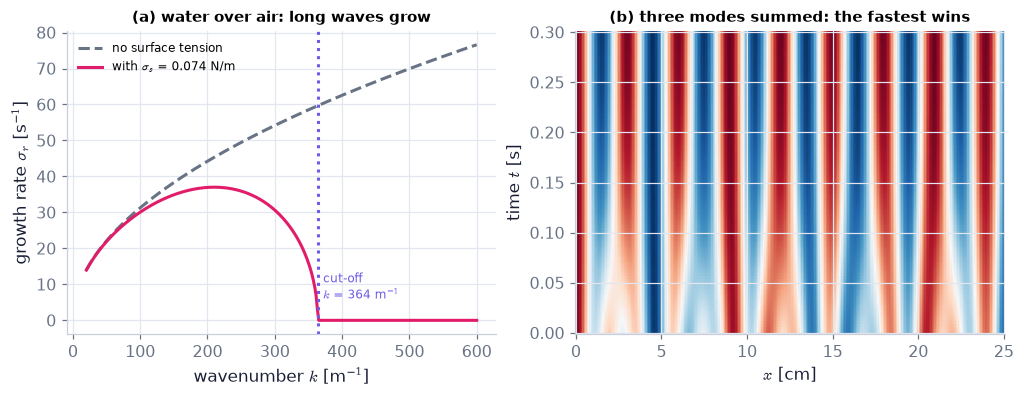

In [9]:
k = np.linspace(20.0, 600.0, 300)                                  # wavenumbers [1/m] (wavelengths from 31 cm down to 1 cm)
grow = np.array([ch11.normal_mode_growth("interface", ki, rho1=1000.0, rho2=1.2, surface_tension=0.074).real   # growth rate of each wavenumber: water over air, held by surface tension at short waves
                 for ki in k])                                     # sigma_r(k) [1/s]: water (1000) ABOVE air (1.2), with surface tension
grow0 = np.array([ch11.normal_mode_growth("interface", ki, rho1=1000.0, rho2=1.2, surface_tension=0.0).real for ki in k])   # no surface tension
k_cut = 2*np.pi/ch11.rayleigh_taylor_cutoff(0.074, 1000.0, 1.2)    # the wavenumber where growth stops [1/m]
fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 3.5))   # the figure and its panels
a.plot(k, grow0, "--", color=C_BASE, label="no surface tension")   # dashed: without surface tension every shorter wave grows faster
a.plot(k, grow, color=C_GROW, label=r"with $\sigma_s$ = 0.074 N/m")   # with surface tension: only waves longer than the cut-off grow
a.axvline(k_cut, color=C_NEUT, ls=":")   # a reference line or band
a.text(k_cut + 8, 6, f"cut-off\n$k$ = {k_cut:.0f} m$^{{-1}}$", color=C_NEUT, fontsize=8)   # a label written on the plot
a.set(xlabel="wavenumber $k$ [m$^{-1}$]", ylabel=r"growth rate $\sigma_r$ [s$^{-1}$]")   # axis labels (with units) and fixed ranges for this panel
a.set_title("(a) water over air: long waves grow", fontsize=10)   # panel title — the message of this panel
a.legend(fontsize=8)   # legend: one entry per curve
kk = np.array([60.0, 210.0, 340.0])                               # three modes [1/m]
ss = [ch11.normal_mode_growth("interface", ki, rho1=1000.0, rho2=1.2, surface_tension=0.074) for ki in kk]   # their complex sigma
xs = np.linspace(0.0, 0.25, 300)                                   # 25 cm of interface [m]
ts = np.linspace(0.0, 0.30, 120)                                   # the first 0.3 s [s]
eta = np.array([sum(ST.normal_mode(xs, 0.0, t, 1.0, ki, sigma=si) for ki, si in zip(kk, ss)) for t in ts])   # the three modes summed
eta = eta/np.max(np.abs(eta), axis=1, keepdims=True)               # each time row scaled by its own maximum (so the shape is visible)
b.pcolormesh(xs*100, ts, eta, cmap="RdBu_r", shading="auto")   # a colour map of the field
b.set(xlabel="$x$ [cm]", ylabel="time $t$ [s]")   # axis labels (with units) and fixed ranges for this panel
b.set_title("(b) three modes summed: the fastest wins", fontsize=10)   # panel title — the message of this panel
savefig(fig, "ch11", "c01_growth_curve")   # keep a copy in outputs/ch11 and display
print(f"fastest of the three: k = {kk[int(np.argmax([s.real for s in ss]))]:.0f} 1/m with sigma_r = {max(s.real for s in ss):.1f} 1/s")   # the mode at the top of the growth curve wins

**What does the code above do?**

1. `ch11.normal_mode_growth("interface", k, rho1, rho2, surface_tension)` returns the complex growth rate $\sigma=-\mathrm ikc_+$
   of a static interface (upper density `rho1`, lower `rho2`). With the heavy fluid on top it is real and positive for long waves
   (Rayleigh–Taylor instability); it takes one wavenumber at a time, hence the list comprehension.
2. Panel (b) adds three modes with `ST.normal_mode` and rescales each time row, so you watch the *shape* change, not the size.

**What you see.** (a) A hump of growth rates: positive for long waves, falling to zero at the cut-off (purple dotted line) and zero beyond it; without surface tension (grey dashed) the curve keeps rising. (b) A space–time picture of three waves added together: at the bottom (t = 0) a mixed pattern, at the top a single clean wavelength.

**How to read it.** The top of the hump is the wavelength you will see; the zero crossing is the shortest wave that can grow (about 1.7 cm here — N121 in C02 derives it). In (b) the pattern at late times is the mode with the largest $\sigma_r$: growth is a property of the whole curve, and its maximum wins.

**What would change if…** …we remove surface tension: the hump never comes back down — every shorter wave grows faster (the 'short waves always lose' of C02).

#### 🎮 Interactive: When is a flow 'unstable'?

**Why interactive rather than a static figure:** Dragging $k$ along the growth-rate curve makes the interface grow, decay or travel at once, and raising the control parameter
lifts the whole curve through zero — the wavelength that goes first appears in front of you; a static plot hides the link between
one point on the curve and the motion it means.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Pick 'upside-down interface' and drag k from long to short waves: watch the growth rate peak, then die where surface tension wins.
- Switch to 'Bénard (free walls)' and raise Ra slowly from 500: note the K where the growth rate first crosses zero (K ≈ 2.22 at Ra ≈ 657.5).
- Open the complex σ-plane: at the onset the root crosses the imaginary axis — on the real axis for Bénard (stationary), off it for a travelling interface wave.

In [10]:
show_viz("ch11", "normal_mode_growth")   # full-width explainer; ⤢ Full screen for more room

[explainer ch11/normal_mode_growth]

**What would change if…** …the basic state moved — two streams sliding past each other? Then $c$ is no longer purely real or purely imaginary: it has a
travelling part and a growing part at once, and the growth comes from the shear itself. That is the Kelvin–Helmholtz problem
(C02), the first complete normal-mode calculation.

---

## 11.3 Kelvin-Helmholtz Instability

**What is this section about?** Two layers of fluid slide past each other: wind over the sea, a fast current over a slow one in
the ocean, the warm air of a front over cold air. Gravity wants the interface flat (if the heavy fluid is below); the velocity
jump wants to roll it up. We put a small wave on the interface, apply the conditions you met in Ch. 7, and get a formula for the
wave speed whose square root turns imaginary when shear wins. The result explains billow clouds, wind-driven ripples and the start
of mixing in the thermocline.

> 🔁 **Recap — Total potentials and Kelvin's theorem** (Ch. 5 §5.2, Ch. 6). Each layer is irrotational: far upstream the flow is uniform, and Kelvin's theorem (Ch. 5 §5.2, $\frac{D\Gamma}{Dt}=0$ (5.8): the
circulation of a material loop is constant in inviscid, barotropic flow with conservative forces) keeps it irrotational, so each
layer has a potential, $\tilde\phi_1=U_1x+\phi_1,\ \tilde\phi_2=U_2x+\phi_2$ (11.2), with $\phi_j$ the small disturbance
(subscript 1 = upper layer, 2 = lower layer).

> 🔁 **Recap — Laplace's equation for the disturbances** (Ch. 6, Ch. 7 §7.1). Incompressible + irrotational ⇒ $\nabla^2\phi_1=0,\ \nabla^2\phi_2=0$ (11.3) — exactly Ch. 6's potential flow and Ch. 7 §7.1.

> 🔁 **Recap — Decay far away** (Ch. 7 §7.7). $\phi_1\to0$ as $z\to+\infty$ (11.4) and $\phi_2\to0$ as $z\to-\infty$ (11.5): the disturbance lives near the interface, as for
Ch. 7's interface waves; this decides the signs $e^{\mp kz}$ in D03.

> 🔁 **Recap — Kinematic and dynamic interface conditions** (Ch. 4 §4.10, Ch. 7 §7.1). Fluid on either side moves with the interface, $\mathbf n\cdot\nabla\tilde\phi_1=\mathbf n\cdot\mathbf U_s=\mathbf
n\cdot\nabla\tilde\phi_2$ on $z=\zeta$ (11.6) ($\mathbf n$ the unit normal, $\mathbf U_s$ the velocity of the interface), and —
without surface tension — the pressure is continuous, $p_1=p_2$ on $z=\zeta$ (11.7). These are the two-fluid versions of Ch. 7's
free-surface conditions; they are the starting line of D02.

> 🔁 **Recap — The normal of a level set** (Ch. 2 P75, Ch. 7 §7.1). The interface is the level set $f=z-\zeta(x,t)=0$, so its unit normal is $\mathbf n=\nabla f/\lvert\nabla f\rvert=
[-(\partial\zeta/\partial x)\mathbf e_x+\mathbf e_z]/\sqrt{1+(\partial\zeta/\partial x)^2}$, which turns the kinematic condition
into $\mathbf n\cdot\{\partial_x\tilde\phi_1\mathbf e_x+\partial_z\tilde\phi_1\mathbf e_z\}=\mathbf n\cdot\{\partial_t\zeta\,\mathbf
e_z\}=\mathbf n\cdot\{\partial_x\tilde\phi_2\mathbf e_x+\partial_z\tilde\phi_2\mathbf e_z\}$ (11.8) — the gradient of a level-set
function is normal to the level set (Ch. 2, P75).

> 🔁 **Recap — Unsteady Bernoulli in each layer** (Ch. 4 §4.9). Irrotational, unsteady: $\frac{\partial\tilde\phi_j}{\partial t}+\tfrac12\lvert\nabla\tilde\phi_j\rvert^2+\frac{p_j}{\rho_j}+gz=C_j$
(11.10), $j=1,2$ — Ch. 4's unsteady Bernoulli equation with constant density in each layer; $C_j$ is a constant, one per layer.

> 🔁 **Recap — A″ = k²A and its exponentials** (Ch. 1 P44, Ch. 7 P167). A constant-coefficient second-order ODE is solved by the trial $e^{mz}$ (Ch. 1, P44): $A''=k^2A$ gives $m^2=k^2$, so
$A=A_\pm e^{\pm kz}$ (the depth structure after separating variables, Ch. 7 P167).

> 🔁 **Recap — The decaying solutions** (Ch. 7 §7.7). With the decay conditions: $\phi_1=A_-\exp\{\mathrm ik(x-ct)-kz\}$, $\phi_2=A_+\exp\{\mathrm ik(x-ct)+kz\}$ (11.15) — the same
potentials as Ch. 7's interface waves (`ch07.interface_fields`).

> 🔁 **Recap — The static interface (U₁ = U₂ = 0)** (Ch. 7 §7.7). Then $c=\pm\big[\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk\big]^{1/2}$ (11.19): the interface waves of Ch. 7,
$\omega^2=gk\frac{\rho_2-\rho_1}{\rho_2+\rho_1}$ (7.95) with $\omega=kc$; neutral if the heavy fluid is below ($\rho_2>\rho_1$),
**Rayleigh–Taylor** unstable if it is above (the square root is then imaginary). A parity cell in C02 checks `ch11.kh_phase_speed`
against Ch. 7's `WV.interface_omega`.

> ⚠️ **slip #5 — the book prints** a pointer "see (7.96)", which is the energy $E=\tfrac12(\rho_2-\rho_1)ga^2$, for the static-interface limit **; the correct form is** the interface dispersion relation of Ch. 7, $\omega^2=gk\frac{\rho_2-\rho_1}{\rho_2+\rho_1}$ (7.95).

> 🔁 **Recap — The vortex sheet** (Ch. 5 §5.8). Equal densities $\rho_1=\rho_2$: the interface is a vortex sheet of strength $\gamma=U_2-U_1$ (Ch. 5 §5.8). **New here:** the
dispersion relation becomes $c=\frac{U_2+U_1}2\pm\mathrm i\frac{U_2-U_1}2$ (11.20), so the growth rate $kc_i=k\lvert U_2-U_1\rvert/2$
is positive at **every** $k$ — a vortex sheet is unstable to all wavelengths, fastest for the shortest.

> 🔁 **Recap — Roll-up of a perturbed vortex sheet** (Ch. 5 §5.8). Ch. 5's `sheet_rollup` (a row of point vortices with a smoothing parameter $\delta$) follows the sheet past the linear stage into
cat's-eye rolls. Animation A2 below puts the linear growth law next to it.

### 🧩 The Kelvin–Helmholtz dispersion relation $c=\frac{\rho_2U_2+\rho_1U_1}{\rho_2+\rho_1}\pm\Big[\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk-\frac{\rho_2\rho_1}{(\rho_2+\rho_1)^2}(U_2-U_1)^2\Big]^{1/2}$ (11.18) `C02`

*The question:* When does a velocity jump across an interface make waves grow, and which ones?

#### The problem in plain words

Blow gently across a glass of water: nothing. Blow harder: ripples appear and grow. In the sky, a fast layer of air over a slow,
denser one sometimes paints a row of breaking-wave "billow clouds". In the ocean thermocline, dye released by divers rolls up
into the same shapes. All are one instability: shear across an interface. We want the threshold — how fast must the wind be? —
and the wavelength that grows.

#### The idea

```
   U₁, ρ₁ (light)   ───────────►            over a crest the upper stream is squeezed → faster → lower pressure
~~~~~~~~~~~~~~~~~ interface ζ = ζ₀ e^{ik(x−ct)} ~~~~   ⇒ the crest is SUCKED up (Bernoulli): shear destabilises
   U₂, ρ₂ (heavy)   ──►                     gravity pulls the crest back down: stratification stabilises
c = mean speed ± √( gravity term − shear term )   →  √(negative) = imaginary ⇒ one root grows
```

Everything is decided by the sign under the square root: restoring (gravity, later surface tension) minus driving (the kinetic
energy of the shear).

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **level sets and their normals, (11.8)**, $\mathbf n\cdot\Big\{\frac{\partial\tilde\phi_1}{\partial x}\mathbf e_x+\frac{\partial\tilde\phi_1}{\partial z}\mathbf e_z\Big\}=\mathbf n\cdot\Big\{\frac{\partial\zeta}{\partial t}\mathbf e_z\Big\}=\mathbf n\cdot\Big\{\frac{\partial\tilde\phi_2}{\partial x}\mathbf e_x+\frac{\partial\tilde\phi_2}{\partial z}\mathbf e_z\Big\}$ — a surface $f=0$ has the normal $\nabla f/\lvert\nabla f\rvert$; for the interface $f=z-\zeta(x,t)$. *(Ch. 2, P75)*
- **A″ = k²A and exponential solutions** — a linear ODE with constant coefficients is solved by trying $e^{mz}$; here $m^2=k^2$, so $e^{\pm kz}$. *(Ch. 1, P44)*
- **separation of variables** — try (a function of $z$) × (a wave in $x$ and $t$): the PDE becomes an ODE for the function of $z$. *(Ch. 7, P167)*
- **Taylor transfer of a boundary condition to z = 0** — a condition on the moving surface $z=\zeta$ is written on $z=0$ with $F(\zeta)\approx F(0)+\zeta F'(0)$; the correction is of second order. *(Ch. 7, P166)*
- **orders of smallness, dropping products** — a product of two small quantities is much smaller than either; linear theory keeps first-order terms only. *(Ch. 2, P68)*
- **quadratic formula with complex roots** — $ac^2+bc+d=0$ has $c=\big(-b\pm\sqrt{b^2-4ad}\big)/(2a)$; a negative number under the root gives a complex-conjugate pair. *(Ch. 6, P159)*
- **inequalities under a sign change** — multiplying an inequality by a positive number keeps its direction, by a negative number reverses it. *(Ch. 1, P48)*
- **moving frame, c_r = mean** — seen from a frame moving at constant velocity, every velocity is reduced by the frame's velocity; the physics is unchanged. *(Ch. 3, P96)*
- **hyperbolic functions cosh, sinh, coth** — $\cosh x=(e^x+e^{-x})/2$, $\sinh x=(e^x-e^{-x})/2$, $\coth x=\cosh x/\sinh x\to1$ for large $x$. *(Ch. 7, P168)*
- **Laplace pressure jump σ_s ∂²ζ/∂x²** — a curved interface with surface tension $\sigma_s$ carries a pressure jump $\sigma_s\times$ curvature; for a gentle slope the curvature is $\partial^2\zeta/\partial x^2$. *(Ch. 7, P169)*
- **sympy** — algebra with symbols: `sp.symbols`, `sp.diff`, `sp.simplify`; an expression that simplifies to 0 is an identity. *(Ch. 1, P40)*
- **sympy expand, collect, subs** — `sp.expand` multiplies out, `sp.collect` groups by powers, `.subs` substitutes. *(Ch. 4, P117)*
- **scipy.integrate.quad (mixing energy cross-check)** — `quad(f, a, b)` returns the integral of a function and an error estimate. *(Ch. 3, P87)*
- **slider_figure** — a plotly figure whose curves follow a slider; every slider position is computed in advance, so it also works on the web page. *(Ch. 1, P17)*
- **np.logspace** — `np.logspace(a, b, n)` gives n numbers from 10^a to 10^b with a constant ratio between neighbours. *(Ch. 1, P06)*
- **power laws and log axes** — on a logarithmic axis equal distances are equal ratios — the right axis when a quantity spans several decades. *(Ch. 1, P13)*
- **Python dictionaries (returned results)** — `r["Ra_c"]`: fluidpy returns several named results in a dict. *(Ch. 1, P23)*
- **functions as arguments and lambda** — `lambda y: 1 - y**2` is a one-line function; the eigen-solvers take the velocity profile as such a function. *(Ch. 1, P29)*
- **tuple unpacking** — `cp, cm = f()` takes a function's two return values apart in one line. *(Ch. 1, P14)*

📝 **Note.** **N07 [B]** **The set-up** (figure below): upper fluid speed $U_1$ [m/s], density $\rho_1$ [kg/m³]; lower $U_2$, $\rho_2$; interface
$z=\zeta(x,t)$ [m]; gravity $g$ [m/s²]; inviscid, irrotational in each layer, no surface tension (added in N120).

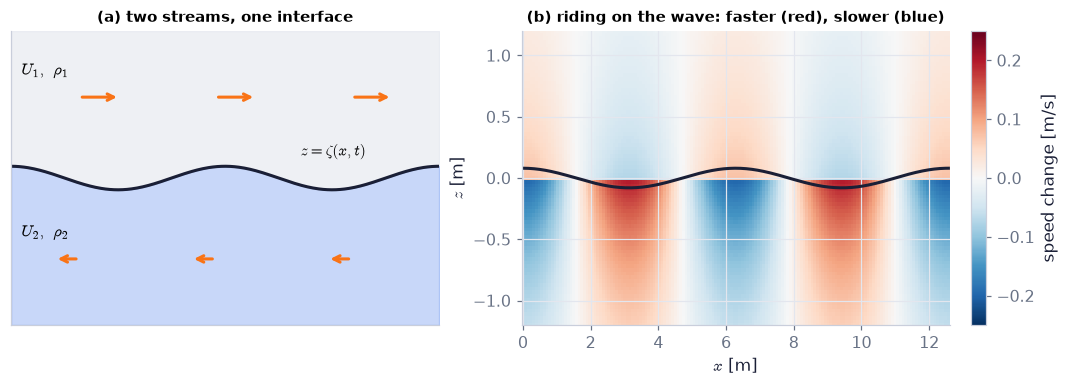

wave speed of this mode c = 1.926 m/s (real: a neutral wave)


In [11]:
fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 3.4))   # the figure and its panels
kh_sketch(a)                                                       # drawing only: two streams and a wavy interface
a.set_title("(a) two streams, one interface", fontsize=10)   # panel title — the message of this panel
X, Z = np.meshgrid(np.linspace(0, 4*np.pi, 160), np.linspace(-1.2, 1.2, 81))   # a grid of (x, z) points [m]
U1, U2 = 1.0, -0.6                                                 # the two stream speeds [m/s]
f = ch11.kh_fields(X, Z, 0.0, 1.0, U1, U2, 1.0, 3.0, g=10.0, zeta0=0.08)   # one neutral mode: k = 1 1/m, densities 1 over 3 kg/m^3
c = f["c"].real                                                    # its (real) wave speed [m/s]
rel = np.where(Z > 0, np.sign(U1 - c), np.sign(U2 - c))*f["u"]     # change of flow SPEED seen by an observer riding on the wave [m/s]
xs = np.linspace(0, 4*np.pi, 300)                                  # fine x for the interface line [m]
zeta = ch11.kh_fields(xs, 0.0, 0.0, 1.0, U1, U2, 1.0, 3.0, g=10.0, zeta0=0.08)["zeta"]   # interface height [m]
pc = b.pcolormesh(X, Z, rel, cmap="RdBu_r", vmin=-0.25, vmax=0.25, shading="auto")   # a colour map of the field
b.plot(xs, zeta, color=COLORS["ink"])   # the interface itself
fig.colorbar(pc, ax=b, label="speed change [m/s]")   # the colour scale and what it measures
b.set(xlabel="$x$ [m]", ylabel="$z$ [m]", ylim=(-1.2, 1.2))   # axis labels (with units) and fixed ranges for this panel
b.set_title("(b) riding on the wave: faster (red), slower (blue)", fontsize=10)   # panel title — the message of this panel
plt.show()   # display the figure
print(f"wave speed of this mode c = {c:.3f} m/s (real: a neutral wave)")   # a real wave speed: this wave neither grows nor decays

**What does the code above do?**

1. `kh_sketch(ax)` is a drawing helper (no physics).
2. `ch11.kh_fields(x, z, t, k, U1, U2, rho1, rho2, g, zeta0)` returns the real fields of one normal mode — the potentials of
   (11.15), $\phi_1=A_-\exp\{\mathrm ik(x-ct)-kz\},\ \phi_2=A_+\exp\{\mathrm ik(x-ct)+kz\}$ with the amplitudes that D03 derives — as a dictionary: `zeta`, `u`, `w` (the disturbance velocity, taken from the
   upper potential for $z>0$ and from the lower for $z<0$) and the wave speed `c`.
3. Riding on the wave, the upper stream passes at $U_1-c$ and the lower at $U_2-c$; multiplying the disturbance $u$ by the sign
   of that relative velocity gives the change of *speed* (`np.where` picks the layer).

**What you see.** (a) Two streams (orange arrows) and a wavy interface. (b) For one normal mode, how much faster (red) or slower (blue) the fluid moves past an observer who rides on the wave; the black line is the interface. The pattern is strongest at the interface and fades away from it like $e^{-k\lvert z\rvert}$.

**How to read it.** Above a crest the upper stream is squeezed and speeds up (red); under the same crest the lower layer is thicker and slows down (blue). By Bernoulli the pressure is lower above the crest and higher below it: both push the crest further up. That is the destabilising effect of shear; gravity pulls the other way.

**What would change if…** …$U_1=U_2$: both layers move past the wave at the same speed, the two pressure changes are those of an ordinary interface wave of Ch. 7, and nothing can grow.

#### 🧮 Derivation — The linearised interface conditions `D02` ★★ (Eq. 11.13: $\rho_1\Big(\frac{\partial\phi_1}{\partial t}+U_1\frac{\partial\phi_1}{\partial x}+g\zeta\Big)=\rho_2\Big(\frac{\partial\phi_2}{\partial t}+U_2\frac{\partial\phi_2}{\partial x}+g\zeta\Big)\ \text{on}\ z=0$)

**What we want to show.** Turn the exact conditions on the moving interface into simple linear conditions on the flat plane z = 0.

**Assumptions.** Small slope ∂ζ/∂x ≪ 1 and small disturbance potentials (steps 6, 11); no surface tension (step 8); irrotational layers (R01).

**The plan.**

1. Write the normal and the interface velocity.
2. Do the dot products and cancel the common factor.
3. Drop products of small quantities and move the conditions to z = 0.
4. Same for the pressures via Bernoulli.

**Tools we use** (each explained before this point): Level sets and their normals (R05, P75) · unsteady Bernoulli (R06) · orders of smallness (P68) · Taylor transfer of a boundary condition (P166)

**We start from**

$$ \begin{array}{l}\mathbf n\cdot\nabla\tilde\phi_1=\mathbf n\cdot\mathbf U_s=\mathbf n\cdot\nabla\tilde\phi_2\ \text{on}\ z=\zeta\ \text{(11.6),}\ p_1=p_2\ \text{on}\ z=\zeta\ \text{(11.7), and the} \\ \text{Bernoulli equations}\ \frac{\partial\tilde\phi_j}{\partial t}+\tfrac12\lvert\nabla\tilde\phi_j\rvert^2+ \frac{p_j}{\rho_j}+gz=C_j\ \text{(11.10)}\end{array} $$

*In words:* fluid on each side moves with the interface, and the pressure is continuous.

---

**Step 1 of 12 — Describe the interface as a level set.**

$$ f=z-\zeta(x,t)=0,\quad\nabla f=-\frac{\partial\zeta}{\partial x}\mathbf e_x +\mathbf e_z $$

- *Why we can do this:* the interface is where f vanishes; the gradient of a level-set function is normal to the level set (P75).
- *In words:* we have a vector that points straight out of the interface.

---

**Step 2 of 12 — Normalise it.**

$$ \mathbf n=\frac{-(\partial\zeta/\partial x)\mathbf e_x+\mathbf e_z}{\sqrt{1+(\partial\zeta/\partial x)^2}} $$

- *Why we can do this:* dividing by the length gives the unit normal used in (11.6), $\mathbf n\cdot\nabla\tilde\phi_1=\mathbf n\cdot\mathbf U_s=\mathbf n\cdot\nabla\tilde\phi_2\ \text{on}\ z=\zeta$; the square root is the length of ∇f.
- *In words:* the unit normal tilts with the local slope.

---

**Step 3 of 12 — Choose the interface velocity.**

$$ \mathbf U_s=\frac{\partial\zeta}{\partial t}\mathbf e_z $$

- *Why we can do this:* only the normal part of U_s enters (11.6), $\mathbf n\cdot\nabla\tilde\phi_1=\mathbf n\cdot\mathbf U_s=\mathbf n\cdot\nabla\tilde\phi_2\ \text{on}\ z=\zeta$, so we may let points of the interface move vertically; it keeps the algebra simple.
- *In words:* we follow the interface up and down at fixed x.

---

**Step 4 of 12 — Take the three dot products.**

$$ \frac{-\zeta_x\partial_x\tilde\phi_1+\partial_z\tilde\phi_1}{\sqrt{1+\zeta_x^2}}= \frac{\zeta_t}{\sqrt{1+\zeta_x^2}}=\frac{-\zeta_x\partial_x\tilde\phi_2+\partial_z\tilde\phi_2}{\sqrt{1+\zeta_x^2}} $$

- *Why we can do this:* the velocity is ∇φ̃ = (∂_xφ̃, ∂_zφ̃), and dot products add componentwise; this is (11.8), $\mathbf n\cdot\Big\{\frac{\partial\tilde\phi_1}{\partial x}\mathbf e_x+\frac{\partial\tilde\phi_1}{\partial z}\mathbf e_z\Big\}=\mathbf n\cdot\Big\{\frac{\partial\zeta}{\partial t}\mathbf e_z\Big\}=\mathbf n\cdot\Big\{\frac{\partial\tilde\phi_2}{\partial x}\mathbf e_x+\frac{\partial\tilde\phi_2}{\partial z}\mathbf e_z\Big\}$ written out.
- *In words:* the normal velocity of each fluid equals the normal speed of the interface.

---

**Step 5 of 12 — Cancel the common square root.**

$$ -(U_1+\partial_x\phi_1)\zeta_x+\partial_z\phi_1=\zeta_t=-(U_2+\partial_x \phi_2)\zeta_x+\partial_z\phi_2 $$

- *Why we can do this:* the same nonzero factor divides all three members, so multiplying through by it is allowed; then insert (11.2), ∂_xφ̃_j = U_j + ∂_xφ_j. The book skips why the root disappears.
- *In words:* the exact kinematic condition, still on the wavy interface.

---

**Step 6 of 12 — Drop the quadratic term.**

$$ -U_1\zeta_x+\partial_z\phi_1=\zeta_t=-U_2\zeta_x+\partial_z\phi_2\quad(z=\zeta) $$

- *Why we can do this:* ∂_xφ_j ζ_x is a product of two small quantities, one order smaller than the rest (P68); linear theory keeps first order only.
- *In words:* each stream carries the slope; the disturbance adds a vertical velocity.

---

**Step 7 of 12 — Move the condition to z = 0.**

$$ -U_1\frac{\partial\zeta}{\partial x}+\frac{\partial\phi_1}{\partial z}=\frac{\partial \zeta}{\partial t}=-U_2\frac{\partial\zeta}{\partial x}+\frac{\partial\phi_2}{\partial z}\ \text{on }z=0\ \text{(11.9)} $$

- *Why we can do this:* Taylor transfer (P166): $\partial_z\phi(x,\zeta)=\partial_z\phi(x,0)+\zeta\,\partial_z^2\phi(x,0)+\dots$; the correction is a product of small quantities.
- *In words:* the linear kinematic condition on the flat plane.

---

**Step 8 of 12 — Equate the two pressures.**

$$ \rho_1\big(C_1-\partial_t\tilde\phi_1-\tfrac12\lvert\nabla\tilde\phi_1\rvert^2-gz\big)= \rho_2\big(C_2-\partial_t\tilde\phi_2-\tfrac12\lvert\nabla\tilde\phi_2\rvert^2-gz\big)\ (z=\zeta)\ \text{(11.11)} $$

- *Why we can do this:* solve each Bernoulli equation (11.10), $\frac{\partial\tilde\phi_j}{\partial t}+\tfrac12\lvert\nabla\tilde\phi_j\rvert^2+\frac{p_j}{\rho_j}+gz=C_j$ for p_j and use (11.7), $p_1=p_2\ \text{on}\ z=\zeta$ (no surface tension, so no pressure jump).
- *In words:* the pressure from above equals the pressure from below at the interface.

---

**Step 9 of 12 — Write the undisturbed balance.**

$$ \rho_1(C_1-\tfrac12U_1^2)=\rho_2(C_2-\tfrac12U_2^2)\ \text{(11.12)} $$

- *Why we can do this:* with φ_j = ζ = 0 (the plain streams) (11.11), $\rho_1\big(C_1-\partial_t\tilde\phi_1-\tfrac12\lvert\nabla\tilde\phi_1\rvert^2-gz\big)=\rho_2\big(C_2-\partial_t\tilde\phi_2-\tfrac12\lvert\nabla\tilde\phi_2\rvert^2-gz\big)\ \text{on}\ z=\zeta$ must hold too; it fixes how the two Bernoulli constants are related.
- *In words:* the flat interface is in pressure balance.

---

**Step 10 of 12 — Subtract (11.11) from (11.12).**

$$ \rho_1\big(\partial_t\phi_1+U_1\partial_x\phi_1+\tfrac12\lvert\nabla\phi_1\rvert^2+ g\zeta\big)=\rho_2\big(\partial_t\phi_2+U_2\partial_x\phi_2+\tfrac12\lvert\nabla\phi_2\rvert^2+g\zeta\big) $$

- *Why we can do this:* both are equalities between the same two sides, so their difference is one; expand $\lvert\nabla\tilde\phi_j\rvert^2=U_j^2+2U_j\partial_x \phi_j+\lvert\nabla\phi_j\rvert^2$ — the U_j² cancels.
- *In words:* only the disturbance's part of the pressure is left.

---

**Step 11 of 12 — Drop the quadratic terms.**

$$ \rho_1(\partial_t\phi_1+U_1\partial_x\phi_1+g\zeta)=\rho_2(\partial_t\phi_2+U_2\partial_x \phi_2+g\zeta)\ (z=\zeta) $$

- *Why we can do this:* ½∣∇φ_j∣² is quadratic in the disturbance (P68). Note: it is $U\partial_x\phi$ that survives, not ½(∂_xφ)².
- *In words:* unsteadiness, advection by the stream and gravity balance.

---

**Step 12 of 12 — Evaluate on z = 0.**

$$ \rho_1\Big(\frac{\partial\phi_1}{\partial t}+U_1\frac{\partial\phi_1}{\partial x}+g\zeta\Big) =\rho_2\Big(\frac{\partial\phi_2}{\partial t}+U_2\frac{\partial\phi_2}{\partial x}+g\zeta\Big)\ \text{on }z=0\ \text{(11.13)} $$

- *Why we can do this:* the same Taylor transfer as step 7; moving from z = ζ to z = 0 changes each term only at second order.
- *In words:* the linear dynamic condition.

---

**Result**

$$ \begin{array}{l}-U_1\frac{\partial\zeta}{\partial x}+\frac{\partial\phi_1}{\partial z}=\frac{\partial\zeta}{\partial t}=-U_2\frac{\partial\zeta}{\partial x}+\frac{\partial\phi_2}{\partial z}\ \text{on}\ z=0\qquad\text{(11.9)} \\[4pt] \rho_1\Big(\frac{\partial\phi_1}{\partial t}+U_1\frac{\partial\phi_1}{\partial x}+g\zeta\Big)=\rho_2\Big(\frac{\partial\phi_2}{\partial t}+U_2\frac{\partial\phi_2}{\partial x}+g\zeta\Big)\ \text{on}\ z=0\qquad\text{(11.13)}\end{array} $$

*In words:* two linear conditions on z = 0 linking the interface shape ζ to the two potentials.

**What it means.** The streams enter only through U_j∂/∂x — advection of the disturbance by each stream; that is where shear will act. Fails when the slope is not small (breaking billows, animation A2).

**Check it.** Units: (11.9), $-U_1\frac{\partial\zeta}{\partial x}+\frac{\partial\phi_1}{\partial z}=\frac{\partial\zeta}{\partial t}=-U_2\frac{\partial\zeta}{\partial x}+\frac{\partial\phi_2}{\partial z}\ \text{on}\ z=0$ every term m/s ✓; (11.13), $\rho_1\Big(\frac{\partial\phi_1}{\partial t}+U_1\frac{\partial\phi_1}{\partial x}+g\zeta\Big)=\rho_2\Big(\frac{\partial\phi_2}{\partial t}+U_2\frac{\partial\phi_2}{\partial x}+g\zeta\Big)\ \text{on}\ z=0$ every term Pa ✓. Limit U₁ = U₂ = 0: Ch. 7's linearised surface conditions $(\partial\phi/\partial z)_{z=0}\cong\partial\eta/\partial t$ (7.18) and $(\partial\phi/\partial t)_{z=0}\cong-g\eta$ (7.21) ✓. `ch11.kh_residuals` gives residuals ≤ 1e-12 for the computed mode.

📝 **Notes taught inside `D02`:** **N08 [B]** the exact kinematic condition, where the square-root factor cancels (step 5) · **N09 [B]** its linearised form on the flat plane (step 7) · **N10 [B]** the pressure matching (step 8) · **N11 [B]** the undisturbed balance (step 9) · **N12 [B]** the linearised dynamic condition (step 12).

> ⚠️ **Common confusion (traps in `D02`):** Keeping ½(∂_xφ)² instead of U∂_xφ; forgetting that the square-root factor multiplies all three members; thinking the shift to z = 0 is an approximation of the same order as the linearisation (it is one order higher).

📝 **Note.** **N13 [B]** **The normal-mode trial** (C01's mode with $\mathbf K=(k,0,0)$): $\phi_j=A_j(z)\exp\{\mathrm ik(x-ct)\}$ (11.14) and
$\zeta=\zeta_o\exp\{\mathrm ik(x-ct)\}$; inserted into Laplace's equation it gives R07's $A''=k^2A$.

> 📎 **Primer — np.roots and np.lib.scimath.sqrt.** `P256` · `np.roots(coeffs)` returns all roots of a polynomial given its coefficients, highest power first (complex if needed).
`np.sqrt(-1.0)` gives `nan` with a warning, but `np.lib.scimath.sqrt(-1.0)` returns the principal complex root `1j` — what we
want when the quantity under a square root can turn negative.

In [12]:
import numpy as np                              # arrays
print(np.roots([1, -3, 4]))                     # c^2 - 3c + 4 = 0  ->  1.5 + 1.3229j and 1.5 - 1.3229j
print(np.lib.scimath.sqrt(-1.75))               # 1.3229j: the principal square root of a negative number

[1.5+1.3229j 1.5-1.3229j]
1.3228756555322954j


#### 🧮 Derivation — The Kelvin–Helmholtz dispersion relation, the instability inequality and the limits `D03` ★★ (Eq. 11.18: $c=\frac{\rho_2U_2+\rho_1U_1}{\rho_2+\rho_1}\pm\Big[\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk-\frac{\rho_2\rho_1}{(\rho_2+\rho_1)^2}(U_2-U_1)^2\Big]^{1/2}$)

**What we want to show.** Find the complex wave speed c of a small interface wave between two streams, and when it has a growing part.

**Assumptions.** k > 0 real (step 3); infinitely deep layers (step 3); ζ₀ ≠ 0 (step 9).

**The plan.**

1. Solve Laplace's equation for the depth structure.
2. Use the kinematic condition to fix the amplitudes.
3. Put them into the dynamic condition: a quadratic for c.
4. Solve and read off when c is complex.

**Tools we use** (each explained before this point): Linear ODE by an exponential trial (P44, R07) · complex algebra (P153) · the quadratic formula with complex roots (P159) · inequalities (P48) · sympy (P40) for the check

**We start from**

$$ \begin{array}{l}\nabla^2\phi_1=0,\ \nabla^2\phi_2=0\qquad\text{(11.3)} \\[4pt] \phi_1\to0\ \text{as}\ z\to+\infty\qquad\text{(11.4)} \\[4pt] \phi_2\to0\ \text{as}\ z\to-\infty\qquad\text{(11.5)} \\[4pt] -U_1\frac{\partial\zeta}{\partial x}+\frac{\partial\phi_1}{\partial z}=\frac{\partial\zeta}{\partial t}=-U_2\frac{\partial\zeta}{\partial x}+\frac{\partial\phi_2}{\partial z}\ \text{on}\ z=0\qquad\text{(11.9)} \\[4pt] \rho_1\Big(\frac{\partial\phi_1}{\partial t}+U_1\frac{\partial\phi_1}{\partial x}+g\zeta\Big)=\rho_2\Big(\frac{\partial\phi_2}{\partial t}+U_2\frac{\partial\phi_2}{\partial x}+g\zeta\Big)\ \text{on}\ z=0\qquad\text{(11.13)} \\[4pt] \phi_j=A_j(z)\exp\{\mathrm ik(x-ct)\}\qquad\text{(11.14)}\end{array} $$

*In words:* the linear problem of D02 and a wave-shaped guess.

---

**Step 1 of 14 — Put the trial into Laplace.**

$$ A_j''-k^2A_j=0 $$

- *Why we can do this:* ∂²/∂x² of $e^{\mathrm ik(x-ct)}$ gives −k²; the common exponential is never zero, so divide it out.
- *In words:* the depth structure obeys a simple ODE.

---

**Step 2 of 14 — Solve the ODE.**

$$ A_j=a_je^{kz}+b_je^{-kz} $$

- *Why we can do this:* the trial $e^{mz}$ gives m² = k² (R07).
- *In words:* each layer's disturbance grows or decays exponentially away from the interface.

---

**Step 3 of 14 — Keep the decaying parts.**

$$ \phi_1=A_-e^{\mathrm ik(x-ct)-kz},\quad\phi_2=A_+e^{\mathrm ik(x-ct)+kz}\ \text{(11.15)} $$

- *Why we can do this:* (11.4), $\phi_1\to0\ \text{as}\ z\to+\infty$ needs φ₁ → 0 as z → +∞ (only $e^{-kz}$), (11.5), $\phi_2\to0\ \text{as}\ z\to-\infty$ needs φ₂ → 0 as z → −∞ (only $e^{+kz}$); k > 0.
- *In words:* the disturbance lives near the interface.

---

**Step 4 of 14 — Give the interface the same form.**

$$ \zeta=\zeta_o e^{\mathrm ik(x-ct)}\ \text{,}\ \partial_x\to\mathrm ik\ \text{,}\ \partial_t\to -\mathrm ikc $$

- *Why we can do this:* every term must carry the same exponential for the conditions to hold at every x and t.
- *In words:* the interface is the same travelling wave.

---

**Step 5 of 14 — Insert into the kinematic condition (11.9).**

$$ -\mathrm iU_1k\zeta_o-kA_-=-\mathrm ikc\zeta_o=-\mathrm iU_2k\zeta_o +kA_+\ \text{(11.16)} $$

- *Why we can do this:* at z = 0, ∂_zφ₁ = −kφ₁ and ∂_zφ₂ = +kφ₂; then divide by the common exponential.
- *In words:* three numbers that must be equal.

---

**Step 6 of 14 — Solve for the amplitudes.**

$$ A_-=-\mathrm i(U_1-c)\zeta_o,\quad A_+=\mathrm i(U_2-c)\zeta_o $$

- *Why we can do this:* each equality of (11.16), $-\mathrm iU_1k\zeta_o-kA_-=-\mathrm ikc\zeta_o=-\mathrm iU_2k\zeta_o+kA_+$ has one unknown; divide by k.
- *In words:* the potentials are fixed by the interface's height and the speeds.

---

**Step 7 of 14 — Insert into the dynamic condition (11.13).**

$$ \rho_1(-\mathrm ikcA_-+\mathrm ikU_1A_-+g\zeta_o)=\rho_2(-\mathrm ikcA_++\mathrm ikU_2A_++g\zeta_o)\ \text{(11.17)} $$

- *Why we can do this:* ∂_t → −ikc, ∂_x → ik on each potential at z = 0.
- *In words:* the pressure balance for the wave.

---

**Step 8 of 14 — Substitute A±.**

$$ \rho_1\big(k(U_1-c)^2+g\big)\zeta_o=\rho_2\big(-k(U_2-c)^2+g\big)\zeta_o $$

- *Why we can do this:* $\mathrm ik(U_1-c)\cdot(-\mathrm i)(U_1-c)=k(U_1-c)^2$ and $\mathrm ik(U_2-c)\cdot\mathrm i(U_2-c)=-k(U_2-c)^2$ (i² = −1). The book prints this as $(-\mathrm ikc+\mathrm ikU)^2=-k^2(U-c)^2$.
- *In words:* the shear appears squared.

---

**Step 9 of 14 — Divide by kζ_o and rearrange.**

$$ \rho_1(U_1-c)^2+\rho_2(U_2-c)^2=\frac gk(\rho_2-\rho_1) $$

- *Why we can do this:* ζ_o ≠ 0 (a wave exists) and k > 0; move the gravity terms to one side.
- *In words:* kinetic-energy-like terms balance gravity's restoring term.

---

**Step 10 of 14 — Expand in powers of c.**

$$ (\rho_1+\rho_2)c^2-2(\rho_1U_1+\rho_2U_2)c+\rho_1U_1^2+\rho_2U_2^2-\frac gk(\rho_2-\rho_1)=0 $$

- *Why we can do this:* multiply out the squares; a quadratic in standard form is ready for the formula.
- *In words:* c solves a quadratic.

---

**Step 11 of 14 — Apply the quadratic formula.**

$$ c=\frac{\rho_1U_1+\rho_2U_2\pm\sqrt{\Delta}}{\rho_1+\rho_2} $$

- *Why we can do this:* P159, with $\Delta=(\rho_1U_1+\rho_2U_2)^2-(\rho_1+\rho_2)\big(\rho_1U_1^2+\rho_2U_2^2-\frac gk(\rho_2-\rho_1)\big)$. A quadratic a c² + b c + d = 0 always has the two roots (−b ± √(b² − 4ad))/(2a); the factor 2 of b cancels the 2 below.
- *In words:* two wave speeds around a density-weighted mean.

---

**Step 12 of 14 — Simplify the discriminant.**

$$ \frac{\Delta}{(\rho_1+\rho_2)^2}=\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk- \frac{\rho_1\rho_2(U_2-U_1)^2}{(\rho_1+\rho_2)^2}\ \text{— this is (11.18)} $$

- *Why we can do this:* the identity $(\rho_1U_1+\rho_2U_2)^2-(\rho_1+\rho_2) (\rho_1U_1^2+\rho_2U_2^2)=-\rho_1\rho_2(U_1-U_2)^2$ (expand both; the book skips it).
- *In words:* gravity term minus shear term.

---

**Step 13 of 14 — Ask when the root is imaginary.**

$$ g(\rho_2^2-\rho_1^2)<k\rho_1\rho_2(U_2-U_1)^2 $$

- *Why we can do this:* c is complex (one root with c_i > 0) exactly when the bracket is negative; multiply by $k(\rho_1+\rho_2)^2>0$, which keeps the inequality's direction (P48).
- *In words:* shear wins for strong shear, small density step or short waves.

---

**Step 14 of 14 — Read off the limits.**

$$ U_1=U_2=0:\ c=\pm\big[\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk\big]^{1/2}\ \text{(11.19);}\ \rho_1=\rho_2:\ c=\frac{U_2+U_1}2\pm\mathrm i\frac{U_2-U_1}2\ \text{(11.20)} $$

- *Why we can do this:* set the speeds or the density difference to zero in (11.18), $c=\frac{\rho_2U_2+\rho_1U_1}{\rho_2+\rho_1}\pm\Big[\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk-\frac{\rho_2\rho_1}{(\rho_2+\rho_1)^2}(U_2-U_1)^2\Big]^{1/2}$; the mean becomes (U₁ + U₂)/2.
- *In words:* Ch. 7's interface waves, and a vortex sheet unstable at every k.

---

**Result**

$$ \begin{array}{l}c=\frac{\rho_2U_2+\rho_1U_1}{\rho_2+\rho_1}\pm\Big[\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk-\frac{\rho_2\rho_1}{(\rho_2+ \rho_1)^2}(U_2-U_1)^2\Big]^{1/2}\ \text{(11.18), unstable iff} \\ g(\rho_2^2-\rho_1^2)<k\rho_1\rho_2(U_2-U_1)^2\end{array} $$

*In words:* gravity holds the interface, shear tears it; short waves always lose.

**What it means.** The mean term says where the wave drifts; the root says whether it grows. For air over water, gravity alone cannot hold short waves (N18); surface tension must (N120). Fails for finite slopes (roll-up, animation A2) and for thick shear layers (continuous profiles: C08).

**Check it.** Units: every term under the root m²/s² ✓. Tiny example (ρ = 1, 3; g = 10; k = 1; U₁ = 6): c = 1.5 ± 1.3229i ✓. Galilean: adding V to both U's shifts c by V ✓. `ch11.kh_sympy()["identity"] == 0` (the check cell below: build the quadratic from (11.16)–(11.17), $-\mathrm iU_1k\zeta_o-kA_-=-\mathrm ikc\zeta_o=-\mathrm iU_2k\zeta_o+kA_+,\ \rho_1(-\mathrm ikcA_-+\mathrm ikU_1A_-+g\zeta_o)=\rho_2(-\mathrm ikcA_++\mathrm ikU_2A_++g\zeta_o)$ with sympy, solve, and compare with (11.18), $c=\frac{\rho_2U_2+\rho_1U_1}{\rho_2+\rho_1}\pm\Big[\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk-\frac{\rho_2\rho_1}{(\rho_2+\rho_1)^2}(U_2-U_1)^2\Big]^{1/2}$).

In [13]:
out = ch11.kh_sympy()                               # builds (11.16)-(11.17) with sympy, eliminates A-, A+ and solves for c
print("the quadratic for c:", out["quadratic"])     # D03 step 10: (rho1 + rho2) c^2 - 2 (rho1 U1 + rho2 U2) c + ... = 0
print("its roots minus (11.18):", out["residual_11_18"])   # [0, 0]: the two roots ARE (11.18)
print("discriminant identity (step 12):", out["identity"]) # 0: (rho1 U1 + rho2 U2)^2 - (rho1 + rho2)(rho1 U1^2 + rho2 U2^2) = -rho1 rho2 (U1 - U2)^2
print("limits (step 14): static", out["static"], "| vortex sheet", out["vortex_sheet"])   # [0, 0] each: (11.19) and (11.20)

the quadratic for c: U1**2*rho1 - 2*U1*c*rho1 + U2**2*rho2 - 2*U2*c*rho2 + c**2*rho1 + c**2*rho2 + g*rho1/k - g*rho2/k
its roots minus (11.18): [0, 0]
discriminant identity (step 12): 0
limits (step 14): static [0, 0] | vortex sheet [0, 0]


📝 **Notes taught inside `D03`:** **N14 [B]** the remnants of the two conditions and the amplitudes they fix (steps 5–7) · **N15 [B]** the quadratic for the wave speed (steps 9–10).

> ⚠️ **Common confusion (traps in `D03`):** Choosing $e^{+kz}$ above (it grows upward); dropping the i in (ik)² and getting the shear term's sign wrong; dividing by ζ_o without saying it is nonzero; multiplying an inequality by a quantity of unknown sign.

📝 **Note.** **N16 [B]** **The stability boundary.** Unstable exactly when the square root's argument is negative:
$\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk<\frac{\rho_2\rho_1}{(\rho_2+\rho_1)^2}(U_2-U_1)^2$, i.e.
$g(\rho_2^2-\rho_1^2)<k\rho_1\rho_2(U_2-U_1)^2$ — unstable if the velocity jump is large, the density jump small, or the wave
short: $k>k_c=g(\rho_2^2-\rho_1^2)/(\rho_1\rho_2\,\Delta U^2)$ with $\Delta U=U_2-U_1$.

In [14]:
k_c = ch11.kh_critical_k(5.0, 0.0, 1.2, 1000.0)            # air (1.2 kg/m^3) at 5 m/s over still water (1000 kg/m^3): k_c [1/m]
print(f"k_c = {k_c:.0f} 1/m  ->  every wave shorter than {100*2*np.pi/k_c:.2f} cm grows (no surface tension)")   # the wavelength below which shear beats gravity

k_c = 327 1/m  ->  every wave shorter than 1.92 cm grows (no surface tension)


📝 **Note.** **N17 [B]** **Growing and decaying twins.** The quadratic for $c$ has real coefficients, so its two roots are complex conjugates whenever
they are not real: $c_+=c_-^*$. For every growing wave there is a decaying one; a nonzero $c_i$ therefore always means instability
(stated; the explainer below shows the pair on the $c$-plane).

📝 **Note.** **N18 [B]** **Short waves always lose.** Without surface tension $k_c$ is finite for any $\Delta U\neq0$, so all waves shorter than
$2\pi/k_c$ grow — the flow is always unstable to short waves when $U_1\neq U_2$ — and the growth rate $kc_i$ rises without bound
as $k$ grows (slider figure F1). Surface tension (N120) cures it.

#### ✏️ Tiny example: a two-layer flow with easy numbers

$\rho_1=1$, $\rho_2=3$ kg/m³ (light over heavy), $g=10$ m/s², $k=1$ m⁻¹, $U_2=0$.

**Case $U_1=4$ m/s.**
1. Mean speed $(\rho_2U_2+\rho_1U_1)/(\rho_1+\rho_2)=4/4=1$ m/s.
2. Gravity term $\frac{3-1}{4}\cdot\frac{10}{1}=5$ m²/s².
3. Shear term $\frac{3\cdot1}{16}\cdot16=3$ m²/s².
4. Under the root $5-3=2>0$ ⇒ $c=1\pm\sqrt2=2.414$ or $-0.414$ m/s: two real speeds, neutral waves.

**Case $U_1=6$ m/s.**
5. Mean $6/4=1.5$ m/s.
6. Shear term $\frac3{16}\cdot36=6.75$.
7. Under the root $5-6.75=-1.75<0$ ⇒ $c=1.5\pm1.3229\,\mathrm i$ m/s.
8. Growth rate $kc_i=1.3229$ s⁻¹: the amplitude grows by $e$ every 0.76 s.
9. Check with the inequality: $g(\rho_2^2-\rho_1^2)=10\times8=80$; $k\rho_1\rho_2\Delta U^2=3\times16=48$ (stable) and
   $3\times36=108$ (unstable) ✓; $k_c=80/108=0.741$ m⁻¹ for $\Delta U=6$ m/s.

In [15]:
cp, cm = ch11.kh_phase_speed(1.0, 6.0, 0.0, 1.0, 3.0, g=10.0)        # (11.18) with k = 1, U1 = 6, U2 = 0, rho1 = 1, rho2 = 3
print("U1 = 6 m/s: c =", np.round(cp, 4), "and", np.round(cm, 4), "m/s")   # 1.5 + 1.3229i and 1.5 - 1.3229i
print(ch11.kh_discriminant_terms(1.0, 6.0, 0.0, 1.0, 3.0, g=10.0))   # the pieces under the root [m^2/s^2] and the mean speed [m/s]
print("U1 = 4 m/s: c =", np.round(ch11.kh_phase_speed(1.0, 4.0, 0.0, 1.0, 3.0, g=10.0), 4), "m/s (both real: neutral)")   # a weaker wind: two real wave speeds, no growth
k = np.logspace(1, 4, 400)                                           # wavenumbers from 10 to 10^4 1/m (logarithmically spaced)
growth = ch11.kh_growth_rate(k, 5.0, 0.0, 1.2, 1000.0)               # k c_i [1/s] for air at 5 m/s over still water
print(f"growth is zero up to k = {k[np.nonzero(growth)[0][0]]:.0f} 1/m (k_c = {k_c:.0f}), then rises to {growth[-1]:.0f} 1/s at k = 1e4")   # below k_c gravity holds the interface; above it growth rises without bound

U1 = 6 m/s: c = (1.5+1.3229j) and (1.5-1.3229j) m/s
{'gravity': 5.0, 'tension': 0.0, 'shear': -6.75, 'total': -1.75, 'mean': 1.5}
U1 = 4 m/s: c = [ 2.4142 -0.4142] m/s (both real: neutral)
growth is zero up to k = 330 1/m (k_c = 327), then rises to 1701 1/s at k = 1e4


**What does the code above do?**

1. `ch11.kh_phase_speed(k, U1, U2, rho1, rho2, g)` returns the two roots of (11.18), $c=\frac{\rho_2U_2+\rho_1U_1}{\rho_2+\rho_1}\pm\Big[\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk-\frac{\rho_2\rho_1}{(\rho_2+\rho_1)^2}(U_2-U_1)^2\Big]^{1/2}$, the one with $c_i\ge0$ first.
2. `ch11.kh_discriminant_terms` returns the pieces under the square root — `gravity` 5, `tension` 0, `shear` −6.75, their `total`
   −1.75 — and the `mean` speed 1.5: the worked example, term by term (these are the bars of the explainer below).
3. The neutral case $U_1=4$: two real speeds, 2.4142 and −0.4142.
4. `ch11.kh_growth_rate` gives $kc_i$ for a whole array of $k$: zero below $k_c$, then growing without bound (N18).

In [16]:
mine = np.roots([4.0, -2*6.0, 36.0 - 10.0*2.0])                    # (rho1+rho2) c^2 - 2 (rho1 U1 + rho2 U2) c + rho1 U1^2 + rho2 U2^2 - (g/k)(rho2-rho1)
assert np.allclose(sorted(mine, key=np.imag), sorted([cp, cm], key=np.imag))   # same two roots as (11.18)
c_static = np.real(ch11.kh_phase_speed(2.0, 0.0, 0.0, 1.0, 3.0, g=9.81)[0])    # U1 = U2 = 0: the static interface (11.19)
assert np.isclose(c_static, WV.interface_omega(2.0, 1.0, 3.0, g=9.81)/2.0)     # Ch. 7's omega/k for the same two layers (recap R09)
res = ch11.kh_residuals(1.0, 6.0, 0.0, 1.0, 3.0, g=10.0)           # the computed mode put back into (11.3), (11.9), (11.13)
assert max(res.values()) < 1e-12                                   # all three residuals vanish
print("quadratic by np.roots:", np.round(mine, 4), "| residuals:", {n: f"{v:.1e}" for n, v in res.items()})   # our own roots, and how well the mode satisfies the governing equations

quadratic by np.roots: [1.5+1.3229j 1.5-1.3229j] | residuals: {'laplace': '0.0e+00', 'kinematic': '9.0e-16', 'dynamic': '3.6e-16'}


**What does the code above do?**

1. D03 step 10's quadratic typed with our numbers ($\rho_1+\rho_2=4$, $\rho_1U_1+\rho_2U_2=6$, $\rho_1U_1^2+\rho_2U_2^2=36$,
   $(g/k)(\rho_2-\rho_1)=20$) and solved with `np.roots` (P256): the same roots.
2. With both streams at rest the function reproduces Ch. 7's interface wave, $c=\omega/k$.
3. `kh_residuals` substitutes the mode into Laplace's equation and the two linearised interface conditions at random points.

band at 8 m/s: k from 149 to 887 1/m = wavelengths 0.71 to 4.21 cm
thermocline (densities 1025 and 1027.05 kg/m^3, dU = 0.1 m/s): k_c = 3.92 1/m


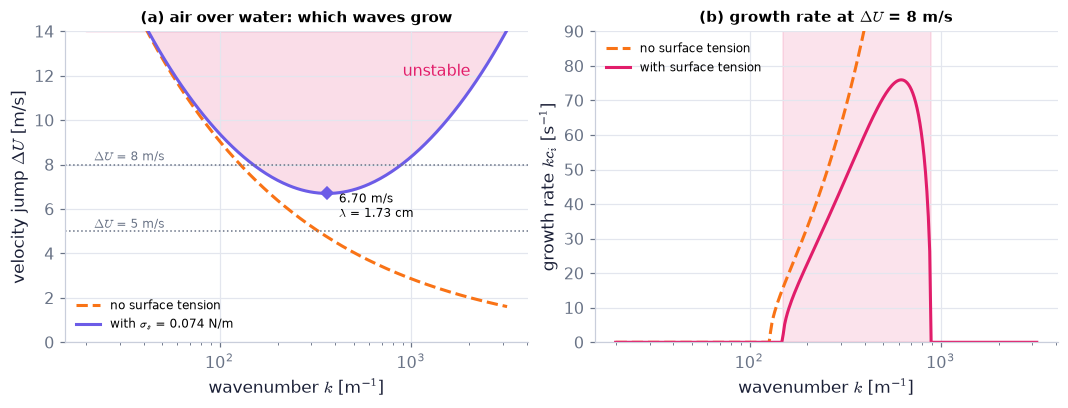

In [17]:
k = np.logspace(1.3, 3.5, 300)                                     # wavenumbers 20 ... 3000 1/m
dU0 = ch11.kh_stability_boundary(k, 1.2, 1000.0)                   # smallest unstable shear without surface tension [m/s]
dUs = ch11.kh_stability_boundary(k, 1.2, 1000.0, surface_tension=0.074)   # ... with surface tension 0.074 N/m
ms = ch11.kh_min_shear(1.2, 1000.0)                                # the minimum of that curve (D04): dU_min, k_star, wavelength
fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 3.6))   # the figure and its panels
a.fill_between(k, dUs, 14, color=C_GROW, alpha=0.15)   # shade the area between two curves
a.semilogx(k, dU0, "--", color=C_SHEAR, label="no surface tension")   # dashed: smallest wind that makes wavenumber k grow if only gravity resists
a.semilogx(k, dUs, color=C_NEUT, label=r"with $\sigma_s$ = 0.074 N/m")   # with surface tension: short waves are held too, so the curve turns up again
a.plot(ms["k_star"], ms["dU_min"], "D", color=C_NEUT)              # the diamond: the weakest wind that can raise any wave (D04)
a.text(ms["k_star"]*1.15, ms["dU_min"] - 1.1, f"{ms['dU_min']:.2f} m/s\n$\\lambda$ = {100*ms['wavelength']:.2f} cm", fontsize=8)   # a label written on the plot
for dU in (5.0, 8.0):                                              # our two winds
    a.axhline(dU, color=C_BASE, lw=1, ls=":")   # a reference line or band
    a.text(22, dU + 0.15, f"$\\Delta U$ = {dU:.0f} m/s", fontsize=8, color=C_BASE)   # a label written on the plot
a.text(900, 12, "unstable", color=C_GROW)   # a label written on the plot
a.set(xlabel="wavenumber $k$ [m$^{-1}$]", ylabel=r"velocity jump $\Delta U$ [m/s]", ylim=(0, 14))   # axis labels (with units) and fixed ranges for this panel
a.set_title("(a) air over water: which waves grow", fontsize=10)   # panel title — the message of this panel
a.legend(fontsize=8, loc="lower left")   # legend: one entry per curve
k1, k2 = ch11.kh_unstable_band(8.0, 1.2, 1000.0, surface_tension=0.074)   # the unstable wavenumbers at dU = 8 m/s [1/m]
b.axvspan(k1, k2, color=C_GROW, alpha=0.12)   # a reference line or band
b.semilogx(k, ch11.kh_growth_rate(k, 8.0, 0.0, 1.2, 1000.0), "--", color=C_SHEAR, label="no surface tension")   # dashed: growth rate at 8 m/s without surface tension - rises forever
b.semilogx(k, ch11.kh_growth_rate(k, 8.0, 0.0, 1.2, 1000.0, surface_tension=0.074), color=C_GROW, label="with surface tension")   # with surface tension: only a band of wavelengths grows
b.set(xlabel="wavenumber $k$ [m$^{-1}$]", ylabel="growth rate $kc_i$ [s$^{-1}$]", ylim=(0, 90))   # axis labels (with units) and fixed ranges for this panel
b.set_title(r"(b) growth rate at $\Delta U$ = 8 m/s", fontsize=10)   # panel title — the message of this panel
b.legend(fontsize=8)   # legend: one entry per curve
savefig(fig, "ch11", "c02_kh_boundary")   # keep a copy in outputs/ch11 and display
print(f"band at 8 m/s: k from {k1:.0f} to {k2:.0f} 1/m = wavelengths {100*2*np.pi/k2:.2f} to {100*2*np.pi/k1:.2f} cm")   # the two edges of the growing band, as wavenumbers and as wavelengths
print("thermocline (densities 1025 and 1027.05 kg/m^3, dU = 0.1 m/s): k_c =", round(ch11.kh_critical_k(0.1, 0.0, 1025.0, 1027.05), 2), "1/m")   # the same criterion for a weak density step in the ocean

**What does the code above do?**

1. `ch11.kh_stability_boundary(k, rho1, rho2, surface_tension=…)` solves "discriminant = 0" for the velocity jump.
2. `ch11.kh_min_shear` returns the bottom of the V (derived in D04 below); `ch11.kh_unstable_band` the two edges of the unstable
   band at a given jump.
3. `semilogx` uses a logarithmic $k$ axis (Ch. 1, P13), because wavelengths from 30 cm to 2 mm matter here.

**What you see.** (a) The smallest velocity jump that makes a wave of wavenumber $k$ grow: a falling line without surface tension (orange dashed), a V-shaped curve with it (purple) whose lowest point ◆ is at 6.70 m/s; the rose region is unstable. (b) The growth rate at 8 m/s: without surface tension it rises forever, with it only a band of wavelengths grows (shaded).

**How to read it.** A horizontal wind line that enters the rose region means: waves of those lengths grow. At 5 m/s the line stays below the purple curve — with surface tension nothing grows. At 8 m/s it cuts the curve twice: the band of panel (b).

**What would change if…** …the densities differ by only 0.2 % (an ocean thermocline, no surface tension) and the jump is 0.1 m/s: the last printed line gives $k_c\approx3.9$ m⁻¹, so every wave shorter than about 1.6 m grows.

**Slider figure F1 — the growth curve as the wind rises.** Every slider position is computed in advance (`slider_figure`,
Ch. 1 P17), so it also works on the web page.

In [18]:
kF = np.logspace(1.3, 3.5, 160)                                    # wavenumbers [1/m]

def f1(dU):                                                        # the two growth curves for one velocity jump dU [m/s]
    return {"no surface tension": (kF, ch11.kh_growth_rate(kF, dU, 0.0, 1.2, 1000.0)),                       # k c_i(k) from (11.18)
            "with surface tension 0.074 N/m": (kF, ch11.kh_growth_rate(kF, dU, 0.0, 1.2, 1000.0, surface_tension=0.074))}   # ... with the tension term

figF1 = slider_figure(f1, "ΔU", np.linspace(1.0, 12.0, 12 if FAST else 23), unit="m/s", xlabel="wavenumber k [1/m]",   # slider: the velocity jump
                      ylabel="growth rate k c_i [1/s]", title="Air over water: surface tension holds the short waves until 6.7 m/s",   # labels
                      yrange=(0, 80))                              # a fixed vertical range, so the curve is seen to rise
figF1.update_xaxes(type="log")                                     # logarithmic k axis
figF1.show()   # display the interactive slider figure

**What does the code above do?**

1. `f1(dU)` returns the two curves for one slider value; `slider_figure` calls it for every value now.
2. Drag ΔU: below 6.7 m/s the surface-tension curve is flat zero; above it a hump appears near $k\approx360$ m⁻¹ and widens.

#### 🧮 Derivation — Kelvin–Helmholtz with a lower layer of depth h and surface tension (Exercise 11.1), and the minimum wind $\Delta U_{\min}^2=2\sqrt{g\Delta\rho\,\sigma_s}(\rho_1+\rho_2)/(\rho_1\rho_2)$ `D04` ★★ (Eq. 11.18: $c=\frac{\rho_2U_2+\rho_1U_1}{\rho_2+\rho_1}\pm\Big[\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk-\frac{\rho_2\rho_1}{(\rho_2+\rho_1)^2}(U_2-U_1)^2\Big]^{1/2}$)

**What we want to show.** Add a bottom at depth h and surface tension to D03 and find the weakest shear that can make waves grow.

**Assumptions.** Small slopes (curvature ≈ ∂²ζ/∂x², step 4); constant surface tension σ_s [N/m].

**The plan.**

1. Replace the lower exponential by a cosh that meets the wall.
2. Add the surface-tension pressure jump.
3. Repeat D03's algebra.
4. Minimise the restoring terms over k.

**Tools we use** (each explained before this point): D03's moves · hyperbolic functions (P168) · the curvature of a plane curve (P169) for the pressure jump · minimising a/k + bk (step 8)

**We start from**

$$ \begin{array}{l}\phi_1=A_-\exp\{\mathrm ik(x-ct)-kz\},\ \phi_2=A_+\exp\{\mathrm ik(x-ct)+kz\}\qquad\text{(11.15)} \\[4pt] -\mathrm iU_1k\zeta_o-kA_-=-\mathrm ikc\zeta_o=-\mathrm iU_2k\zeta_o+kA_+\qquad\text{(11.16)} \\[4pt] \rho_1(-\mathrm ikcA_-+\mathrm ikU_1A_-+g\zeta_o)=\rho_2(-\mathrm ikcA_++\mathrm ikU_2A_++g\zeta_o)\qquad\text{(11.17)} \\[4pt] \text{and now a wall under the lower layer: }\frac{\partial\phi_2}{\partial z}=0\ \text{at}\ z=-h\end{array} $$

*In words:* the same two streams, a finite lower layer, a stretched interface.

---

**Step 1 of 9 — Choose the lower mode.**

$$ \phi_2=A_+\cosh k(z+h)\,e^{\mathrm ik(x-ct)} $$

- *Why we can do this:* cosh k(z + h) solves A″ = k²A (R07) and its z-derivative k sinh k(z + h) vanishes at z = −h: no flow through the bottom.
- *In words:* the lower disturbance fills the layer and stops at the floor.

---

**Step 2 of 9 — Apply the lower kinematic condition.**

$$ -\mathrm iU_2k\zeta_o+kA_+\sinh kh=-\mathrm ikc\zeta_o $$

- *Why we can do this:* as D03 step 5, now with ∂_zφ₂ = kA₊ sinh kh at z = 0.
- *In words:* the lower fluid follows the interface.

---

**Step 3 of 9 — Solve for A₊.**

$$ A_+=\frac{\mathrm i(U_2-c)\zeta_o}{\sinh kh},\quad\phi_2(z=0)=\mathrm i(U_2-c)\zeta_o\coth kh\, e^{\mathrm ik(x-ct)} $$

- *Why we can do this:* divide by k sinh kh ≠ 0; cosh kh/sinh kh = coth kh. A₋ is unchanged from D03 step 6.
- *In words:* depth enters only through coth kh.

---

**Step 4 of 9 — Add the surface-tension jump.**

$$ p_1-p_2=\sigma_s\frac{\partial^2\zeta}{\partial x^2}=-\sigma_sk^2\zeta $$

- *Why we can do this:* a stretched surface pushes toward its concave side with pressure σ_s × curvature (P169); for a small slope the curvature is ∂²ζ/∂x².
- *In words:* a crest is pushed down by the skin.

---

**Step 5 of 9 — Rewrite the dynamic condition.**

$$ \rho_1(\partial_t\phi_1+U_1\partial_x\phi_1+g\zeta)-\rho_2(\partial_t\phi_2+U_2 \partial_x\phi_2+g\zeta)=\sigma_sk^2\zeta $$

- *Why we can do this:* linearised Bernoulli gives $p_j=-\rho_j(\partial_t\phi_j+U_j\partial_x\phi_j+ g\zeta)$ plus constants; insert into step 4 at z = 0.
- *In words:* (11.13), $\rho_1\Big(\frac{\partial\phi_1}{\partial t}+U_1\frac{\partial\phi_1}{\partial x}+g\zeta\Big)=\rho_2\Big(\frac{\partial\phi_2}{\partial t}+U_2\frac{\partial\phi_2}{\partial x}+g\zeta\Big)\ \text{on}\ z=0$ plus the skin's push.

---

**Step 6 of 9 — Substitute the amplitudes.**

$$ \rho_1(U_1-c)^2+\rho_2\coth kh\,(U_2-c)^2=\frac gk(\rho_2-\rho_1)+\sigma_sk $$

- *Why we can do this:* the same products as D03 step 8 (the lower one carries coth kh); divide by kζ_o.
- *In words:* surface tension joins gravity on the restoring side.

---

**Step 7 of 9 — Solve the quadratic.**

$$ c=\frac{\rho_1U_1+\rho_2U_2\coth kh}{\rho_1+\rho_2\coth kh}\pm\Big[\frac{\frac gk(\rho_2-\rho_1)+ \sigma_sk}{\rho_1+\rho_2\coth kh}-\frac{\rho_1\rho_2(U_1-U_2)^2\coth kh}{(\rho_1+\rho_2\coth kh)^2}\Big]^{1/2} $$

- *Why we can do this:* write $\rho_2'\equiv\rho_2\coth kh$ and expand step 6 in powers of $c$: $(\rho_1+\rho_2')c^2-2(\rho_1U_1+\rho_2'U_2)c+\rho_1U_1^2+\rho_2'U_2^2-\frac gk(\rho_2-\rho_1)-\sigma_sk=0$. The quadratic formula and the identity $(\rho_1U_1+\rho_2'U_2)^2-(\rho_1+\rho_2')(\rho_1U_1^2+\rho_2'U_2^2)=-\rho_1\rho_2'(U_1-U_2)^2$ (the one of D03 step 12) give the line above.
- *In words:* Exercise 11.1's formula.

---

**Step 8 of 9 — Minimise the restoring side (deep).**

$$ \min_k\Big[\frac gk\Delta\rho+\sigma_sk\Big]=2\sqrt{g\Delta\rho\,\sigma_s}\ \text{at}\ k_*=\sqrt{g\Delta\rho/\sigma_s} $$

- *Why we can do this:* a/k + bk has derivative −a/k² + b = 0 at k = √(a/b), value 2√(ab); with h → ∞ (coth → 1) instability needs $\frac{\rho_1\rho_2\Delta U^2}{\rho_1+\rho_2}>\frac gk\Delta\rho+\sigma_sk$.
- *In words:* the weakest spot of the restoring forces is at one wavelength.

---

**Step 9 of 9 — Read off the minimum wind.**

$$ \Delta U_{\min}^2=\frac{2\sqrt{g\Delta\rho\,\sigma_s}(\rho_1+\rho_2)}{\rho_1\rho_2} $$

- *Why we can do this:* step 8's minimum equals the shear side there; solve for ΔU. With h → ∞ step 7 reduces to (11.18), $c=\frac{\rho_2U_2+\rho_1U_1}{\rho_2+\rho_1}\pm\Big[\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk-\frac{\rho_2\rho_1}{(\rho_2+\rho_1)^2}(U_2-U_1)^2\Big]^{1/2}$ plus σ_s k.
- *In words:* no shear below this value can make any wave grow.

---

**Result**

$$ \begin{array}{l}c=\frac{\rho_1U_1+\rho_2U_2\coth kh}{\rho_1+\rho_2\coth kh}\pm\Big[\frac{\frac gk(\rho_2-\rho_1)+\sigma_sk}{\rho_1+\rho_2\coth kh}-\frac{\rho_1\rho_2(U_1-U_2)^2\coth kh}{(\rho_1+\rho_2\coth kh)^2}\Big]^{1/2} \\[4pt] \Delta U_{\min}^2=\frac{2\sqrt{g\Delta\rho\,\sigma_s}(\rho_1+\rho_2)}{\rho_1\rho_2}\ \ \text{at}\ \ k_*=\sqrt{g\Delta\rho/\sigma_s}\quad(\text{deep water})\end{array} $$

*In words:* air over water with surface tension 0.074 N/m: the minimum wind is 6.70 m/s at a wavelength of 1.73 cm — gravity guards the long waves, surface tension the short ones; between them a minimum shear exists.

**What it means.** KH alone needs 6.7 m/s of wind; real ripples start at lower winds because turbulent pressure fluctuations (not in this model) do the work. Fails when the wind profile is not a jump (a boundary layer in the air).

**Check it.** Units: σ_s k/(ρ) [N/m × 1/m ÷ kg/m³ = m²/s²] ✓. Limits: σ_s = 0, h → ∞ gives (11.18), $c=\frac{\rho_2U_2+\rho_1U_1}{\rho_2+\rho_1}\pm\Big[\frac{\rho_2-\rho_1}{\rho_2+\rho_1}\frac gk-\frac{\rho_2\rho_1}{(\rho_2+\rho_1)^2}(U_2-U_1)^2\Big]^{1/2}$ ✓; ρ₁ = ρ₂, σ_s = 0 gives (11.20), $c=\frac{U_2+U_1}2\pm\mathrm i\frac{U_2-U_1}2$ ✓. Numbers: `ch11.kh_min_shear(1.2, 1000.0)` ✓.

> ⚠️ **Common confusion (traps in `D04`):** Using $e^{kz}$ for the lower layer (it ignores the bottom); the sign of the pressure jump (the skin pushes a crest down: it stabilises); forgetting that coth kh → 1 only when kh ≳ 3.

📝 **Note.** **N120 [B]** **Depth and surface tension (Exercise 11.1).** With a lower layer of depth $h$ and surface tension $\sigma_s$ [N/m]:
$c=\frac{\rho_1U_1+\rho_2U_2\coth kh}{\rho_1+\rho_2\coth kh}\pm\Big[\frac{(g/k)(\rho_2-\rho_1)+\sigma_sk}{\rho_1+\rho_2\coth kh}-
\frac{\rho_1\rho_2(U_1-U_2)^2\coth kh}{(\rho_1+\rho_2\coth kh)^2}\Big]^{1/2}$; $h\to\infty$ gives the deep-water relation plus the
$\sigma_sk$ term. Minimum wind for deep water: $\Delta U_{\min}^2=2\sqrt{g\Delta\rho\,\sigma_s}(\rho_1+\rho_2)/(\rho_1\rho_2)$ at
$k_*=\sqrt{g\Delta\rho/\sigma_s}$ (D04). Real wind waves start at lower winds: the turbulent wind's pressure fluctuations (the
mechanisms of Miles and Phillips, named only) do the job Kelvin–Helmholtz cannot.

In [19]:
print(ch11.kh_min_shear(1.2, 1000.0))                               # air over water: dU_min [m/s], k_star [1/m], wavelength [m]
print(ch11.kh_unstable_band(8.0, 1.2, 1000.0, surface_tension=0.074))   # unstable k-interval at 8 m/s [1/m]
print(ch11.kh_unstable_band(5.0, 1.2, 1000.0, surface_tension=0.074))   # at 5 m/s: (nan, nan) = no unstable wave
c_deep = ch11.kh_phase_speed(300.0, 8.0, 0.0, 1.2, 1000.0, surface_tension=0.074)[0]           # deep water, k = 300 1/m
c_shal = ch11.kh_phase_speed(300.0, 8.0, 0.0, 1.2, 1000.0, surface_tension=0.074, h=0.002)[0]  # the same over water only 2 mm deep
print("growth rate k c_i: deep", round(300*c_deep.imag, 2), "1/s | 2 mm of water", round(300*c_shal.imag, 2), "1/s")   # a shallow lower layer slows the growth of this wave

{'dU_min': 6.70258804424677, 'k_star': 363.81763363056024, 'wavelength': 0.017270150554494195}
(149.15136681283732, 887.4425583148472)
(nan, nan)
growth rate k c_i: deep 44.33 1/s | 2 mm of water 32.53 1/s


**What does the code above do?**

1. The minimum wind 6.70 m/s at $k_*=364$ m⁻¹ (wavelength 1.73 cm) — D04's result with numbers.
2. The band at 8 m/s is about 149–887 m⁻¹ (0.71–4.21 cm); at 5 m/s there is none (`nan` = "not a number" marks "no band").
3. The keyword `h` switches on the finite depth of the lower layer (the $\coth kh$ factors).

📝 **Note.** **N121 [B]** **Rayleigh–Taylor with surface tension (Exercise 11.2, our answer).** Heavy fluid above (paint on a ceiling): with $\rho_1>\rho_2$
every wave grows unless surface tension holds the short ones; the longest wave that stays neutral is
$\lambda_c=2\pi\sqrt{\sigma_s/((\rho_h-\rho_l)g)}$ — $2\pi$ times the *capillary length* $\sqrt{\sigma_s/((\rho_h-\rho_l)g)}$, the length at which surface tension and gravity are equally strong (about 2.7 mm for water in air) ($\rho_h$, $\rho_l$: heavy and light
densities). This is the cut-off of C01's figure.

In [20]:
lam_c = ch11.rayleigh_taylor_cutoff(0.074, 1000.0, 1.2)             # water above air, surface tension 0.074 N/m: cut-off wavelength [m]
print(f"lambda_c = {100*lam_c:.2f} cm: a water film on a ceiling holds only over patches smaller than this")   # the longest ceiling wave that surface tension can hold

lambda_c = 1.73 cm: a water film on a ceiling holds only over patches smaller than this


📝 **Note.** **N19 [B]** **The moving frame.** Seen from a frame moving at $(U_1+U_2)/2$ (Ch. 3's change of frame), the two streams are $\pm\Delta U/2$ —
a symmetric picture with no preferred direction, so the unstable wave cannot travel: for $\rho_1=\rho_2$ the real part of $c$ is
exactly the mean speed, $c_r=(U_1+U_2)/2$. With different densities the density-weighted mean
$(\rho_2U_2+\rho_1U_1)/(\rho_2+\rho_1)$ takes its place.

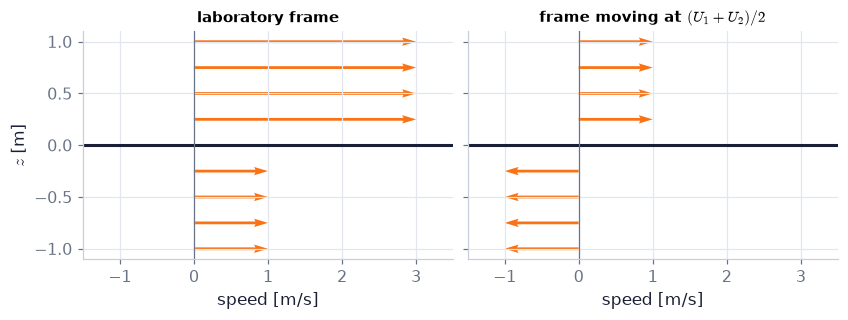

c for equal densities: ((2+1j), (2-1j))


In [21]:
U1, U2 = 3.0, 1.0                                                  # upper and lower stream speeds in the laboratory frame [m/s]
u_lab = lambda x, t: np.array([U1 if x[1] > 0 else U2, 0.0])      # the lab-frame velocity field: U1 above z = 0, U2 below
u_mov = KIN.galilean_transform(u_lab, np.array([(U1 + U2)/2, 0.0]))   # Ch. 3: the same flow seen from a frame moving at the mean speed
zz = np.linspace(-1, 1, 9)                                         # heights at which we draw arrows [m]
fig, axs = plt.subplots(1, 2, figsize=(7.6, 2.8), sharey=True)   # the figure and its panels
for ax, fn, ttl in ((axs[0], u_lab, "laboratory frame"), (axs[1], u_mov, "frame moving at $(U_1+U_2)/2$")):   # repeat the indented lines for each item listed
    uu = np.array([fn(np.array([0.0, z]), 0.0)[0] for z in zz if z != 0])   # horizontal speed at each height
    ax.quiver(np.zeros(len(uu)), [z for z in zz if z != 0], uu, 0*uu, angles="xy", scale_units="xy", scale=1, color=C_SHEAR)   # arrows / streamlines of the velocity
    ax.axhline(0, color=COLORS["ink"])   # a reference line or band
    ax.axvline(0, color=C_BASE, lw=0.8)   # a reference line or band
    ax.set(xlim=(-1.5, 3.5), xlabel="speed [m/s]")   # axis labels (with units) and fixed ranges for this panel
    ax.set_title(ttl, fontsize=10)   # the panel's title: what this panel shows
axs[0].set_ylabel("$z$ [m]")   # axis labels, with units where the quantity has them
plt.show()   # display the figure
print("c for equal densities:", ch11.vortex_sheet_c(U1, U2))       # (11.20): mean 2 m/s, plus/minus i (U2 - U1)/2

**What does the code above do?**

1. `KIN.galilean_transform(u, U)` (Ch. 3, P96) returns the velocity field seen from a frame moving at the constant velocity `U`.
2. `ch11.vortex_sheet_c(U1, U2)` is the equal-density limit (11.20), $c=\frac{U_2+U_1}2\pm\mathrm i\frac{U_2-U_1}2$.

**What you see.** Left: both streams move to the right, 3 m/s above and 1 m/s below. Right: the same flow seen by an observer moving at 2 m/s — +1 m/s above, −1 m/s below.

**How to read it.** In the moving frame the picture is mirror-symmetric, so a growing wave has no reason to drift either way: $c_r=0$ there, i.e. $c_r=2$ m/s in the laboratory — exactly the real part printed.

**What would change if…** …the lower layer is three times denser: the wave is carried more by the heavy layer, and $c_r$ becomes the density-weighted mean $(3\times1+1\times3)/4=1.5$ m/s.

📝 **Note.** **N20 [C]** **Shear against stratification in nature.** Laboratory tilting-tube experiments (Thorpe 1971), billow clouds and dye in ocean
thermoclines (Woods 1969) all show this instability; it is a main source of internal waves and of mixing across density
interfaces. With *continuous* stratification the question becomes the Richardson number — C09. Climate hook: Kelvin–Helmholtz
billows in the thermocline and in the stable night-time atmosphere are why mixing parameterisations switch on when the Richardson
number drops below about ¼ (Ch. 12, Ch. 13).

**Animation A2 — linear growth against the real roll-up.** Left: linear theory for a vortex sheet ($\rho_1=\rho_2$, jump
$\Delta U=1$, wavelength 1, so $k=2\pi$ and the growth rate is $k\Delta U/2=\pi$). We start from a pure displacement, which is an
equal mix of the growing mode and its decaying twin (N17), so the linear amplitude is $0.01\cosh(\pi t)$. Right: Ch. 5's point-vortex
sheet started from the same displacement.

In [22]:
nf = 14 if FAST else 18                                            # number of frames
tt = np.linspace(0.0, 2.0, nf)                                     # times [s] (wavelength 1 m, jump 1 m/s)
roll = ch05.sheet_rollup(N=80 if FAST else 100, gamma=1.0, amplitude=0.01, delta=0.05, t_eval=tt)   # the nonlinear sheet (Ch. 5)
a_lin = 0.01*np.cosh(np.pi*tt)                                     # linear amplitude: growing + decaying mode, rate k dU/2 = pi [1/s]
a_num = np.max(np.abs(roll["y"]), axis=1)                          # the largest displacement of the nonlinear sheet [m]
xs = np.linspace(0, 1, 200)                                        # one wavelength [m]
fig, (a, b) = plt.subplots(1, 2, figsize=(8.4, 3.2), sharey=True)   # the figure and its panels
(lin,) = a.plot(xs, 0.01*np.sin(2*np.pi*xs), color=C_GROW)         # the linear interface
(pts,) = b.plot(roll["x"][0] % 1.0, roll["y"][0], ".", ms=2.5, color=C_SHEAR)   # the point vortices
(env,) = b.plot(xs, 0.01*np.sin(2*np.pi*xs), "--", color=C_BASE, lw=1)          # the linear interface again, as a ghost
a.set(xlim=(0, 1), ylim=(-0.3, 0.3), xlabel="$x$ [m]", ylabel="$z$ [m]")   # axis labels (with units) and fixed ranges for this panel
a.set_title("linear theory", fontsize=10)   # panel title — the message of this panel
b.set(xlim=(0, 1), xlabel="$x$ [m]")   # axis labels (with units) and fixed ranges for this panel
ttl = b.set_title("point-vortex sheet (Ch. 5)", fontsize=10)   # panel title — the message of this panel

def update(i):                                                     # frame i: time tt[i]
    y_lin = np.clip(a_lin[i]*np.sin(2*np.pi*xs), -0.3, 0.3)        # linear interface, cut at the panel edge
    lin.set_ydata(y_lin)   # move the drawn data to this frame's values
    env.set_ydata(y_lin)   # move the drawn data to this frame's values
    pts.set_data(roll["x"][i] % 1.0, roll["y"][i])                 # move every vortex (positions folded into one wavelength)
    ttl.set_text(f"t = {tt[i]:.2f} s: linear {a_lin[i]:.3f} m, sheet {a_num[i]:.3f} m")   # update the title text for this frame
    return lin, env, pts, ttl   # the values for this call

show_animation(animate(update, frames=nf, fig=fig, interval=110), player="video", dpi=60)   # render the frames and show the animation
i10 = int(np.argmax(a_num > 0.05))                         # first frame with a sheet amplitude above 5 % of the wavelength
print(f"at t = {tt[i10]:.2f} s: linear {a_lin[i10]:.3f} m vs sheet {a_num[i10]:.3f} m; at the end: {a_lin[-1]:.2f} m vs {a_num[-1]:.3f} m")   # where the real sheet starts to lag the linear law, and how far apart they end

at t = 0.82 s: linear 0.067 m vs sheet 0.056 m; at the end: 2.68 m vs 0.197 m


**What does the code above do?**

1. `ch05.sheet_rollup(N, gamma, amplitude, delta, t_eval)` moves `N` point vortices of a periodic sheet (strength `gamma` = the
   velocity jump) from a sine displacement; `delta` smooths the singular kernel.
2. The linear amplitude is $0.01\cosh(\pi t)$: it grows exponentially forever.
3. The printed line compares the two when the sheet's amplitude passes 5 % of the wavelength, and at the end.

**What you see.** Two growing waves that agree at first; then the left one shoots off the panel while the right one folds over and winds into a spiral (a cat's eye).

**How to read it.** Linear theory is right until the amplitude is about a tenth of the wavelength; after that the slope is no longer small, the dropped quadratic terms matter, and the sheet rolls up instead of growing forever. (The sheet lags the ideal law slightly even early on, because the smoothing δ slows short-wave growth.)

**What would change if…** …we halve δ (less smoothing): the roll-up core tightens and forms earlier; the linear stage is the same.

📝 **Note.** **N21 [C] · N22 [B]** **Where the energy comes from.** The billows feed on the kinetic energy of the two streams. A mixing example: a stream $U_1$ over
still fluid, both of thickness $h$ and the same density $\rho$, mixed into a linear profile $U(z)=U_1(\tfrac12+\tfrac z{2h})$,
$-h\le z\le h$, keeps its momentum $\int\rho U\,dz=\rho U_1h$ but its kinetic energy drops from $E_i=\tfrac\rho2U_1^2h$ to
$E_f=\tfrac\rho2\int_{-h}^hU^2dz=\tfrac\rho3U_1^2h$ — a third is released, available to lift heavy fluid (mixing a stably
stratified interface raises the potential energy).

{'E_i': 500.0, 'E_f': 333.333, 'ratio': 0.667, 'M_i': 1000.0, 'M_f': 1000.0, 'E_f_quad': 333.333}


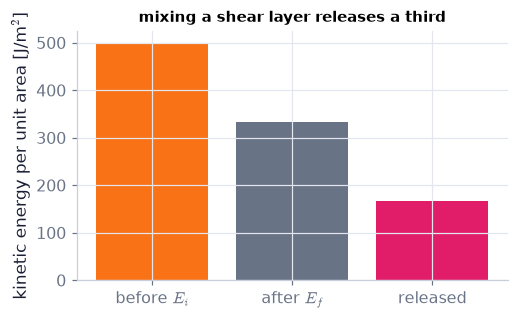

In [23]:
mix = ch11.kh_mixing_energy(1.0, 1.0, 1000.0)                       # U1 = 1 m/s, h = 1 m, rho = 1000 kg/m^3
E_f_quad = 0.5*1000.0*quad(lambda z: (1.0*(0.5 + z/2.0))**2, -1.0, 1.0)[0]   # the integral of U^2 done numerically (quad, Ch. 3 P87)
print({n: round(v, 3) for n, v in mix.items()})                     # energies [J/m^2], momenta [kg/(m s)], ratio E_f/E_i
assert np.isclose(E_f_quad, mix["E_f"])                             # quadrature = closed form rho U1^2 h / 3
fig, ax = plt.subplots(figsize=(4.6, 2.8))   # the figure and its panels
ax.bar(["before $E_i$", "after $E_f$", "released"], [mix["E_i"], mix["E_f"], mix["E_i"] - mix["E_f"]], color=[C_SHEAR, C_BASE, C_GROW])   # bars
ax.set(ylabel="kinetic energy per unit area [J/m$^2$]")   # axis labels (with units) and fixed ranges for this panel
ax.set_title("mixing a shear layer releases a third", fontsize=10)   # panel title — the message of this panel
plt.show()   # display the figure

**What does the code above do?**

1. `ch11.kh_mixing_energy(U1, h, rho)` returns the kinetic energy before (`E_i`) and after (`E_f`) mixing into the linear profile,
   their `ratio` (2/3), and the momentum before and after (`M_i` = `M_f`: mixing conserves momentum).
2. `scipy.integrate.quad` integrates $U^2$ numerically as a cross-check.
3. The bar chart: one third of the kinetic energy is released.

📝 **Note.** **N23 [C]** **A general rule** (named): for a fixed momentum $\int U\,dz$, smoothing the velocity gradients always lowers $\int U^2dz$
(Cauchy–Schwarz: $\int_{-h}^hU^2dz\ge(\int_{-h}^hU\,dz)^2/(2h)$, with equality only for a uniform flow), so mixing a shear layer
always releases kinetic energy. C14 shows how a growing wave taps that energy (the Reynolds stress).

#### 🎮 Interactive: Why does wind raise waves only above a threshold?

**Why interactive rather than a static figure:** Two sliders (velocity jump, density ratio) and two toggles (surface tension, finite depth) move both the stability boundary and
the current point; on the $c$-plane the two real wave speeds slide together, collide and split into a growing/decaying pair
exactly when the point crosses the boundary — the collision is the instability, and only motion shows it.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Preset 'air over water 5 m/s': stable. Drag ΔU up and stop when the status turns rose — read ΔU_min ≈ 6.7 m/s and λ ≈ 1.7 cm.
- Watch the c-plane while you cross the boundary: two dots on the real axis meet and leave it vertically.
- Turn surface tension off: the boundary becomes a falling line — every short wave grows (N18).

In [24]:
show_viz("ch11", "kelvin_helmholtz_boundary")   # full-width explainer; ⤢ Full screen for more room

[explainer ch11/kelvin_helmholtz_boundary]

*↪ **S01** — Exercises 11.3–11.5 (a porous surface, a compliant surface, membrane flutter) extend the interface
conditions of C02 to other boundaries; they are not solved here.*

**What would change if…** …instead of a velocity jump the fluid were at rest and heated from below? Then there is no shear to tap; the energy source is
buoyancy, and viscosity and heat diffusion fight it. The answer is a threshold number, the Rayleigh number — C03.

---

## 11.4 Thermal Instability: The Bénard Problem

**What is this section about?** Heat a layer of fluid from below: the bottom fluid expands, becomes lighter, and wants to rise —
yet a thin layer of honey on a warm plate stays still. Viscosity and heat diffusion resist; only when the heating beats them,
measured by one number, the Rayleigh number, does the layer overturn into convection cells. We set up the linear problem (C03),
find the threshold for rigid walls, Ra ≈ 1708 (C04), and solve the stress-free case by hand (C05). The same physics drives shallow
atmospheric convection on a sunny day, cloud streets, and convection in the ocean's mixed layer.

> 🔁 **Recap — The Boussinesq equations** (Ch. 4 §4.9). Density changes are kept only where they meet gravity (Ch. 4 §4.9): $\nabla\cdot\tilde{\mathbf u}=0$,
$\frac{\partial\tilde{\mathbf u}}{\partial t}+(\tilde{\mathbf u}\cdot\nabla)\tilde{\mathbf u}=-\frac1{\rho_0}\nabla\tilde p-g[1-\alpha(\tilde
T-T_0)]\mathbf e_z+\nu\nabla^2\tilde{\mathbf u}$, $\frac{\partial\tilde T}{\partial t}+(\tilde{\mathbf u}\cdot\nabla)\tilde T=\kappa\nabla^2\tilde T$
— Ch. 4's continuity, momentum and heat equations (4.10, 4.86, 4.89), $\nabla\cdot\mathbf u=0,\ \frac{D\mathbf u}{Dt}=-\frac1{\rho_0}\nabla p'+\frac{\rho'}{\rho_0}\mathbf g+\nu\nabla^2\mathbf u,\ \frac{DT}{Dt}=\kappa\nabla^2T$ written for the total fields (a tilde marks "total"), with
$\rho=\rho_0[1-\alpha(\tilde T-T_0)]$, $\alpha$ the thermal expansion coefficient [1/K], $\nu$ the kinematic viscosity and $\kappa$ the
thermal diffusivity [m²/s]. They are the starting line of D05.

> 🔁 **Recap — The conduction state** (Ch. 1 §1.7, Ch. 8). With no motion the momentum equation is hydrostatic and the heat equation says the temperature profile has no curvature:
$0=-\frac1{\rho_0}\nabla P-g[1-\alpha(\bar T-T_0)]\mathbf e_z$ and $0=\kappa\frac{\partial^2\bar T}{\partial z^2}$ (11.23) — Ch. 1's
hydrostatics and Ch. 8's steady conduction: a straight temperature line between the plates.

### 🧩 The Bénard amplitude problem $\big(\sigma+K^2-\frac{d^2}{dz^2}\big)\hat T=W$ and $\big(\frac\sigma\Pr+K^2-\frac{d^2}{dz^2}\big)\big(\frac{d^2}{dz^2}-K^2\big)W=-\mathrm{Ra}K^2\hat T$ (11.36, 11.37) `C03`

*The question:* A layer heated from below: which disturbances grow, and how fast?

#### The problem in plain words

A pan of water on a stove, a 5 mm layer of oil on a hot plate, the lowest kilometre of the atmosphere on a sunny morning: warm
fluid underneath, cool on top. A blob nudged upward finds itself warmer and lighter than its new surroundings and keeps rising —
unless viscosity slows it and heat leaks out of it first. We want to know, for a given layer, whether that tug-of-war is won, and
if so how fast the convection starts.

#### The idea

```
T₀ − ΔT  ─────────────── cold plate
          ↑ warm blob: buoyancy  gαT′           pushes it up      (∝ ΔT, d)
          │ viscosity ν∇²w                       holds it back
          │ heat leaks out: κ∇²T′                erases T′
T₀       ─────────────── hot plate
one number compares them:  Ra = buoyancy / (viscous × diffusive) = gαΓd⁴/(κν)
small disturbance + normal modes in x, y  ⇒  two ODEs in z  ⇒  σ is an EIGENVALUE that depends on (K, Ra, Pr)
```

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **sign of Γ: (11.21), $\mathrm{Ra}=\frac{g\alpha\Gamma d^4}{\kappa\nu}$ vs Kundu ch01 vs meteorology (slip #10)** — to change convention, negate the number and flip the inequality. *(Ch. 1, P48)*
- **scaling w ~ κ/d, buoyancy/viscous ~ Ra** — replace each term by its typical size to see which terms balance and which dimensionless number measures their ratio. *(Ch. 4, P130)*
- **divergence of a vector equation; commuting constant-coefficient operators** — for smooth fields derivatives can be taken in any order, so $\nabla^2$, $\partial_t$ and $\partial_z$ commute when the coefficients are constants. *(Ch. 4, P121)*
- **scaled variables and the chain rule** — writing $z=d\,z^*$ turns $\partial/\partial z$ into $(1/d)\,\partial/\partial z^*$; each derivative brings one factor of the scale. *(Ch. 4, P133)*
- **operator substitution ∂_t → σ, ∇_H² → −K²** — on a mode $e^{\mathrm i(kx+ly)+\sigma t}$ every derivative is a multiplication, so operators can be handled like numbers. *(Ch. 7, P177)*
- **eigenvalues and eigenvectors** — $A\mathbf v=\lambda\mathbf v$ with $\mathbf v\neq0$: the special numbers $\lambda$ for which a nonzero solution exists. *(Ch. 2, P80)*
- **generalised symmetric eigenproblem (contrast)** — $A\mathbf v=\lambda B\mathbf v$; with symmetric matrices (`eigh`) the eigenvalues are real — here the matrices are not symmetric and we need `eig`. *(Ch. 10, P247)*
- **collocation** — require the equation to hold exactly at a set of points; the unknowns are the values at those points. *(Ch. 6, P162)*
- **integration by parts with boundary terms** — $\int f\,g'\,dz=[fg]-\int f'\,g\,dz$; the bracket vanishes when $f$ or $g$ is zero at both ends. *(Ch. 9, P218a)*

📝 **Note.** **N24 [C]** **History.** Bénard's 1900 hexagons in millimetre-thin layers with a free surface were mostly driven by the variation of surface
tension with temperature (Marangoni convection), not by buoyancy (Drazin & Reid 1981); Rayleigh (1916) solved the buoyancy
problem with free surfaces, Jeffreys (1928) with rigid ones. The patterns themselves are N51.

📝 **Note.** **N25 [B]** **The Rayleigh number** $\mathrm{Ra}=g\alpha\Gamma d^4/\kappa\nu$ (11.21), with $g$ [m/s²], $\alpha$ thermal expansion [1/K],
$\Gamma=-d\bar T/dz$ [K/m] (positive when heated from below), $d$ depth [m], $\kappa$ thermal diffusivity [m²/s], $\nu$ kinematic
viscosity [m²/s] — dimensionless. Since $\Gamma=\Delta T/d$ (N28), $\mathrm{Ra}=g\alpha\,\Delta T\,d^3/(\kappa\nu)$.

> ⚠️ **Common confusion:** **which Γ?** (slip #10) The Rayleigh number $\mathrm{Ra}=g\alpha\Gamma d^4/\kappa\nu$ (11.21) uses $\Gamma\equiv-d\bar T/dz$ — the
*opposite* sign to Ch. 1's Kundu lapse rate $\Gamma\equiv dT/dz$; here Γ happens to agree with the meteorological $-dT/dz$.

| Convention | Definition | Our water layer ($d$ = 5 mm, bottom 2 K warmer) | Unstable side |
|---|---|---|---|
| this section | $\Gamma=-d\bar T/dz$ | $+400$ K/m | $\Gamma>0$ (heated from below) |
| Ch. 1 (Kundu) | $\Gamma=dT/dz$ | $-400$ K/m | $dT/dz<0$ |
| meteorology | $\Gamma_{met}=-dT/dz$ | $+400$ K/m | $\Gamma_{met}>0$ |

The code avoids the trap: it takes `dT` = T_bottom − T_top.

In [25]:
Ra_w = ch11.rayleigh_number(alpha=2.1e-4, dT=2.0, d=0.005, kappa=1.4e-7, nu=1.0e-6, g=9.81)    # 5 mm of water, bottom 2 K warmer: (11.21)
print(f"Ra = {Ra_w:.0f}")                                           # about 3679 (dimensionless)
print(ch11.gamma_conventions(2.0, 0.005))                           # the same gradient in the three conventions [K/m]
Ra_wrong = ch11.rayleigh_number(alpha=2.1e-4, dT=-2.0, d=0.005, kappa=1.4e-7, nu=1.0e-6, g=9.81)   # heated from ABOVE (top 2 K warmer)
print(f"heated from above: Ra = {Ra_wrong:.0f} (negative: stable to every disturbance)")   # the same layer heated from the wrong side: negative Rayleigh number

Ra = 3679
{'Gamma_11_21': 400.0, 'dTdz_kundu': -400.0, 'Gamma_met': 400.0}
heated from above: Ra = -3679 (negative: stable to every disturbance)


**What does the code above do?**

1. `ch11.rayleigh_number(alpha, dT, d, kappa, nu, g)` evaluates (11.21), $\mathrm{Ra}=\frac{g\alpha\Gamma d^4}{\kappa\nu}$ with `dT` = T_bottom − T_top [K].
2. `ch11.gamma_conventions(dT, d)` prints the one gradient in the three sign conventions: +400, −400, +400 K/m.
3. Reversing the heating flips the sign of Ra — a mistyped sign of Γ would turn a convecting layer into a stable one.

📝 **Note.** **N26 [B]** **Geometry**: a layer of depth $d$ between two plates, $z$ measured from the middle ($-d/2\le z\le d/2$), bottom at temperature
$T_0$, top at $T_0-\Delta T$.

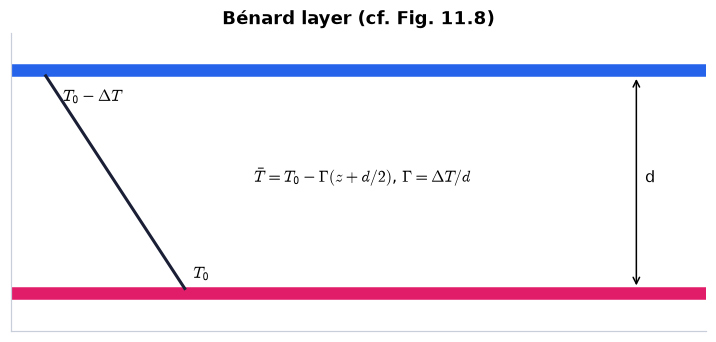

In [26]:
fig, ax = plt.subplots(figsize=(6.4, 3.0))   # the figure and its panels
benard_sketch(ax)                                                  # drawing only: the layer and its conduction temperature line
plt.show()   # display the figure

**What you see.** A fluid layer between a hot plate (below) and a cold plate (above), with the conduction temperature profile drawn beside it: a straight line, hottest at the bottom.

**How to read it.** The slope of that line, taken positive downward, is Γ = ΔT/d: the larger the temperature difference or the thinner the layer, the steeper the line.

**What would change if…** …we heat from above: the line tilts the other way, Ra < 0, and nothing can grow (the light fluid is already on top).

📝 **Note.** **N27 [B] · N28 [B]** **Base state plus disturbance:** $\tilde{\mathbf u}=0+\mathbf u(\mathbf x,t)$, $\tilde T=\bar T(z)+T'(\mathbf x,t)$,
$\tilde p=P(z)+p(\mathbf x,t)$ (11.22) — $\mathbf u=(u,v,w)$, $T'$, $p$ are the small disturbances. Integrating the conduction
equation twice between the plates gives the conduction profile $\bar T(z)=T_0-\tfrac12\Delta T-\Gamma z$, $\Gamma\equiv\Delta T/d$
(11.24).

In [27]:
base = ch11.benard_base_state(np.array([-0.0025, 0.0, 0.0025]), T0=300.0, dT=2.0, d=0.005)   # bottom, middle, top of a 5 mm layer [m]
print("conduction temperatures [K]:", base["T"])                    # 300, 299, 298 K: (11.24) with T0 = 300 K at the bottom

conduction temperatures [K]: [300. 299. 298.]


#### 🧮 Derivation — The linear perturbation equations from the Boussinesq set `D05` ★ (Eq. 11.27: $\frac{\partial T'}{\partial t}-w\Gamma=\kappa\nabla^2T'$)

**What we want to show.** Get the equations obeyed by small disturbances of a fluid at rest heated from below.

**Assumptions.** Boussinesq (ρ varies only in the buoyancy term); small disturbances (step 8).

**The plan.**

1. Insert base state + disturbance.
2. Subtract the base state's own equations.
3. Drop products of disturbances.

**Tools we use** (each explained before this point): The Boussinesq set (R12) · the conduction state (R13) · orders of smallness (P68)

**We start from**

$$ \begin{array}{l}\nabla\cdot\tilde{\mathbf u}=0\ \text{,}\ \frac{\partial\tilde{\mathbf u}}{\partial t}+(\tilde{\mathbf u}\cdot\nabla)\tilde{\mathbf u}= -\frac1{\rho_0}\nabla\tilde p-g[1-\alpha(\tilde T-T_0)]\mathbf e_z+\nu\nabla^2\tilde{\mathbf u}\ \text{,} \\ \frac{\partial\tilde T}{\partial t}+ (\tilde{\mathbf u}\cdot\nabla)\tilde T=\kappa\nabla^2\tilde T\ \text{(4.10, 4.86, 4.89)}\end{array} $$

*In words:* the Boussinesq equations of Ch. 4.

---

**Step 1 of 8 — Split every field.**

$$ \tilde{\mathbf u}=0+\mathbf u,\ \tilde T=\bar T(z)+T',\ \tilde p=P(z)+p\ \text{(11.22)} $$

- *Why we can do this:* the base state is at rest with conduction; u, T′, p are the disturbance.
- *In words:* total = background + disturbance.

---

**Step 2 of 8 — Insert into momentum.**

$$ \frac{\partial\mathbf u}{\partial t}+(\mathbf u\cdot\nabla)\mathbf u=-\frac{\nabla P+\nabla p} {\rho_0}-g[1-\alpha(\bar T-T_0)]\mathbf e_z+g\alpha T'\mathbf e_z+\nu\nabla^2\mathbf u $$

- *Why we can do this:* substitute (11.22), $\tilde{\mathbf u}=0+\mathbf u(\mathbf x,t),\ \tilde T=\bar T(z)+T'(\mathbf x,t),\ \tilde p=P(z)+p(\mathbf x,t)$; the buoyancy bracket splits into its base part and $+g\alpha T'\mathbf e_z$.
- *In words:* the disturbance feels the base forces plus its own buoyancy.

---

**Step 3 of 8 — Subtract the base balance.**

$$ \frac{\partial\mathbf u}{\partial t}+(\mathbf u\cdot\nabla)\mathbf u=-\frac1{\rho_0}\nabla p +g\alpha T'\mathbf e_z+\nu\nabla^2\mathbf u $$

- *Why we can do this:* (11.23), $0=-\frac1{\rho_0}\nabla P-g[1-\alpha(\bar T-T_0)]\mathbf e_z,\ \ 0=\kappa\frac{\partial^2\bar T}{\partial z^2}$ says $0=-\frac1{\rho_0}\nabla P-g[1-\alpha(\bar T-T_0)]\mathbf e_z$: the base pressure gradient cancels the base buoyancy exactly.
- *In words:* only the extra buoyancy of a warm blob drives motion.

---

**Step 4 of 8 — Insert into the heat equation.**

$$ \frac{\partial T'}{\partial t}+(\mathbf u\cdot\nabla)(\bar T+T')=\kappa\nabla^2\bar T+ \kappa\nabla^2T' $$

- *Why we can do this:* T̄ does not depend on t, so ∂_tT̃ = ∂_tT′.
- *In words:* the disturbance carries both temperatures.

---

**Step 5 of 8 — Use the conduction profile.**

$$ \kappa\nabla^2\bar T=\kappa\frac{d^2\bar T}{dz^2}=0 $$

- *Why we can do this:* (11.23)–(11.24), $0=-\frac1{\rho_0}\nabla P-g[1-\alpha(\bar T-T_0)]\mathbf e_z,\ \ 0=\kappa\frac{\partial^2\bar T}{\partial z^2},\ \bar T(z)=T_0-\tfrac12\Delta T-\Gamma z,\ \ \Gamma\equiv\Delta T/d$: T̄ is linear in z, $\bar T=T_0-\tfrac12\Delta T-\Gamma z$.
- *In words:* the background conducts heat steadily.

---

**Step 6 of 8 — Evaluate (u·∇)T̄.**

$$ (\mathbf u\cdot\nabla)\bar T=w\frac{d\bar T}{dz}=-w\Gamma $$

- *Why we can do this:* T̄ depends on z only, so only w∂_z survives; dT̄/dz = −Γ by (11.24), $\bar T(z)=T_0-\tfrac12\Delta T-\Gamma z,\ \ \Gamma\equiv\Delta T/d$. The sign comes from Γ = −dT̄/dz (slip #10's convention).
- *In words:* rising fluid (w > 0) brings warmer fluid from below, which the −wΓ term counts as a local warming.

---

**Step 7 of 8 — Collect the nonlinear set.**

$$ \frac{\partial T'}{\partial t}-w\Gamma+(\mathbf u\cdot\nabla)T'=\kappa\nabla^2T',\quad \nabla\cdot\mathbf u=0 $$

- *Why we can do this:* steps 4–6 combined; continuity holds for u because the base flow is zero.
- *In words:* the exact disturbance equations (p. 485).

---

**Step 8 of 8 — Drop products of disturbances.**

$$ \nabla\cdot\mathbf u=0,\ \frac{\partial\mathbf u}{\partial t}=-\frac1{\rho_0}\nabla p+ g\alpha T'\mathbf e_z+\nu\nabla^2\mathbf u,\ \frac{\partial T'}{\partial t}-w\Gamma=\kappa\nabla^2T'\ \text{(11.25)–(11.27)} $$

- *Why we can do this:* (u·∇)u and (u·∇)T′ are quadratic in the small disturbance (P68).
- *In words:* linear equations — waves of different shapes will not interact.

---

**Result**

$$ \begin{array}{l}\nabla\cdot\mathbf u=0\qquad\text{(11.25)} \\[4pt] \frac{\partial\mathbf u}{\partial t}=-\frac1{\rho_0}\nabla p+g\alpha T'\mathbf e_z+\nu\nabla^2\mathbf u\qquad\text{(11.26)} \\[4pt] \frac{\partial T'}{\partial t}-w\Gamma=\kappa\nabla^2T'\qquad\text{(11.27)}\end{array} $$

*In words:* a warm blob is pushed up by gαT′ and its temperature is fed by −wΓ.

**What it means.** The feedback loop of convection: w makes T′, T′ makes w. Fails for large ΔT (Boussinesq) and finite amplitude.

**Check it.** Units: each term of (11.26), $\frac{\partial\mathbf u}{\partial t}=-\frac1{\rho_0}\nabla p+g\alpha T'\mathbf e_z+\nu\nabla^2\mathbf u$ m/s², of (11.27), $\frac{\partial T'}{\partial t}-w\Gamma=\kappa\nabla^2T'$ K/s ✓. Sign: with w > 0 (rising) and Γ > 0, (11.27) gives ∂T′/∂t = +wΓ > 0: rising fluid is warmer than its surroundings — destabilising ✓ (`ch11.benard_perturbation_sympy`).

📝 **Notes taught inside `D05`:** **N29 [B]** the exact (nonlinear) disturbance equations, with the heating term from vertical motion (step 7) · **N30 [B]** the linearised set (step 8).

> ⚠️ **Common confusion (traps in `D05`):** The sign of the −wΓ term (Γ = −dT̄/dz, not dT̄/dz — slip #10); forgetting that the base pressure cancels the *whole* base buoyancy.

📝 **Note.** **N31 [B]** **Where Ra comes from (scaling).** In $\frac{\partial T'}{\partial t}-w\Gamma=\kappa\nabla^2T'$ (11.27) balance
$w\Gamma\sim\kappa\,\Delta T/d^2$ with $T'\sim\Delta T$ and $\nabla\sim1/d$: $w\sim\kappa/d$. Then in the momentum equation the
ratio of buoyancy to viscous force is $\sim\frac{g\alpha T'}{\nu w/d^2}\sim\frac{g\alpha\Gamma d^4}{\nu\kappa}=\mathrm{Ra}$
(order-of-magnitude scaling, Ch. 4 P130).

In [28]:
print({n: float(f"{v:.4g}") for n, v in ch11.benard_scales(alpha=2.1e-4, dT=2.0, d=0.005, kappa=1.4e-7, nu=1e-6, g=9.81).items()})   # water layer
Ra_air = ch11.rayleigh_number(alpha=1/293, dT=1.0, d=0.01, kappa=2.1e-5, nu=1.5e-5, g=9.81)   # 1 cm of air, 1 K across it
print(f"air gap of 1 cm: Ra = {Ra_air:.0f} per kelvin -> about {1708/Ra_air:.0f} K needed to reach Ra = 1708")   # how many kelvin an air gap needs to reach the threshold
print(f"water layer of 5 mm: Ra = {Ra_w/2:.0f} per kelvin -> about {1708/(Ra_w/2):.2f} K needed")   # ... and how few a thin water layer needs
Ra_w_1cm = ch11.rayleigh_number(alpha=2.1e-4, dT=1.0, d=0.01, kappa=1.4e-7, nu=1.0e-6, g=9.81)   # water at the SAME depth as the air gap
print(f"at equal depth (1 cm) and equal temperature difference: Ra(water)/Ra(air) = {Ra_w_1cm/Ra_air:.0f}")   # like for like: water convects about 140 times more readily than air

{'Ra': 3679.0, 'Pr': 7.143, 'Gamma': 400.0, 'w_scale': 2.8e-05, 't_scale': 178.6}
air gap of 1 cm: Ra = 106 per kelvin -> about 16 K needed to reach Ra = 1708
water layer of 5 mm: Ra = 1839 per kelvin -> about 0.93 K needed
at equal depth (1 cm) and equal temperature difference: Ra(water)/Ra(air) = 138


**What does the code above do?**

1. `ch11.benard_scales` returns Ra, the Prandtl number $\Pr=\nu/\kappa=7.14$ for water, Γ, the velocity scale
   $\kappa/d=2.8\times10^{-5}$ m/s and the time scale $d^2/\kappa=179$ s.
2. Air is much harder to set convecting than water: about 16 K across 1 cm of air against less than 1 K across 5 mm of water
   (the threshold 1708 is found in C04). At equal depth and equal temperature difference the Rayleigh number of water is about
   140 times that of air (the last printed line) — air's large $\kappa\nu$ outweighs its larger expansion coefficient.

#### 🧮 Derivation — Eliminating the pressure: $\frac{\partial}{\partial t}\nabla^2w=+g\alpha\nabla_H^2T'+\nu\nabla^4w$ `D06` ★★ (Eq. 11.29: $\frac{\partial}{\partial t}\nabla^2w=+g\alpha\nabla_H^2T'+\nu\nabla^4w$)

**What we want to show.** Get one equation for the vertical velocity w alone, without the unknown pressure.

**Assumptions.** Smooth fields (derivatives commute); incompressible disturbance (step 4).

**The plan.**

1. Take the Laplacian of the w-equation.
2. Find what the pressure must satisfy from the divergence of the momentum equation.
3. Subtract to remove the pressure.

**Tools we use** (each explained before this point): Divergence and Laplacian (Ch. 2) · constant-coefficient operators commute (Schwarz, P121) · Ch. 10's pressure Poisson idea

**We start from**

$$ \begin{array}{l}\text{The z-component of (11.26),}\ \frac{\partial w}{\partial t}=-\frac1{\rho_0}\frac{\partial p}{\partial z}+g\alpha T'+\nu\nabla^2w\ \text{, and}\ \nabla\cdot\mathbf u=0 \\ \text{(11.25)}\end{array} $$

*In words:* vertical momentum and continuity of the disturbance.

---

**Step 1 of 8 — Take the Laplacian of the w-equation.**

$$ \frac{\partial}{\partial t}\nabla^2w=-\frac1{\rho_0}\nabla^2\frac{\partial p} {\partial z}+g\alpha\nabla^2T'+\nu\nabla^4w\ \text{(11.28)} $$

- *Why we can do this:* ∇² commutes with ∂_t and ∂_z because the coefficients are constants (P121); we want a form in which the pressure appears as ∇²∂_zp.
- *In words:* the same balance, one level of derivatives higher.

---

**Step 2 of 8 — Take the divergence of (11.26).**

$$ \frac{\partial}{\partial t}\nabla\cdot\mathbf u=-\frac1{\rho_0}\nabla^2p+g\alpha \frac{\partial T'}{\partial z}+\nu\nabla^2(\nabla\cdot\mathbf u) $$

- *Why we can do this:* ∇·∇p = ∇²p, ∇·(T′e_z) = ∂_zT′, and the divergence commutes with ∂_t and ∇².
- *In words:* what the momentum equation says about the pressure.

---

**Step 3 of 8 — Use continuity.**

$$ 0=-\frac1{\rho_0}\nabla^2p+g\alpha\frac{\partial T'}{\partial z} $$

- *Why we can do this:* (11.25), $\nabla\cdot\mathbf u=0$ ∇·u = 0 kills both the ∂_t and the ν terms — the book uses this without comment.
- *In words:* the pressure is set by the buoyancy (a Poisson equation, as in Ch. 10's projection).

---

**Step 4 of 8 — Differentiate in z.**

$$ 0=-\frac1{\rho_0}\nabla^2\frac{\partial p}{\partial z}+g\alpha\frac{\partial^2T'}{\partial z^2} $$

- *Why we can do this:* we need ∇²∂_zp to match step 1; ∂_z commutes with ∇² (P121).
- *In words:* the pressure term of step 1, expressed by T′.

---

**Step 5 of 8 — Subtract step 4 from step 1.**

$$ \frac{\partial}{\partial t}\nabla^2w=g\alpha\Big(\nabla^2T'-\frac{\partial^2T'}{\partial z^2}\Big)+\nu\nabla^4w $$

- *Why we can do this:* the pressure terms are identical and cancel; that was the aim.
- *In words:* no pressure left.

---

**Step 6 of 8 — Recognise the horizontal Laplacian.**

$$ \nabla^2-\frac{\partial^2}{\partial z^2}=\frac{\partial^2}{\partial x^2}+ \frac{\partial^2}{\partial y^2}\equiv\nabla_H^2 $$

- *Why we can do this:* definition of ∇² in Cartesian coordinates.
- *In words:* only horizontal variations of T′ drive w.

---

**Step 7 of 8 — Write the result.**

$$ \frac{\partial}{\partial t}\nabla^2w=+g\alpha\nabla_H^2T'+\nu\nabla^4w\ \text{(11.29)} $$

- *Why we can do this:* steps 5–6. Nothing new is done here: we only write the outcome of the subtraction with the horizontal Laplacian named.
- *In words:* vertical motion is driven by horizontal temperature differences and damped by viscosity.

---

**Step 8 of 8 — Pair it with the heat equation.**

$$ \frac{\partial T'}{\partial t}-w\Gamma=\kappa\nabla^2T'\ \text{(11.27)} $$

- *Why we can do this:* (11.27), $\frac{\partial T'}{\partial t}-w\Gamma=\kappa\nabla^2T'$ and (11.29), $\frac{\partial}{\partial t}\nabla^2w=+g\alpha\nabla_H^2T'+\nu\nabla^4w$ are two equations for two unknowns, w and T′.
- *In words:* the closed linear problem of convection.

---

**Result**

$$ \begin{array}{l}\frac{\partial}{\partial t}\nabla^2w=+g\alpha\nabla_H^2T'+\nu\nabla^4w\qquad\text{(11.29)} \\[4pt] \frac{\partial T'}{\partial t}-w\Gamma=\kappa\nabla^2T'\qquad\text{(11.27)}\end{array} $$

*In words:* a uniformly warm layer does not move; side-to-side temperature differences do.

**What it means.** Convection cells need horizontal structure: the K of every later step.

**Check it.** Units: every term of (11.29), $\frac{\partial}{\partial t}\nabla^2w=+g\alpha\nabla_H^2T'+\nu\nabla^4w$ 1/(m s²) ✓. A horizontally uniform T′ (∇_H²T′ = 0) gives no forcing of w — correct, it only changes the hydrostatic pressure. A deliberately wrong variant (∇² instead of ∇_H²) fails `benard_perturbation_sympy` ✓.

📝 **Notes taught inside `D06`:** **N32 [B]** the Laplacian of the vertical momentum equation (step 1) · **N33 [B]** the pressure Poisson equation and its vertical derivative (steps 3–4) · **N34 [B]** the pressure-free equation for the vertical velocity (step 7).

> ⚠️ **Common confusion (traps in `D06`):** Forgetting to differentiate the Poisson equation in z (leaves ∇²T′ instead of ∇_H²T′ — the mistake the check cell below plants on purpose); dropping the ∂_t and ν terms of the divergence without citing ∇·u = 0.

In [29]:
chk = ch11.benard_perturbation_sympy()                              # D05-D07 redone with sympy on generic fields (cached after the first call)
print("residual of (11.29) after eliminating the pressure:", chk["eq_11_29_residual"])     # 0
print("planted mistake (full Laplacian instead of the horizontal one) leaves:", chk["planted_residual"])   # not 0
print("amplitude equations (11.36), (11.37) residuals:", chk["eq_11_36"], chk["eq_11_37"])   # 0 0 (used by D07 below)

residual of (11.29) after eliminating the pressure: 0
planted mistake (full Laplacian instead of the horizontal one) leaves: alpha*g*Derivative(T(x, y, z, t), (z, 2))
amplitude equations (11.36), (11.37) residuals: 0 0


**What does the code above do?**

1. `ch11.benard_perturbation_sympy()` repeats the pressure elimination symbolically; the residual 0 means D06's result is exactly
   what the moves give.
2. The planted variant — forgetting to differentiate the pressure equation in $z$, which leaves $\nabla^2T'$ instead of
   $\nabla_H^2T'$ — leaves a nonzero term, $g\alpha\,\partial^2T'/\partial z^2$: the check can tell right from wrong.

📝 **Note.** **N35 [B]** **Rigid isothermal walls:** $w=\partial w/\partial z=T'=0$ on $z=\pm d/2$ (11.30) — no slip gives $u=v=w=0$ on the whole plate, so
$\partial u/\partial x=\partial v/\partial y=0$ there, and continuity forces $\partial w/\partial z=0$.

> ⚠️ **Four ways this chapter makes things dimensionless — we are here: §11.4.** Lengths by $d$, time by $d^2/\kappa$, and the
> vertical velocity $w$ is left dimensional until the very last step of D07, where $W\equiv(\Gamma d^2/\kappa)\hat w$ makes Ra
> appear. (§11.6 will use the gap and $d^2/\nu$; §11.8–11.11 a length $L$ and $L/U_0$; §11.14 rescales once more — the table in
> the conventions cell at the top.)

#### 🧮 Derivation — Non-dimensional equations, normal modes and the amplitude problem `D07` ★ (Eq. 11.37: $\Big(\frac\sigma\Pr+K^2-\frac{d^2}{dz^2}\Big)\Big(\frac{d^2}{dz^2}-K^2\Big)W=-\mathrm{Ra}K^2\hat T$)

**What we want to show.** Turn (11.27), $\frac{\partial T'}{\partial t}-w\Gamma=\kappa\nabla^2T'$ and (11.29), $\frac{\partial}{\partial t}\nabla^2w=+g\alpha\nabla_H^2T'+\nu\nabla^4w$ into two ODEs in z with a single parameter, the Rayleigh number.

**Assumptions.** k, l real (bounded in x, y) — step 5.

**The plan.**

1. Scale lengths by d and time by d²/κ (keep w dimensional for now).
2. Insert normal modes in x, y, t.
3. Scale w to make Ra appear.

**Tools we use** (each explained before this point): Scaled variables and the chain rule (P133) · operator substitution on $e^{\mathrm i(kx+ly)+\sigma t}$ (P177)

**We start from**

$$ \begin{array}{l}\frac{\partial T'}{\partial t}-w\Gamma=\kappa\nabla^2T'\qquad\text{(11.27)} \\[4pt] \frac{\partial}{\partial t}\nabla^2w=+g\alpha\nabla_H^2T'+\nu\nabla^4w\qquad\text{(11.29)} \\[4pt] w=\frac{\partial w}{\partial z}=T'=0\ \text{on}\ z=\pm d/2\qquad\text{(11.30)}\end{array} $$

*In words:* the linear problem of D06 in dimensional form.

---

**Step 1 of 9 — Choose the scales.**

$$ t\to\frac{d^2}{\kappa}t,\ (x,y,z)\to(xd,yd,zd)\ \Rightarrow\ \frac{\partial}{\partial t}\to\frac\kappa {d^2}\frac{\partial}{\partial t},\ \nabla\to\frac1d\nabla $$

- *Why we can do this:* d is the only length and d²/κ the time heat needs to diffuse across it (P133); the book reuses the same symbols for the new variables.
- *In words:* measure in layer depths and diffusion times.

---

**Step 2 of 9 — Scale the heat equation.**

$$ \Big(\frac{\partial}{\partial t}-\nabla^2\Big)T'=\frac{\Gamma d^2}{\kappa}w\ \text{(11.31)} $$

- *Why we can do this:* every term of (11.27), $\frac{\partial T'}{\partial t}-w\Gamma=\kappa\nabla^2T'$ except wΓ gets κ/d²; divide by it. w stays dimensional on purpose.
- *In words:* heating by vertical motion against diffusion.

---

**Step 3 of 9 — Scale the w-equation.**

$$ \Big(\frac1\Pr\frac{\partial}{\partial t}-\nabla^2\Big)\nabla^2w=\frac{g\alpha d^2}\nu\nabla_H^2T'\ \text{(11.32)} $$

- *Why we can do this:* in (11.29), $\frac{\partial}{\partial t}\nabla^2w=+g\alpha\nabla_H^2T'+\nu\nabla^4w$ the left side gets κ/d⁴, the viscous term ν/d⁴, the buoyancy term gα/d²; divide by ν/d⁴; Pr ≡ ν/κ.
- *In words:* buoyancy against viscosity, with the Prandtl number on the time derivative.

---

**Step 4 of 9 — Scale the walls.**

$$ w=\partial w/\partial z=T'=0\ \text{on}\ z=\pm\tfrac12\ \text{(11.33)} $$

- *Why we can do this:* z = ±d/2 becomes ±½. The conditions themselves do not change; only the place where they hold is written in the new unit of length.
- *In words:* the same no-slip, fixed-temperature plates.

---

**Step 5 of 9 — Insert normal modes.**

$$ w=\hat w(z)e^{\mathrm ikx+\mathrm ily+\sigma t},\ T'=\hat T(z)e^{\mathrm ikx+\mathrm ily+\sigma t} $$

- *Why we can do this:* the coefficients do not depend on x, y, t (C01); k, l real keep the disturbance bounded.
- *In words:* one horizontal wave at a time.

---

**Step 6 of 9 — Replace the operators.**

$$ \frac{\partial}{\partial t}\to\sigma,\ \nabla_H^2\to-k^2-l^2\equiv-K^2,\ \nabla^2\to\frac{d^2}{dz^2}-K^2 $$

- *Why we can do this:* each derivative of the exponential multiplies it by the corresponding factor (P177).
- *In words:* derivatives in x, y, t become numbers.

---

**Step 7 of 9 — Write the amplitude equations.**

$$ \Big(\sigma+K^2-\frac{d^2}{dz^2}\Big)\hat T=\frac{\Gamma d^2}\kappa\hat w,\ \Big(\frac\sigma\Pr+ K^2-\frac{d^2}{dz^2}\Big)\Big(\frac{d^2}{dz^2}-K^2\Big)\hat w=-\frac{g\alpha d^2K^2}\nu\hat T\ \text{(11.34, 11.35)} $$

- *Why we can do this:* steps 2–3 with step 6, divided by the common exponential.
- *In words:* two linked ODEs in z.

---

**Step 8 of 9 — Rescale the velocity.**

$$ W\equiv\frac{\Gamma d^2}\kappa\hat w\ \Rightarrow\ \Big(\frac\sigma\Pr+K^2-\frac{d^2}{dz^2}\Big)\Big( \frac{d^2}{dz^2}-K^2\Big)W=-\mathrm{Ra}K^2\hat T $$

- *Why we can do this:* multiply (11.35), $\Big(\frac\sigma\Pr+K^2-\frac{d^2}{dz^2}\Big)\Big(\frac{d^2}{dz^2}-K^2\Big)\hat w=-\frac{g\alpha d^2K^2}\nu\hat T$ by Γd²/κ: the right side becomes $-\frac{g\alpha\Gamma d^4}{\nu\kappa}K^2\hat T=-\mathrm{Ra}K^2\hat T$ by (11.21), $\mathrm{Ra}=\frac{g\alpha\Gamma d^4}{\kappa\nu}$; the first equation becomes $(\sigma+K^2-\frac{d^2}{dz^2})\hat T=W$.
- *In words:* all the physics now sits in one number, Ra (11.36, 11.37), $\Big(\sigma+K^2-\frac{d^2}{dz^2}\Big)\hat T=W,\ \Big(\frac\sigma\Pr+K^2-\frac{d^2}{dz^2}\Big)\Big(\frac{d^2}{dz^2}-K^2\Big)W=-\mathrm{Ra}K^2\hat T$.

---

**Step 9 of 9 — Write the conditions.**

$$ W=\frac{dW}{dz}=\hat T=0\ \text{on}\ z=\pm\tfrac12\ \text{(11.38)} $$

- *Why we can do this:* (11.33), $w=\frac{\partial w}{\partial z}=T'=0\ \text{on}\ z=\pm\tfrac12$ for the amplitudes. The walls are the same for every horizontal wave, so the conditions pass unchanged to the amplitudes; W is a multiple of the velocity amplitude.
- *In words:* a sixth-order eigenvalue problem with eigenvalue σ.

---

**Result**

$$ \begin{array}{l}\Big(\sigma+K^2-\frac{d^2}{dz^2}\Big)\hat T=W\qquad\text{(11.36)} \\[4pt] \Big(\frac\sigma\Pr+K^2-\frac{d^2}{dz^2}\Big)\Big(\frac{d^2}{dz^2}-K^2\Big)W=-\mathrm{Ra}K^2\hat T\qquad\text{(11.37)} \\[4pt] W=\frac{dW}{dz}=\hat T=0\ \text{on}\ z=\pm\tfrac12\qquad\text{(11.38)}\end{array} $$

*In words:* growth rate σ(K, Ra, Pr).

**What it means.** The whole of Bénard convection is one eigenvalue problem with three numbers; C03's code solves it.

**Check it.** Dimensionless: every term of the two amplitude equations is a pure number ✓. Pr appears only next to σ ✓ (so σ = 0 removes it).

📝 **Notes taught inside `D07`:** **N36 [B]** the non-dimensional equations and the Prandtl number (steps 2–4) · **N37 [B]** derivatives of a normal mode become numbers (step 6) · **N38 [B]** the amplitude equations before the velocity is rescaled (step 7).

> ⚠️ **Common confusion (traps in `D07`):** Expecting Ra before W is introduced (it appears only at step 8); forgetting that ∂_t brings κ/d², not 1/d.

> 📎 **Primer — eigenvalue problem for a differential equation.** `P257` · In Ch. 2 an eigenvalue problem was a matrix equation $A\mathbf v=\lambda\mathbf v$ with a nonzero $\mathbf v$. Here it is an ODE
with boundary conditions, like $-u''=\lambda u$ with $u(0)=u(\pi)=0$: for most $\lambda$ the only solution is $u=0$; only for
special $\lambda$ (here $\lambda=1,4,9,\dots$ with $u=\sin nz$) does a nonzero solution meet every boundary condition. Those
$\lambda$ are the eigenvalues, and the nonzero solution that goes with each one is its *eigenfunction* (its *mode shape*). In the amplitude problem above the growth rate $\sigma$ plays $\lambda$: only special $\sigma$
allow a nonzero $(W,\hat T)$.

In [30]:
import numpy as np                                    # arrays
z = np.linspace(0, np.pi, 5)                          # five points from 0 to pi
for n in (1, 2):                                      # u = sin(n z) meets u(0) = u(pi) = 0 ...
    print(n**2, np.allclose(np.sin(n*z)[[0, -1]], 0)) # ... and -u'' = n^2 u: eigenvalues 1 and 4, both True

1 True
4 True


📝 **Note.** **N39 [B]** **Boundary conditions for the amplitudes:** $W=\frac{dW}{dz}=\hat T=0$ on $z=\pm\tfrac12$ (11.38). With the two amplitude
equations this is a sixth-order problem in $z$ whose eigenvalue is $\sigma$.

> 📎 **Primer — Chebyshev–Gauss–Lobatto points and the differentiation matrix.** `P258` · To turn an ODE into a matrix problem we sample the unknown at $N+1$ points $x_j=\cos(j\pi/N)$ — crowded near the ends — and
replace $d/dx$ by a matrix $D$ that differentiates the polynomial through those values exactly. Because the points are Chebyshev
points, the error falls *exponentially* with $N$ for smooth solutions (spectral accuracy) — far faster than Ch. 10's second-order
stencils. $D^2$ is `D @ D`; for $z\in[-\tfrac12,\tfrac12]$ the matrix is just rescaled by 2. Note the order: `x[0]` is the right
(top) end.

In [31]:
import numpy as np                                    # arrays
from fluidpy.core import stability as ST              # the eigen-solver toolkit
D, x = ST.cheb(4)                                     # 5 points: 1, 0.707, 0, -0.707, -1 and the 5 x 5 matrix D
print(np.round(x, 3))                                 # the Chebyshev points, from +1 down to -1
print(np.max(np.abs(D @ x**3 - 3*x**2)))              # ~1e-15: D differentiates polynomials up to degree N exactly

[ 1.     0.707  0.    -0.707 -1.   ]
8.881784197001252e-16


> 📎 **Primer — boundary-row replacement and the generalised non-symmetric eigenproblem scipy.linalg.eig(A, B).** `P259` · Collocation turns the ODEs into $A\mathbf v=\sigma B\mathbf v$. Boundary conditions replace the rows at the end points: in $A$ the
row becomes the condition (for example $[1,0,\dots,0]$ for $W=0$), in $B$ the row becomes zero — so those rows say "0 = condition"
for every $\sigma$. $B$ is then singular and `scipy.linalg.eig(A, B)` returns some infinite eigenvalues (drop them) and, at larger
$N$, a few huge spurious ones caused by round-off (keep only eigenvalues that do not move when $N$ grows). Unlike Ch. 10's `eigh`
(P247: symmetric matrices, real eigenvalues), $A$ and $B$ are not symmetric here, so eigenvalues can be complex.

In [32]:
import numpy as np                                    # arrays
from scipy.linalg import eig                          # the generalised eigen-solver
A = np.array([[2.0, 1.0], [1.0, 1.0]])                # a 2 x 2 example
B = np.array([[1.0, 0.0], [0.0, 0.0]])                # its second row is a 'boundary row': zero in B
print(eig(A, B, right=False))                         # [1, inf]: the boundary row gives an infinite eigenvalue

[ 1.+0.j inf+0.j]


#### ✏️ Tiny example: a 5 mm water layer on a hot plate

$d=5$ mm, $\Delta T=2$ K, $\alpha=2.1\times10^{-4}$ K⁻¹, $\kappa=1.4\times10^{-7}$ m²/s, $\nu=1.0\times10^{-6}$ m²/s, $g=9.81$ m/s².

1. $\Gamma=\Delta T/d=400$ K/m.
2. $\mathrm{Ra}=g\alpha\,\Delta T\,d^3/(\kappa\nu)=9.81\times2.1\times10^{-4}\times2\times1.25\times10^{-7}/(1.4\times10^{-7}\times10^{-6})
   =5.15\times10^{-10}/1.4\times10^{-13}\approx3679$.
3. $\Pr=\nu/\kappa=7.14$.
4. Time unit $d^2/\kappa=25\times10^{-6}/1.4\times10^{-7}=179$ s.
5. The code below finds the largest growth rate $\sigma\approx19.9$ (in units of $\kappa/d^2$) at $K=3.12$: dimensional
   $\sigma=19.9/179\ \text{s}\approx0.111$ s⁻¹, so a disturbance grows by $e$ every ≈ 9 s.
6. Halve $\Delta T$ to 1 K: $\mathrm{Ra}=1839$, just above 1708 — the growth almost stops (C04).

In [33]:
Ra = ch11.rayleigh_number(alpha=2.1e-4, dT=2.0, d=0.005, kappa=1.4e-7, nu=1e-6, g=9.81)   # the worked example: Ra = 3679 (11.21)
Pr = 1e-6/1.4e-7                                                    # Prandtl number nu/kappa = 7.14 for water
sig = ch11.benard_growth_rate(3.1163, Ra, Pr, all=True)             # every converged growth rate at K = 3.1163 [units kappa/d^2]
print("three largest growth rates:", np.round(sig[:3], 4))   # one positive growth rate (it grows), all others negative (they decay)
for N in (16, 24, 32, 40):                                          # how many digits does the leading one gain with N?
    print(f"  N = {N}: sigma_1 = {ch11.benard_growth_rate(3.1163, Ra, Pr, N=N):.9f}")   # the leading growth rate does not change with the number of points
sig_c = ch11.benard_growth_rate(3.1163, Ra, Pr, all=True, return_complex=True)   # the same spectrum as complex numbers
print("largest imaginary part among the five leading ones:", np.max(np.abs(np.imag(sig_c[:5]))))   # 0: all real (D08 proves it)
print(f"e-folding time = (d^2/kappa)/sigma_1 = {0.005**2/1.4e-7/sig[0]:.2f} s;  at Ra = 1000: sigma_1 = {ch11.benard_growth_rate(3.1163, 1000.0, Pr):.2f}")   # the growth rate turned into seconds; and a layer below the threshold for contrast

three largest growth rates: [ 19.8666 -41.4987 -95.421 ]
  N = 16: sigma_1 = 19.866589840
  N = 24: sigma_1 = 19.866589839
  N = 32: sigma_1 = 19.866589839


  N = 40: sigma_1 = 19.866589843
largest imaginary part among the five leading ones: 0.0


e-folding time = (d^2/kappa)/sigma_1 = 8.99 s;  at Ra = 1000: sigma_1 = -7.80


**What does the code above do?**

1. Ra from (11.21), $\mathrm{Ra}=\frac{g\alpha\Gamma d^4}{\kappa\nu}$ and Pr for the water layer.
2. `ch11.benard_growth_rate(K, Ra, Pr, all=True)` builds the two amplitude equations with the rigid conditions as a generalised
   eigenproblem on Chebyshev points (P258, P259) and returns the growth rates, largest first: one positive, the rest negative.
3. The leading eigenvalue is the same to nine digits from $N=16$ to $N=40$ — spectral accuracy.
4. `return_complex=True` shows the imaginary parts: zero. Convection starts in place, it does not oscillate (D08).
5. In seconds: the disturbance grows by a factor $e$ about every 9 s; at Ra = 1000 the leading growth rate is negative — every
   disturbance decays.

In [34]:
def cheb_mine(N):                                                   # Trefethen's Chebyshev differentiation matrix on [-1, 1]
    j = np.arange(N + 1)                                            # point indices 0 ... N
    xc = np.cos(np.pi*j/N)                                          # the Chebyshev points x_j = cos(j pi/N)
    cj = np.where((j == 0) | (j == N), 2.0, 1.0)*(-1.0)**j          # weights c_j (-1)^j, with c = 2 at the two ends
    dX = xc[:, None] - xc[None, :]                                  # all differences x_i - x_j
    Dm = np.outer(cj, 1.0/cj)/(dX + np.eye(N + 1))                  # off-diagonal entries c_i (-1)^(i+j) / (c_j (x_i - x_j))
    return Dm - np.diag(Dm.sum(axis=1)), xc                         # diagonal = minus the sum of the row (a constant has zero derivative)

D8, x8 = cheb_mine(8)                                               # 9 points
assert np.allclose(D8, ST.cheb(8)[0]) and np.allclose(D8 @ x8**3, 3*x8**2)   # same matrix as the library; exact for x^3

def benard_spectrum_mine(K, Ra, Pr, N):                             # the amplitude problem (11.36)-(11.38) as A v = sigma B v, v = [W; T]
    Dz = 2.0*cheb_mine(N)[0]                                        # d/dz on z in [-1/2, 1/2]: the interval is half as long, so D doubles
    I = np.eye(N + 1)                                               # identity
    L = Dz @ Dz - K**2*I                                            # the operator d^2/dz^2 - K^2
    A = np.block([[L @ L, -Ra*K**2*I], [I, L]])                     # (11.37): L^2 W - Ra K^2 T = (sigma/Pr) L W;  (11.36): W + L T = sigma T
    B = np.block([[L/Pr, 0*I], [0*I, I]])                           # the terms multiplied by sigma
    for r, row in ((0, I[0]), (N, I[N]), (1, Dz[0]), (N - 1, Dz[N])):   # W = 0 and dW/dz = 0 at both walls (11.38)
        A[r, :] = 0.0; A[r, :N + 1] = row; B[r, :] = 0.0            # row replacement (P259): condition in A, zeros in B
    for r in (N + 1, 2*N + 1):                                      # T = 0 at both walls
        A[r, :] = 0.0; A[r, r] = 1.0; B[r, :] = 0.0   # this row now says 'temperature amplitude = 0 at the wall' for every sigma
    lam = linalg.eig(A, B, right=False)                             # generalised eigenvalues (some infinite, from the boundary rows)
    return lam[np.isfinite(lam)]                                    # drop the infinite ones

lam24 = benard_spectrum_mine(3.1163, Ra, Pr, 24)                    # our own spectrum with N = 24
mine = np.max(lam24[np.abs(lam24) < 1e4].real)                      # leading growth rate among the eigenvalues of reasonable size
assert np.isclose(mine, ch11.benard_growth_rate(3.1163, Ra, Pr, N=24), rtol=1e-8)   # same number -> the library does exactly this
print(f"from scratch (N = 24): sigma_1 = {mine:.8f}")   # our own matrices give the library's growth rate

from scratch (N = 24): sigma_1 = 19.86658984

**What does the code above do?**

1. `cheb_mine` is the Chebyshev matrix in six lines; the assertion shows it equals `ST.cheb` and differentiates $x^3$ exactly.
2. `benard_spectrum_mine` assembles the two amplitude equations in block form for the unknown vector $[W;\hat T]$, replaces six
   rows by the six boundary conditions (P259) and calls `scipy.linalg.eig(A, B)`.
3. The leading eigenvalue agrees with `ch11.benard_growth_rate` to eight digits. (The library eliminates the boundary unknowns
   instead of replacing rows, which removes the spurious eigenvalues you will see in the next figure.)

> 📎 **Primer — real and imaginary parts of a complex identity.** `P260` · One complex equation is two real equations: its real parts agree and its imaginary parts agree. Three facts do most of the work in
this chapter: (i) $\int\lvert f\rvert^2dz>0$ unless $f\equiv0$ (a sum of non-negative numbers); (ii)
$\frac1{U-c}=\frac{U-c^*}{\lvert U-c\rvert^2}$, so $\mathrm{Im}\frac1{U-c}=\frac{c_i}{\lvert U-c\rvert^2}$ for real $U$ (multiply
top and bottom by the conjugate, Ch. 2 P81); (iii) a real quantity times $c_i$ is zero only if $c_i=0$ or the quantity vanishes.

In [35]:
import numpy as np                                    # arrays
U, c = 0.3, 0.1 + 0.2j                                # a real velocity and a complex wave speed
print(np.imag(1/(U - c)), c.imag/abs(U - c)**2)       # both 2.5: Im{1/(U - c)} = c_i/|U - c|^2

2.5 2.5


#### 🧮 Derivation — σ is real for Ra > 0 — exchange of stabilities (Exercise 11.6) `D08` ★★ (Eq. 11.37: $\Big(\frac\sigma\Pr+K^2-\frac{d^2}{dz^2}\Big)\Big(\frac{d^2}{dz^2}-K^2\Big)W=-\mathrm{Ra}K^2\hat T$)

**What we want to show.** Show that heated-from-below convection can only start as a stationary pattern: the growth rate σ has no imaginary part.

**Assumptions.** Ra > 0 (heated from below), used in step 12; the rigid conditions (11.38), $W=\frac{dW}{dz}=\hat T=0\ \text{on}\ z=\pm\tfrac12$ (free walls work too). Notation in the steps: all integrals over −½ ≤ z ≤ ½; D ≡ d/dz.

**The plan.**

1. Multiply each equation by the conjugate of its unknown and integrate over the layer.
2. Integrate by parts to get positive integrals.
3. Combine the two relations so the mixed integral cancels.
4. Take the imaginary part.

**Tools we use** (each explained before this point): Integration by parts (P218a reminder) · real and imaginary parts of a complex identity (P260) · ∫∣f∣² > 0 (P260)

**We start from**

$$ \begin{array}{l}\Big(\sigma+K^2-\frac{d^2}{dz^2}\Big)\hat T=W\qquad\text{(11.36)} \\[4pt] \Big(\frac\sigma\Pr+K^2-\frac{d^2}{dz^2}\Big)\Big(\frac{d^2}{dz^2}-K^2\Big)W=-\mathrm{Ra}K^2\hat T\qquad\text{(11.37)} \\[4pt] W=\frac{dW}{dz}=\hat T=0\ \text{on}\ z=\pm\tfrac12\qquad\text{(11.38)} \\[4pt] \text{with a complex growth rate allowed: }\sigma=\sigma_r+\mathrm i\sigma_i\end{array} $$

*In words:* the amplitude problem of D07.

---

**Step 1 of 12 — Multiply (11.36) by T̂* and integrate.**

$$ \sigma\int\lvert\hat T\rvert^2dz+\int\hat T^*(K^2-D^2)\hat T\,dz=\int\hat T^*W\,dz $$

- *Why we can do this:* multiplying by the conjugate and integrating turns functions into numbers whose signs we can read (P260).
- *In words:* an 'energy' version of the heat equation.

---

**Step 2 of 12 — Integrate the D² term by parts.**

$$ -\int\hat T^*\hat T''dz=\big[-\hat T^*\hat T'\big]_{-1/2}^{1/2}+\int\lvert\hat T'\rvert^2dz= \int\lvert\hat T'\rvert^2dz $$

- *Why we can do this:* P218a; the boundary term vanishes because T̂ = 0 at both walls (11.38), $W=\frac{dW}{dz}=\hat T=0\ \text{on}\ z=\pm\tfrac12$.
- *In words:* a curvature term becomes a positive gradient term.

---

**Step 3 of 12 — Name the positive integrals.**

$$ \sigma I_1+I_2=\int\hat T^*W\,dz,\quad I_1=\int\lvert\hat T\rvert^2,\ I_2=\int(\lvert \hat T'\rvert^2+K^2\lvert\hat T\rvert^2) $$

- *Why we can do this:* steps 1–2; I₁, I₂ are real and positive for a nonzero T̂ (P260).
- *In words:* Exercise 11.6's first relation.

---

**Step 4 of 12 — Rewrite (11.37).**

$$ \frac\sigma\Pr(D^2-K^2)W-(D^2-K^2)^2W=-\mathrm{Ra}K^2\hat T $$

- *Why we can do this:* expand $(\frac\sigma\Pr+K^2-D^2)=\frac\sigma\Pr-(D^2-K^2)$. Sorting by σ separates the part that carries the unknown growth rate from the part that does not.
- *In words:* the same equation, sorted by σ.

---

**Step 5 of 12 — Multiply by −W* and integrate.**

$$ -\frac\sigma\Pr\int W^*(D^2-K^2)W+\int W^*(D^2-K^2)^2W=\mathrm{Ra}K^2\int W^*\hat T $$

- *Why we can do this:* the same idea as step 1, with a sign chosen so the integrals come out positive.
- *In words:* an energy version of the w-equation.

---

**Step 6 of 12 — Integrate the first term by parts.**

$$ -\int W^*(D^2-K^2)W\,dz=\int(\lvert W'\rvert^2+K^2\lvert W\rvert^2)dz\equiv J_1 $$

- *Why we can do this:* as step 2, using W = 0 at the walls.
- *In words:* a positive number.

---

**Step 7 of 12 — Move both D² across in the second.**

$$ \int W^*(D^2-K^2)G\,dz=\int G\,(D^2-K^2)W^*dz,\quad G\equiv(D^2-K^2)W $$

- *Why we can do this:* two integrations by parts; the boundary terms contain W and W′, both zero at rigid walls (11.38), $W=\frac{dW}{dz}=\hat T=0\ \text{on}\ z=\pm\tfrac12$.
- *In words:* the operator can act on the other factor.

---

**Step 8 of 12 — Recognise a squared modulus.**

$$ \frac\sigma\Pr J_1+J_2=\mathrm{Ra}K^2\int W^*\hat T\,dz,\quad J_2=\int\lvert(D^2-K^2)W\rvert^2dz $$

- *Why we can do this:* $(D^2-K^2)W^*$ is the conjugate of G, so G times it is ∣G∣² ≥ 0.
- *In words:* Exercise 11.6's second relation.

---

**Step 9 of 12 — Conjugate the first relation.**

$$ \sigma^*I_1+I_2=\int\hat T\,W^*dz $$

- *Why we can do this:* I₁, I₂ are real; conjugating swaps the stars on the right — now it matches the right side of step 8.
- *In words:* the same mixed integral appears in both.

---

**Step 10 of 12 — Eliminate the mixed integral.**

$$ \frac\sigma\Pr J_1+J_2=\mathrm{Ra}K^2(\sigma^*I_1+I_2) $$

- *Why we can do this:* substitute step 9 into step 8.
- *In words:* one equation with σ and σ*.

---

**Step 11 of 12 — Take the imaginary part.**

$$ \sigma_i\Big(\frac{J_1}\Pr+\mathrm{Ra}K^2I_1\Big)=0 $$

- *Why we can do this:* Im σ = σ_i, Im σ* = −σ_i; J₁, J₂, I₁, I₂ real (P260).
- *In words:* σ_i times a bracket is zero.

---

**Step 12 of 12 — Use Ra > 0.**

$$ \sigma_i=0 $$

- *Why we can do this:* for Ra > 0 the bracket is a sum of positive terms, never zero; so σ_i must be zero.
- *In words:* σ is real: the onset (σ = 0) is a stationary pattern — exchange of stabilities.

---

**Result**

$$ \sigma_i=0\quad\text{for every Bénard mode when}\ \mathrm{Ra}>0 $$

*In words:* convection cells appear in place, they do not oscillate; the margin is σ = 0.

**What it means.** At onset we may set σ = 0 (C04). With a second diffusing component the bracket can vanish and oscillatory onset appears (C06's diffusive regime).

**Check it.** Every computed σ in C03 has ∣σ_i∣ < 1e-10 ✓. For Ra < 0 (heated from above) the argument fails, and indeed the free–free quadratic (D12) can give complex roots there. The check cell below: `ch11.exchange_of_stabilities_sympy()["imag_identity"] == 0`.

In [36]:
ex = ch11.exchange_of_stabilities_sympy()             # the two energy relations of D08 built with sympy on trial functions meeting (11.38)
print("relation of step 3 (T-equation times conj(T), integrated):", ex["relation_T"])   # 0: the relation holds identically
print("relation of step 8 (W-equation times -conj(W), integrated):", ex["relation_W"])  # 0
print("imaginary part of step 10:", ex["imag_part"])                                    # sigma_i times a bracket of positive integrals
print("its only solution for Ra > 0: sigma_i in", ex["sigma_i_solutions"])              # [0]: sigma is real

relation of step 3 (T-equation times conj(T), integrated): 0
relation of step 8 (W-equation times -conj(W), integrated): 0
imaginary part of step 10: sigma_i*(-I1*K**2*Pr*Ra - J1)/Pr
its only solution for Ra > 0: sigma_i in [0]


> ⚠️ **Common confusion (traps in `D08`):** Forgetting to conjugate one relation before combining (the mixed integrals then do not match); needing both W = 0 and W′ = 0 for the double integration by parts (free walls use W = W″ = 0 instead).

📝 **Note.** **N40 [B] · N122 [B]** **Exchange of stabilities.** D08 is Exercise 11.6 written out: with the positive integrals
$I_1=\int\lvert\hat T\rvert^2dz$, $I_2=\int(\lvert\hat T'\rvert^2+K^2\lvert\hat T\rvert^2)dz$,
$J_1=\int(\lvert W'\rvert^2+K^2\lvert W\rvert^2)dz$ and $J_2=\int\lvert(D^2-K^2)W\rvert^2dz$, the imaginary part of the combined
relation is $\sigma_i\big(\frac{J_1}\Pr+\mathrm{Ra}K^2I_1\big)=0$, so $\sigma$ is real when $\mathrm{Ra}>0$. A real $\sigma$ can
only change sign by passing *through* zero: the marginal state is $\sigma=0$, and what appears is a stationary pattern of cells.

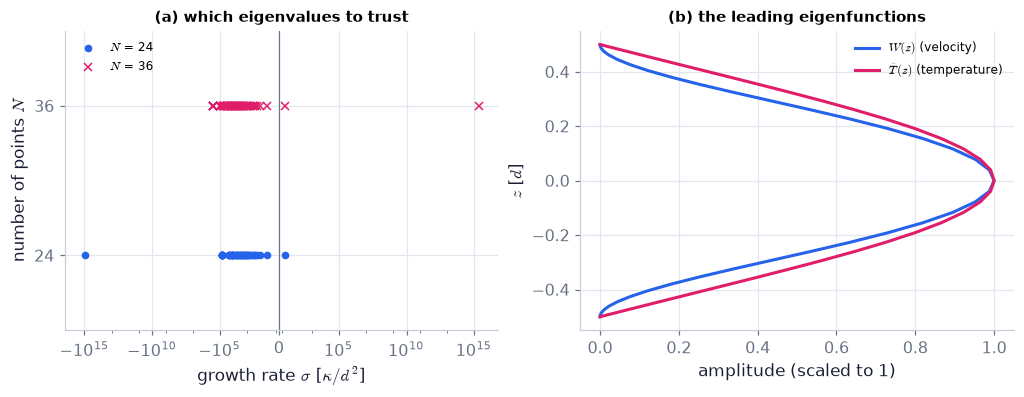

eigenvalues larger than 1e6 in size: 1 at N = 24, 1 at N = 36 (spurious: they move with N)
leading three, N = 24: [ 19.867 -41.499 -95.421] | N = 36: [ 19.867 -41.499 -95.421]


In [37]:
lam36 = benard_spectrum_mine(3.1163, Ra, Pr, 36)                    # the from-scratch spectrum again with more points
mode = ch11.benard_marginal_Ra(3.1163, return_mode=True)[1]         # the marginal eigenfunctions W(z), T(z) at K = 3.1163 (C04)
fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 3.5))   # the figure and its panels
a.plot(lam24.real, np.full(len(lam24), 24), "o", color=C_BUOY, ms=4, label="$N$ = 24")   # every eigenvalue of the coarse discretisation
a.plot(lam36.real, np.full(len(lam36), 36), "x", color=C_GROW, ms=5, label="$N$ = 36")   # ... and of the finer one: the physical ones sit in the same place, the spurious ones do not
a.set_xscale("symlog", linthresh=50)                                # logarithmic for large |sigma|, linear near zero
a.set_xticks([-1e15, -1e10, -1e5, 0, 1e5, 1e10, 1e15])               # a few readable tick marks
a.axvline(0, color=C_BASE, lw=0.8)   # a reference line or band
a.legend(fontsize=8, loc="upper left")   # legend: one entry per curve
a.set(xlabel=r"growth rate $\sigma$ [$\kappa/d^2$]", ylabel="number of points $N$", yticks=[24, 36], ylim=(18, 42))   # axis labels (with units) and fixed ranges for this panel
a.set_title("(a) which eigenvalues to trust", fontsize=10)   # panel title — the message of this panel
b.plot(mode["W"]/np.max(np.abs(mode["W"])), mode["z"], color=C_BUOY, label="$W(z)$ (velocity)")   # vertical-velocity shape of the first cell: flat at the walls (no slip)
b.plot(mode["T"]/np.max(np.abs(mode["T"])), mode["z"], color=C_GROW, label=r"$\hat T(z)$ (temperature)")   # temperature shape of the first cell: one arch, zero at the walls
b.set(xlabel="amplitude (scaled to 1)", ylabel="$z$ [$d$]")   # axis labels (with units) and fixed ranges for this panel
b.set_title("(b) the leading eigenfunctions", fontsize=10)   # panel title — the message of this panel
b.legend(fontsize=8)   # legend: one entry per curve
plt.show()   # display the figure
big24, big36 = lam24[np.abs(lam24) > 1e6], lam36[np.abs(lam36) > 1e6]   # the huge eigenvalues that row replacement and round-off create
print(f"eigenvalues larger than 1e6 in size: {len(big24)} at N = 24, {len(big36)} at N = 36 (spurious: they move with N)")   # how many spurious eigenvalues each resolution has
print("leading three, N = 24:", np.round(np.sort(lam24[np.abs(lam24) < 1e4].real)[::-1][:3], 3), "| N = 36:", np.round(np.sort(lam36[np.abs(lam36) < 1e4].real)[::-1][:3], 3))   # the physical eigenvalues agree between the two resolutions

**What does the code above do?**

1. `benard_spectrum_mine` (the from-scratch cell) at $N=36$, next to the $N=24$ spectrum.
2. `ch11.benard_marginal_Ra(K, return_mode=True)` returns the marginal Rayleigh number and the profiles `W`, `T` on the nodes `z`.
3. `set_xscale("symlog")` gives an axis that is linear near zero and logarithmic beyond ±50, so that eigenvalues of size 20 and
   of size 10¹⁵ fit in one picture.

**What you see.** (a) Every finite eigenvalue of the from-scratch matrices for two resolutions, on an axis that is logarithmic for large values: near zero the circles and crosses sit on top of each other; far out to the left and right they do not. (b) The shapes of the leading mode: the velocity amplitude W is flat near the walls (no slip), the temperature amplitude is a single arch.

**How to read it.** Trust what does not move with N. The top eigenvalue ≈ 19.9 > 0 grows; the next ones (≈ −41, −95, …) decay. The huge values (10⁶ and more, some positive) are artefacts of the boundary rows and round-off — a different set at every N. That is why every solver in this chapter keeps only eigenvalues that reappear at a larger N.

**What would change if…** …Ra = 1000: the top eigenvalue drops to ≈ −7.8 — every disturbance decays.

**What would change if…** …we only want to know *when* convection starts, not how fast? Since $\sigma$ is real (D08), it passes through zero, not around
it: setting $\sigma=0$ removes Pr and leaves one equation for Ra(K) — C04.

### 🧩 The rigid–rigid neutral curve Ra(K) and the critical point $\mathrm{Ra}_c=1707.76$, $K_c=3.117$ (Chandrasekhar 1961) `C04`

*The question:* At what heating does convection start, and how wide are the first cells?

#### The problem in plain words

Turn up the stove slowly. For a while nothing moves; then, at a sharp temperature difference, rolls appear — and they are all
about as wide as the layer is deep. Why that width, and why that threshold? Each possible cell width is a separate normal mode,
each with its own threshold; convection starts at the cheapest one.

#### The idea

```
Ra
 ▲  \                                /      narrow cells (large K): viscosity and diffusion act over a short distance
 │   \     marginal Ra(K)          /        wide cells (small K): buoyancy drives them only weakly
 │    \___                    ___/
 │        \___  ●  ______/        ← the bottom of the valley: Ra_c ≈ 1708 at K_c ≈ 3.12  (λ_c = 2π/K_c ≈ 2d)
 └────────────────────────────────► K
heat until Ra reaches the valley bottom: the first K to go unstable is K_c
```

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **matrices and determinants; nonzero solution ⇔ det = 0** — a homogeneous system $M\mathbf a=0$ has a nonzero solution only if $\det M=0$. *(Ch. 1, P53, Ch. 1, P58)*
- **np.linalg.det** — `np.linalg.det(M)` returns the determinant of a square matrix (complex entries allowed). *(Ch. 1, P56)*
- **scipy.optimize.brentq** — `brentq(f, a, b)` finds a root of f between two points where f has opposite signs. *(Ch. 3, P108)*
- **scipy.optimize.minimize_scalar** — `minimize_scalar(f, bounds=(a, b), method="bounded")` finds the minimum of a function of one variable. *(Ch. 7, P170)*
- **np.meshgrid** — `X, Y = np.meshgrid(x, y)` builds the grid of all (x, y) pairs for evaluating a field. *(Ch. 2, P76)*
- **contour and streamline plots** — `ax.contour` draws level lines of a field (streamlines when the field is a stream function), `ax.pcolormesh` colours it. *(Ch. 2, P78)*
- **live widgets** — an ipywidgets slider that re-runs a function while a Python kernel is running (frozen on the web page). *(Ch. 1, P47)*

#### 🧮 Derivation — The marginal pair → the sixth-order equation with the rigid conditions `D09` ★ (Eq. 11.40: $\Big(\frac{d^2}{dz^2}-K^2\Big)^3W=-\mathrm{Ra}K^2W$)

**What we want to show.** At the onset (σ = 0) reduce the two amplitude equations to one equation for W alone.

**Assumptions.** σ = 0 at the margin (D08).

**The plan.**

1. Set σ = 0.
2. Apply one operator to eliminate T̂.
3. Translate the conditions.

**Tools we use** (each explained before this point): Operator elimination (P177)

**We start from**

$$ \begin{array}{l}\Big(\sigma+K^2-\frac{d^2}{dz^2}\Big)\hat T=W\qquad\text{(11.36)} \\[4pt] \Big(\frac\sigma\Pr+K^2-\frac{d^2}{dz^2}\Big)\Big(\frac{d^2}{dz^2}-K^2\Big)W=-\mathrm{Ra}K^2\hat T\qquad\text{(11.37)} \\[4pt] W=\frac{dW}{dz}=\hat T=0\ \text{on}\ z=\pm\tfrac12\qquad\text{(11.38)} \\[4pt] \text{at the margin }\sigma=0\ \text{(D08)}\end{array} $$

*In words:* the marginal state of convection.

---

**Step 1 of 6 — Set σ = 0 in (11.36).**

$$ \Big(\frac{d^2}{dz^2}-K^2\Big)\hat T=-W $$

- *Why we can do this:* the onset is σ = 0 by D08; multiply by −1 to write the operator as (D² − K²).
- *In words:* the temperature is driven by the vertical velocity.

---

**Step 2 of 6 — Set σ = 0 in (11.37).**

$$ \Big(\frac{d^2}{dz^2}-K^2\Big)^2W=\mathrm{Ra}K^2\hat T\ \text{(11.39)} $$

- *Why we can do this:* $(K^2-D^2)(D^2-K^2)= -(D^2-K^2)^2$; multiply by −1. Pr has disappeared.
- *In words:* the velocity is driven by the temperature.

---

**Step 3 of 6 — Apply (D² − K²) to the second.**

$$ \Big(\frac{d^2}{dz^2}-K^2\Big)^3W=\mathrm{Ra}K^2\Big(\frac{d^2}{dz^2}-K^2\Big)\hat T $$

- *Why we can do this:* constant-coefficient operators can be applied to both sides (P177); this produces the combination step 1 knows.
- *In words:* one more derivative level.

---

**Step 4 of 6 — Use step 1.**

$$ \Big(\frac{d^2}{dz^2}-K^2\Big)^3W=-\mathrm{Ra}K^2W\ \text{(11.40)} $$

- *Why we can do this:* replace (D² − K²)T̂ by −W.
- *In words:* one sixth-order equation for W.

---

**Step 5 of 6 — Keep the velocity conditions.**

$$ W=\frac{dW}{dz}=0\ \text{on}\ z=\pm\tfrac12 $$

- *Why we can do this:* directly from (11.38), $W=\frac{dW}{dz}=\hat T=0\ \text{on}\ z=\pm\tfrac12$. Two of the three conditions of each wall already involve only W, so they can be kept as they are.
- *In words:* no slip, no flow through the plates.

---

**Step 6 of 6 — Translate T̂ = 0.**

$$ \Big(\frac{d^2}{dz^2}-K^2\Big)^2W=0\ \text{on}\ z=\pm\tfrac12\ \text{(11.41)} $$

- *Why we can do this:* by step 2, (D² − K²)²W = RaK²T̂, and T̂ = 0 at the walls.
- *In words:* the third condition, written with W only.

---

**Result**

$$ \begin{array}{l}\Big(\frac{d^2}{dz^2}-K^2\Big)^3W=-\mathrm{Ra}K^2W\qquad\text{(11.40)} \\[4pt] W=\frac{dW}{dz}=\Big(\frac{d^2}{dz^2}-K^2\Big)^2W=0\ \text{on}\ z=\pm\tfrac12\qquad\text{(11.41)}\end{array} $$

*In words:* six conditions for a sixth-order equation; only special Ra(K) allow a nonzero W.

**What it means.** Onset depends only on Ra and K: a neutral curve Ra(K).

**Check it.** No Pr ✓; the free–free sine mode satisfies (11.40), $\Big(\frac{d^2}{dz^2}-K^2\Big)^3W=-\mathrm{Ra}K^2W$ with Ra = (π² + K²)³/K² (D11) ✓.

📝 **Notes taught inside `D09`:** **N41 [B]** the marginal pair (steps 1–2) · **N42 [B]** the sixth-order equation (step 4) · **N43 [B]** the rigid conditions written with the velocity amplitude only (step 6).

> ⚠️ **Common confusion (traps in `D09`):** Getting the third condition from the wrong equation; keeping Pr.

> 📎 **Primer — even and odd functions; parity under z → −z.** `P261` · $f$ is *even* if $f(-z)=f(z)$ (cos, cosh, $z^2$) and *odd* if $f(-z)=-f(z)$ (sin, sinh, $z$). A problem that looks the same after
flipping $z\to-z$ (both walls alike) has eigenfunctions that are either even or odd, so we can look for them separately — even
$W$ gives one row of cells, odd $W$ two.

In [38]:
import numpy as np                                    # arrays
z = np.linspace(-0.5, 0.5, 5)                         # points placed symmetrically about z = 0
print(np.allclose(np.cosh(2*z), np.cosh(-2*z)), np.allclose(np.sinh(2*z), -np.sinh(-2*z)))   # True True: cosh even, sinh odd

True True


📝 **Note.** **N44 [B]** **Pr drops out; even and odd modes.** At $\sigma=0$ the Prandtl number has disappeared from the marginal problem, so the onset does
not depend on the fluid's Pr — only Ra matters. Both walls are alike, so the eigenfunctions are even ($W$ symmetric about $z=0$:
one row of cells) or odd (two rows); the even one goes unstable first.

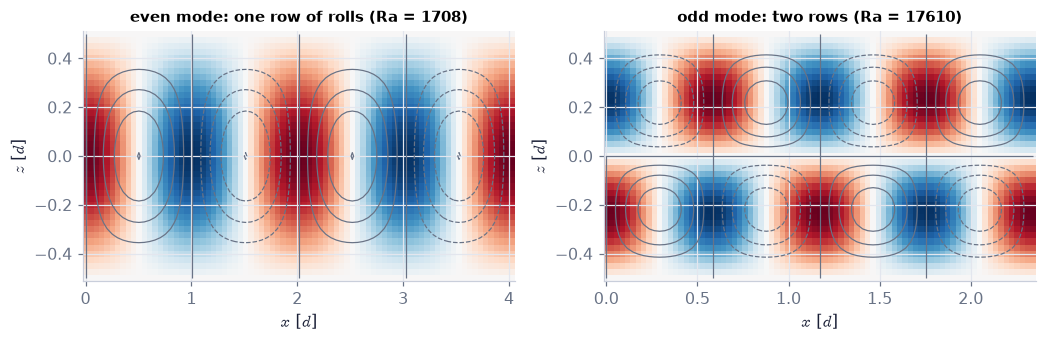

In [39]:
ev = ch11.benard_eigenfunction(3.1163, mode="even")                 # marginal even mode at K = 3.1163: fields on an (x, z) grid
od = ch11.benard_eigenfunction(5.3647, mode="odd")                  # marginal odd mode at its own critical K = 5.3647
fig, axs = plt.subplots(1, 2, figsize=(9.4, 3.0))   # the figure and its panels
for ax, e, ttl in ((axs[0], ev, "even mode: one row of rolls"), (axs[1], od, "odd mode: two rows")):   # repeat the indented lines for each item listed
    ax.pcolormesh(e["x"], e["z"], e["T"], cmap="RdBu_r", shading="auto")   # temperature disturbance: red warm, blue cold
    ax.contour(e["x"], e["z"], e["psi"], 8, colors=C_BASE, linewidths=0.8) # streamlines of the rolls
    ax.set(xlabel="$x$ [$d$]", ylabel="$z$ [$d$]")   # axis labels (with units) and fixed ranges for this panel
    ax.set_title(f"{ttl} (Ra = {e['Ra']:.0f})", fontsize=10)   # panel title — the message of this panel
plt.show()   # display the figure

**What does the code above do?**

1. `ch11.benard_eigenfunction(K, mode=…)` solves the marginal problem at wavenumber $K$ and returns the roll fields on a grid:
   `x`, `z`, the stream function `psi`, the temperature disturbance `T`, and the marginal `Ra`.
2. `pcolormesh` paints the temperature, `contour` draws streamlines (Ch. 2, P78).

**What you see.** Left: one row of counter-rotating rolls (grey streamlines) with warm fluid (red) rising between them and cold fluid (blue) sinking. Right: two rows of smaller rolls stacked on top of each other.

**How to read it.** Warm columns sit where the streamlines point upward: that is the feedback of D05 — rising fluid is warmer, and warmer fluid rises. The odd mode needs smaller cells, so viscosity and diffusion cost it more: its marginal Ra is ten times larger (N123).

**What would change if…** …free walls (C05): the even mode's vertical shape becomes exactly a cosine.

> 📎 **Primer — cube roots of a negative number.** `P262` · Every nonzero number has three cube roots. Write $-1=e^{\mathrm i\pi}$: its cube roots are $e^{\mathrm i\pi/3}$,
$e^{\mathrm i\pi}=-1$ and $e^{\mathrm i5\pi/3}$, i.e. $-1$ and $\tfrac12(1\pm\mathrm i\sqrt3)$. So $s^3=-a$ ($a>0$) has
$s=-a^{1/3}$ and $s=\tfrac12a^{1/3}(1\pm\mathrm i\sqrt3)$ — one real, two complex conjugates (Euler's formula, Ch. 1 P45).

In [40]:
import numpy as np                                    # arrays
print(np.roots([1, 0, 0, 1]))                         # s^3 + 1 = 0  ->  -1 and 0.5 + 0.866j, 0.5 - 0.866j
print((0.5*(1 + 1j*np.sqrt(3)))**3)                   # (-1+0j): the complex root cubed is -1 again

[-1. +0.j     0.5+0.866j  0.5-0.866j]
(-0.9999999999999998+1.1102230246251565e-16j)


> 📎 **Primer — neutral curve as the zero contour of the growth rate; critical point as its minimum.** `P263` · For each wavenumber $K$ find the parameter value where the leading growth rate crosses zero (`brentq`, Ch. 3 P108: a root finder
that needs two values with opposite signs): that is the neutral (marginal) curve Ra(K). Then minimise Ra(K) over $K$
(`minimize_scalar`, Ch. 7 P170): the minimum is the critical point (Ra_c, K_c). Inside the curve $\sigma>0$, outside $\sigma<0$.
The same two nested searches give the critical Taylor number (C07) and the critical Reynolds number (C13).

In [41]:
import numpy as np                                    # arrays
from scipy.optimize import minimize_scalar            # minimum of a function of one variable
Ra_of_K = lambda K: (np.pi**2 + K**2)**3/K**2         # a neutral curve given in closed form (C05 derives it)
r = minimize_scalar(Ra_of_K, bounds=(0.5, 6), method="bounded")   # search K between 0.5 and 6
print(round(r.x, 3), round(r.fun, 1))                 # 2.221 657.5: the critical K and the critical Ra

2.221 657.5


#### 🧮 Derivation — Characteristic roots, the even solution, the 3 × 3 determinant and $\mathrm{Ra}_c=1707.76$ at $K_c=3.117$ `D10` ★★★ (Eq. 11.42: $q^2=-K^2\Big[\Big(\frac{\mathrm{Ra}}{K^4}\Big)^{1/3}-1\Big],\ \ q^2=K^2\Big[1+\frac12\Big(\frac{\mathrm{Ra}}{K^4}\Big)^{1/3}(1\pm\mathrm i\sqrt3)\Big]$)

**What we want to show.** Solve (11.40)–(11.41) exactly for rigid walls and find the smallest Rayleigh number at which convection can start.

**Assumptions.** Ra > K⁴ (q₀ real, step 5); the even mode (step 7; the odd mode is N123).

**The plan.**

1. Exponential trial → a cubic for q² − K².
2. Its three cube roots → six exponents.
3. Even solution and its three wall conditions → a 3 × 3 determinant.
4. Find its zero in Ra for each K, then minimise over K.

**Tools we use** (each explained before this point): Exponential trial (P44) · cube roots of a negative number (P262) · even and odd functions (P261) · determinants and nonzero solutions (P53, P58) · `brentq` (P108) · `minimize_scalar` (P170) · neutral-curve recipe (P263) · sympy (P40)

**We start from**

$$ \begin{array}{l}\Big(\frac{d^2}{dz^2}-K^2\Big)^3W=-\mathrm{Ra}K^2W\qquad\text{(11.40)} \\[4pt] W=\frac{dW}{dz}=\Big(\frac{d^2}{dz^2}-K^2\Big)^2W=0\ \text{on}\ z=\pm\tfrac12\qquad\text{(11.41)}\end{array} $$

*In words:* the marginal problem of D09.

---

**Step 1 of 14 — Try W = $e^{qz}$.**

$$ (q^2-K^2)^3=-\mathrm{Ra}K^2 $$

- *Why we can do this:* constant coefficients: each d²/dz² becomes q² (P44); divide by $e^{qz}$ ≠ 0.
- *In words:* an algebraic equation for the exponent q.

---

**Step 2 of 14 — Call S = q² − K².**

$$ S^3=-\mathrm{Ra}K^2=\mathrm{Ra}K^2e^{\mathrm i\pi} $$

- *Why we can do this:* a cube equation for S; writing −1 as $e^{i\pi}$ prepares the three cube roots (P262).
- *In words:* we need the cube roots of a negative number.

---

**Step 3 of 14 — Take the three cube roots.**

$$ S=-(\mathrm{Ra}K^2)^{1/3},\quad S=\tfrac12(\mathrm{Ra}K^2)^{1/3}(1\pm\mathrm i\sqrt3) $$

- *Why we can do this:* the cube roots of −1 are −1 and $e^{\pm i\pi /3}$ = ½(1 ± i√3) (P262).
- *In words:* one real and two complex conjugate values.

---

**Step 4 of 14 — Return to q².**

$$ q^2=-K^2\Big[\Big(\frac{\mathrm{Ra}}{K^4}\Big)^{1/3}-1\Big],\quad q^2=K^2\Big[1+\frac12\Big(\frac{\mathrm{Ra}} {K^4}\Big)^{1/3}(1\pm\mathrm i\sqrt3)\Big]\ \text{(11.42)} $$

- *Why we can do this:* q² = K² + S and $(\mathrm{Ra}K^2)^{1/3}=K^2(\mathrm{Ra}/K^4)^{1/3}$.
- *In words:* the book's three roots.

---

**Step 5 of 14 — Name the first pair.**

$$ q=\pm\mathrm iq_0,\quad q_0=K\Big[\Big(\frac{\mathrm{Ra}}{K^4}\Big)^{1/3}-1\Big]^{1/2} $$

- *Why we can do this:* for Ra > K⁴ the first q² is negative, so its square roots are imaginary (P45).
- *In words:* an oscillating part, cos q₀z.

---

**Step 6 of 14 — Name the other two pairs.**

$$ \pm q,\ \pm q^* $$

- *Why we can do this:* the last two q² are complex conjugates, so their square roots are q and q* (principal branch, Re q > 0) with their negatives.
- *In words:* six exponents in all.

---

**Step 7 of 14 — Keep the even combination.**

$$ W=A\cos q_0z+B\cosh qz+C\cosh q^*z $$

- *Why we can do this:* both walls are alike, so even and odd solutions separate (P261); $e^{\pm iq_0z}$ pair into cos q₀z, $e^{\pm qz}$ into cosh qz. W is real when A is real and C = B*.
- *In words:* one row of cells.

---

**Step 8 of 14 — Differentiate once.**

$$ \frac{dW}{dz}=-Aq_0\sin q_0z+Bq\sinh qz+Cq^*\sinh q^*z $$

- *Why we can do this:* derivatives of cos and cosh (complex arguments allowed).
- *In words:* for the no-slip condition.

---

**Step 9 of 14 — Apply (D² − K²) twice.**

$$ \Big(\frac{d^2}{dz^2}-K^2\Big)^2W=A(q_0^2+K^2)^2\cos q_0z+B(q^2-K^2)^2\cosh qz+C(q^{*2}-K^2)^2\cosh q^*z $$

- *Why we can do this:* (D² − K²)cos q₀z = −(q₀² + K²)cos q₀z and (D² − K²)cosh qz = (q² − K²)cosh qz; squaring removes the sign. ⚠️ slip #1: the book prints B in the third term; it must be C.
- *In words:* for the temperature condition.

---

**Step 10 of 14 — Use the symmetry.**

$$ \text{conditions at }z=+\tfrac12\ \Leftrightarrow\ \text{conditions at }z=-\tfrac12 $$

- *Why we can do this:* W, d²W/dz² … are even and dW/dz is odd, so each condition at −½ repeats the one at +½.
- *In words:* three conditions remain.

---

**Step 11 of 14 — Write them as a matrix.**

$$ \begin{bmatrix}\cos\frac{q_0}2&\cosh\frac q2&\cosh\frac{q^*}2\\-q_0\sin\frac{q_0}2&q\sinh\frac q2& q^*\sinh\frac{q^*}2\\(q_0^2+K^2)^2\cos\frac{q_0}2&(q^2-K^2)^2\cosh\frac q2&(q^{*2}-K^2)^2\cosh\frac{q^*}2\end{bmatrix}\begin{bmatrix}A\\B\\C \end{bmatrix}=0 $$

- *Why we can do this:* steps 7–9 at z = ½. A nonzero (A, B, C) exists only if the determinant vanishes (P53, P58).
- *In words:* the eigenvalue condition.

---

**Step 12 of 14 — See that det is imaginary.**

$$ \overline{\det M}=-\det M\ \Rightarrow\ \det M=\mathrm i\,\mathrm{Im}\det M $$

- *Why we can do this:* column 3 is the conjugate of column 2 and column 1 is real; conjugating M equals swapping two columns, which flips the sign of a determinant. So solve Im det M = 0.
- *In words:* one real equation in Ra for each K.

---

**Step 13 of 14 — Find the root in Ra at fixed K.**

$$ \mathrm{Im}\det M(\mathrm{Ra};K)=0\ \Rightarrow\ \mathrm{Ra}(K)\ \text{, e.g. Ra(2) = 2177.41} $$

- *Why we can do this:* scan Ra upward from just above K⁴ (below it q₀ is not real and spurious sign changes appear), then `brentq` on the first sign change (P108).
- *In words:* one point of the neutral curve.

---

**Step 14 of 14 — Minimise over K.**

$$ \mathrm{Ra}_c=\min_K\mathrm{Ra}(K)=1707.76\ \text{at}\ K_c=3.117 $$

- *Why we can do this:* every K is allowed, so the layer first goes unstable at the lowest point of Ra(K) (P263, `minimize_scalar`).
- *In words:* the critical Rayleigh number.

---

**Result**

$$ \begin{array}{l}\mathrm{Ra}_c=1707.76\ \text{,}\ K_c=3.117\ \text{(Chandrasekhar 1961; the book rounds to 1708 and 3.12); cell} \\ \text{width}\ \lambda_c=2\pi d/K_c\approx2.02d\end{array} $$

*In words:* rigid plates start convecting at Ra ≈ 1708 in cells about twice as wide as the layer is deep (a pair of counter-rotating rolls).

**What it means.** The heating must beat a threshold set jointly by viscosity and diffusion; the preferred cell is the one that minimises the cost. Fails above onset (nonlinear rolls, N52) and for non-Boussinesq or very deep layers.

**Check it.** The determinant root equals the Chebyshev eigenvalue at K = 2, 3.1163, 5 to 1e-8 (two independent routes) ✓; with the printed B (slip #1) the determinant is no longer imaginary and the root moves ✓. Dimensionless ✓.

In [42]:
import sympy as sp                                   # symbolic algebra
z, K, Ra = sp.symbols("z K Ra", positive=True)       # height and the two parameters
s = (Ra/K**4)**sp.Rational(1, 3)                     # the cube-root factor of (11.42)
for q2 in (-K**2*(s - 1), K**2*(1 + s*(1 + sp.sqrt(3)*sp.I)/2), K**2*(1 + s*(1 - sp.sqrt(3)*sp.I)/2)):   # repeat the indented lines for each item listed
    print(sp.simplify(sp.expand((q2 - K**2)**3 + Ra*K**2)))   # step 1: each root of (11.42) satisfies (q^2-K^2)^3 = -Ra K^2 -> 0
q = sp.symbols("q")                                  # a generic exponent
L = lambda f: sp.diff(f, z, 2) - K**2*f              # the operator d^2/dz^2 - K^2
print(sp.simplify(L(L(sp.cosh(q*z))) - (q**2 - K**2)**2*sp.cosh(q*z)))   # step 9: (D^2-K^2)^2 cosh qz -> 0
import numpy as np                                   # numbers for steps 12-14
from fluidpy import ch11_instability as ch11         # the tested functions
d = ch11.benard_determinant(1707.762, 3.1163)        # step 12: the determinant at the critical point
print(abs(d.real) < 1e-9*abs(d))                     # True: purely imaginary
print(np.isclose(ch11.benard_marginal_Ra_det(3.1163), ch11.benard_marginal_Ra(3.1163), rtol=1e-8))   # step 13: two routes agree

0


0
0


0
True


True


📝 **Notes taught inside `D10`:** **N45 [B]** the characteristic equation, its three roots and the real exponent (steps 1–5) · **N46 [B]** the even solution and the 3 × 3 determinant, with slip #1 (steps 7–11).

> ⚠️ **slip #1 — the book prints** the third term of $\big(\frac{d^2}{dz^2}-K^2\big)^2W$ as $B(q^{*2}-K^2)^2\cosh q^*z$ **; the
> correct form is** $C(q^{*2}-K^2)^2\cosh q^*z$ — the coefficient of the third solution is $C$ (step 9). The 3 × 3 matrix printed
> under it is right.

> ⚠️ **Common confusion (traps in `D10`):** Using q twice instead of q and q* (W would not be real); the printed B (slip #1); trusting a sign change of Im det below Ra = K⁴; forgetting that the minimum over K, not a single K, gives Ra_c.

#### ✏️ Tiny example: the characteristic roots at K = 2, Ra = 1000

1. $\mathrm{Ra}/K^4=1000/16=62.5$; $s=(62.5)^{1/3}=3.9685$.
2. First root of the characteristic equation: $q^2=-K^2(s-1)=-4\times2.9685=-11.874$, so $q=\pm\mathrm iq_0$ with
   $q_0=\sqrt{11.874}=3.4459$.
3. The other two: $q^2=K^2[1+\tfrac12s(1\pm\mathrm i\sqrt3)]=4[1+1.9843\pm3.4369\,\mathrm i]=11.937\pm13.748\,\mathrm i$, so
   $q=3.8822+1.7705\,\mathrm i$ and its conjugate.
4. Check: $(q^2-K^2)^3$ for the first root $=(-11.874-4)^3=(-15.874)^3=-4000=-\mathrm{Ra}K^2$ ✓.
5. Below $\mathrm{Ra}=K^4=16$ the cube root $s<1$ and $q_0$ turns imaginary — why the determinant search starts above $K^4$.

In [43]:
print("q0, q, q* at Ra = 1000, K = 2:", np.round(ch11.benard_char_roots(1000.0, 2.0), 4))   # the roots (11.42) of the worked example
for K in (2.0, 3.1163, 5.0):                                        # two independent routes to the marginal Ra at three wavenumbers
    print(f"K = {K}: Chebyshev eigenproblem {ch11.benard_marginal_Ra(K):.4f} | book's determinant {ch11.benard_marginal_Ra_det(K):.4f}")   # two independent routes to the marginal Rayleigh number at this cell width
crit = ch11.benard_critical()                                       # minimum of Ra(K) over K (P263): rigid-rigid walls
ref = BENCH["benard_rigid_rigid"]                                   # published value (Chandrasekhar 1961), from reference/ch11
print(f"critical point: Ra_c = {crit['Ra_c']:.3f} at K_c = {crit['K_c']:.4f}  (published {ref['Ra_c']}, {ref['K_c']})")   # the bottom of the valley, next to the published value
print(f"relative difference from the published Ra_c: {abs(crit['Ra_c']/ref['Ra_c'] - 1):.1e};  cell pair width 2 pi/K_c = {2*np.pi/crit['K_c']:.3f} d")   # agreement with the benchmark, and the width of a pair of rolls

q0, q, q* at Ra = 1000, K = 2: [3.4459+0.j     3.8822+1.7705j 3.8822-1.7705j]


K = 2.0: Chebyshev eigenproblem 2177.4121 | book's determinant 2177.4121
K = 3.1163: Chebyshev eigenproblem 1707.7618 | book's determinant 1707.7618


K = 5.0: Chebyshev eigenproblem 2439.3217 | book's determinant 2439.3217


critical point: Ra_c = 1707.762 at K_c = 3.1163  (published 1707.762, 3.117)
relative difference from the published Ra_c: 1.3e-07;  cell pair width 2 pi/K_c = 2.016 d


**What does the code above do?**

1. `ch11.benard_char_roots(Ra, K)` returns $q_0$, $q$, $q^*$ of D10 steps 4–6.
2. `ch11.benard_marginal_Ra(K)` solves the marginal pair as a generalised eigenproblem *for Ra* on Chebyshev points;
   `ch11.benard_marginal_Ra_det(K)` finds the zero of the book's 3 × 3 determinant (D10 steps 11–13). Two routes, one answer.
3. `ch11.benard_critical()` is P263's recipe: minimise over $K$. The result agrees with the published benchmark to better than one
   part in 10⁵; the book rounds it to 1708 and 3.12. Our converged wavenumber is $K_c=3.1163$; the 1961 table (and this block's
   heading) rounds it to 3.117.
4. One wavelength $2\pi/K_c\approx2.02\,d$ holds a *pair* of counter-rotating rolls, so each roll is about as wide as the layer is
   deep.

In [44]:
def det_mine(Ra, K):                                                # the 3 x 3 determinant of D10 step 11 (even mode, rows at z = +1/2)
    s = (Ra/K**4)**(1/3)                                            # the cube-root factor of (11.42)
    q0 = K*np.sqrt(s - 1)                                           # first root: q = +- i q0 (real q0 for Ra > K^4)
    q = np.sqrt(K**2*(1 + 0.5*s*(1 + 1j*np.sqrt(3))))               # second root (complex; np.sqrt of a complex number = principal root)
    qs = np.conj(q)                                                 # third root: its conjugate
    M = np.array([[np.cos(q0/2), np.cosh(q/2), np.cosh(qs/2)],                                   # W = 0
                  [-q0*np.sin(q0/2), q*np.sinh(q/2), qs*np.sinh(qs/2)],                          # dW/dz = 0
                  [(q0**2 + K**2)**2*np.cos(q0/2), (q**2 - K**2)**2*np.cosh(q/2), (qs**2 - K**2)**2*np.cosh(qs/2)]])   # (D^2 - K^2)^2 W = 0
    return np.linalg.det(M)                                         # zero determinant <=> a nonzero (A, B, C) exists (Ch. 1 P53, P56)

K = 3.1163                                                          # close to the critical wavenumber
Ra_scan = np.linspace(1.0001*K**4 + 1, 4000.0, 400)                 # start just above K^4, where q0 becomes real
im = np.array([det_mine(R, K).imag for R in Ra_scan])               # the determinant is purely imaginary (D10 step 12)
i0 = np.nonzero(np.diff(np.sign(im)))[0][0]                         # first sign change of its imaginary part (Ch. 7 P180)
Ra_det = brentq(lambda R: det_mine(R, K).imag, Ra_scan[i0], Ra_scan[i0 + 1], xtol=1e-10)   # refine the root (P108)
assert np.isclose(Ra_det, ch11.benard_marginal_Ra(K), rtol=1e-8)    # the determinant route = the Chebyshev route
d_ok, d_bad = ch11.benard_determinant(1707.762, K), ch11.benard_determinant(1707.762, K, printed=True)   # correct, and with slip #1 built in
print(f"my determinant root: Ra = {Ra_det:.4f}")   # the Rayleigh number at which our hand-typed determinant vanishes
print(f"real part / size of det: correct {abs(d_ok.real)/abs(d_ok):.1e}, as printed (slip #1) {abs(d_bad.real)/abs(d_bad):.2f}")

my determinant root: Ra = 1707.7618


real part / size of det: correct 2.0e-10, as printed (slip #1) 1.00


**What does the code above do?**

1. `det_mine` types the matrix of D10 step 11 with `np.cos` and `np.cosh` of complex arguments (they accept complex numbers:
   $\cosh(a+\mathrm ib)=\cosh a\cos b+\mathrm i\sinh a\sin b$).
2. A scan above $\mathrm{Ra}=K^4$ finds the first sign change of the imaginary part; `brentq` refines it. The assertion shows the
   root equals the Chebyshev eigenvalue to eight digits.
3. The library's `printed=True` variant builds slip #1 in: the determinant is then no longer purely imaginary (its real part is
   most of it), so the printed line cannot be the one that was actually solved.

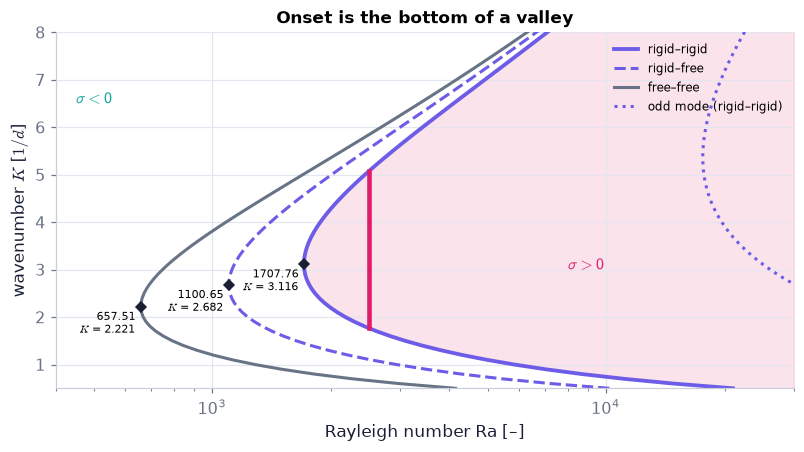

at Ra = 2500 (rigid walls) the wavenumbers from K = 1.76 to 5.08 grow
{'rigid': (1707.76, 3.1163), 'free': (657.51, 2.2215), 'rigid_free': (1100.65, 2.6823), 'odd': (17610.39, 5.3647)}


In [45]:
t_ = np.genfromtxt(ROOT / "reference" / "ch11" / "benard_neutral_curves.csv", delimiter=",", skip_header=1, names=True)   # our stored table
tab = {"K": t_["K"], "rigid": t_["Ra_rigid_rigid"], "free": t_["Ra_free_free"], "rigid_free": t_["Ra_rigid_free"], "odd": t_["Ra_odd_rigid_rigid"]}   # the four neutral curves under short names
assert np.isclose(tab["rigid"][15], ch11.benard_marginal_Ra(tab["K"][15]), rtol=6e-4)   # one table entry recomputed now (the table is rounded)
cr = {"rigid": crit, "free": ch11.benard_critical(bc=("free", "free")),   # the critical point of each pair of walls (first two here, the others on the next line)
      "rigid_free": ch11.benard_critical(bc=("rigid", "free"), mode="any"), "odd": ch11.benard_critical(mode="odd")}   # the four minima
K1 = brentq(lambda K: ch11.benard_marginal_Ra(K) - 2500.0, 1.0, crit["K_c"])   # lower edge of the unstable band at Ra = 2500 (rigid)
K2 = brentq(lambda K: ch11.benard_marginal_Ra(K) - 2500.0, crit["K_c"], 7.0)   # upper edge
fig, ax = plt.subplots(figsize=(7.2, 4.0))   # the figure and its panels
ax.fill_betweenx(tab["K"], tab["rigid"], 3e4, color=C_GROW, alpha=0.12)   # shade the area between two curves
ax.semilogx(tab["rigid"], tab["K"], color=C_NEUT, lw=2.5, label="rigid–rigid")   # marginal curve for rigid plates: to its right, cells of this width grow
ax.semilogx(tab["rigid_free"], tab["K"], "--", color=C_NEUT, label="rigid–free")   # one free surface: convection starts earlier
ax.semilogx(tab["free"], tab["K"], color=C_BASE, label="free–free")   # two free surfaces: earliest of all (C05)
ax.semilogx(tab["odd"], tab["K"], ":", color=C_NEUT, label="odd mode (rigid–rigid)")   # two rows of cells: needs ten times the heating
for name in ("rigid", "rigid_free", "free"):   # repeat the indented lines for each item listed
    ax.plot(cr[name]["Ra_c"], cr[name]["K_c"], "D", color=COLORS["ink"], ms=5)   # diamond: the critical point - the first cell width to convect
    ax.text(cr[name]["Ra_c"]*0.97, cr[name]["K_c"] - 0.55, f"{cr[name]['Ra_c']:.2f}\n$K$ = {cr[name]['K_c']:.3f}", fontsize=7, ha="right")   # a label written on the plot
ax.plot([2500, 2500], [K1, K2], color=C_GROW, lw=3)   # rose bar: the cell widths that grow at Ra = 2500 between rigid plates
ax.text(8000, 3.0, r"$\sigma>0$", color=C_GROW)   # a label written on the plot
ax.text(450, 6.5, r"$\sigma<0$", color=C_DECAY)   # a label written on the plot
ax.set(xlabel="Rayleigh number Ra [–]", ylabel="wavenumber $K$ [$1/d$]", xlim=(400, 3e4), ylim=(0.5, 8))   # axis labels (with units) and fixed ranges for this panel
ax.set_title("Onset is the bottom of a valley", fontsize=11)   # panel title — the message of this panel
ax.legend(fontsize=8, loc="upper right")   # legend: one entry per curve
savefig(fig, "ch11", "c04_neutral_curves")   # keep a copy in outputs/ch11 and display
plt.show()   # display the figure
print(f"at Ra = 2500 (rigid walls) the wavenumbers from K = {K1:.2f} to {K2:.2f} grow")   # the edges of that bar
print({n: (round(v["Ra_c"], 2), round(v["K_c"], 4)) for n, v in cr.items()})   # critical Rayleigh number and wavenumber for each pair of walls

**What does the code above do?**

1. `np.genfromtxt` reads our small public table `reference/ch11/benard_neutral_curves.csv` (the four neutral curves on one grid
   of 96 wavenumbers, written by `ch11.benard_neutral_table`); one entry is recomputed live and compared (the stored numbers are
   rounded, hence the relative tolerance).
2. The four minima are computed live with `ch11.benard_critical` (P263); `mode="any"` is needed for rigid–free walls, which have no
   even/odd symmetry.
3. `brentq` finds the two wavenumbers where the rigid curve passes through Ra = 2500.

**What you see.** Neutral curves in the (Ra, K) plane, drawn as the book does (K vertical, Ra horizontal on a logarithmic axis): rigid–rigid (bold purple), rigid–free (dashed), free–free (grey), and the odd mode (dotted, far to the right). Diamonds mark the leftmost point of each curve; the rose region is where the rigid–rigid layer is unstable.

**How to read it.** For a given Ra, the K inside the curve grow: the thick rose bar marks the unstable band at Ra = 2500 for rigid walls. The leftmost point of a curve is the critical point — below that Ra nothing grows. Rigid walls hold the fluid most, so their valley starts last, at $\mathrm{Ra}_c=1707.76$; free walls first, at 657.51.

**What would change if…** …we double the depth d: Ra grows 8× (it scales with d³), so a layer twice as deep convects at one eighth of the temperature difference.

**Slider figure F2 — the unstable band opens at the valley bottom.** Drag Ra; the thick segments show, for each pair of walls,
which wavenumbers grow.

In [46]:
def band(Ra_curve, Ra_now):                                        # the K-interval where the neutral curve lies below Ra_now
    inside = tab["K"][Ra_curve < Ra_now]                           # wavenumbers of the table that are unstable at this Ra
    return (np.array([inside[0], inside[-1]]), np.array([Ra_now, Ra_now])) if len(inside) else (np.array([np.nan]), np.array([np.nan]))   # the values for this call

def f2(Ra_now):                                                    # all traces for one slider value
    out = {"rigid–rigid": (tab["K"], tab["rigid"]), "rigid–free": (tab["K"], tab["rigid_free"]), "free–free": (tab["K"], tab["free"])}   # the three marginal curves (the same for every slider position)
    for name, key in (("unstable K (rigid–rigid)", "rigid"), ("unstable K (rigid–free)", "rigid_free"), ("unstable K (free–free)", "free")):   # repeat the indented lines for each item listed
        out[name] = band(tab[key], Ra_now)                         # a horizontal segment at height Ra_now
    return out   # the values for this call

figF2 = slider_figure(f2, "Ra", np.round(np.geomspace(500.0, 2.0e4, 15 if FAST else 30)), xlabel="wavenumber K [1/d]",   # slider: the Rayleigh number, on a logarithmic scale
                      ylabel="Rayleigh number Ra", title="Which cell widths grow at this Rayleigh number?",   # axis label and the question the figure answers
                      xrange=(0.5, 8), yrange=(400, 3e4))   # fixed axes, so only the bands move
figF2.update_yaxes(type="log", range=[np.log10(400), np.log10(3e4)])   # logarithmic Ra axis
figF2.show()   # display the interactive slider figure

**What does the code above do?**

1. `band` reads the unstable wavenumbers off the table for one Ra; `f2` returns the three static curves and the three bands.
2. Below 657.5 there is no band at all; the free–free band opens first, the rigid–rigid one last, each at its valley bottom.

> ▶️ **Live cell.** The widget below needs a running Python kernel. On the web page it is frozen — open this notebook in Colab (button at the top) or run it locally to drag the sliders.

In [47]:
def benard_live(K=3.1, logRa=3.4, walls="rigid–rigid", Pr=7.0):    # free K, Ra (as log10), boundaries and Prandtl number
    bc = {"rigid–rigid": ("rigid", "rigid"), "rigid–free": ("rigid", "free"), "free–free": ("free", "free")}[walls]   # the drop-down text turned into the solver's (bottom, top) wall types
    Ra_now = 10.0**logRa                                           # the Rayleigh number from the slider
    try:                                                           # the solver raises ValueError if the leading eigenvalue is not confirmed at a larger N
        sigma = ch11.benard_growth_rate(K, Ra_now, Pr, bc=bc)      # leading growth rate [kappa/d^2]
    except ValueError:   # the solver could not confirm the leading mode at this point
        sigma = np.nan                                             # show 'nan' for that slider position instead of stopping
    Ra_m, m = ch11.benard_marginal_Ra(K, bc=bc, mode="any", return_mode=True)   # the marginal Ra at this K and its mode shape
    fig, ax = plt.subplots(figsize=(4.2, 2.8))   # the figure and its panels
    ax.plot(m["W"]/np.max(np.abs(m["W"])), m["z"], color=C_GROW if sigma > 0 else C_DECAY)   # the cell's vertical-velocity shape: rose if it grows, teal if it decays
    ax.set(xlabel="$W(z)$ (scaled)", ylabel="$z$ [$d$]")   # axis labels (with units) and fixed ranges for this panel
    ax.set_title(f"Ra = {Ra_now:.0f}, marginal {Ra_m:.0f}: sigma = {sigma:.2f}", fontsize=9)   # panel title — the message of this panel
    plt.show()   # display the figure

live(benard_live, K=(1.0, 7.0, 0.1), logRa=(2.6, 4.4, 0.05), walls=["rigid–rigid", "rigid–free", "free–free"], Pr=(0.1, 10.0, 0.1))   # sliders for cell width, heating and Prandtl number, a menu for the walls

interactive(children=(FloatSlider(value=4.0, continuous_update=False, description='K', layout=Layout(width='95…

<function __main__.benard_live(K=3.1, logRa=3.4, walls='rigid–rigid', Pr=7.0)>

**What does the code above do?**

1. `benard_live` computes the growth rate at your $(K,\mathrm{Ra},\Pr)$ and the marginal Ra at that $K$, and draws the mode shape
   $W(z)$ — rose if it grows, teal if it decays.
2. `live(...)` (Ch. 1, P47) turns the arguments into sliders and a drop-down. Changing Pr changes $\sigma$ but never its sign (N44).
   The slider figure F2 above carries the same idea on the web page.

**Animation A3 — the same rolls just above and just below onset.** Rolls of the critical width at $\mathrm{Ra}=1.3\,\mathrm{Ra}_c$
(left) and $0.7\,\mathrm{Ra}_c$ (right) for water ($\Pr=7.14$); the amplitude follows $e^{\sigma t}$ with $\sigma$ from
`ch11.benard_growth_rate`; time is in units of $d^2/\kappa$.

In [48]:
nf = 14 if FAST else 18                                            # number of frames
Kc, Rac = crit["K_c"], crit["Ra_c"]                                # the critical point (rigid walls)
s_up = ch11.benard_growth_rate(Kc, 1.3*Rac, Pr)                    # growth rate 30 % above onset [kappa/d^2]
s_dn = ch11.benard_growth_rate(Kc, 0.7*Rac, Pr)                    # ... and 30 % below
e = ch11.benard_eigenfunction(Kc)                                  # the roll shape at K_c (fields on an (x, z) grid)
tA = np.linspace(0.0, 0.5, nf)                                     # times [d^2/kappa]
fig, axs = plt.subplots(1, 2, figsize=(8.4, 2.9))   # the figure and its panels
meshes = []                                                        # the two temperature images
for ax, a0 in zip(axs, (np.exp(-s_up*tA[-1]), 1.0)):               # start small on the left (so that it ends at 1), at 1 on the right
    meshes.append(ax.pcolormesh(e["x"], e["z"], a0*e["T"]/np.max(np.abs(e["T"])), cmap="RdBu_r", vmin=-1, vmax=1, shading="auto"))   # a colour map of the field
    ax.contour(e["x"], e["z"], e["psi"], 6, colors=C_BASE, linewidths=0.7)   # contour lines of the field
    ax.set(xlabel="$x$ [$d$]", ylabel="$z$ [$d$]")   # axis labels (with units) and fixed ranges for this panel
titles = [axs[0].set_title("", fontsize=9, color=C_GROW), axs[1].set_title("", fontsize=9, color=C_DECAY)]   # the panel's title: what this panel shows
Tn = e["T"]/np.max(np.abs(e["T"]))                                 # temperature pattern scaled to 1

def update(i):                                                     # frame i: time tA[i]
    amp_up = np.exp(s_up*(tA[i] - tA[-1]))                         # growing amplitude (reaches 1 at the last frame)
    amp_dn = np.exp(s_dn*tA[i])                                    # decaying amplitude (starts at 1)
    meshes[0].set_array((amp_up*Tn).ravel())   # move the drawn data to this frame's values
    meshes[1].set_array((amp_dn*Tn).ravel())   # move the drawn data to this frame's values
    titles[0].set_text(f"Ra = 1.3 Ra_c: grows, sigma = {s_up:+.2f}, t = {tA[i]:.2f}")   # update the title text for this frame
    titles[1].set_text(f"Ra = 0.7 Ra_c: decays, sigma = {s_dn:+.2f}, t = {tA[i]:.2f}")   # update the title text for this frame
    return meshes + titles   # the values for this call

show_animation(animate(update, frames=nf, fig=fig, interval=130), player="video", dpi=60)   # render the frames and show the animation
print(f"growth rates at K_c: {s_up:+.3f} (1.3 Ra_c), {s_dn:+.3f} (0.7 Ra_c); with Pr = 0.7 (air): "   # show the numbers computed above
      f"{ch11.benard_growth_rate(Kc, 1.3*Rac, 0.7):+.3f}, {ch11.benard_growth_rate(Kc, 0.7*Rac, 0.7):+.3f}")   # the same two growth rates for air: other values, same signs

growth rates at K_c: +5.405 (1.3 Ra_c), -5.603 (0.7 Ra_c); with Pr = 0.7 (air): +3.190, -3.696


**What does the code above do?**

1. Two growth rates at the same wavenumber $K_c$: positive 30 % above the critical Rayleigh number, negative 30 % below.
2. The roll pattern (temperature in colour, streamlines in grey) is the marginal mode; only its amplitude $e^{\sigma t}$ changes.
3. The last line repeats the growth rates for air ($\Pr=0.7$): different numbers, same signs.

**What you see.** The same roll pattern brightening on the left and fading on the right.

**How to read it.** Onset is a sign change of the growth rate at fixed K: nothing about the *shape* of the rolls changes as Ra passes the critical value, only whether they grow or die.

**What would change if…** …Pr = 0.7 (air): the growth rates change (the printed line), the threshold does not (N44).

📝 **Note.** **N50 [B]** **Rigid bottom, free top** (a liquid layer open to air): our computation gives $\mathrm{Ra}_c=1100.65$ at $K_c=2.682$
(Chandrasekhar 1961 tabulates this case); one free wall lowers the threshold because a stress-free surface resists less.

In [49]:
rf = ch11.benard_critical(bc=("rigid", "free"), mode="any")         # rigid bottom, stress-free top
print(f"rigid-free: Ra_c = {rf['Ra_c']:.3f} at K_c = {rf['K_c']:.4f}  (published {BENCH['benard_rigid_free']['Ra_c']}, {BENCH['benard_rigid_free']['K_c']})")   # a free top lowers the threshold; published value alongside

rigid-free: Ra_c = 1100.650 at K_c = 2.6823  (published 1100.65, 2.682)


📝 **Note.** **N123 [B]** **The gravest odd mode** (Exercise 11.7): two rows of cells need $\mathrm{Ra}=17\,610.39$ at $K=5.365$ (Chandrasekhar 1961) — ten
times the even threshold, so it is never the first to appear.

In [50]:
odd = ch11.benard_critical(mode="odd")                              # the odd (two-row) mode between rigid walls
print(f"odd mode: Ra_c = {odd['Ra_c']:.2f} at K_c = {odd['K_c']:.4f} - {odd['Ra_c']/crit['Ra_c']:.1f} times the even threshold")   # two rows of cells need ten times more heating than one

odd mode: Ra_c = 17610.39 at K_c = 5.3647 - 10.3 times the even threshold


> 📎 **Primer — Helmholtz equation in the plane; planforms as sums of cosines.** `P264` · Linear theory fixes only $\lvert\mathbf K\rvert$. Any horizontal pattern $f(x,y)$ with $\nabla_H^2f=-K^2f$ (the Helmholtz
equation) has the same growth rate: rolls $f=\cos Kx$, squares $\cos Kx+\cos Ky$, hexagons
$\sum_{j=1}^3\cos(\mathbf k_j\cdot\mathbf x)$ with three wave vectors of length $K$ at 120° to each other.

In [51]:
import numpy as np                                    # arrays
from fluidpy import ch11_instability as ch11          # the chapter module
x = y = np.linspace(0, 2, 41)                         # a 2 x 2 patch of the layer (in depths d)
X, Y = np.meshgrid(x, y)                              # grid of points (Ch. 2 P76)
f = ch11.planform(X, Y, 3.0, "hexagons")              # a hexagonal pattern with |K| = 3
print(f.shape, round(f.max(), 3))                     # (41, 41) and 3.0: the maximum sits at the cell centres

(41, 41) 3.0


📝 **Note.** **N51 [B]** **Which pattern?** Linear theory cannot choose between rolls, squares and hexagons (P264); experiments near onset often show
hexagons first, rolls as Ra rises, then time-dependent and finally turbulent convection at much larger Ra. In liquids the cell
centres usually rise (viscosity falls with temperature), in gases they sink. Climate hook: cloud streets are rolls aligned with the
wind; open and closed hexagonal cells cover the subtropical oceans in satellite pictures.

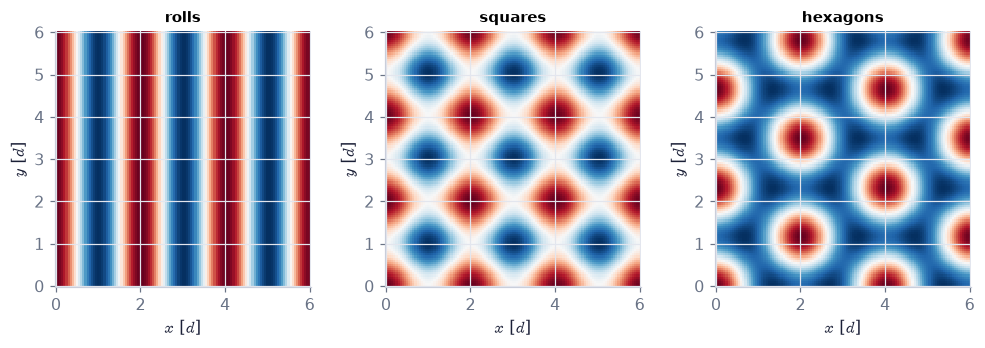

In [52]:
xg = yg = np.linspace(0, 6, 121)                                   # a 6 d by 6 d patch seen from above
Xg, Yg = np.meshgrid(xg, yg)                                       # grid of points
fig, axs = plt.subplots(1, 3, figsize=(9.0, 3.0))   # the figure and its panels
for ax, kind in zip(axs, ("rolls", "squares", "hexagons")):   # repeat the indented lines for each item listed
    ax.pcolormesh(Xg, Yg, ch11.planform(Xg, Yg, crit["K_c"], kind), cmap="RdBu_r", shading="auto")   # vertical velocity: red up, blue down
    ax.set(xlabel="$x$ [$d$]", ylabel="$y$ [$d$]")   # axis labels (with units) and fixed ranges for this panel
    ax.set_title(kind, fontsize=10)   # the panel's title: what this panel shows
    ax.set_aspect("equal")   # equal scales in x and y, so shapes are not distorted
plt.show()   # display the figure

**What you see.** Three patterns seen from above (red = rising, blue = sinking): parallel rolls, a chequerboard of squares, a honeycomb of hexagons.

**How to read it.** All three are built from waves of the same wavenumber K_c, so linear theory gives all three the same growth rate.

**What would change if…** …we go beyond linear theory: the nonlinear terms decide which pattern survives (named, N52).

📝 **Note.** **N52 [C]** **After onset** (named): the cells grow until the nonlinear terms balance them — kinetic energy produced by buoyancy (warm fluid
rising) equals viscous dissipation, fed by the heating. The energy bookkeeping is C14's; the simplest nonlinear model of it is
Lorenz's (C15).

#### 🎮 Interactive: Why does convection start near Ra ≈ 1708?

**Why interactive rather than a static figure:** Dragging a point in the (K, Ra) plane shows that every point is a whole eigenproblem — inside the curve the rolls grow, outside
they decay, and a third view shows the determinant's imaginary part crossing zero as Ra passes the curve; switching boundaries
moves the whole valley: from 657.5 through 1100.65 to 1707.76.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Preset 'rigid onset': read Ra_c = 1707.76 at K = 3.117; nudge Ra up by 5 % and watch the rolls start growing.
- Keep Ra = 2500 and drag K from 1 to 6: the status flips twice — the unstable band.
- Switch the walls to free–free: the valley drops to 657.5 and moves to K = π/√2 ≈ 2.22.

In [53]:
show_viz("ch11", "benard_neutral_curve")   # full-width explainer; ⤢ Full screen for more room

[explainer ch11/benard_neutral_curve]

**What would change if…** …both walls were stress-free? Every even derivative of $W$ vanishes at the walls, sine modes solve the problem exactly, and the
neutral curve becomes a formula you can minimise by hand — C05.

### 🧩 Free–free boundaries: $\mathrm{Ra}=(n^2\pi^2+K^2)^3/K^2$ (11.44), $K_c^2=\pi^2/2$, $\mathrm{Ra}_c=\tfrac{27}{4}\pi^4$ `C05`

*The question:* Can we find the onset of convection with pencil and paper?

#### The problem in plain words

Rigid plates are easy to build but hard to solve. A layer whose boundaries cannot hold any shear stress — oil floating on mercury,
or a slice of the atmosphere with no lid — is the case Rayleigh solved in 1916. It gives an exact formula, and its minimum,
$27\pi^4/4\approx657.5$, is the number double diffusion (C06) and Lorenz's model (C15) are built on.

#### The idea

With $W=W''=W''''=0$ at the walls, a sine wave $\sin n\pi(z+\tfrac12)$ vanishes at both walls together with all its even
derivatives, and $\big(\frac{d^2}{dz^2}-K^2\big)$ acting on it just multiplies it by $-(n^2\pi^2+K^2)$. Every operator becomes a
number, and the sixth-order marginal equation becomes algebra.

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **integrals of sines over a period, orthogonality** — $\int\sin m\pi z\,\sin n\pi z\,dz=0$ over the layer for $m\neq n$: different sine modes do not mix. *(Ch. 6, P151)*

> 📎 **Primer — quotient rule, and differentiating with respect to K² as the variable.** `P265` · $\frac{d}{dx}\frac{f}{g}=\frac{f'g-fg'}{g^2}$. When a formula depends on $K$ only through $K^2$, call $x=K^2$ and differentiate in
$x$: the minimum over $K$ and over $x$ is the same point (for $K>0$).

In [54]:
import sympy as sp                                    # symbolic algebra
x = sp.symbols("x", positive=True)                    # x stands for K^2
Ra_x = (sp.pi**2 + x)**3/x                            # the free-free neutral curve as a function of x = K^2
print(sp.solve(sp.diff(Ra_x, x), x))                  # [pi**2/2]: the minimum is at K^2 = pi^2/2

[pi**2/2]


#### 🧮 Derivation — Stress-free walls, sine modes, and $\frac{d\mathrm{Ra}}{dK^2}=0\Rightarrow K_c^2=\pi^2/2$, $\mathrm{Ra}_c=\tfrac{27}{4}\pi^4$ `D11` ★★ (Eq. 11.44: $\mathrm{Ra}=\frac{(n^2\pi^2+K^2)^3}{K^2}$)

**What we want to show.** Solve the marginal problem by hand when neither wall can hold a shear stress.

**Assumptions.** Stress-free, isothermal walls; the gravest mode n = 1 (step 9).

**The plan.**

1. Turn zero stress into a condition on W.
2. Show all even derivatives vanish.
3. Use sine modes.
4. Minimise over K².

**Tools we use** (each explained before this point): Differentiating continuity · Fourier sine modes and orthogonality (P151) · the quotient rule (P265) · sympy (P40)

**We start from**

$$ \begin{array}{l}\Big(\frac{d^2}{dz^2}-K^2\Big)^3W=-\mathrm{Ra}K^2W\qquad\text{(11.40)} \\[4pt] w=T'=\mu\Big(\frac{\partial u}{\partial z}+\frac{\partial w}{\partial x}\Big)=\mu\Big(\frac{\partial v}{\partial z}+\frac{\partial w}{\partial y}\Big)=0\ \text{on the walls (p. 489)}\end{array} $$

*In words:* the walls stop vertical flow but let the fluid slide.

---

**Step 1 of 11 — Use w = 0 along the wall.**

$$ w=0\ \text{for all}\ x,y\ \Rightarrow\ \frac{\partial w}{\partial x}=\frac{\partial w}{\partial y} =0 $$

- *Why we can do this:* a function that is zero everywhere on the plane has zero derivatives along it.
- *In words:* the wall-normal velocity does not vary along the wall.

---

**Step 2 of 11 — Simplify zero stress.**

$$ \frac{\partial u}{\partial z}=\frac{\partial v}{\partial z}=0 $$

- *Why we can do this:* step 1 removes the ∂w terms from the two stress conditions.
- *In words:* no shear at the wall.

---

**Step 3 of 11 — Differentiate continuity in z.**

$$ \frac{\partial^2w}{\partial z^2}=-\frac{\partial}{\partial x}\frac{\partial u}{\partial z}- \frac{\partial}{\partial y}\frac{\partial v}{\partial z}=0 $$

- *Why we can do this:* ∂_z of ∇·u = 0, then step 2 (derivatives along the wall of zero are zero).
- *In words:* W″ = 0 at a free wall.

---

**Step 4 of 11 — Collect the conditions.**

$$ W=\Big(\frac{d^2}{dz^2}-K^2\Big)^2W=\frac{d^2W}{dz^2}=0\ \text{on}\ z=\pm\tfrac12 $$

- *Why we can do this:* W = 0, step 3, and T̂ = 0 translated as in D09 step 6.
- *In words:* three conditions per wall.

---

**Step 5 of 11 — Expand the operator.**

$$ \Big(\frac{d^2}{dz^2}-K^2\Big)^2W=W''''-2K^2W''+K^4W=W'''' $$

- *Why we can do this:* W = W″ = 0 there. So $W=W''=W''''=0$ (11.43) — the book's "expanding the products of operators".
- *In words:* the fourth derivative vanishes too.

---

**Step 6 of 11 — Show every even derivative vanishes.**

$$ W^{(6)}=-\mathrm{Ra}K^2W+\dots=0,\ \text{and so on} $$

- *Why we can do this:* (11.40), $\Big(\frac{d^2}{dz^2}-K^2\Big)^3W=-\mathrm{Ra}K^2W$ expresses W⁽⁶⁾ through W, W″, W⁗, all zero at the wall; differentiating (11.40) twice repeats the argument for W⁽⁸⁾, … .
- *In words:* only odd derivatives survive at the walls.

---

**Step 7 of 11 — Choose sine modes.**

$$ W=A\sin n\pi\big(z+\tfrac12\big) $$

- *Why we can do this:* sin nπ(z + ½) and all its even derivatives vanish at z = ±½. ⚠️ slip #2: the book prints sin(nπz), which vanishes at z = ±½ only for even n; n = 1 here is cos πz.
- *In words:* n half-waves across the layer.

---

**Step 8 of 11 — Insert into (11.40).**

$$ -(n^2\pi^2+K^2)^3=-\mathrm{Ra}K^2\ \Rightarrow\ \mathrm{Ra}=\frac{(n^2\pi^2+K^2)^3}{K^2}\ \text{(11.44)} $$

- *Why we can do this:* d²/dz² → −n²π², so (D² − K²) → −(n²π² + K²); cube it; divide by −K².
- *In words:* the neutral curve as a formula.

---

**Step 9 of 11 — Differentiate in x = K² (n = 1).**

$$ \frac{d\mathrm{Ra}}{dK^2}=\frac{3(\pi^2+K^2)^2}{K^2}-\frac{(\pi^2+K^2)^3}{K^4} $$

- *Why we can do this:* quotient rule in the variable K² (P265); the minimum over K is the minimum over K². ⚠️ slip #3: the book prints a 3 on the second term; with it there is no root.
- *In words:* the slope of the neutral curve.

---

**Step 10 of 11 — Set the slope to zero.**

$$ 3K^2-(\pi^2+K^2)=0\ \Rightarrow\ K_c^2=\frac{\pi^2}2 $$

- *Why we can do this:* multiply by K⁴/(π² + K²)² > 0.
- *In words:* the cheapest cell, K_c = π/√2 ≈ 2.22.

---

**Step 11 of 11 — Evaluate Ra there.**

$$ \mathrm{Ra}_c=\frac{(3\pi^2/2)^3}{\pi^2/2}=\frac{27\pi^6/8}{\pi^2/2}=\frac{27}4\pi^4\approx657.5 $$

- *Why we can do this:* substitute K² = π²/2 into (11.44), $\mathrm{Ra}=\frac{(n^2\pi^2+K^2)^3}{K^2}$ with n = 1; higher n only raise Ra.
- *In words:* the free–free threshold.

---

**Result**

$$ \mathrm{Ra}=(n^2\pi^2+K^2)^3/K^2\ \text{(11.44),}\ K_c^2=\pi^2/2\ \text{,}\ \mathrm{Ra}_c=\tfrac{27}4\pi^4=657.51 $$

*In words:* without wall friction the threshold drops from 1708 to 657.5 and the cells widen (2π/K_c = 2.83 d).

**What it means.** The formula used by double diffusion (C06: Rs − Ra = 27π⁴/4) and Lorenz (C15: b = 8/3 from K² = π²/2).

**Check it.** Units: dimensionless ✓. Numbers: Ra(2) = 667.01 > 657.51 ✓. The Chebyshev solver with free walls gives 657.511 at 2.2214 ✓. The check cell below: `ch11.benard_free_free_sympy()` (residual of (11.40), $\Big(\frac{d^2}{dz^2}-K^2\Big)^3W=-\mathrm{Ra}K^2W$ is 0; root π²/2; printed root []).

In [55]:
ff = ch11.benard_free_free_sympy()                    # D11 redone with sympy
print("even derivatives of sin n pi (z + 1/2) at the two walls (step 7):", ff["bc_W4"])    # all 0
print("residual of the sixth-order equation with Ra = (n^2 pi^2 + K^2)^3/K^2 (step 8):", ff["residual"])   # 0
print("dRa/dK^2 (step 9):", ff["dRa_dK2"], "| root (step 10):", ff["root"], "| Ra_c (step 11):", ff["Ra_c"])   # the slope of the neutral curve, where it vanishes, and the value there
print("slip #3, as printed:", ff["printed_dRa_dK2"], "-> roots:", ff["printed_root"])       # []: the printed derivative has no root
print("slip #2: sin(n pi z) with n = 1 at z = -1/2, +1/2:", ff["printed_bc_n1"])           # [1, -1]: it does NOT vanish at the walls

even derivatives of sin n pi (z + 1/2) at the two walls (step 7): [0, 0, 0, 0, 0, 0]
residual of the sixth-order equation with Ra = (n^2 pi^2 + K^2)^3/K^2 (step 8): 0
dRa/dK^2 (step 9): (K2 + pi**2)**2*(2*K2 - pi**2)/K2**2 | root (step 10): pi**2/2 | Ra_c (step 11): 27*pi**4/4
slip #3, as printed: 3*(K2 + pi**2)**2/K2 - 3*(K2 + pi**2)**3/K2**2 -> roots: []
slip #2: sin(n pi z) with n = 1 at z = -1/2, +1/2: [1, -1]


📝 **Notes taught inside `D11`:** **N47 [B]** the stress-free conditions (steps 1–5) · **N48 [B]** the sine modes, with slip #2 (step 7) · **N49 [B]** the minimum over the wavenumber, with slip #3 (steps 9–11).

> ⚠️ **slip #2 — the book prints** $W=A\sin(n\pi z)$ **; the correct form is** $W=A\sin n\pi(z+\tfrac12)$: on
> $z\in[-\tfrac12,\tfrac12]$ the printed sine vanishes at both walls only for even $n$; the family that meets the conditions is
> $\sin n\pi(z+\tfrac12)$, whose $n=1$ member is $\cos\pi z$ (step 7).

> ⚠️ **slip #3 — the book prints** $\frac{d\mathrm{Ra}}{dK^2}=\frac{3(\pi^2+K^2)^2}{K^2}-\frac{3(\pi^2+K^2)^3}{K^4}$ **; the correct
> form is** $\frac{d\mathrm{Ra}}{dK^2}=\frac{3(\pi^2+K^2)^2}{K^2}-\frac{(\pi^2+K^2)^3}{K^4}$ — no 3 on the second term (step 9).
> With the printed 3 the root equation reads $K^2=\pi^2+K^2$, which has no solution.

> ⚠️ **Common confusion (traps in `D11`):** sin nπz (slip #2); the extra 3 (slip #3); forgetting that higher n give larger Ra; cubing −(π² + K²) and losing the sign.

#### 🧮 Derivation — The free–free growth rate $(\sigma+a^2)(\sigma/\Pr+a^2)a^2=\mathrm{Ra}K^2$, $a^2=\pi^2+K^2$ (ours; the book never writes it) `D12` ★★ (Eq. 11.44: $\mathrm{Ra}=\frac{(n^2\pi^2+K^2)^3}{K^2}$)

**What we want to show.** Find how fast a free–free convection mode grows, not only where it is marginal. (The last step — the quadratic formula written out — is our addition, so that the two growth rates are reached by a step.)

**Assumptions.** Stress-free isothermal walls; n = 1.

**The plan.**

1. Try the same sine for W and T̂.
2. Turn operators into numbers.
3. Eliminate the amplitudes.
4. Solve the quadratic.

**Tools we use** (each explained before this point): Sine modes from D11 · operator substitution (P177) · quadratic formula (P159)

**We start from**

$$ \begin{array}{l}\Big(\sigma+K^2-\frac{d^2}{dz^2}\Big)\hat T=W\qquad\text{(11.36)} \\[4pt] \Big(\frac\sigma\Pr+K^2-\frac{d^2}{dz^2}\Big)\Big(\frac{d^2}{dz^2}-K^2\Big)W=-\mathrm{Ra}K^2\hat T\qquad\text{(11.37)} \\[4pt] \text{with stress-free isothermal walls: }W=W''=\hat T=0\ \text{on}\ z=\pm\tfrac12\end{array} $$

*In words:* the full amplitude problem with σ kept.

---

**Step 1 of 9 — Try one sine for both.**

$$ W=W_0\sin\pi\big(z+\tfrac12\big),\ \hat T=T_0\sin\pi\big(z+\tfrac12\big) $$

- *Why we can do this:* this shape meets every free–free condition (D11 steps 4–7).
- *In words:* the gravest mode.

---

**Step 2 of 9 — Turn the operators into numbers.**

$$ \frac{d^2}{dz^2}\to-\pi^2,\ \ a^2\equiv\pi^2+K^2 $$

- *Why we can do this:* d²/dz² of the sine is −π² times it; so (K² − d²/dz²) → a² and (d²/dz² − K²) → −a².
- *In words:* derivatives become multiplications.

---

**Step 3 of 9 — Use (11.36).**

$$ (\sigma+a^2)T_0=W_0 $$

- *Why we can do this:* $(\sigma+K^2-\frac{d^2}{dz^2})\to\sigma+a^2$. The sine is never zero inside the layer, so it can be divided out, leaving a relation between the two amplitudes.
- *In words:* the temperature amplitude follows the velocity.

---

**Step 4 of 9 — Use (11.37).**

$$ \Big(\frac\sigma\Pr+a^2\Big)a^2W_0=\mathrm{Ra}K^2T_0 $$

- *Why we can do this:* $(\frac\sigma\Pr+a^2)(-a^2)W_0=-\mathrm{Ra}K^2T_0$; multiply by −1. The same division by the common sine leaves a second relation between the two amplitudes.
- *In words:* buoyancy drives the velocity.

---

**Step 5 of 9 — Eliminate W₀.**

$$ (\sigma+a^2)\Big(\frac\sigma\Pr+a^2\Big)a^2=\mathrm{Ra}K^2 $$

- *Why we can do this:* insert step 3 into step 4 and divide by T₀ ≠ 0.
- *In words:* the growth rate obeys a quadratic.

---

**Step 6 of 9 — Expand.**

$$ \frac{\sigma^2}\Pr+a^2\Big(1+\frac1\Pr\Big)\sigma+a^4-\frac{\mathrm{Ra}K^2}{a^2}=0 $$

- *Why we can do this:* multiply out and divide by a².
- *In words:* a standard quadratic in σ.

---

**Step 7 of 9 — Check the discriminant.**

$$ a^4\Big(1-\frac1\Pr\Big)^2+\frac{4\mathrm{Ra}K^2}{\Pr\,a^2}>0 $$

- *Why we can do this:* $(1+\frac1\Pr)^2-\frac4\Pr= (1-\frac1\Pr)^2$; the rest is positive for Ra > 0.
- *In words:* both roots are real — exchange of stabilities again (D08).

---

**Step 8 of 9 — Find where σ = 0.**

$$ \sigma=0\ \Leftrightarrow\ a^6=\mathrm{Ra}K^2\ \Leftrightarrow\ \mathrm{Ra}=\frac{(\pi^2+K^2)^3}{K^2} $$

- *Why we can do this:* set σ = 0 in step 5; it is (11.44), $\mathrm{Ra}=\frac{(n^2\pi^2+K^2)^3}{K^2}$ with n = 1; the larger root is positive exactly when Ra exceeds it.
- *In words:* the growth curve crosses zero on the neutral curve.

---

**Step 9 of 9 — Solve the quadratic for σ.**

$$ \sigma_\pm=\frac{\Pr}2\Big[-a^2\big(1+\tfrac1\Pr\big)\pm\sqrt{a^4\big(1-\tfrac1\Pr\big)^2+\frac{4\mathrm{Ra}K^2}{\Pr a^2}}\Big] $$

- *Why we can do this:* The quadratic formula (Ch. 6 P159) applied to step 6, whose coefficients are 1/Pr, a²(1 + 1/Pr) and a⁴ − RaK²/a²; under the root is exactly the positive discriminant of step 7. We want the growth rate itself, not only its zero.
- *In words:* two real growth rates: the plus root is the one that can become positive.

---

**Result**

$$ \sigma_\pm=\frac{\Pr}2\Big[-a^2\big(1+\tfrac1\Pr\big)\pm\sqrt{a^4\big(1-\tfrac1\Pr\big)^2+\frac{4\mathrm{Ra}K^2}{\Pr a^2}}\Big] $$

*In words:* one mode grows when Ra beats (11.44), $\mathrm{Ra}=\frac{(n^2\pi^2+K^2)^3}{K^2}$, the other always decays.

**What it means.** The σ(K) curve of explainer 1's Bénard mode; Pr changes how fast, not whether.

**Check it.** K = π/√2, Ra = 2000, Pr = 1: σ = 11.0155, −40.6243 (agrees with the Chebyshev solver to 1e-8) ✓; Ra = 27π⁴/4: σ₊ = 0 ✓.

> ⚠️ **Common confusion (traps in `D12`):** (d²/dz² − K²) on the sine is −a², not +a²; forgetting T₀ ≠ 0 when dividing.

#### ✏️ Tiny example: the free–free neutral curve with easy K

1. $K=2$: $\mathrm{Ra}=(\pi^2+4)^3/4=(13.870)^3/4=667.0$.
2. $K=1$: $(10.870)^3/1=1284.2$.
3. $K=3$: $(18.870)^3/9=746.5$.
4. The minimum is between 1 and 3: $d\mathrm{Ra}/dK^2=0$ at $K^2=\pi^2/2=4.935$, $K=2.2214$.
5. There $\mathrm{Ra}=(3\pi^2/2)^3/(\pi^2/2)=(27\pi^6/8)\cdot(2/\pi^2)=27\pi^4/4=657.51$.
6. Growth rate at $K=\pi/\sqrt2$, $\mathrm{Ra}=2000$, $\Pr=1$ (D12): $a^2=3\pi^2/2=14.804$;
   $(\sigma+a^2)^2=\mathrm{Ra}K^2/a^2=2000\times4.935/14.804=666.7$; $\sigma+a^2=25.82$; $\sigma=11.02$ (in units $\kappa/d^2$).

In [56]:
print("Ra(K) for K = 1, 2, 3, 4:", [round(ch11.benard_free_free_Ra(K), 2) for K in (1.0, 2.0, 3.0, 4.0)])   # (11.44) with n = 1
print(ch11.benard_free_free_critical())                             # the minimum: Ra_c = 27 pi^4/4, K_c = pi/sqrt(2), K_c^2 = pi^2/2
Kff = np.pi/np.sqrt(2)                                              # the critical wavenumber 2.2214
print("sigma_+, sigma_- at Ra = 2000, Pr = 1 (D12):", np.round(ch11.benard_free_free_sigma(Kff, 2000.0, 1.0), 4))   # D12: the growing and the decaying root [kappa/d^2]
print("same from the Chebyshev eigen-solver with free walls:", round(ch11.benard_growth_rate(Kff, 2000.0, 1.0, bc=("free", "free")), 4))   # independent check of the growing root
print("critical point from the eigen-solver:", ch11.benard_critical(bc=("free", "free")))   # should equal 27 pi^4/4 at pi/sqrt(2)
print("with Pr = 7:", np.round(ch11.benard_free_free_sigma(Kff, 2000.0, 7.0), 3))   # water instead of Pr = 1: faster growth, same sign

Ra(K) for K = 1, 2, 3, 4: [1284.23, 667.01, 746.53, 1082.06]
{'Ra_c': 657.5113644795163, 'K_c': 2.221441469079183, 'K_c2': 4.934802200544679}
sigma_+, sigma_- at Ra = 2000, Pr = 1 (D12): [ 11.0155 -40.6243]
same from the Chebyshev eigen-solver with free walls: 11.0155


critical point from the eigen-solver: {'Ra_c': 657.5113630860573, 'K_c': 2.2214618135732955}
with Pr = 7: [  22.264 -140.699]


**What does the code above do?**

1. `ch11.benard_free_free_Ra(K)` is (11.44), $\mathrm{Ra}=\frac{(n^2\pi^2+K^2)^3}{K^2}$: 1284.23, 667.01, 746.53, 1082.06 — the worked example.
2. `ch11.benard_free_free_critical()` returns the minimum in closed form: 657.511 at 2.2214.
3. D12's two growth rates, 11.0155 and −40.6243, and the same leading value from the general Chebyshev solver with free walls —
   the closed form and the eigen-solver agree.
4. With $\Pr=7$ the positive root is larger (22.26): Pr changes how fast, not whether.

In [57]:
r = minimize_scalar(lambda K: (np.pi**2 + K**2)**3/K**2, bounds=(0.5, 6), method="bounded")   # (11.44) typed out and minimised over K
assert np.isclose(r.fun, 27*np.pi**4/4) and np.isclose(r.x, np.pi/np.sqrt(2), rtol=1e-5)      # 657.51 at K = pi/sqrt(2)
a2 = np.pi**2 + Kff**2                                              # a^2 = pi^2 + K^2 at K_c
s_mine = 0.5*(-2*a2 + np.sqrt(4*2000.0*Kff**2/a2))                  # D12's last step for Pr = 1: sigma_+ = -a^2 + sqrt(Ra K^2/a^2)
assert np.isclose(s_mine, ch11.benard_free_free_sigma(Kff, 2000.0, 1.0)[0])                   # same number as the library
assert not np.allclose(ch11.benard_free_free_mode(np.array([-0.5, 0.5]), 1, printed=True), 0) # slip #2: sin(pi z) is not zero at the walls
assert np.allclose(ch11.benard_free_free_mode(np.array([-0.5, 0.5]), 1), 0)                   # the corrected mode is
print(f"minimum by minimize_scalar: Ra = {r.fun:.3f} at K = {r.x:.4f};  sigma_+ by hand = {s_mine:.4f}")   # numerical minimum = 27 pi^4/4, and the growth rate typed by hand

minimum by minimize_scalar: Ra = 657.511 at K = 2.2214;  sigma_+ by hand = 11.0155


**What does the code above do?**

1. `minimize_scalar` (P263) on (11.44), $\mathrm{Ra}=\frac{(n^2\pi^2+K^2)^3}{K^2}$: the same minimum as the closed form.
2. D12's growth rate for $\Pr=1$ typed in one line.
3. The printed mode shape of slip #2 does not vanish at the walls; the corrected one does.

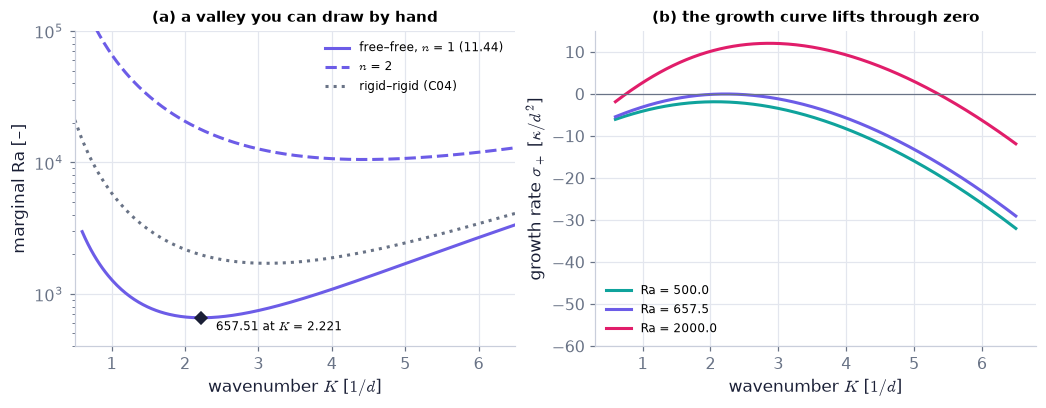

at Ra = 2000 the growing wavenumbers are [0.754 5.358] | largest sigma there: 12.06


In [58]:
Kp = np.linspace(0.6, 6.5, 300)                                    # wavenumbers [1/d]
fig, (a, b) = plt.subplots(1, 2, figsize=(9.4, 3.6))   # the figure and its panels
a.plot(Kp, ch11.benard_free_free_Ra(Kp), color=C_NEUT, label="free–free, $n$ = 1 (11.44)")   # free-free marginal curve, one half-wave across the layer: below it nothing grows
a.plot(Kp, ch11.benard_free_free_Ra(Kp, n=2), "--", color=C_NEUT, label="$n$ = 2")   # dashed: two half-waves across the layer - sixteen times harder to excite
a.plot(tab["K"], tab["rigid"], ":", color=C_BASE, label="rigid–rigid (C04)")   # dotted ghost: rigid plates, for comparison
a.plot(Kff, 27*np.pi**4/4, "D", color=COLORS["ink"])   # diamond: the free-free critical point 27 pi^4/4 at K = pi/sqrt(2)
a.text(Kff + 0.2, 520, "657.51 at $K$ = 2.221", fontsize=8)   # a label written on the plot
a.set_yscale("log")                                                # logarithmic Ra axis: the n = 2 curve (minimum 108 pi^4 = 10520) fits too
a.set(xlabel="wavenumber $K$ [$1/d$]", ylabel="marginal Ra [–]", ylim=(400, 1e5), xlim=(0.5, 6.5))   # axis labels (with units) and fixed ranges for this panel
a.set_title("(a) a valley you can draw by hand", fontsize=10)   # panel title — the message of this panel
a.legend(fontsize=8)   # legend: one entry per curve
for Ra_now, col in ((500.0, C_DECAY), (27*np.pi**4/4, C_NEUT), (2000.0, C_GROW)):   # repeat the indented lines for each item listed
    b.plot(Kp, [ch11.benard_free_free_sigma(K, Ra_now, 1.0)[0] for K in Kp], color=col, label=f"Ra = {Ra_now:.1f}")   # sigma_+(K), Pr = 1
b.axhline(0, color=C_BASE, lw=0.8)   # a reference line or band
b.set(xlabel="wavenumber $K$ [$1/d$]", ylabel=r"growth rate $\sigma_+$ [$\kappa/d^2$]", ylim=(-60, 15))   # axis labels (with units) and fixed ranges for this panel
b.set_title("(b) the growth curve lifts through zero", fontsize=10)   # panel title — the message of this panel
b.legend(fontsize=8)   # legend: one entry per curve
plt.show()   # display the figure
edges = [brentq(lambda K: ch11.benard_free_free_Ra(K) - 2000.0, lo, hi) for lo, hi in ((0.3, Kff), (Kff, 7.0))]   # where Ra(K) = 2000
print("at Ra = 2000 the growing wavenumbers are", np.round(edges, 3), "| largest sigma there:",   # the band of growing cell widths at Ra = 2000 ...
      round(max(ch11.benard_free_free_sigma(K, 2000.0, 1.0)[0] for K in Kp), 2))   # ... and the fastest growth inside it

**What does the code above do?**

1. `ch11.benard_free_free_Ra(K, n)` accepts arrays; `ch11.benard_free_free_sigma(K, Ra, Pr)` takes one $K$ at a time (hence the
   list comprehension) and returns $(\sigma_+,\sigma_-)$.
2. `brentq` finds the two wavenumbers where the neutral curve passes through Ra = 2000 — the edges of the growing band.

**What you see.** (a) On a logarithmic Ra axis: the free–free neutral curve for one half-wave across the layer (n = 1, purple), the one for two half-waves (dashed, sixteen times higher at its minimum), and the rigid curve as a grey dotted ghost between them; the diamond is the minimum. (b) The growth rate against K for three Rayleigh numbers: all negative (teal), touching zero at one K (purple), positive over a band (rose).

**How to read it.** This is C01's picture with a real formula: as Ra rises the whole growth curve lifts, touches zero first at K = 2.22 when Ra = 657.5, and then a band of growing wavenumbers opens (its edges are printed).

**What would change if…** …Pr = 7: the band edges stay where they are (σ = 0 does not involve Pr), the growth rates inside grow: $\sigma=22.26$ instead of 11.02 at $K_c$ for Ra = 2000.

**What would change if…** …the density depended on a second, slowly diffusing ingredient — salt? The same marginal problem reappears with Ra replaced by a
difference of two Rayleigh numbers, and diffusion can now *destabilise* a column that is lighter on top — C06.

---

## 11.5 Double-Diffusive Instability

**What is this section about?** Seawater's density depends on temperature and salt, and heat diffuses about a hundred times faster
than salt. That difference alone can make a column that is lighter on top overturn — in thin "salt fingers" or in oscillating
layers. We reuse the free–free Bénard solution to find the criterion, and meet the subtropical ocean's thermohaline staircases.

### 🧩 The salt-finger criterion $\frac{gd^4}{\nu}\Big[\frac\beta{\kappa_s}\frac{dS}{dz}-\frac\alpha\kappa\frac{d\bar T}{dz}\Big]=657$ (11.46) `C06`

*The question:* How can a column that is lighter on top still overturn?

#### The problem in plain words

In the subtropical Atlantic, warm salty water from the surface sits on top of cooler, fresher water. The warmth makes the top
lighter, the salt makes it heavier, and the warmth wins: the column is stable by its density. Yet profilers find the water
arranged in "staircases" — uniform layers metres thick separated by sharp steps — the fingerprint of salt fingers. How can
diffusion, which usually smooths everything, start an overturn?

#### The idea

```
warm, salty  ↑   a parcel pushed DOWN:   heat leaks in/out fast (κ)  → it takes the cold temperature of its new level
─────────────┼                           salt stays (κ_s ≈ κ/100)     → it keeps its extra salt
cold, fresh  ↓                           ⇒ colder AND saltier than its neighbours ⇒ heavier ⇒ keeps sinking: a FINGER
condition: the salt's destabilising effect (÷ its slow diffusivity κ_s) beats heat's stabilising one (÷ κ) by 27π⁴/4
```

📝 **Note.** **N53 [B]** **Two ingredients of density.** $\tilde\rho=\rho_0[1-\alpha(\tilde T-T_0)+\beta(\tilde s-s_0)]$ (the linear equation of state of
Ch. 1), with $\alpha$ the thermal expansion [1/K], $\beta$ the haline contraction [per g/kg], both positive, $s$ the salinity
[g/kg]; the salt diffusivity is $\kappa_s\approx1.5\times10^{-9}$ m²/s against $\kappa\approx1.4\times10^{-7}$ m²/s for heat:
$\tau\equiv\kappa_s/\kappa\approx0.011$.

In [59]:
from fluidpy import ch01_introduction as ch01                       # Ch. 1's linear seawater equation of state
rho = ch11.linear_eos(np.array([20.0, 10.0]), np.array([36.5, 35.0]))   # warm salty (20 C, 36.5 g/kg) and cold fresh (10 C, 35 g/kg) [kg/m^3]
print("densities [kg/m^3]:", np.round(rho, 3), "-> the warm salty water is lighter by", round(rho[1] - rho[0], 3))   # warm salty water on top is lighter: the column is statically stable
rho_ch01 = ch01.seawater_density_linear(293.15, 36.5, alpha_T=2e-4, beta_S=7.6e-4)   # the same water through Ch. 1's function (T in kelvin)
assert np.isclose(rho_ch01, rho[0])                                 # one equation of state, two chapters
print("tau = kappa_s/kappa =", round(1.5e-9/1.4e-7, 4))   # salt diffuses about a hundred times more slowly than heat

densities [kg/m^3]: [1026.117 1027.   ] -> the warm salty water is lighter by 0.883
tau = kappa_s/kappa = 0.0107


**What does the code above do?**

1. `ch11.linear_eos(T, S)` evaluates the linear equation of state with $\alpha=2\times10^{-4}$ K⁻¹, $\beta=7.6\times10^{-4}$ per
   g/kg, reference 10 °C and 35 g/kg.
2. Warm salty water on top is *lighter* than the cold fresh water below it by about 0.9 kg/m³ — statically stable.
3. The same number from Ch. 1's function (which takes kelvin): the assertion passes.

📝 **Note.** **N54 [B]** **Two regimes.**

| regime | arrangement | what a displaced parcel does | onset |
|---|---|---|---|
| **fingers** | hot salty over cold fresh ($d\bar T/dz>0$, $dS/dz>0$) | loses its temperature difference, keeps its salt, keeps going | stationary ($\sigma$ real): long thin fingers |
| **diffusive** | cold fresh over hot salty ($d\bar T/dz<0$, $dS/dz<0$) | keeps its salt but exchanges heat, overshoots and oscillates with growing amplitude | oscillatory ($\sigma$ complex, N06): convecting layers separated by sharp interfaces — Arctic water under sea ice |

The book gives no dispersion relation; ours (free–free walls, D13's equations with $\sigma$ kept) is the cubic
$(\sigma/\Pr+a^2)a^2(\sigma+a^2)(\sigma+\tau a^2)=K^2[-\mathrm{Ra}(\sigma+\tau a^2)+\tau\mathrm{Rs}(\sigma+a^2)]$ with
$a^2=\pi^2+K^2$ — Ra and Rs are defined in D13 (with §11.5's sign: Ra > 0 means warm on top).

In [60]:
s_f = ch11.double_diffusive_sigma(np.pi**2/2, 1000.0, 2000.0, 7.0, 0.0107)      # K^2 = pi^2/2, Ra = 1000, Rs = 2000, Pr = 7, tau = 0.0107
s_d = ch11.double_diffusive_sigma(np.pi**2/2, -2.0e4, -1.9e6, 7.0, 0.0107)      # cold fresh over hot salty (both gradients negative)
print("finger case, the three roots sigma:", np.round(s_f, 4))      # one real positive root: stationary growth
print("diffusive case, the three roots:   ", np.round(s_d, 2))      # a complex pair with positive real part: growing oscillations
print("onset type of the growing root:", "stationary" if abs(s_f[0].imag) < 1e-12 else "oscillatory", "|",   # fingers grow in place; the diffusive regime oscillates while it grows
      "stationary" if abs(s_d[0].imag) < 1e-12 else "oscillatory")   # (second half of the same statement: the diffusive case)

finger case, the three roots sigma: [  0.033  +0.j     -59.3133+17.9498j -59.3133-17.9498j]
diffusive case, the three roots:    [   9.8 +70.25j    9.8 -70.25j -138.19 +0.j  ]
onset type of the growing root: stationary | oscillatory


**What does the code above do?**

1. `ch11.double_diffusive_sigma(K2, Ra, Rs, Pr, tau)` returns the three roots of our cubic, largest real part first.
2. Fingers: one small positive *real* root — slow, stationary growth. Diffusive regime: a *complex pair* with positive real part —
   oscillations of growing amplitude (the "oscillatory" onset of N06), in a column that is statically stable.

> 📎 **Primer — uniqueness of a linear boundary-value problem.** `P266` · If two unknowns obey the same linear ODE with the same right-hand side and the same boundary conditions, and the homogeneous
problem has only the zero solution, they are equal: their difference solves the homogeneous problem, so it is zero. Here
$\big(\frac{d^2}{dz^2}-K^2\big)f=0$ with $f=0$ at both walls has only $f=0$ (its solutions are $e^{\pm Kz}$, which cannot vanish
twice).

In [61]:
import numpy as np                                    # arrays
K = 2.0                                               # a wavenumber
M = np.array([[np.exp(-K/2), np.exp(K/2)], [np.exp(K/2), np.exp(-K/2)]])   # f = A e^{Kz} + B e^{-Kz} at z = -1/2 and z = +1/2
print(np.linalg.det(M))                               # not zero -> only A = B = 0 works: the solution is unique

-7.253720815694037


#### 🧮 Derivation — The double-diffusive marginal equations and the salt-finger criterion `D13` ★★ (Eq. 11.46: $\frac{gd^4}\nu\Big[\frac\beta{\kappa_s}\frac{dS}{dz}-\frac\alpha\kappa\frac{d\bar T}{dz}\Big]=657$)

**What we want to show.** Repeat the Bénard derivation with salt added (the book only says "repeat the derivation") and find when a column that is lighter on top overturns.

**Assumptions.** Stress-free walls at fixed T and S (step 11); σ = 0 at the margin — valid for fingers, not for the oscillatory diffusive regime (step 6); dT̄/dz, dS/dz ≠ 0 (step 7).

**The plan.**

1. Linearise about linear profiles of T̄ and S̄ (as D05).
2. Eliminate pressure (as D06), scale (as D07) and set σ = 0.
3. Scale the amplitudes to the book's (11.45), $\Big(\frac{d^2}{dz^2}-K^2\Big)\hat T=-W,\ \ \frac{\kappa_s}\kappa\Big(\frac{d^2}{dz^2}-K^2\Big)\hat s=-W,\ \ \Big(\frac{d^2}{dz^2}-K^2\Big)^2W=-\mathrm{Ra}K^2\hat T+\mathrm{Rs}'K^2\hat s$.
4. Use uniqueness to tie T̂ to ŝ, then reuse C05.

**Tools we use** (each explained before this point): D05–D07 moves · uniqueness of a linear boundary-value problem (P266) · D11's free–free result

**We start from**

$$ \begin{array}{l}\text{Boussinesq with}\ \tilde\rho=\rho_0[1-\alpha(\tilde T-T_0)+\beta(\tilde s-s_0)]\ \text{(p. 492) and the salt equation} \\ \frac{\partial\tilde s}{\partial t}+(\tilde{\mathbf u}\cdot\nabla)\tilde s=\kappa_s\nabla^2\tilde s\end{array} $$

*In words:* two diffusing ingredients of density.

---

**Step 1 of 12 — Linearise about linear profiles.**

$$ \frac{\partial T'}{\partial t}+w\frac{d\bar T}{dz}=\kappa\nabla^2T',\ \frac{\partial s'}{\partial t}+ w\frac{dS}{dz}=\kappa_s\nabla^2s' $$

- *Why we can do this:* insert $\tilde T=\bar T(z)+T'$ and $\tilde s=\bar S(z)+s'$ into the heat equation and the salt equation $\frac{\partial\tilde s}{\partial t}+(\tilde{\mathbf u}\cdot\nabla)\tilde s=\kappa_s\nabla^2\tilde s$. The two profiles have constant gradients, so their Laplacians vanish; $(\mathbf u\cdot\nabla)\bar T=w\,d\bar T/dz$ because $\bar T$ depends on $z$ only; products of disturbances are dropped (the same moves as in D05).
- *In words:* vertical motion carries both ingredients.

---

**Step 2 of 12 — Write the buoyancy.**

$$ -\frac{g\rho'}{\rho_0}=g(\alpha T'-\beta s') $$

- *Why we can do this:* the linear EOS: warm is light (α), salty is heavy (β).
- *In words:* heat lifts, salt sinks.

---

**Step 3 of 12 — Eliminate the pressure.**

$$ \frac{\partial}{\partial t}\nabla^2w=g\nabla_H^2(\alpha T'-\beta s')+\nu\nabla^4w $$

- *Why we can do this:* start from the vertical momentum equation $\frac{\partial w}{\partial t}=-\frac1{\rho_0}\frac{\partial p}{\partial z}+g(\alpha T'-\beta s')+\nu\nabla^2w$; take its Laplacian; the divergence of the momentum equation gives $\nabla^2p=\rho_0g\frac{\partial}{\partial z}(\alpha T'-\beta s')$; differentiate that in $z$ and subtract, so the pressure cancels and $\nabla^2-\partial_z^2=\nabla_H^2$ remains (the moves of D06).
- *In words:* (11.29), $\frac{\partial}{\partial t}\nabla^2w=+g\alpha\nabla_H^2T'+\nu\nabla^4w$ with two sources.

---

**Step 4 of 12 — Scale (d, d²/κ, w by κ/d).**

$$ (\partial_t-\nabla^2)T'=-d\frac{d\bar T}{dz}W,\ \ (\partial_t-\tfrac{\kappa_s}\kappa\nabla^2)s'=-d\frac{dS}{dz}W $$

- *Why we can do this:* put $t\to(d^2/\kappa)t$, lengths $\to d$ and $w=(\kappa/d)W$. Every term of the heat equation then carries $\kappa/d^2$ except $w\,d\bar T/dz=(\kappa/d)W\,d\bar T/dz$; dividing by $\kappa/d^2$ leaves the factor $d$. The salt equation is divided by the same $\kappa/d^2$ (heat diffusion sets the time unit), which leaves $\kappa_s/\kappa$ on its Laplacian.
- *In words:* salt diffuses κ_s/κ times slower in these units.

---

**Step 5 of 12 — Note the sign of §11.5's Ra.**

$$ \mathrm{Ra}\equiv\frac{g\alpha d^4(d\bar T/dz)}{\nu\kappa},\ \ \mathrm{Rs}'\equiv\frac{g\beta d^4(dS/dz)}{\nu\kappa} $$

- *Why we can do this:* §11.5 defines Ra with dT̄/dz itself — negative when heated from below, the opposite of (11.21), $\mathrm{Ra}=\frac{g\alpha\Gamma d^4}{\kappa\nu}$ (slip #10's second convention).
- *In words:* here Ra > 0 means warm on top (stabilising).

---

**Step 6 of 12 — Insert normal modes, σ = 0.**

$$ (D^2-K^2)\hat T=d\frac{d\bar T}{dz}W,\ \tfrac{\kappa_s}\kappa(D^2-K^2)\hat s=d\frac{dS}{dz}W,\ (D^2-K^2)^2W= \frac{gd^3K^2}{\nu\kappa}(\alpha\hat T-\beta\hat s) $$

- *Why we can do this:* on a mode $e^{\mathrm i(kx+ly)+\sigma t}$ replace $\partial_t\to\sigma=0$, $\nabla_H^2\to-K^2$, $\nabla^2\to D^2-K^2$ in the two equations of step 4 and in step 3 scaled the same way (divide it by $\nu\kappa/d^5$). σ = 0 is right for fingers; the diffusive onset is oscillatory (N54).
- *In words:* three linked marginal equations.

---

**Step 7 of 12 — Scale the amplitudes.**

$$ \theta\equiv-\frac{\hat T}{d\,d\bar T/dz},\ \ \varsigma\equiv-\frac{\hat s}{d\,dS/dz} $$

- *Why we can do this:* this makes both right-hand sides −W, the form the book prints (it reuses the letters T̂, ŝ for θ, ς).
- *In words:* temperature and salt measured in units of their background change over d.

---

**Step 8 of 12 — Rewrite the three equations.**

$$ (D^2-K^2)\theta=-W,\ \tfrac{\kappa_s}\kappa(D^2-K^2)\varsigma=-W,\ (D^2-K^2)^2W=-\mathrm{Ra}K^2\theta+\mathrm{Rs}'K^2\varsigma\ \text{(11.45)} $$

- *Why we can do this:* substitute step 7 into step 6; the factors combine into Ra and Rs′ of step 5.
- *In words:* the book's (11.45), $\Big(\frac{d^2}{dz^2}-K^2\Big)\hat T=-W,\ \ \frac{\kappa_s}\kappa\Big(\frac{d^2}{dz^2}-K^2\Big)\hat s=-W,\ \ \Big(\frac{d^2}{dz^2}-K^2\Big)^2W=-\mathrm{Ra}K^2\hat T+\mathrm{Rs}'K^2\hat s$.

---

**Step 9 of 12 — Compare θ and (κ_s/κ)ς.**

$$ (D^2-K^2)\big[\theta-\tfrac{\kappa_s}\kappa\varsigma\big]=0,\ \ \theta-\tfrac{\kappa_s}\kappa\varsigma=0\ \text{at the walls} $$

- *Why we can do this:* subtract the first two equations; both amplitudes vanish at the walls.
- *In words:* their difference solves a problem with zero data.

---

**Step 10 of 12 — Use uniqueness.**

$$ \theta=\frac{\kappa_s}\kappa\varsigma\ \text{everywhere} $$

- *Why we can do this:* (D² − K²)f = 0 with f = 0 at both walls has only f = 0 (P266). The book writes T̂ = κ_sŝ/κ.
- *In words:* temperature and salt amplitudes are locked together.

---

**Step 11 of 12 — Substitute into the third equation.**

$$ (D^2-K^2)^2W=(\mathrm{Rs}-\mathrm{Ra})K^2\theta,\ \ \mathrm{Rs}\equiv\frac\kappa{\kappa_s}\mathrm{Rs}'= \frac{g\beta d^4(dS/dz)}{\nu\kappa_s} $$

- *Why we can do this:* ς = (κ/κ_s)θ. With (D² − K²)θ = −W this is exactly (11.39), $\Big(\frac{d^2}{dz^2}-K^2\Big)\hat T=-W,\ \ \Big(\frac{d^2}{dz^2}-K^2\Big)^2W=\mathrm{Ra}K^2\hat T$ with Ra replaced by Rs − Ra.
- *In words:* double diffusion is Bénard with an effective Rayleigh number.

---

**Step 12 of 12 — Use the free–free threshold.**

$$ \mathrm{Rs}-\mathrm{Ra}=\tfrac{27}4\pi^4\ \Leftrightarrow\ \frac{gd^4}\nu\Big[\frac\beta{\kappa_s}\frac{dS}{dz}- \frac\alpha\kappa\frac{d\bar T}{dz}\Big]=657\ \text{(11.46)} $$

- *Why we can do this:* identical equations and conditions give identical eigenvalues: D11's 27π⁴/4 ≈ 657.5 (the book rounds to 657).
- *In words:* the salt-finger criterion.

---

**Result**

$$ \begin{array}{l}\Big(\frac{d^2}{dz^2}-K^2\Big)\hat T=-W \\[4pt] \frac{\kappa_s}\kappa\Big(\frac{d^2}{dz^2}-K^2\Big)\hat s=-W \\[4pt] \Big(\frac{d^2}{dz^2}-K^2\Big)^2W=-\mathrm{Ra}K^2\hat T+\mathrm{Rs}'K^2\hat s\qquad\text{(11.45)} \\[4pt] \frac{gd^4}\nu\Big[\frac\beta{\kappa_s}\frac{dS}{dz}-\frac\alpha\kappa\frac{d\bar T}{dz}\Big]=657\qquad\text{(11.46)}\end{array} $$

*In words:* the salt gradient, divided by the slow salt diffusivity, must beat the heat gradient, divided by the fast one, by 27π⁴/4.

**What it means.** Because κ_s ≪ κ, a column can be lighter on top (αT_z > βS_z) and still satisfy (11.46), $\frac{gd^4}\nu\Big[\frac\beta{\kappa_s}\frac{dS}{dz}-\frac\alpha\kappa\frac{d\bar T}{dz}\Big]=657$: diffusion destabilises (C06's wedge). Fails for the diffusive regime (oscillatory onset), and for rigid walls (then 1708 replaces 657.5).

**Check it.** κ_s = κ and dS/dz = 0: Rs = 0 and the criterion becomes −Ra = 657.5, i.e. (11.21), $\mathrm{Ra}=\frac{g\alpha\Gamma d^4}{\kappa\nu}$'s Ra = 657.5 ✓ (single component). Thermocline numbers (C06's code cell prints them): the left side is about 6.1 × 10⁴, far above 657 ✓. Dimensionless ✓.

📝 **Notes taught inside `D13`:** **N55 [B]** the double-diffusive marginal equations and the second sign convention of the Rayleigh number (steps 5–8) · **N56 [B]** temperature and salt amplitudes locked together, and the threshold that follows (steps 9–12).

> ⚠️ **slip #10, second half — the book prints** in §11.5 $\mathrm{Ra}\equiv g\alpha d^4(d\bar T/dz)/(\nu\kappa)$ **; the correct
> form is** the same expression — it is not an error, but it is the *opposite sign* to §11.4's $\mathrm{Ra}=g\alpha\Gamma
> d^4/\kappa\nu$ with $\Gamma=-d\bar T/dz$: here Ra is negative when heated from below. That is why the third marginal equation
> carries $-\mathrm{Ra}$. In code: `ch11.rayleigh_number` (§11.4 sign) and `ch11.thermal_rayleigh_signed` (§11.5 sign).

> ⚠️ **Common confusion (traps in `D13`):** Mixing the two Ra signs ((11.21), $\mathrm{Ra}=\frac{g\alpha\Gamma d^4}{\kappa\nu}$ vs §11.5); forgetting that the book's T̂, ŝ in (11.45), $\Big(\frac{d^2}{dz^2}-K^2\Big)\hat T=-W,\ \ \frac{\kappa_s}\kappa\Big(\frac{d^2}{dz^2}-K^2\Big)\hat s=-W,\ \ \Big(\frac{d^2}{dz^2}-K^2\Big)^2W=-\mathrm{Ra}K^2\hat T+\mathrm{Rs}'K^2\hat s$ are scaled amplitudes; using Rs′ (with κ) instead of Rs (with κ_s) in the final criterion.

#### ✏️ Tiny example: a finger layer with easy Rayleigh numbers

§11.5 signs throughout.

1. Take $\mathrm{Ra}=1000$ (warm on top: stabilising) and $\mathrm{Rs}=2000$ (salty on top: destabilising).
2. Margin $\mathrm{Rs}-\mathrm{Ra}-27\pi^4/4=1000-657.5=342.5>0$ ⇒ finger-unstable.
3. Is the column statically stable? The density gradient is $\propto-\alpha T_z+\beta S_z$, and
   $\alpha T_z/(\beta S_z)=(\mathrm{Ra}\,\kappa)/(\mathrm{Rs}\,\kappa_s)=0.5/0.0107=46.7>1$: the heat term wins by far — lighter on top.
4. Still it overturns: the salt gradient counts $\kappa/\kappa_s\approx93$ times more in the criterion than in the density.

In [62]:
r = ch11.salt_finger_unstable(dTdz=0.01, dSdz=0.002, d=0.05, g=9.81)            # our thermocline: +0.01 K/m, +0.002 (g/kg)/m, a 5 cm layer
for name, val in r.items():                                         # every entry of the result
    print(f"  {name:15s} {val if isinstance(val, (bool, np.bool_)) else round(float(val), 3)}")   # one named result per line
d_min = 0.05*(27*np.pi**4/4/r["lhs"])**0.25                         # the left side of (11.46) grows like d^4: thickness where it equals 27 pi^4/4
print(f"thinnest finger-unstable layer: d = {100*d_min:.2f} cm")   # any layer thicker than this already forms fingers
cases = {"hot salty over cold fresh": (0.01, 0.002, 0.05), "cold fresh over hot salty": (-0.01, -0.0027, 0.11),   # five layers: the two double-diffusive arrangements ...
         "warm on top, no salt": (0.01, 0.0, 0.05), "cold on top, weakly": (-0.005, 0.0, 0.05), "cold on top, strongly": (-0.01, 0.0, 0.05)}   # ... and three with temperature only (stable, weakly top-heavy, strongly top-heavy)
for label, (Tz, Sz, d) in cases.items():                            # (dT/dz [K/m], dS/dz [(g/kg)/m], thickness [m])
    out = ch11.salt_finger_regime(Tz, Sz, d)                        # regime from the static stability and the cubic
    print(f"{label:28s} -> {out['regime']:11s} sigma_max = {np.round(out['sigma_max'], 2)}, lighter on top: {bool(out['density_stable'])}")   # the regime of each layer, its fastest growth rate, and whether it is lighter on top

  unstable        True
  lhs             61254.107
  margin          60596.596
  density_stable  True
  R_rho           1.316
  Ra              875.893
  Rs              62130.0
thinnest finger-unstable layer: d = 1.61 cm
hot salty over cold fresh    -> fingers     sigma_max = (7.5+0j), lighter on top: True
cold fresh over hot salty    -> diffusive   sigma_max = (9.03+72j), lighter on top: True
warm on top, no salt         -> stable      sigma_max = (-0.16+0j), lighter on top: True
cold on top, weakly          -> stable      sigma_max = (-0.16+0j), lighter on top: False
cold on top, strongly        -> overturning sigma_max = (4.15+0j), lighter on top: False


**What does the code above do?**

1. `ch11.salt_finger_unstable(dTdz, dSdz, d)` evaluates the criterion with SI gradients ($z$ up): `lhs` is its left side (about
   6 × 10⁴, far above 657), `margin` = lhs − 27π⁴/4, `density_stable` says the column is lighter on top, `R_rho` $=\alpha T_z/(\beta
   S_z)=1.32$ is the *density ratio* oceanographers use (above 1: heat wins the density), and `Ra`, `Rs` are the two Rayleigh numbers.
2. The left side scales like $d^4$, so a layer thicker than about 1.6 cm is already finger-unstable.
3. `ch11.salt_finger_regime` labels the regime: `fingers`, `diffusive` (complex $\sigma$: growing oscillations), `stable`,
   `overturning`. Note the fourth row: cold on top is top-heavy, yet a thin, weakly heated layer is still **stable** — being
   top-heavy is not enough, the threshold $27\pi^4/4$ has to be passed (the fifth row passes it).

In [63]:
lhs = 9.81*0.05**4/1e-6*(7.6e-4*0.002/1.5e-9 - 2e-4*0.01/1.4e-7)    # (11.46) typed out: (g d^4/nu) [beta S_z/kappa_s - alpha T_z/kappa]
assert np.isclose(lhs, r["lhs"])                                    # same number as the library
s_one = np.max(np.real(ch11.double_diffusive_sigma(np.pi**2/2, -2000.0, 0.0, 1.0, 1.0)))   # no salt, tau = 1, heated from below (Ra_11.5 = -2000)
assert np.isclose(s_one, ch11.benard_free_free_sigma(np.pi/np.sqrt(2), 2000.0, 1.0)[0])    # = C05's free-free growth rate at Ra = 2000
print(f"left side of (11.46) by hand: {lhs:.0f};  single-component limit of the cubic: sigma = {s_one:.4f}")   # the criterion typed by hand, and the check that no salt gives Benard convection back

left side of (11.46) by hand: 61254;  single-component limit of the cubic: sigma = 11.0155


**What does the code above do?**

1. The criterion in one line: the salt term divided by the slow diffusivity minus the heat term divided by the fast one.
2. Without salt and with equal diffusivities, the cubic must reduce to Bénard convection: its growth rate equals C05's 11.0155
   when §11.5's Ra = −2000 is §11.4's Ra = +2000.

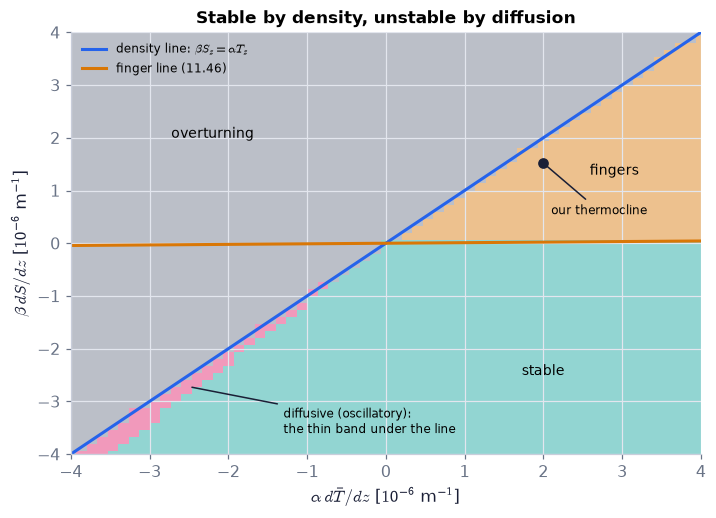

In [64]:
al, be, dd = 2e-4, 7.6e-4, 0.25                                    # alpha [1/K], beta [per g/kg], layer thickness [m] (a 25 cm layer)
n = 41 if FAST else 61                                             # grid points per axis
ax_T = np.linspace(-4e-6, 4e-6, n)                                 # alpha dT/dz [1/m]
ax_S = np.linspace(-4e-6, 4e-6, n)                                 # beta dS/dz [1/m]
code_of = {"stable": 0, "fingers": 1, "diffusive": 2, "overturning": 3}   # one integer per regime, so the map can be coloured
reg = np.array([[code_of[ch11.salt_finger_regime(x/al, y/be, dd)["regime"]] for x in ax_T] for y in ax_S])   # regime at every grid point
from matplotlib.colors import ListedColormap                       # a colour map with one colour per regime
cmap = ListedColormap([COLORS["teal"], COLORS["amber"], COLORS["rose"], COLORS["muted"]])   # teal stable, amber fingers, rose diffusive, grey overturning
fig, ax = plt.subplots(figsize=(6.4, 4.6))   # the figure and its panels
ax.pcolormesh(ax_T*1e6, ax_S*1e6, reg, cmap=cmap, vmin=-0.5, vmax=3.5, alpha=0.45, shading="auto")   # a colour map of the field
C_map = 27*np.pi**4/4*1e-6/(G0*dd**4)                              # the constant of (11.46), 27 pi^4 nu/(4 g d^4), for this thickness
ax.plot(ax_T*1e6, ax_T*1e6, color=C_BUOY, label="density line: $\\beta S_z=\\alpha T_z$")   # blue: salt and heat cancel in the density - below this line the column is lighter on top
ax.plot(ax_T*1e6, 1.5e-9*(ax_T/1.4e-7 + C_map)*1e6, color=C_SALT, lw=2, label="finger line (11.46)")   # amber: the finger criterion - above this line salt fingers grow
ax.plot(al*0.01*1e6, be*0.002*1e6, "o", color=COLORS["ink"])   # our thermocline: inside the wedge - lighter on top, yet fingering
ax.annotate("our thermocline", (al*0.01*1e6, be*0.002*1e6), (2.1, 0.55), fontsize=8, arrowprops=dict(arrowstyle="-", color=COLORS["ink"]))   # a label written on the plot
for (x, y, txt) in ((2.0, -2.5, "stable"), (-2.2, 2.0, "overturning"), (2.9, 1.3, "fingers")):   # repeat the indented lines for each item listed
    ax.text(x, y, txt, fontsize=9, ha="center")   # a label written on the plot
ax.annotate("diffusive (oscillatory):\nthe thin band under the line", (-2.5, -2.72), (-1.3, -3.6), fontsize=8,   # points at the thin band of growing oscillations
            arrowprops=dict(arrowstyle="-", color=COLORS["ink"]))   # a plain line as the pointer
ax.set(xlabel=r"$\alpha\,d\bar T/dz$ [$10^{-6}$ m$^{-1}$]", ylabel=r"$\beta\,dS/dz$ [$10^{-6}$ m$^{-1}$]", xlim=(-4, 4), ylim=(-4, 4))   # axis labels (with units) and fixed ranges for this panel
ax.set_title("Stable by density, unstable by diffusion", fontsize=11)   # panel title — the message of this panel
ax.legend(fontsize=8, loc="upper left")   # legend: one entry per curve
savefig(fig, "ch11", "c06_regimes")   # keep a copy in outputs/ch11 and display
plt.show()   # display the figure

**What does the code above do?**

1. Each grid point is one call of `ch11.salt_finger_regime` (static stability + the cubic of N54); the names are turned into
   integers 0–3 so that `pcolormesh` can colour them with a four-colour `ListedColormap`.
2. **Why 25 cm here, when the tiny example and slider F3 use 5 cm?** The borders are shifted away from the two lines by an
   offset proportional to $27\pi^4\nu/(4gd^4)$. At 25 cm that offset is invisible on these axes and the thin diffusive band can be
   resolved, so the map shows the regimes in their clean form; at 5 cm the offset is as large as the plotted gradients, which is
   exactly what F3 needs to show the wedge opening and closing.
3. The amber line is the criterion solved for the salt gradient: $\beta S_z=\frac{\kappa_s}{\kappa}\alpha T_z+\kappa_s\frac{27\pi^4\nu}{4gd^4}$.

**What you see.** A map of regimes for a 25 cm layer of seawater: horizontal axis the temperature gradient (times α), vertical axis the salt gradient (times β). Teal: stable. Amber: salt fingers. Rose: the diffusive (oscillatory) regime. Grey: ordinary overturning. The blue diagonal is where the density does not change with height; below it the column is lighter on top.

**How to read it.** The amber wedge between the nearly horizontal finger line and the blue density line is the surprise: lighter on top, yet unstable. It is wide because the finger line is almost the horizontal axis — the salt gradient is divided by the tiny salt diffusivity, so it counts about 93 times more than in the density. The thin rose band just under the blue line in the lower left is its mirror: cold fresh over hot salty, statically stable, growing oscillations. (For a much thinner layer every border moves away from the lines, because the threshold 27π⁴/4 then matters: the left side of the criterion scales like d⁴.)

**What would change if…** …the two diffusivities were equal: the finger line would turn parallel to the density line and lie above it — the wedge closes. No double diffusion without two diffusivities (slider figure F3).

**Slider figure F3 — two diffusivities open the wedge.** The ratio $\tau=\kappa_s/\kappa$ is the slider; the wedge is the region
between the finger line and the density line.

In [65]:
xT = np.linspace(-1e-6, 4e-6, 60)                                  # alpha dT/dz [1/m]
kap = 1.4e-7                                                       # thermal diffusivity [m^2/s]
C_f = 27*np.pi**4/4*1e-6/(G0*0.05**4)                              # the constant of (11.46) for a thin 5 cm layer, where it matters

def f3(tau):                                                       # the two lines and the wedge for one diffusivity ratio
    finger = tau*(xT + kap*C_f)                                    # finger line (11.46): beta S_z = tau (alpha T_z + kappa C)
    x0 = tau*kap*C_f/(1 - tau) if tau < 1 else np.inf              # where it meets the density line beta S_z = alpha T_z
    xs = np.linspace(x0, 4e-6, 40) if x0 < 4e-6 else np.array([np.nan])   # the wedge exists only to the right of that point
    wedge_x = np.concatenate([xs, xs[::-1]])                       # outline of the wedge: along the finger line, back along the density line
    wedge_y = np.concatenate([tau*(xs + kap*C_f), xs[::-1]])   # ... and the heights of that outline
    return {"density line (lighter on top below it)": (xT*1e6, xT*1e6), "finger line (11.46)": (xT*1e6, finger*1e6),   # the fixed density line and the finger line for this ratio of diffusivities
            "wedge: lighter on top, finger-unstable": (wedge_x*1e6, wedge_y*1e6)}   # the region between them: stable by density, unstable by diffusion

figF3 = slider_figure(f3, "κ_s/κ", np.round(np.geomspace(0.005, 1.0, 12 if FAST else 20), 4), xlabel="α dT/dz [1e-6 1/m]",   # slider: salt diffusivity over heat diffusivity
                      ylabel="β dS/dz [1e-6 1/m]", title="A 5 cm layer: the finger wedge closes as the diffusivities become equal",   # axis label and the message
                      xrange=(-1, 4), yrange=(-1, 4))   # fixed axes, so only the wedge moves
figF3.show()   # display the interactive slider figure

**What does the code above do?**

1. `f3(tau)` returns the density line, the finger line for that ratio, and the outline of the wedge between them.
2. At seawater's $\tau\approx0.011$ the wedge fills almost the whole lower-right triangle; at $\tau=1$ the finger line is parallel
   to the density line and above it — no wedge.

📝 **Note.** **N57 [C]** **Fingers, staircases and layers** (named): at onset the cells are as wide as the layer, but well above it the fingers are long and
thin; a thick finger layer breaks into a staircase of convecting layers with fingers only at the steps (observed in the
subtropical North Atlantic and the Tyrrhenian Sea); heating a salt gradient from below builds a stack of diffusive layers (the
Arctic under sea ice). The two requirements: two diffusivities, and opposite contributions to the density gradient. Climate hook:
salt fingers mix heat and salt at different rates — a term ocean models parameterise separately (Ch. 12).

#### 🎮 Interactive: How can a stably stratified column overturn?

**Why interactive rather than a static figure:** Dragging the two gradients across the regime map crosses the density-stable line and the finger line separately, so you see a
region that is stable by density yet finger-unstable; the parcel animation shows the parcel's temperature relaxing while its salt
stays; the diffusivity-ratio slider opens and closes the wedge.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Preset 'subtropical thermocline': read 'statically stable but finger-unstable'.
- Drag κ_s/κ to 1: the wedge closes and the same gradients are stable.
- Preset 'Arctic': the σ-roots leave the real axis as a complex pair with positive real part — growing oscillations.

In [66]:
show_viz("ch11", "salt_fingers")   # full-width explainer; ⤢ Full screen for more room

[explainer ch11/salt_fingers]

**What would change if…** …the "stratification" were not of heat or salt but of angular momentum — fluid spinning between two cylinders? The centrifugal
force plays gravity, and the same viscous threshold 1708 comes back — C07.

---

## 11.6 Centrifugal Instability: Taylor Problem

**What is this section about?** Fluid between two coaxial cylinders, the inner one spinning: above a certain speed the smooth
circular flow of Ch. 8 breaks into a stack of doughnut-shaped vortices. Rotation acts like gravity — the centrifugal force pulls
fast-spinning fluid outward — and the threshold has the same 1708 as Bénard convection. In the atmosphere and ocean the same
mechanism is "inertial instability" (Ch. 13).

> 🔁 **Recap — Rayleigh's circulation criterion** (Ch. 8 §8.2). Ch. 8 flagged circular Couette flow as inviscidly stable when $\Omega_2/\Omega_1>(R_1/R_2)^2$. In general (Rayleigh 1916): an
inviscid swirling flow is unstable if the square of the circulation, $\Gamma^2=(2\pi rU_\theta)^2$, decreases outward somewhere —
$d\Gamma^2/dr<0$ — just as a fluid is statically unstable when $d\bar\rho/dz>0$. C07 adds the reason (the ring interchange,
N59). Here $\Gamma$ is a circulation [m²/s], not a temperature gradient.

> 🔁 **Recap — Axisymmetric Navier–Stokes in cylindrical coordinates** (Ch. 4 Appendix B, Ch. 8 P186). With $\partial/\partial\varphi=0$: $\frac{D\tilde u_R}{Dt}-\frac{\tilde u_\varphi^2}R=-\frac1\rho\frac{\partial\tilde p}{\partial R}+
\nu\Big(\nabla^2\tilde u_R-\frac{\tilde u_R}{R^2}\Big)$, $\frac{D\tilde u_\varphi}{Dt}+\frac{\tilde u_R\tilde u_\varphi}R=\nu\Big(\nabla^2
\tilde u_\varphi-\frac{\tilde u_\varphi}{R^2}\Big)$, $\frac{D\tilde u_z}{Dt}=-\frac1\rho\frac{\partial\tilde p}{\partial z}+\nu\nabla^2\tilde u_z$,
$\frac1R\frac{\partial}{\partial R}(R\tilde u_R)+\frac{\partial\tilde u_z}{\partial z}=0$ (11.47), with
$\frac D{Dt}=\partial_t+\tilde u_R\partial_R+\tilde u_z\partial_z$ and $\nabla^2=\partial_R^2+\frac1R\partial_R+\partial_z^2$ — Ch. 4's
cylindrical operators ($R$ radius, $\varphi$ angle, $z$ along the axis).

> ⚠️ **slip #12 — the book prints** continuity (in the axisymmetric set and again in the linearised one) as $\frac{\partial}{\partial R}(R\tilde u_R)+
\frac{\partial\tilde u_z}{\partial z}=0$, whose two terms do not have the same units (m/s against 1/s) **; the correct form is** $\frac1R\frac{\partial}{\partial R}(R\tilde u_R)+\frac{\partial\tilde u_z}{\partial z}=0$.

> 🔁 **Recap — Circular Couette flow** (Ch. 8 §8.2). Between cylinders $R_1<R<R_2$ turning at $\Omega_1$, $\Omega_2$: $U_R=U_z=0$, $U_\varphi=AR+B/R$,
$\frac1\rho\frac{dP}{dR}=\frac{U_\varphi^2}R$ (11.49) with $A\equiv\frac{\Omega_2R_2^2-\Omega_1R_1^2}{R_2^2-R_1^2}$,
$B\equiv\frac{(\Omega_1-\Omega_2)R_1^2R_2^2}{R_2^2-R_1^2}$ — Ch. 8's solution $u_\varphi(R)=AR+\frac BR$ (8.9), computed by
`LAM.circular_couette(…, return_coeffs=True)`.

### 🧩 Taylor–Couette onset: $\mathrm{Ta}_{cr}=\frac{1708}{\tfrac12(1+\Omega_2/\Omega_1)}$ (11.54) from the narrow-gap equations and the Taylor number $\mathrm{Ta}=4\big(\frac{\Omega_1R_1^2-\Omega_2R_2^2}{R_2^2-R_1^2}\big)\frac{\Omega_1d^4}{\nu^2}$ (11.52) `C07`

*The question:* Why does spinning the inner cylinder stack up vortices, while spinning the outer one does not?

#### The problem in plain words

G. I. Taylor (1923) filled the gap between two glass cylinders with water and turned the inner one. At low speed the water simply
swirls in circles. Past a sharp speed, the flow organises into a stack of counter-rotating ring vortices, each about as tall as
the gap is wide. Turn the outer cylinder instead and nothing happens. The same physics governs a journal bearing, a Couette
viscometer — and, with Earth's rotation, inertial instability of jets in the atmosphere and ocean (Ch. 13).

#### The idea

```
swap two thin fluid rings (equal mass) at r₁ < r₂, each keeping its circulation Γ = 2πrU_θ (Kelvin):
    E = Γ²/(8π²r²) per unit mass   ⇒   ΔE = (Γ₂² − Γ₁²)(1/r₁² − 1/r₂²)/(8π²)
    Γ² falls outward (Γ₂² < Γ₁²)  ⇒ ΔE < 0: energy RELEASED ⇒ unstable   (inner cylinder spinning)
    Γ² rises outward              ⇒ ΔE > 0: you must PAY         ⇒ stable     (outer cylinder spinning)
centrifugal force ↔ gravity,  Γ² ↔ −ρ̄  — and viscosity adds a threshold, Ta_c ≈ 1708 / ((1 + Ω₂/Ω₁)/2)
```

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **Laplacian in cylindrical coordinates** — $\nabla^2=\partial_R^2+\frac1R\partial_R+\frac1{R^2}\partial_\varphi^2+\partial_z^2$; the extra $1/R$ terms are curvature terms. *(Ch. 8, P186)*
- **anisotropic scaling with two length scales** — when one length (the gap) is much smaller than another (the radius), derivatives across the small length dominate. *(Ch. 8, P188)*

📝 **Note.** **N58 [C]** **The set-up**: coaxial cylinders, radii $R_1<R_2$ [m], angular speeds $\Omega_1$, $\Omega_2$ [rad/s] (counter-clockwise
positive), gap $d=R_2-R_1$, ratio $\mu\equiv\Omega_2/\Omega_1$; experiments show the first instability is axisymmetric
($\partial/\partial\varphi=0$), so we only look at disturbances that are rings. Wavy vortices come later (N69).

📝 **Note.** **N59 [B]** **The ring interchange.** A ring of fluid at radius $r$ with circulation $\Gamma=2\pi rU_\theta$ has kinetic energy per unit mass
$E=U_\theta^2/2=\Gamma^2/(8\pi^2r^2)$. Swap rings 1 and 2 (equal masses), each keeping its own circulation (Kelvin's theorem):
$E_{\rm final}=\frac1{8\pi^2}\big[\frac{\Gamma_2^2}{r_1^2}+\frac{\Gamma_1^2}{r_2^2}\big]$,
$E_{\rm initial}=\frac1{8\pi^2}\big[\frac{\Gamma_1^2}{r_1^2}+\frac{\Gamma_2^2}{r_2^2}\big]$, so
$\Delta E=\frac1{8\pi^2}(\Gamma_2^2-\Gamma_1^2)\Big(\frac1{r_1^2}-\frac1{r_2^2}\Big)$ — since $r_2>r_1$ the second bracket is
positive and the sign of $\Delta E$ is the sign of $\Gamma_2^2-\Gamma_1^2$. Energy released ⇒ the swap happens on its own ⇒
unstable. (Notation: this argument and recap R14 write $r$, $U_\theta$; the derivation D14 below writes $R$, $U_\varphi$ — the same radius
and the same swirl velocity, in the symbols the book uses in each passage.)

In [67]:
print(ch11.ring_interchange_energy(4.0, 2.0, 1.0, 2.0))             # circulations 4 and 2 m^2/s at radii 1 and 2 m: energies [m^2/s^2] per unit mass
Rr = np.linspace(0.1, 0.105, 11)                                    # radii across a 5 mm gap [m]
inner = ch11.rayleigh_circulation_criterion(Rr, LAM.circular_couette(Rr, 0.1, 0.105, 0.5, 0.0))   # only the inner cylinder turns (0.5 rad/s)
outer = ch11.rayleigh_circulation_criterion(Rr, LAM.circular_couette(Rr, 0.1, 0.105, 0.4, 0.5))   # the outer cylinder turns faster
print("inner cylinder spinning: Rayleigh-unstable?", inner["unstable"], "| outer faster:", outer["unstable"])   # inner cylinder driving: unstable to ring swaps; outer faster: stable
print("Rayleigh line for this gap: mu = (R1/R2)^2 =", round(ch11.couette_rayleigh_line(0.1, 0.105), 4))   # the rotation ratio at which the squared circulation stops falling outward

{'E_i': 0.21530751523996777, 'E_f': 0.10132118364233778, 'dE': -0.11398633159763}
inner cylinder spinning: Rayleigh-unstable? True | outer faster: False
Rayleigh line for this gap: mu = (R1/R2)^2 = 0.907


**What does the code above do?**

1. `ch11.ring_interchange_energy(Gamma1, Gamma2, r1, r2)` returns the energies before and after the swap and their difference:
   $\Delta E=-0.114$ m²/s² — released, because the circulation falls outward.
2. `ch11.rayleigh_circulation_criterion(r, U_theta)` checks the sign of $d\Gamma^2/dr$ on a sampled profile; `LAM.circular_couette`
   (Ch. 8) supplies the profile.
3. With only the inner cylinder turning the flow is Rayleigh-unstable everywhere; with the outer one faster it is stable. The
   border is $\mu=(R_1/R_2)^2=0.907$ for our gap.

📝 **Note.** **N61 [B]** **Geometry**: a cut through the gap along the axis — the vortices are stacked rings; neighbouring rings turn opposite ways.

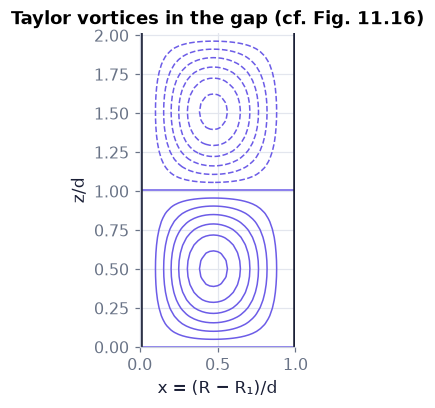

In [68]:
fig, ax = plt.subplots(figsize=(5.2, 3.6))   # the figure and its panels
taylor_sketch(ax)                                                  # drawing only: the gap and a stack of counter-rotating vortices
plt.show()   # display the figure

**What you see.** A meridional cut through the gap between the cylinders (the axis is to the left): a stack of counter-rotating cells.

**How to read it.** Neighbouring cells turn opposite ways; a pair spans one axial wavelength 2π/k, about twice the gap width.

**What would change if…** …the outer cylinder turns faster than the Rayleigh line allows: no cells at any speed.

> 📎 **Primer — narrow-gap (small-curvature) approximation: expand in d/R and keep the leading order.** `P267` · When the gap $d$ is much smaller than the radius $R_1$, curvature terms such as $\frac1R\frac{d}{dR}$ or $\frac1{R^2}$ are smaller
than $\frac{d^2}{dR^2}$ by factors $d/R_1$, $(d/R_1)^2$; we keep the leading order and drop the rest — the same idea as Ch. 8's
lubrication scaling (P188). With $x=(R-R_1)/d\in[0,1]$, $\frac d{dR}=\frac1d\frac d{dx}$.

In [69]:
R1, d = 0.10, 0.005                                   # 10 cm inner radius, 5 mm gap
print(d/R1, (d/R1)**2)                                # 0.05 and 0.0025: the sizes of the dropped terms relative to the kept one

0.049999999999999996 0.0024999999999999996


#### 🧮 Derivation — The linearised Taylor–Couette equations and the narrow-gap system `D14` ★★★ (Eq. 11.51: $\Big(\frac{d^2}{dR^2}-k^2-\sigma\Big)\Big(\frac{d^2}{dR^2}-k^2\Big)\hat u_R=(1+\alpha x)\hat u_\varphi,\ \ \Big(\frac{d^2}{dR^2}-k^2-\sigma\Big)\hat u_\varphi=-\mathrm{Ta}\,k^2\hat u_R$)

**What we want to show.** Derive the equations Taylor solved — the book only says "see Chandrasekhar (1961) for details".

**Assumptions.** Axisymmetric disturbances (∂/∂φ = 0); narrow gap d ≪ R₁ (steps 11–12).

**The plan.**

1. Linearise about Couette flow.
2. Insert normal modes in z and t and eliminate û_z and p̂.
3. Drop curvature in a narrow gap.
4. Scale and rescale so one number, Ta, is left.

**Tools we use** (each explained before this point): Cylindrical Laplacian (P186) · linearisation (P68) · operator elimination (P177) · narrow-gap approximation (P267) · sympy

**We start from**

$$ \begin{array}{l}\frac{D\tilde u_R}{Dt}-\frac{\tilde u_\varphi^2}R=-\frac1\rho\frac{\partial\tilde p}{\partial R}+\nu\Big(\nabla^2\tilde u_R-\frac{\tilde u_R}{R^2}\Big) \\[4pt] \frac{D\tilde u_\varphi}{Dt}+\frac{\tilde u_R\tilde u_\varphi}R=\nu\Big(\nabla^2\tilde u_\varphi-\frac{\tilde u_\varphi}{R^2}\Big) \\[4pt] \frac{D\tilde u_z}{Dt}=-\frac1\rho\frac{\partial\tilde p}{\partial z}+\nu\nabla^2\tilde u_z \\[4pt] \frac1R\frac{\partial}{\partial R}(R\tilde u_R)+\frac{\partial\tilde u_z}{\partial z}=0\qquad\text{(11.47)} \\[4pt] U_R=U_z=0 \\[4pt] U_\varphi=AR+\frac BR \\[4pt] \frac1\rho\frac{dP}{dR}=\frac{U_\varphi^2}R\qquad\text{(11.49)}\end{array} $$

*In words:* circular Couette flow and the Navier–Stokes equations in (R, φ, z).

---

**Step 1 of 15 — Split the fields.**

$$ \tilde{\mathbf u}=\mathbf U+\mathbf u,\ \tilde p=P+p\ \text{(11.48),}\ \mathbf U=(0,U_\varphi(R),0) $$

- *Why we can do this:* base flow plus small disturbance, as in every block.
- *In words:* swirl plus a small ring disturbance.

---

**Step 2 of 15 — Linearise the centrifugal term.**

$$ \frac{(U_\varphi+u_\varphi)^2}R\approx\frac{U_\varphi^2}R+\frac{2U_\varphi u_\varphi}R $$

- *Why we can do this:* expand the square and drop u_φ² (P68); the factor 2 comes from the cross term.
- *In words:* a faster ring feels twice the extra centrifugal pull.

---

**Step 3 of 15 — Write the radial equation.**

$$ \frac{\partial u_R}{\partial t}-\frac{2U_\varphi u_\varphi}R=-\frac1\rho\frac{\partial p}{\partial R}+ \nu\Big(\nabla^2u_R-\frac{u_R}{R^2}\Big) $$

- *Why we can do this:* subtract the base balance $\frac1\rho\frac{dP}{dR}=\frac{U_\varphi^2}R$ (11.49); U_R = 0, so advection by the base flow is absent (∂/∂φ = 0).
- *In words:* first line of (11.50), $\frac{\partial u_R}{\partial t}-\frac{2U_\varphi u_\varphi}R=-\frac1\rho\frac{\partial p}{\partial R}+\nu\Big(\nabla^2u_R-\frac{u_R}{R^2}\Big),\ \ \frac{\partial u_\varphi}{\partial t}+\Big(\frac{dU_\varphi}{dR}+\frac{U_\varphi}R\Big)u_R=\nu\Big(\nabla^2u_\varphi-\frac{u_\varphi}{R^2}\Big),\ \ \frac{\partial u_z}{\partial t}=-\frac1\rho\frac{\partial p}{\partial z}+\nu\nabla^2u_z,\ \ \frac1R\frac{\partial(Ru_R)}{\partial R}+\frac{\partial u_z}{\partial z}=0$.

---

**Step 4 of 15 — Write the other three.**

$$ \frac{\partial u_\varphi}{\partial t}+\Big(\frac{dU_\varphi}{dR}+\frac{U_\varphi}R\Big)u_R=\nu\Big(\nabla^2u_\varphi- \frac{u_\varphi}{R^2}\Big),\ \frac{\partial u_z}{\partial t}=-\frac1\rho\frac{\partial p}{\partial z}+\nu\nabla^2u_z,\ \frac1R\frac{\partial(Ru_R)}{\partial R}+ \frac{\partial u_z}{\partial z}=0 $$

- *Why we can do this:* u_R∂_RU_φ from advection and u_RU_φ/R from the Coriolis-like term are the only linear products. ⚠️ slip #12: continuity needs 1/R.
- *In words:* (11.50), $\frac{\partial u_R}{\partial t}-\frac{2U_\varphi u_\varphi}R=-\frac1\rho\frac{\partial p}{\partial R}+\nu\Big(\nabla^2u_R-\frac{u_R}{R^2}\Big),\ \ \frac{\partial u_\varphi}{\partial t}+\Big(\frac{dU_\varphi}{dR}+\frac{U_\varphi}R\Big)u_R=\nu\Big(\nabla^2u_\varphi-\frac{u_\varphi}{R^2}\Big),\ \ \frac{\partial u_z}{\partial t}=-\frac1\rho\frac{\partial p}{\partial z}+\nu\nabla^2u_z,\ \ \frac1R\frac{\partial(Ru_R)}{\partial R}+\frac{\partial u_z}{\partial z}=0$.

---

**Step 5 of 15 — Insert normal modes.**

$$ (u_R,u_\varphi,u_z,p)=(\hat u_R,\hat u_\varphi,\hat u_z,\hat p)(R)\,e^{\mathrm ikz+\sigma t} $$

- *Why we can do this:* coefficients depend on R only; k real keeps the disturbance bounded in z. Write $D=\frac d{dR}$, $D_*=\frac d{dR}+\frac1R$.
- *In words:* rings stacked along the axis.

---

**Step 6 of 15 — Express the operators.**

$$ \nabla^2-\frac1{R^2}\to DD_*-k^2,\qquad\nabla^2\to D_*D-k^2 $$

- *Why we can do this:* $DD_*f=f''+\frac{f'}R-\frac f{R^2}$ and $D_*Df=f''+\frac{f'}R$ (product rule); ∂²/∂z² → −k².
- *In words:* compact names for the radial operators.

---

**Step 7 of 15 — Solve continuity for û_z.**

$$ \hat u_z=\frac{\mathrm i}kD_*\hat u_R $$

- *Why we can do this:* $D_*\hat u_R+\mathrm ik\hat u_z=0$. Continuity is the only equation without a time derivative, so it gives the axial velocity directly; dividing by ik is allowed for k ≠ 0.
- *In words:* the axial flow closes the rings.

---

**Step 8 of 15 — Solve the axial equation for p̂.**

$$ \frac{\hat p}\rho=\frac1{k^2}\big(\nu(D_*D-k^2)-\sigma\big)D_*\hat u_R $$

- *Why we can do this:* $\sigma\hat u_z=-\frac{\mathrm ik}\rho\hat p+\nu(D_*D-k^2)\hat u_z$, then insert step 7 ($\frac{\mathrm i}k\cdot\frac1{\mathrm ik}=\frac1{k^2}$).
- *In words:* the pressure is slaved to the radial flow.

---

**Step 9 of 15 — Use the base vorticity.**

$$ \frac{dU_\varphi}{dR}+\frac{U_\varphi}R=2A\ \Rightarrow\ \big(\nu(DD_*-k^2)-\sigma\big)\hat u_\varphi=2A\,\hat u_R $$

- *Why we can do this:* $U_\varphi=AR+B/R$ gives $(A-B/R^2)+(A+B/R^2)=2A$; this is the azimuthal equation with normal modes.
- *In words:* the radial flow feeds the swirl disturbance at a rate set by 2A.

---

**Step 10 of 15 — Insert p̂ into the radial equation.**

$$ \big(\nu(DD_*-k^2)-\sigma\big)(DD_*-k^2)\hat u_R=2k^2\frac{U_\varphi}R\hat u_\varphi $$

- *Why we can do this:* $D(D_*D-k^2)=(DD_*-k^2)D$, so $-D\hat p/\rho=-\frac1{k^2}(\nu(DD_*-k^2)-\sigma)DD_*\hat u_R$; multiply by k² and collect.
- *In words:* the swirl disturbance drives the radial flow through the centrifugal force.

---

**Step 11 of 15 — Drop curvature (narrow gap).**

$$ DD_*\approx\frac{d^2}{dR^2} $$

- *Why we can do this:* the dropped terms are smaller by d/R₁ (P267).
- *In words:* the gap looks like a flat channel.

---

**Step 12 of 15 — Linearise the angular speed.**

$$ \frac{U_\varphi}R=\Omega(R)\approx\Omega_1(1+\alpha x),\ \ x=\frac{R-R_1}d,\ \ \alpha=\frac{\Omega_2}{\Omega_1}-1 $$

- *Why we can do this:* Ω goes from Ω₁ to Ω₂ across the gap; over a narrow gap a straight line is the leading approximation.
- *In words:* the fluid's spin varies linearly across the gap.

---

**Step 13 of 15 — Scale lengths and time.**

$$ \Big(\frac{d^2}{dx^2}-k^2-\sigma\Big)\Big(\frac{d^2}{dx^2}-k^2\Big)\hat u_R=\frac{2k^2d^2\Omega_1}\nu(1+\alpha x) \hat u_\varphi,\ \ \Big(\frac{d^2}{dx^2}-k^2-\sigma\Big)\hat u_\varphi=\frac{2Ad^2}\nu\hat u_R $$

- *Why we can do this:* d/dR = (1/d)d/dx; from now on k means kd and σ means σd²/ν (the book does not say so); divide by ν.
- *In words:* dimensionless in the gap width.

---

**Step 14 of 15 — Rescale the swirl amplitude.**

$$ \hat u_\varphi^{\,\text{new}}=\frac{2k^2d^2\Omega_1}{\nu}\,\hat u_\varphi^{\,\text{old}} $$

- *Why we can do this:* chosen so the first equation's right side becomes (1 + αx)û_φ; the constant moves to the second equation. Read it as: the new swirl amplitude is the old one multiplied by the constant; from here on the plain symbol means the new one.
- *In words:* only one number will remain.

---

**Step 15 of 15 — Read off Ta.**

$$ \begin{array}{l}\Big(\frac{d^2}{dR^2}-k^2-\sigma\Big)\hat u_\varphi=-\mathrm{Ta}\,k^2\hat u_R,\ \ \mathrm{Ta}=-\frac{4A\Omega_1d^4}{\nu^2}= 4\Big(\frac{\Omega_1R_1^2-\Omega_2R_2^2}{R_2^2-R_1^2}\Big)\frac{\Omega_1d^4}{\nu^2}\ \text{(11.51),} \\ \text{(11.52)}\end{array} $$

- *Why we can do this:* $\frac{2Ad^2}\nu\cdot\frac{2k^2d^2 \Omega_1}\nu=\frac{4A\Omega_1d^4}{\nu^2}k^2$ and A of (11.49), $U_R=U_z=0,\ \ U_\varphi=AR+\frac BR,\ \ \frac1\rho\frac{dP}{dR}=\frac{U_\varphi^2}R$. The book writes d/dR for d/dx.
- *In words:* Taylor's narrow-gap pair with the Taylor number.

---

**Result**

$$ \begin{array}{l}\Big(\frac{d^2}{dR^2}-k^2-\sigma\Big)\Big(\frac{d^2}{dR^2}-k^2\Big)\hat u_R=(1+\alpha x)\hat u_\varphi \\[4pt] \Big(\frac{d^2}{dR^2}-k^2-\sigma\Big)\hat u_\varphi=-\mathrm{Ta}\,k^2\hat u_R\qquad\text{(11.51)} \\[4pt] \mathrm{Ta}\equiv4\Big(\frac{\Omega_1R_1^2-\Omega_2R_2^2}{R_2^2-R_1^2}\Big)\frac{\Omega_1d^4}{\nu^2}\qquad\text{(11.52)} \\[4pt] \hat u_R=\frac{d\hat u_R}{dR}=\hat u_\varphi=0\ \text{at}\ x=0,1\qquad\text{(11.53)}\end{array} $$

*In words:* centrifugal forcing (Ta) against viscosity, in a flat gap.

**What it means.** The forcing is the product of the base flow's vorticity (2A) and its angular speed (Ω) — the centrifugal analogue of buoyancy times stratification. Fails for wide gaps (curvature) and for non-axisymmetric (wavy) modes.

**Check it.** Ta is dimensionless ✓; Ta ≤ 0 on and beyond the Rayleigh line (A ≥ 0 there) — no forcing ✓; μ → 1 gives Bénard (D15) ✓; `ch11.taylor_marginal_Ta` reproduces 3389.90 at μ = 0 ✓.

In [70]:
import sympy as sp                                         # symbolic algebra
R, A, B, k = sp.symbols("R A B k", positive=True)          # radius, Couette constants, axial wavenumber
U = A*R + B/R                                              # (11.49): circular Couette flow
print(sp.simplify(sp.diff(U, R) + U/R - 2*A))              # step 9: dU/dR + U/R = 2A  -> 0
u = sp.symbols("u")                                        # a small swirl disturbance
print(sp.expand((U + u)**2/R) - sp.expand(U**2/R))         # step 2: exact difference = 2Uu/R + u^2/R (the u^2 is dropped)
f = sp.Function("f")(R)                                    # any radial profile
D = lambda g: sp.diff(g, R); Ds = lambda g: sp.diff(g, R) + g/R    # D and D_* of step 5
lhs = D(Ds(D(f)) - k**2*f); rhs = D(Ds(D(f))) - k**2*D(f)  # step 10: D(D_*D - k^2) versus (DD_* - k^2)D
print(sp.simplify(lhs - rhs))                              # -> 0: the operators can be swapped as claimed
O1, O2, R1, R2, d, nu = sp.symbols("Omega1 Omega2 R1 R2 d nu", positive=True)   # symbols for sympy
Aco = (O2*R2**2 - O1*R1**2)/(R2**2 - R1**2)                # A of (11.49)
Ta_book = 4*(O1*R1**2 - O2*R2**2)/(R2**2 - R1**2)*O1*d**4/nu**2   # (11.52)
print(sp.simplify(-4*Aco*O1*d**4/nu**2 - Ta_book))         # step 15: Ta = -4 A Omega1 d^4/nu^2  -> 0

0
2*A*u + 2*B*u/R**2 + u**2/R
0


0


📝 **Notes taught inside `D14`:** **N60 [B]** the decomposition (step 1) · **N62 [B]** the linearised equations (steps 3–4) · **N63 [B]** normal modes and the narrow gap (steps 5, 11–12) · **N64 [B]** the narrow-gap pair (steps 13–15).

> ⚠️ **Common confusion (traps in `D14`):** The factor 2 in 2U_φu_φ/R; continuity without 1/R (slip #12); treating k and σ as dimensional after step 13; forgetting that Ω(x) is only linear to leading order.

In [71]:
tp = ch11.taylor_perturbation_sympy()                               # D14 redone by the library's sympy engine (cached)
print("linearised equations (residuals R, phi, z):", tp["lin_R"], tp["lin_phi"], tp["lin_z"])   # 0 0 0: step 3-4
print("dU/dR + U/R - 2A:", tp["term_2A"], "| operator identity of step 10:", tp["operator_identity"])   # 0 0
print("Ta coefficient (step 15):", tp["Ta_coefficient"])           # -4 A Omega1 d^4/nu^2 with d = R2 - R1
print("continuity as printed has consistent units?", tp["printed_continuity_units_ok"], "| corrected:", tp["correct_continuity_units_ok"])   # slip #12 as a units test

linearised equations (residuals R, phi, z): 0 0 0
dU/dR + U/R - 2A: 0 | operator identity of step 10: 0
Ta coefficient (step 15): -4*A*Omega1*(-R1 + R2)**4/nu_v**2
continuity as printed has consistent units? False | corrected: True


**What does the code above do?**

1. `ch11.taylor_perturbation_sympy()` linearises the axisymmetric equations about Couette flow and follows D14's eliminations;
   every residual is 0.
2. The last line is slip #12 as a units check: the printed continuity equation fails it, the corrected one passes.

#### 🧮 Derivation — The Taylor number's narrow-gap form $2(\Omega_1R_1d/\nu)^2(d/R_1)$ and the Bénard limit μ → 1 `D15` ★ (Eq. 11.52: $\mathrm{Ta}\equiv4\Big(\frac{\Omega_1R_1^2-\Omega_2R_2^2}{R_2^2-R_1^2}\Big)\frac{\Omega_1d^4}{\nu^2}$)

**What we want to show.** Simplify (11.52), $\mathrm{Ta}\equiv4\Big(\frac{\Omega_1R_1^2-\Omega_2R_2^2}{R_2^2-R_1^2}\Big)\frac{\Omega_1d^4}{\nu^2}$ for an inner cylinder spinning alone, and show why co-rotating cylinders give Bénard's 1708.

**Assumptions.** d ≪ R₁ (step 3); σ = 0 (step 5).

**The plan.**

1. Set Ω₂ = 0 and expand R₂² − R₁².
2. Set α = 0 in (11.51), $\Big(\frac{d^2}{dR^2}-k^2-\sigma\Big)\Big(\frac{d^2}{dR^2}-k^2\Big)\hat u_R=(1+\alpha x)\hat u_\varphi,\ \ \Big(\frac{d^2}{dR^2}-k^2-\sigma\Big)\hat u_\varphi=-\mathrm{Ta}\,k^2\hat u_R$ and compare with (11.39), $\Big(\frac{d^2}{dz^2}-K^2\Big)\hat T=-W,\ \ \Big(\frac{d^2}{dz^2}-K^2\Big)^2W=\mathrm{Ra}K^2\hat T$.

**Tools we use** (each explained before this point): Narrow-gap approximation (P267) · D09's (11.39)

**We start from**

$$ \begin{array}{l}\mathrm{Ta}\equiv4\Big(\frac{\Omega_1R_1^2-\Omega_2R_2^2}{R_2^2-R_1^2}\Big)\frac{\Omega_1d^4}{\nu^2}\qquad\text{(11.52)} \\[4pt] \Big(\frac{d^2}{dR^2}-k^2-\sigma\Big)\Big(\frac{d^2}{dR^2}-k^2\Big)\hat u_R=(1+\alpha x)\hat u_\varphi \\[4pt] \Big(\frac{d^2}{dR^2}-k^2-\sigma\Big)\hat u_\varphi=-\mathrm{Ta}\,k^2\hat u_R\qquad\text{(11.51)}\end{array} $$

*In words:* D14's results.

---

**Step 1 of 6 — Set Ω₂ = 0.**

$$ \mathrm{Ta}=\frac{4\Omega_1^2R_1^2d^4}{\nu^2(R_2^2-R_1^2)} $$

- *Why we can do this:* only the inner cylinder turns. We want the simplest case first — the one of the worked example below.
- *In words:* the inner-only Taylor number.

---

**Step 2 of 6 — Factor the denominator.**

$$ R_2^2-R_1^2=(R_2-R_1)(R_2+R_1)=d(2R_1+d) $$

- *Why we can do this:* difference of squares, R₂ = R₁ + d.
- *In words:* gap width times the sum of radii.

---

**Step 3 of 6 — Use the narrow gap.**

$$ \mathrm{Ta}\approx\frac{4\Omega_1^2R_1^2d^4}{2\nu^2R_1d}=2\Big(\frac{\Omega_1R_1d}\nu\Big)^2\frac d{R_1} $$

- *Why we can do this:* 2R₁ + d ≈ 2R₁ to leading order in d/R₁ (P267).
- *In words:* a Reynolds number squared times the gap ratio.

---

**Step 4 of 6 — Let the cylinders co-rotate (μ → 1).**

$$ \alpha=\mu-1\to0:\ \ (1+\alpha x)\to1 $$

- *Why we can do this:* the angular speed becomes uniform across the gap; we look at the *shape* of (11.51), $\Big(\frac{d^2}{dR^2}-k^2-\sigma\Big)\Big(\frac{d^2}{dR^2}-k^2\Big)\hat u_R=(1+\alpha x)\hat u_\varphi,\ \ \Big(\frac{d^2}{dR^2}-k^2-\sigma\Big)\hat u_\varphi=-\mathrm{Ta}\,k^2\hat u_R$, not at the flow at μ = 1 (where the leading Ta itself → 0).
- *In words:* the gap's spin no longer varies.

---

**Step 5 of 6 — Compare with Bénard at σ = 0.**

$$ \Big(\frac{d^2}{dx^2}-k^2\Big)^2\hat u_R=\hat u_\varphi,\ \Big(\frac{d^2}{dx^2}-k^2\Big)\hat u_\varphi=-\mathrm{Ta}k^2\hat u_R $$

- *Why we can do this:* put $\hat u_\varphi=\mathrm{Ta}\,k^2\hat T$, $\hat u_R=W$: the pair becomes $(D^2-k^2)^2W=\mathrm{Ta}k^2\hat T$ and $(D^2-k^2)\hat T=-W$ — (11.39), $\Big(\frac{d^2}{dz^2}-K^2\Big)\hat T=-W,\ \ \Big(\frac{d^2}{dz^2}-K^2\Big)^2W=\mathrm{Ra}K^2\hat T$ with Ta for Ra.
- *In words:* the same equations as heated convection.

---

**Step 6 of 6 — Compare the conditions.**

$$ \mathrm{Ta}_c(\mu\to1)=\mathrm{Ra}_c=1707.76\ \text{at}\ k=3.117 $$

- *Why we can do this:* (11.53), $\hat u_R=\frac{d\hat u_R}{dR}=\hat u_\varphi=0\ \text{at}\ x=0,1$ is W = W′ = T̂ = 0 at both walls, as (11.38), $W=\frac{dW}{dz}=\hat T=0\ \text{on}\ z=\pm\tfrac12$; same equations and conditions give the same eigenvalues (x ∈ [0, 1] is z ∈ [−½, ½] shifted). Our heuristic for (11.54), $\mathrm{Ta}_{cr}=\frac{1708}{\tfrac12(1+\Omega_2/\Omega_1)}$: the gap average of (1 + αx) is 1 + α/2 = ½(1 + μ).
- *In words:* 1708 again.

---

**Result**

$$ \begin{array}{l}\mathrm{Ta}\approx2(\Omega_1R_1d/\nu)^2(d/R_1)\ \text{(narrow gap, inner only);}\ \mathrm{Ta}_c\to1707.76\ \text{as μ → 1, and} \\ \mathrm{Ta}_{cr}\approx\frac{1708}{\frac12(1+\Omega_2/\Omega_1)}\ \text{(11.54)}\end{array} $$

*In words:* rotation's threshold is Bénard's, divided by the average spin factor.

**What it means.** Centrifugal instability is buoyancy in disguise. (11.54), $\mathrm{Ta}_{cr}=\frac{1708}{\tfrac12(1+\Omega_2/\Omega_1)}$ is a good fit for co-rotation (0.77 % at μ = 0), poor for counter-rotation (6.5 % at μ = −0.5).

**Check it.** R₁ = 0.1 m, d = 5 mm, Ω₁ = 0.5 rad/s: exact 6098 vs shortcut 6250 (shortcut/exact = 1.025: the shortcut is 2.5 % higher, a difference of order d/R₁) ✓; `ch11.taylor_critical(1.0)` = 1707.76 ✓.

📝 **Notes taught inside `D15`:** **N65 [B]** the Taylor number and its inner-cylinder, narrow-gap form (steps 1–3).

> ⚠️ **Common confusion (traps in `D15`):** Reading μ = 1 as "unstable at 1708" — at μ = 1 the flow is solid-body rotation and Ta ≈ 0: nothing drives it.

📝 **Note.** **N66 [B] · N67 [B]** **Conditions and the marginal state.** No slip on both cylinders: $\hat u_R=\frac{d\hat u_R}{dR}=\hat u_\varphi=0$ at $x=0,1$
(11.53). Taylor assumed the onset is stationary ($\sigma=0$); this is proved for cylinders turning the same way ($\mu\ge0$) and
checked numerically here, but not in general — for counter-rotation ($\mu<0$) the $\sigma=0$ curve is only what the narrow-gap
equations give *if* $\sigma=0$ is assumed.

In [72]:
for mu in (0.0, 0.5):                                               # outer cylinder at rest, and co-rotating at half the inner speed
    s = ch11.taylor_growth_rate(3.12, 4000.0, mu)                   # leading growth rate at k = 3.12, Ta = 4000 [units nu/d^2]
    print(f"mu = {mu}: sigma = {s.real:.4f} + {abs(s.imag):.1e} i  ->  {'unstable' if s.real > 0 else 'stable'}, stationary (no imaginary part)")   # a real, positive growth rate: vortices grow in place

mu = 0.0: sigma = 2.2663 + 3.2e-09 i  ->  unstable, stationary (no imaginary part)
mu = 0.5: sigma = 8.6121 + 9.2e-10 i  ->  unstable, stationary (no imaginary part)


#### ✏️ Tiny example: water between two cylinders

$R_1=10$ cm, $R_2=10.5$ cm (so $d=5$ mm and $R_2/R_1=1.05$, our choice), water $\nu=10^{-6}$ m²/s, outer cylinder at rest, inner
at $\Omega_1=0.5$ rad/s.

1. Taylor number: $\mathrm{Ta}=4\frac{\Omega_1R_1^2-0}{R_2^2-R_1^2}\cdot\frac{\Omega_1d^4}{\nu^2}=4\times\frac{0.5\times0.01}{0.001025}\times
   \frac{0.5\times6.25\times10^{-10}}{10^{-12}}=19.51\times312.5=6098$.
2. Narrow-gap shortcut $2(\Omega_1R_1d/\nu)^2(d/R_1)=2\times250^2\times0.05=6250$ — 2.5 % higher (the order $d/R_1$ we dropped).
3. Critical value for $\mu=0$: the approximate formula gives $1708/0.5=3416$; the exact narrow-gap value is 3389.9 (0.77 % lower).
4. $6098>3390$ ⇒ vortices.
5. Onset speed: $\mathrm{Ta}\propto\Omega_1^2$, so $\Omega_{1,c}=0.5\sqrt{3389.9/6098}=0.373$ rad/s (about 3.6 revolutions per
   minute).

In [73]:
Ta = ch11.taylor_number(0.5, 0.0, 0.1, 0.105, 1e-6)                 # (11.52): Omega1 = 0.5 rad/s, outer at rest, R1 = 0.1 m, R2 = 0.105 m, water
print(Ta, "| narrow-gap shortcut:", round(ch11.taylor_number_narrow_inner(0.5, 0.1, 0.005, 1e-6), 1))   # the Taylor number of our cylinders, and its thin-gap estimate
for mu in (1.0, 0.5, 0.0, -0.5):                                    # co-rotating ... outer at rest ... counter-rotating
    c = ch11.taylor_critical(mu)                                    # exact narrow-gap minimum over k (P263's recipe)
    a = ch11.taylor_critical_approx(mu)                             # the approximate formula (11.54)
    print(f"mu = {mu:5.2f}: Ta_c = {c['Ta_c']:8.2f} at k_c = {c['k_c']:.4f} | (11.54) gives {a:7.1f} ({100*(a/c['Ta_c'] - 1):+.2f} %)")   # exact threshold and preferred wavenumber, against the approximate formula
print(f"onset speed for our cylinders: Omega_1 = {0.5*np.sqrt(ch11.taylor_critical(0.0)['Ta_c']/Ta['Ta']):.3f} rad/s")   # the inner-cylinder speed at which vortices first appear

{'Ta': 6097.560975609732, 'rayleigh_stable': False, 'mu': 0.0} | narrow-gap shortcut: 6250.0


mu =  1.00: Ta_c =  1707.76 at k_c = 3.1163 | (11.54) gives  1708.0 (+0.01 %)


mu =  0.50: Ta_c =  2275.09 at k_c = 3.1175 | (11.54) gives  2277.3 (+0.10 %)


mu =  0.00: Ta_c =  3389.90 at k_c = 3.1266 | (11.54) gives  3416.0 (+0.77 %)


mu = -0.50: Ta_c =  6413.72 at k_c = 3.1985 | (11.54) gives  6832.0 (+6.52 %)


onset speed for our cylinders: Omega_1 = 0.373 rad/s


**What does the code above do?**

1. `ch11.taylor_number` returns a dictionary: `Ta` (6098 here), `rayleigh_stable` (True on and beyond the Rayleigh line, where
   Ta ≤ 0 and nothing drives the flow) and `mu`.
2. `ch11.taylor_critical(mu)` minimises the marginal Taylor number over $k$; `ch11.taylor_critical_approx(mu)` is the approximate
   formula. At $\mu=1$ the exact value is Bénard's 1707.76 (D15); the approximation is within 1 % for co-rotation and 6.5 % too
   high at $\mu=-0.5$ — it is a co-rotation formula.

In [74]:
O1, R1, R2, nu = 0.5, 0.1, 0.105, 1e-6                             # the worked example's numbers (SI)
Ta_mine = 4*(O1*R1**2 - 0.0*R2**2)/(R2**2 - R1**2)*O1*(R2 - R1)**4/nu**2      # (11.52) typed out
assert np.isclose(Ta_mine, ch11.taylor_number(O1, 0.0, R1, R2, nu)["Ta"])     # same number as the library
assert np.isclose(1708/(0.5*(1 + 0.5)), ch11.taylor_critical_approx(0.5))     # (11.54) typed out for mu = 0.5
dE_mine = (2.0**2 - 4.0**2)*(1/1.0**2 - 1/2.0**2)/(8*np.pi**2)                # N59's energy change for circulations 4, 2 at radii 1, 2
assert np.isclose(dE_mine, ch11.ring_interchange_energy(4.0, 2.0, 1.0, 2.0)["dE"])   # check: stops with an error if it fails
assert np.isclose(ch11.taylor_critical(1.0)["Ta_c"], ch11.benard_critical()["Ra_c"], rtol=1e-6)   # mu -> 1 is Benard (D15)
print(f"Ta by hand = {Ta_mine:.1f}; ring swap dE = {dE_mine:.5f} m^2/s^2; Ta_c(mu = 1) = Ra_c of Benard")   # the three formulas typed out agree with the library

Ta by hand = 6097.6; ring swap dE = -0.11399 m^2/s^2; Ta_c(mu = 1) = Ra_c of Benard


**What does the code above do?**

1. The Taylor number, the approximate critical value and the ring-swap energy typed out and compared with the library.
2. The last assertion is D15's claim with numbers: the co-rotating limit of the Taylor problem has the same eigenvalue as rigid
   Bénard convection.

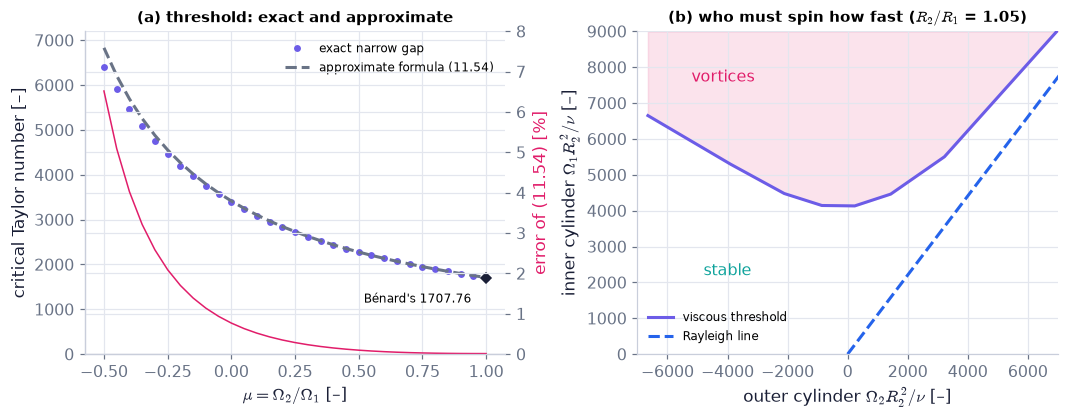

table: Ta_c(0.25) = 2724.98; recomputed now: 2724.98


In [75]:
tt = ch11.taylor_critical_table()                                  # exact narrow-gap Ta_c(mu) for mu = -0.5 ... 1 (read from reference/ch11)
sb = ch11.taylor_stability_boundary(mus=np.linspace(-1.0, 0.85, 6 if FAST else 8))   # the marginal curve for our radius ratio 1.05
fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 3.7))   # the figure and its panels
a.plot(tt["mu"], tt["Ta_c"], "o", ms=3.5, color=C_NEUT, label="exact narrow gap")   # dots: the exact narrow-gap threshold for each rotation ratio
a.plot(tt["mu"], tt["approx"], "--", color=C_BASE, label="approximate formula (11.54)")   # dashed: the book's approximate formula - good for co-rotation, poor for counter-rotation
a.plot(1.0, BENCH["benard_rigid_rigid"]["Ra_c"], "D", color=COLORS["ink"], ms=5)   # diamond: at equal rotation rates the threshold is Benard's 1707.76
a.text(0.52, 1150, "Bénard's 1707.76", fontsize=8)   # a label written on the plot
a.set(xlabel=r"$\mu=\Omega_2/\Omega_1$ [–]", ylabel="critical Taylor number [–]", ylim=(0, 7200))   # axis labels (with units) and fixed ranges for this panel
a2 = a.twinx()                                                     # a second vertical axis for the error
a2.plot(tt["mu"], 100*tt["rel_error"], color=C_GROW, lw=1)   # how far the approximate formula is off, in per cent
a2.set_ylabel("error of (11.54) [%]", color=C_GROW)   # axis labels, with units where the quantity has them
a2.set_ylim(0, 8)   # axis range / scale chosen so the feature discussed below is visible
a.set_title("(a) threshold: exact and approximate", fontsize=10)   # panel title — the message of this panel
a.legend(fontsize=8, loc="upper right")   # legend: one entry per curve
b.fill_between(sb["x_outer"], sb["y_inner"], 9000, color=C_GROW, alpha=0.12)   # shade the area between two curves
b.plot(sb["x_outer"], sb["y_inner"], color=C_NEUT, label="viscous threshold")   # the viscous threshold: above this curve Taylor vortices appear
b.plot(sb["rayleigh_x"], sb["rayleigh_y"], "--", color=C_BUOY, label="Rayleigh line")   # dashed: Rayleigh's inviscid border - right of it nothing can drive vortices
b.text(-5200, 7600, "vortices", color=C_GROW)   # a label written on the plot
b.text(-4800, 2200, "stable", color=C_DECAY)   # a label written on the plot
b.set(xlabel=r"outer cylinder $\Omega_2R_2^2/\nu$ [–]", ylabel=r"inner cylinder $\Omega_1R_2^2/\nu$ [–]", xlim=(-7000, 7000), ylim=(0, 9000))   # axis labels (with units) and fixed ranges for this panel
b.set_title("(b) who must spin how fast ($R_2/R_1$ = 1.05)", fontsize=10)   # panel title — the message of this panel
b.legend(fontsize=8, loc="lower left")   # legend: one entry per curve
savefig(fig, "ch11", "c07_taylor")   # keep a copy in outputs/ch11 and display
plt.show()   # display the figure
live_one = ch11.taylor_critical(0.25)                              # one value recomputed now, to compare with the table
i25 = int(np.argmin(np.abs(tt["mu"] - 0.25)))                      # the table row for mu = 0.25
print(f"table: Ta_c(0.25) = {tt['Ta_c'][i25]:.2f}; recomputed now: {live_one['Ta_c']:.2f}")   # one stored threshold recomputed now
assert np.isclose(tt["Ta_c"][i25], live_one["Ta_c"], rtol=6e-4)    # the stored table has 4-6 significant figures

**What does the code above do?**

1. `ch11.taylor_critical_table()` reads our stored table of exact narrow-gap minima (31 values of μ); the last three lines
   recompute one of them live and compare (`rtol` ≥ 6e-4 because the table is stored with few digits).
2. `ch11.taylor_stability_boundary(mus=…)` converts $\mathrm{Ta}_c(\mu)$ into the two cylinder speeds for the radius ratio 1.05,
   and returns the Rayleigh line $\Omega_1/\Omega_2=R_2^2/R_1^2$.
3. `a.twinx()` adds a second vertical axis that shares the horizontal one.

**What you see.** (a) The critical Taylor number against the rotation ratio: purple dots exact, grey dashed the approximate formula, the thin rose line (right axis) its error. (b) The plane of the two cylinder speeds for our radius ratio: above the purple curve vortices appear (rose); the blue dashed line is Rayleigh's inviscid border.

**How to read it.** (a) At μ = 1 the threshold is Bénard's 1707.76; it rises as the outer cylinder slows and rises steeply for counter-rotation, where the approximate formula drifts off: 6.5 % too high at μ = −0.5. (b) With the outer cylinder at rest (the vertical axis) the inner one must exceed about 4100 in these units. To the right (co-rotation) the purple curve (a polygon through 8 computed points) rises with the Rayleigh line and stays above it — by roughly 1500 units at the right edge; to the left (counter-rotation) the flow is Rayleigh-unstable for *any* inner speed, yet viscosity holds it until the curve is crossed.

**What would change if…** …a wider gap (say a radius ratio 1.5): the narrow-gap theory no longer applies and the true curve moves (named).

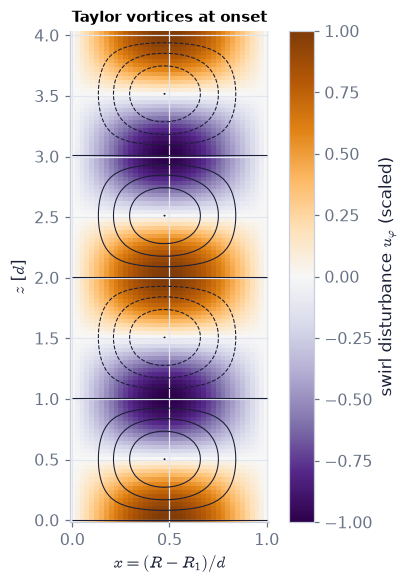

axial wavelength 2 pi/k_c = 2.010 d  ->  each vortex is 1.005 d tall


In [76]:
kc0 = ch11.taylor_critical(0.0)["k_c"]                             # critical axial wavenumber for mu = 0 [1/d]
tv = ch11.taylor_eigenfunction(kc0, 0.0, x=np.linspace(0, 1, 41), z=np.linspace(0, 2*2*np.pi/kc0, 121))   # fields over two wavelengths
fig, ax = plt.subplots(figsize=(3.6, 5.2))   # the figure and its panels
pc = ax.pcolormesh(tv["x"], tv["z"], tv["u_phi"]/np.max(np.abs(tv["u_phi"])), cmap="PuOr_r", shading="auto")   # swirl disturbance (scaled)
ax.contour(tv["x"], tv["z"], tv["psi"], 8, colors=COLORS["ink"], linewidths=0.7)   # streamlines of the meridional flow
fig.colorbar(pc, ax=ax, label=r"swirl disturbance $u_\varphi$ (scaled)")   # the colour scale and what it measures
ax.set(xlabel="$x=(R-R_1)/d$", ylabel="$z$ [$d$]")   # axis labels (with units) and fixed ranges for this panel
ax.set_title("Taylor vortices at onset", fontsize=10)   # panel title — the message of this panel
plt.show()   # display the figure
print(f"axial wavelength 2 pi/k_c = {2*np.pi/kc0:.3f} d  ->  each vortex is {np.pi/kc0:.3f} d tall")   # each vortex is about as tall as the gap is wide

**What does the code above do?**

1. `ch11.taylor_eigenfunction(k, mu, x, z)` returns the marginal mode on an $(x,z)$ grid: radial velocity `u_R`, swirl disturbance
   `u_phi`, axial velocity `u_z` and the stream function `psi` of the meridional flow ($u_R=\partial\psi/\partial z$).

**What you see.** Streamlines (black) of the flow in the plane through the axis, over two wavelengths; colour shows where the swirl is faster (orange) or slower (purple) than Couette flow. The inner cylinder is on the left.

**How to read it.** Each cell is about as tall as the gap is wide. Where the cells carry fluid outward (away from the inner cylinder) they bring fast-swirling fluid with them — the orange jets; inflow brings slow fluid — the purple ones. That is the centrifugal analogue of warm plumes rising.

**What would change if…** …μ → 1: the cells become exactly Bénard's rolls (D15), with the swirl disturbance in the role of temperature.

**Slider figure F4 — the marginal curve for each rotation ratio.** For every $\mu$: the exact narrow-gap curve $\mathrm{Ta}(k)$,
its minimum, and the constant value of the approximate formula.

In [77]:
kT = np.linspace(2.0, 4.6, 12 if FAST else 17)                     # axial wavenumbers [1/d]

def f4(mu):                                                        # traces for one rotation ratio
    Ta_k = np.array([ch11.taylor_marginal_Ta(k, mu) for k in kT])  # exact narrow-gap marginal Taylor number at each k
    j = int(np.argmin(Ta_k))                                       # the lowest point of the curve
    appr = ch11.taylor_critical_approx(mu) if mu > -1 else np.nan  # the approximate formula (11.54)
    return {"exact narrow gap Ta(k)": (kT, Ta_k), "minimum": (np.array([kT[j]]), np.array([Ta_k[j]])),    # the curve and its lowest point
            "approximate formula (11.54)": (kT, np.full(len(kT), appr))}                                # a horizontal line at 1708/((1 + mu)/2)

figF4 = slider_figure(f4, "μ = Ω₂/Ω₁", np.round(np.linspace(-0.5, 1.0, 7 if FAST else 11), 3), xlabel="axial wavenumber k [1/d]",   # slider: mu
                      ylabel="marginal Taylor number", title="Counter-rotation raises the threshold; co-rotation approaches 1708",   # labels
                      yrange=(1500, 9000), modes={"minimum": "markers"})   # fixed range; the minimum drawn as a marker
figF4.show()   # display the interactive slider figure

**What does the code above do?**

1. `ch11.taylor_marginal_Ta(k, mu)` solves the narrow-gap equations at $\sigma=0$ for the Taylor number at one $k$.
2. At $\mu=1$ the minimum is 1707.76; drag left and the valley rises and its floor moves to larger $k$.

📝 **Note.** **N68 [B]** **Theory against Taylor's experiment**: Taylor's measured onset speeds lay on his narrow-gap curve — one of the first quantitative
triumphs of linear stability theory. Our panel (b) above redraws the theory for our radius ratio (the book's ratio is not used);
the agreement shown in the book is with Taylor's own data.

📝 **Note.** **N124 [B]** **A second route (Exercises 11.8–11.9).** At $\sigma=0$ the narrow-gap pair reads
$\big(\frac{d^2}{dR^2}-k^2\big)^2\hat u_R=(1+\alpha x)\hat u_\varphi$ (11.92) and
$\big(\frac{d^2}{dR^2}-k^2\big)\hat u_\varphi=-\mathrm{Ta}\,k^2\hat u_R$ (11.93, corrected); expanding
$\hat u_\varphi=\sum_{m=1}^\infty C_m\sin(m\pi x)$ (11.94) and projecting on each sine (a Galerkin method — Ch. 10's idea with
sines instead of hats) gives the critical value with four modes to 0.01 %.

> ⚠️ **slip #7 — the book prints** the second equation of Exercise 11.9 as $\big(\frac{d^2}{dR^2}-k^2\big)^2\hat u_\varphi=-\mathrm{Ta}\,k^2\hat u_R$ **; the correct form is** $\big(\frac{d^2}{dR^2}-k^2\big)\hat u_\varphi=-\mathrm{Ta}\,k^2\hat u_R$ — the first power, as the narrow-gap equations give
at $\sigma=0$; with the square the problem would be of eighth order.

In [78]:
Ta_gal = ch11.taylor_galerkin_Ta(kc0, 0.0, n_modes=4)               # four sine modes (Exercise 11.9's route)
Ta_ex = ch11.taylor_marginal_Ta(kc0, 0.0)                           # the Chebyshev eigenvalue
Ta_pr = ch11.taylor_galerkin_Ta(kc0, 0.0, n_modes=4, printed=True)  # the same projection with the printed (squared) operator of slip #7
print(f"Galerkin, 4 sines: {Ta_gal:.2f} | Chebyshev: {Ta_ex:.2f} | difference {100*abs(Ta_gal/Ta_ex - 1):.3f} %")   # two different discretisations give the same threshold
print("with the printed operator:", Ta_pr, "(nan = no positive real Taylor number exists for that form)")   # the printed (squared) operator has no threshold at all

Galerkin, 4 sines: 3390.27 | Chebyshev: 3389.90 | difference 0.011 %
with the printed operator: nan (nan = no positive real Taylor number exists for that form)


**What does the code above do?**

1. Two independent discretisations of the same marginal problem agree to about 0.01 %.
2. With the printed square on the operator, the projected problem has no positive real eigenvalue at all (the function returns
   `nan`, "not a number") — the printed form cannot be the equation that was meant.

📝 **Note.** **N69 [C]** **After onset** (named): as $\Omega_1$ rises the vortices become wavy ($\partial/\partial\varphi\neq0$), then modulated, then
turbulent (Coles 1965); the steady equations have many solutions for the same speeds (non-uniqueness). Relatives: Dean vortices in
curved channels, Görtler vortices on concave walls. Pointer: the route to turbulence, N111 and Ch. 12.

#### 🎮 Interactive: Why do stacked vortices appear between spinning cylinders?

**Why interactive rather than a static figure:** Dragging the rotation ratio and the Taylor number moves the point across the Rayleigh line and the viscous boundary separately;
the profile view shows where the squared circulation falls outward and the ring-pair inspector gives the energy change for any two
radii; vortices appear only past the viscous curve.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Preset 'inner only': raise Ta until the vortices appear — compare the onset with the approximate formula's 3416 and the exact 3390.
- Preset 'counter-rotation': the status says Rayleigh-unstable but viscously stable — explain why with the ring inspector near each wall.
- Drag μ to 1: the threshold becomes Bénard's 1708.

In [79]:
show_viz("ch11", "taylor_couette_onset")   # full-width explainer; ⤢ Full screen for more room

[explainer ch11/taylor_couette_onset]

**What would change if…** …the "restoring" stratification and the "driving" shear lived in the same fluid at the same place — a current over a stably
stratified thermocline? Then gravity and shear compete continuously across the layer, and one ODE (Taylor–Goldstein) decides — C08.

---

## 11.7 Instability of Continuously Stratified Parallel Flows

**What is this section about?** C02 had a sharp interface; real oceans and atmospheres have smooth profiles of velocity $U(z)$ and
density $\bar\rho(z)$. We derive one equation for small waves on such a flow (Taylor–Goldstein, C08), then prove two theorems that
need no solving: if the gradient Richardson number exceeds ¼ everywhere the flow is stable (C09), and any unstable wave speed
lies inside a semicircle set by the slowest and fastest fluid (C10).

> 🔁 **Recap — The stratified parallel flow** (Ch. 4 §4.9, Ch. 7 §7.8). Basic state plus disturbance: $\tilde{\mathbf u}=U(z)\mathbf e_x+\mathbf u$, $\tilde p=P+p$, $\tilde\rho=\bar\rho(z)+\rho$, with the
inviscid Boussinesq momentum equation $\frac{\partial\tilde{\mathbf u}}{\partial t}+(\tilde{\mathbf u}\cdot\nabla)\tilde{\mathbf
u}=-\frac1{\rho_0}\nabla\tilde p-g\frac{\bar\rho+\rho}{\rho_0}\mathbf e_z$ and the hydrostatic balance of the basic state,
$0=-\frac1{\rho_0}\frac{\partial P}{\partial z}-g\frac{\bar\rho}{\rho_0}$ — Ch. 4's Boussinesq set and Ch. 7 §7.8's base state. Only
two-dimensional disturbances are considered (Squire's theorem, proved in C11 for unstratified flow, is *assumed* here).

> 🔁 **Recap — The buoyancy frequency** (Ch. 1 §1.10, Ch. 7 §7.8). $N^2\equiv-\frac g{\rho_0}\frac{d\bar\rho}{dz}$ (7.127) [1/s²] (Ch. 7 §7.8; Ch. 1's $N^2=-\frac g\rho\big(\frac{d\rho}{dz}-\frac{d\rho_a}{dz}\big)$
(1.29) for an incompressible fluid); with it the linearised density equation becomes $\frac{\partial\rho}{\partial t}+U\frac{\partial
\rho}{\partial x}-\frac{\rho_0N^2w}g=0$ (11.56). ⚠️ slip #13: where §11.7 recalls $N^2$ the book prints the cross-reference
"(7.128)"; in Ch. 7 the definition $N^2\equiv-\frac g{\rho_0}\frac{d\bar\rho}{dz}$ carries the number (7.127), and (7.128) is the
momentum equation after it — a slip of the cross-reference only, the formula is right.

In [80]:
N2_thermo = STRAT.brunt_vaisala_sq(1025.0, -0.002*1025.0/10.0, 0.0)   # a thermocline: density falls by 0.2 % over 10 m upward [1/s^2]
print(f"N^2 = {N2_thermo:.2e} 1/s^2,  N = {np.sqrt(N2_thermo):.4f} rad/s,  period 2 pi/N = {2*np.pi/np.sqrt(N2_thermo)/60:.1f} min")   # stratification of a thermocline: a displaced parcel bobs every couple of minutes

N^2 = 1.96e-03 1/s^2,  N = 0.0443 rad/s,  period 2 pi/N = 2.4 min


**What does the code above do?**

1. `STRAT.brunt_vaisala_sq(rho0, drho_dz, drho_a_dz)` is Ch. 1's function: reference density, density gradient [kg/m⁴] and the
   adiabatic gradient (zero for water here).
2. A 0.2 % density change over 10 m gives $N^2\approx2\times10^{-3}$ s⁻² — a parcel would bob with a period of about two minutes.

> 🔁 **Recap — The stream function, §11.7 version** (Ch. 4 §4.3, Ch. 7 §7.8). $u=\frac{\partial\psi}{\partial z}$, $w=-\frac{\partial\psi}{\partial x}$ (11.57) — Ch. 7's sign. ⚠️ slip #9: §11.8 uses
$u=\partial\psi/\partial y$, $v=-\partial\psi/\partial x$ ($y$ is the cross-stream coordinate there) and §11.14 uses
$u=-\partial\psi/\partial z$, $w=\partial\psi/\partial x$; each block repeats its own.

### 🧩 The Taylor–Goldstein equation $(U-c)\big(\frac{d^2}{dz^2}-k^2\big)\hat\psi-\frac{d^2U}{dz^2}\hat\psi+\frac{N^2}{U-c}\hat\psi=0$ (11.61) `C08`

*The question:* What single equation decides whether a stratified current is stable?

#### The problem in plain words

A tidal current flows over a stably stratified thermocline; a jet stream blows over a cold inversion. The velocity changes smoothly
with height, and so does the density. Shear wants to roll the layers up; the density stratification resists lifting heavy water.
We want one equation that contains both, for one wave at a time.

#### The idea

Exactly C02's recipe with smooth profiles: linearise, use a stream function so continuity is automatic, insert
$e^{\mathrm ik(x-ct)}$, eliminate pressure and density. One second-order ODE in $z$ remains, with $c$ as the eigenvalue: $U''$ is
the shear profile's curvature (C12 will make it the hero), $N^2/(U-c)$ the stratification. With $N^2=0$ it is Rayleigh's equation
of C12.

📝 **Note.** **N70 [C]** **History.** Taylor (1915) conjectured from examples that a gradient Richardson number below ¼ is needed for instability; Prandtl,
Goldstein, Richardson, Synge and Chandrasekhar suggested other values; Miles (1961) proved Taylor's conjecture and Howard (1961)
gave the short proof we follow (C09).

#### 🧮 Derivation — The stratified perturbation equations `D16` ★ (Eq. 11.57: $u=\frac{\partial\psi}{\partial z},\ \ w=-\frac{\partial\psi}{\partial x}$)

**What we want to show.** Write the linear equations of small 2-D disturbances on a stratified current U(z), ρ̄(z).

**Assumptions.** Inviscid, non-diffusive, Boussinesq, 2-D disturbances (Squire assumed).

**The plan.**

1. Subtract the base state and linearise.
2. Write components.
3. Linearise the density equation.
4. Introduce ψ.

**Tools we use** (each explained before this point): Linearisation (P68) · the material derivative $\frac{DF}{Dt}=\frac{\partial F}{\partial t}+\mathbf u\cdot\nabla F$ (3.5) of Ch. 3 · N² (R18) · the stream function (R19)

**We start from**

$$ \begin{array}{l}\frac{\partial\tilde{\mathbf u}}{\partial t}+(\tilde{\mathbf u}\cdot\nabla)\tilde{\mathbf u}=-\frac1{\rho_0}\nabla\tilde p-g\frac{\bar\rho+\rho}{\rho_0}\mathbf e_z\ \text{and} \\ 0=-\frac1{\rho_0}\frac{\partial P}{\partial z}-g\frac{\bar\rho}{\rho_0}\ \text{(p. 502–503),}\ \frac{D\tilde\rho}{Dt}=0\end{array} $$

*In words:* inviscid, non-diffusive Boussinesq flow and its hydrostatic base.

---

**Step 1 of 7 — Subtract the base and linearise.**

$$ \frac{\partial\mathbf u}{\partial t}+(\mathbf u\cdot\nabla)(U\mathbf e_x)+U(\mathbf e_x\cdot\nabla)\mathbf u= -\frac1{\rho_0}\nabla p-g\frac\rho{\rho_0}\mathbf e_z $$

- *Why we can do this:* insert ũ = Ue_x + u, p̃ = P + p, ρ̃ = ρ̄ + ρ; the base pressure cancels the base weight; drop products of disturbances.
- *In words:* the disturbance is advected by U and shears U.

---

**Step 2 of 7 — Evaluate (u·∇)(Ue_x).**

$$ (\mathbf u\cdot\nabla)(U\mathbf e_x)=w\frac{dU}{dz}\mathbf e_x $$

- *Why we can do this:* U depends on z only. A derivative of U along x is zero, so only the vertical velocity can change the momentum the fluid carries.
- *In words:* vertical motion moves fast fluid down or slow fluid up.

---

**Step 3 of 7 — Take the x-component.**

$$ \frac{\partial u}{\partial t}+w\frac{dU}{dz}+U\frac{\partial u}{\partial x}=-\frac1{\rho_0}\frac{\partial p}{\partial x}\ \text{(11.55) first} $$

- *Why we can do this:* e_x-parts of step 1 with step 2.
- *In words:* horizontal momentum.

---

**Step 4 of 7 — Take the z-component.**

$$ \frac{\partial w}{\partial t}+U\frac{\partial w}{\partial x}=-\frac1{\rho_0}\frac{\partial p}{\partial z}-g\frac\rho{\rho_0}\ \text{(11.55) second} $$

- *Why we can do this:* e_z-parts of step 1. The base flow has no vertical velocity, so no shear term appears here; gravity acts on the density disturbance.
- *In words:* vertical momentum with buoyancy.

---

**Step 5 of 7 — Correct the printed form.**

$$ -\frac1{\rho_0}\frac{\partial p}{\partial z}\ \text{(not}\ \frac{\partial p}{\partial x}) $$

- *Why we can do this:* ⚠️ slip #4: the book's (11.55), $\frac{\partial u}{\partial t}+w\frac{dU}{dz}+U\frac{\partial u}{\partial x}=-\frac1{\rho_0}\frac{\partial p}{\partial x},\ \ \frac{\partial w}{\partial t}+U\frac{\partial w}{\partial x}=-\frac1{\rho_0}\frac{\partial p}{\partial z}-g\frac\rho{\rho_0}$ prints ∂p/∂x in the w-equation; the z-component of ∇p is ∂p/∂z, as (11.57), $u=\frac{\partial\psi}{\partial z},\ \ w=-\frac{\partial\psi}{\partial x}$ then uses.
- *In words:* a misprint the next equation silently corrects.

---

**Step 6 of 7 — Linearise the density equation.**

$$ \frac{\partial\rho}{\partial t}+U\frac{\partial\rho}{\partial x}+w\frac{d\bar\rho}{dz}=0\ \Leftrightarrow\ \frac{\partial\rho}{\partial t}+U\frac{\partial\rho}{\partial x}-\frac{\rho_0N^2w}g=0\ \text{(11.56)} $$

- *Why we can do this:* Dρ̃/Dt, the material derivative $\frac{DF}{Dt}=\frac{\partial F}{\partial t}+\mathbf u\cdot\nabla F$ (3.5) of Ch. 3, with ρ̄(z); drop uρ_x, wρ_z; N² = −(g/ρ₀)dρ̄/dz (7.127), $N^2\equiv-\frac g{\rho_0}\frac{d\bar\rho}{dz}$.
- *In words:* rising fluid brings heavier fluid up.

---

**Step 7 of 7 — Introduce the stream function.**

$$ u=\frac{\partial\psi}{\partial z},\ w=-\frac{\partial\psi}{\partial x}\ \text{⇒ (11.57)} $$

- *Why we can do this:* this satisfies ∂u/∂x + ∂w/∂z = 0 automatically (R19, §11.7 sign).
- *In words:* three equations for ψ, p, ρ.

---

**Result**

$$ \begin{array}{l}\frac{\partial u}{\partial t}+w\frac{dU}{dz}+U\frac{\partial u}{\partial x}=-\frac1{\rho_0}\frac{\partial p}{\partial x} \\[4pt] \frac{\partial w}{\partial t}+U\frac{\partial w}{\partial x}=-\frac1{\rho_0}\frac{\partial p}{\partial z}-g\frac\rho{\rho_0}\qquad\text{(11.55)} \\[4pt] \frac{\partial\rho}{\partial t}+U\frac{\partial\rho}{\partial x}-\frac{\rho_0N^2w}g=0\qquad\text{(11.56)} \\[4pt] u=\frac{\partial\psi}{\partial z} \\[4pt] w=-\frac{\partial\psi}{\partial x}\qquad\text{(11.57)}\end{array} $$

*In words:* linear advection by U, production by shear (wU′), buoyancy and stratification (N²).

**What it means.** The input to D17. Fails with diffusion or viscosity (C11) and for 3-D stratified disturbances (Squire is not a theorem here).

**Check it.** Units: each momentum term m/s², density terms kg/(m³ s) ✓. With U = 0: Ch. 7's internal-wave equations ✓.

📝 **Notes taught inside `D16`:** **N71 [B]** the linearised momentum equations, with slip #4 (steps 3–5).

> ⚠️ **slip #4 — the book prints** the pressure term of the $w$-equation as $-\frac1{\rho_0}\frac{\partial p}{\partial x}$ **; the
> correct form is** $-\frac1{\rho_0}\frac{\partial p}{\partial z}$ — the vertical momentum equation needs the vertical pressure
> gradient, and the next equation in the book indeed uses it (step 5).

> ⚠️ **Common confusion (traps in `D16`):** Slip #4; the sign of w with ψ (w = −∂ψ/∂x here).

> 📎 **Primer — singular point of an ODE.** `P269` · Where the coefficient of the highest derivative vanishes, an ODE is *singular*: in the Taylor–Goldstein and Rayleigh equations that
happens where $U(z)=c$. For a growing mode ($c_i\neq0$) it never happens; for a neutral mode (real $c$ inside the velocity range)
the solution may have a kink or a logarithm there — the critical layer of C12. Viscosity (C11) removes the singularity by restoring
the fourth derivative.

In [81]:
import numpy as np                                    # arrays
z = np.linspace(-1, 1, 5)                             # five heights
U, c = z, 0.5                                         # Couette flow U = z and a real wave speed inside its range
print(U - c)                                          # changes sign: the coefficient (U - c) vanishes at z = 0.5

[-1.5 -1.  -0.5  0.   0.5]


#### 🧮 Derivation — The Taylor–Goldstein equation `D17` ★★ (Eq. 11.61: $(U-c)\Big(\frac{d^2}{dz^2}-k^2\Big)\hat\psi-\frac{d^2U}{dz^2}\hat\psi+\frac{N^2}{U-c}\hat\psi=0$)

**What we want to show.** Reduce (11.57), $u=\frac{\partial\psi}{\partial z},\ \ w=-\frac{\partial\psi}{\partial x}$ to one ODE for the stream-function amplitude ψ̂(z).

**Assumptions.** U(z) ≠ c everywhere (step 7; true for c_i ≠ 0).

**The plan.**

1. Insert the modes.
2. Remove the pressure by differentiating and subtracting.
3. Remove the density.

**Tools we use** (each explained before this point): Normal modes (C01) · differentiation and the product rule (P38) · complex algebra (P153)

**We start from**

$$ \begin{array}{l}\frac{\partial u}{\partial t}+w\frac{dU}{dz}+U\frac{\partial u}{\partial x}=-\frac1{\rho_0}\frac{\partial p}{\partial x} \\[4pt] \frac{\partial w}{\partial t}+U\frac{\partial w}{\partial x}=-\frac1{\rho_0}\frac{\partial p}{\partial z}-g\frac\rho{\rho_0}\qquad\text{(11.55)} \\[4pt] \frac{\partial\rho}{\partial t}+U\frac{\partial\rho}{\partial x}-\frac{\rho_0N^2w}g=0\qquad\text{(11.56)} \\[4pt] u=\frac{\partial\psi}{\partial z} \\[4pt] w=-\frac{\partial\psi}{\partial x}\qquad\text{(11.57)} \\[4pt] [\rho,p,\psi]=[\hat\rho,\hat p,\hat\psi](z)\,e^{\mathrm ik(x-ct)}\ \ \text{(one normal mode)}\end{array} $$

*In words:* the stratified disturbance equations, one wave at a time.

---

**Step 1 of 9 — Replace the derivatives.**

$$ \frac{\partial}{\partial x}\to\mathrm ik,\ \ \frac{\partial}{\partial t}\to-\mathrm ikc $$

- *Why we can do this:* the mode's exponential (C01). Differentiating an exponential multiplies it by the coefficient in its exponent, so each derivative becomes a number.
- *In words:* every x, t derivative becomes a factor.

---

**Step 2 of 9 — Insert into the x-equation.**

$$ (U-c)\hat\psi'-U'\hat\psi=-\frac{\hat p}{\rho_0}\ \text{(11.58)} $$

- *Why we can do this:* $-\mathrm ikc\hat\psi'-\mathrm ik\hat\psi U'+\mathrm ikU\hat\psi'=-\mathrm ik\hat p/\rho_0$; divide by ik.
- *In words:* horizontal momentum of the mode.

---

**Step 3 of 9 — Insert into the z-equation.**

$$ k^2(U-c)\hat\psi=-\frac{g\hat\rho}{\rho_0}-\frac{\hat p'}{\rho_0}\ \text{(11.59)} $$

- *Why we can do this:* $-\partial_t\partial_x\psi\to-(-\mathrm ikc)(\mathrm ik)\hat\psi=-k^2c\hat\psi$ and $-U\partial_x^2\psi\to k^2U\hat\psi$.
- *In words:* vertical momentum of the mode.

---

**Step 4 of 9 — Insert into the density equation.**

$$ (U-c)\hat\rho+\frac{\rho_0N^2}g\hat\psi=0\ \text{(11.60)} $$

- *Why we can do this:* $-\mathrm ikc\hat\rho+\mathrm ikU \hat\rho+\frac{\rho_0N^2}g\mathrm ik\hat\psi=0$; divide by ik.
- *In words:* the density disturbance from vertical displacement.

---

**Step 5 of 9 — Differentiate (11.58) in z.**

$$ (U-c)\hat\psi''+U'\hat\psi'-U''\hat\psi-U'\hat\psi'=-\frac{\hat p'}{\rho_0} $$

- *Why we can do this:* product rule (P38); we need p̂′ to match (11.59), $k^2(U-c)\hat\psi=-\frac{g\hat\rho}{\rho_0}-\frac{\hat p'}{\rho_0}$.
- *In words:* the two U′ψ̂′ terms cancel.

---

**Step 6 of 9 — Subtract (11.59).**

$$ (U-c)(\hat\psi''-k^2\hat\psi)-U''\hat\psi=\frac{g\hat\rho}{\rho_0} $$

- *Why we can do this:* the p̂′ terms cancel; that was the aim (the book's single sentence).
- *In words:* pressure gone, density left.

---

**Step 7 of 9 — Solve (11.60) for ρ̂.**

$$ \hat\rho=-\frac{\rho_0N^2\hat\psi}{g(U-c)} $$

- *Why we can do this:* divide by U − c, allowed only where U ≠ c (not at a critical layer, P269).
- *In words:* density follows the displacement.

---

**Step 8 of 9 — Substitute.**

$$ (U-c)(\hat\psi''-k^2\hat\psi)-U''\hat\psi=-\frac{N^2}{U-c}\hat\psi $$

- *Why we can do this:* $\frac g{\rho_0}\hat\rho=-\frac{N^2\hat\psi}{U-c}$. Inserting the density removes the last unknown except the stream-function amplitude.
- *In words:* one equation for ψ̂.

---

**Step 9 of 9 — Move everything left.**

$$ (U-c)\Big(\frac{d^2}{dz^2}-k^2\Big)\hat\psi-\frac{d^2U}{dz^2}\hat\psi+\frac{N^2}{U-c}\hat\psi=0\ \text{(11.61)} $$

- *Why we can do this:* add the right side to both sides.
- *In words:* the Taylor–Goldstein equation.

---

**Result**

$$ \begin{array}{l}(U-c)\Big(\frac{d^2}{dz^2}-k^2\Big)\hat\psi-\frac{d^2U}{dz^2}\hat\psi+\frac{N^2}{U-c}\hat\psi=0\qquad\text{(11.61)} \\[4pt] \hat\psi(0)=\hat\psi(d)=0\qquad\text{(11.62)}\end{array} $$

*In words:* shear curvature U″ and stratification N² decide the eigenvalue c.

**What it means.** The master equation of inviscid stratified shear instability (C09, C10, Ch. 13). Fails where U = c (critical layers need viscosity or a careful limit).

**Check it.** N² = 0: Rayleigh's equation (11.81), $(U-c)\Big(\frac{d^2\phi}{dy^2}-k^2\phi\Big)-\frac{d^2U}{dy^2}\phi=0$ ✓; units of every term 1/s × 1/m (×ψ̂) ✓; `ch11.stratified_shear_sympy()["tg_residual"] == 0` ✓.

📝 **Notes taught inside `D17`:** **N72 [B]** the three normal-mode equations (steps 2–4).

> ⚠️ **Common confusion (traps in `D17`):** (ik)² = −k² sign bookkeeping; forgetting that the U′ψ̂′ terms cancel; dividing by U − c without saying it is nonzero.

📝 **Note.** **N73 [B] · N74 [B]** **Pairs again.** The Taylor–Goldstein equation contains no $\mathrm i$, so if $(\hat\psi,c)$ solves it so does $(\hat\psi^*,c^*)$:
every growing mode has a decaying twin, and any $c_i\neq0$ means instability (as N17). **Rigid lids:** $w=0$ at $z=0$ and $z=d$ means
$\partial\psi/\partial x=\mathrm ik\hat\psi e^{\mathrm ik(x-ct)}=0$ there, so $\hat\psi(0)=\hat\psi(d)=0$ (11.62); for an unbounded
layer, $\hat\psi\to0$ far away.

> 📎 **Primer — quadratic eigenvalue problem c²M₂ + cM₁ + M₀ and its companion linearisation.** `P268` · Multiplying the Taylor–Goldstein equation by $(U-c)$ leaves $c^2$ in it, so collocation gives $(c^2M_2+cM_1+M_0)\mathbf v=0$.
Introduce $\mathbf w=c\mathbf v$; then
$\begin{pmatrix}0&I\\-M_0&-M_1\end{pmatrix}\begin{pmatrix}\mathbf v\\\mathbf w\end{pmatrix}=c\begin{pmatrix}I&0\\0&M_2\end{pmatrix}
\begin{pmatrix}\mathbf v\\\mathbf w\end{pmatrix}$ — an ordinary generalised eigenproblem twice as large (P259). For 1 × 1
"matrices" it is the quadratic formula in disguise.

In [82]:
import numpy as np                                    # arrays
from scipy.linalg import eig                          # generalised eigen-solver (P259)
M2, M1, M0 = 1.0, -3.0, 4.0                           # c^2 - 3c + 4 = 0 (the quadratic of C02's tiny example, divided by 4)
A = np.array([[0, 1], [-M0, -M1]])                    # companion matrix: second row holds -M0, -M1
B = np.array([[1, 0], [0, M2]])                       # second row holds M2
print(eig(A, B, right=False))                         # 1.5 + 1.3229j and 1.5 - 1.3229j: the same two roots

[1.5+1.3229j 1.5-1.3229j]


> 📎 **Primer — mapping an infinite domain to [−1, 1].** `P270` · A tanh shear layer or a jet extends to $z=\pm\infty$, but Chebyshev points live on $[-1,1]$. A map stretches them: our solvers use
$z=s\tan(\theta\xi)$ with $\theta=\arctan(z_{\max}/s)$, which sends $\xi\in[-1,1]$ to $[-z_{\max},z_{\max}]$, crowds the points
near the layer ($\lvert z\rvert\lesssim s$) and still reaches far away, where the disturbance (which decays like
$e^{-k\lvert z\rvert}$) is set to zero. Derivatives follow from the chain rule (Ch. 1 P49):
$\frac{d}{dz}=\frac{d\xi}{dz}\frac{d}{d\xi}$. Always check that the answer does not change when $s$, $z_{\max}$ or $N$ changes — long
waves need a bigger box (`ST.decay_box(k)` = max(30, 12/k)).

In [83]:
import numpy as np                                    # arrays
from fluidpy.core import stability as ST              # the eigen-solver toolkit
g = ST.cheb_grid(8, map="tan", y_max=30.0, s=0.5)     # nine mapped Chebyshev points on [-30, 30] with scale s = 0.5
print(np.round(g.y, 2))                               # dense near 0 (the layer), out to +-30

[ 30.     3.68   0.98   0.34   0.    -0.34  -0.98  -3.68 -30.  ]


#### ✏️ Tiny example: two small cases by hand

**(a) Couette flow, no stratification:** $U=z$ on $[0,1]$, $U''=0$, $N^2=0$. Then the equation is $(U-c)(\hat\psi''-k^2\hat\psi)=0$.
If $c$ is not between 0 and 1, $U-c\neq0$, so $\hat\psi''=k^2\hat\psi$ with $\hat\psi(0)=\hat\psi(1)=0$, whose only solution is
$\hat\psi=0$ (P266): no eigenvalue outside the velocity range, no instability.

**(b) The companion trick:** for the quadratic $c^2-3c+4=0$ (C02's tiny example with $U_1=6$), the 2 × 2 companion matrix
$\begin{pmatrix}0&1\\-4&3\end{pmatrix}$ has eigenvalues $1.5\pm1.3229\,\mathrm i$ — the same roots (P268).

In [84]:
prof = ch11.richardson_profiles("tanh", J=0.1)                      # U = tanh z, N^2 = J sech^2 z with J = 0.1 (functions U, Up, Upp, N2, Ri)
c_tg = ch11.taylor_goldstein_eigs(0.4, prof["U"], prof["Upp"], prof["N2"], bc="decay", N=100)   # converged unstable eigenvalues at k = 0.4
raw = ch11.taylor_goldstein_eigs(0.4, prof["U"], prof["Upp"], prof["N2"], bc="decay", N=100, unstable_only=False, filter=False)   # everything
print("unstable eigenvalue c =", np.round(c_tg, 4), "-> growth rate k c_i =", round(0.4*c_tg[0].imag, 4))   # a purely imaginary wave speed: the billow grows without travelling
print("distance from its conjugate to the nearest raw eigenvalue:", f"{np.min(np.abs(raw - np.conj(c_tg[0]))):.1e}")   # the decaying twin (N73)
d2U = lambda z: -2*np.tanh(z)/np.cosh(z)**2                         # U'' for U = tanh z
c_ray = ch11.rayleigh_eigs(0.4, np.tanh, d2U, bc="decay", N=100)    # Rayleigh's equation (no stratification) for the same layer
c_tg0 = ch11.taylor_goldstein_eigs(0.4, np.tanh, d2U, lambda z: 0*z, bc="decay", N=100)   # Taylor-Goldstein with N^2 = 0
print("N^2 = 0: Taylor-Goldstein", np.round(c_tg0[0], 5), "| Rayleigh", np.round(c_ray[0], 5))   # without stratification the two solvers must agree, and do

unstable eigenvalue c = [-0.+0.3112j] -> growth rate k c_i = 0.1245
distance from its conjugate to the nearest raw eigenvalue: 5.6e-17


N^2 = 0: Taylor-Goldstein (-0+0.47045j) | Rayleigh 0.47045j


**What does the code above do?**

1. `ch11.richardson_profiles("tanh", J)` returns the profile functions of a tanh shear layer with stratification
   $N^2=J\,\mathrm{sech}^2z$ (C09's family).
2. `ch11.taylor_goldstein_eigs(k, U, Upp, N2, bc="decay")` solves the Taylor–Goldstein problem on the mapped infinite domain
   (P270) as a quadratic eigenproblem (P268). By default it returns only unstable eigenvalues that survive an $N$-convergence test;
   `unstable_only=False, filter=False` returns the raw spectrum.
3. The unstable $c\approx0.311\,\mathrm i$ has a conjugate twin in the raw spectrum.
4. With $N^2=0$ the solver reproduces the Rayleigh solver: $c\approx0.470\,\mathrm i$.

In [85]:
ss = ch11.stratified_shear_sympy()                                  # D16-D17 with sympy: (11.55)-(11.57) -> (11.58)-(11.60) -> (11.61)
print("normal-mode equations (11.58)-(11.60), residuals:", ss["normal_modes"])     # [0, 0, 0]
print("Taylor-Goldstein residual after eliminating pressure and density:", ss["tg_residual"])   # 0
assert ss["tg_residual"] == 0                                       # the elimination of D17 is exact
bad = ch11.stratified_shear_sympy(printed=True)                     # the same elimination starting from the w-equation AS PRINTED (slip #4)
assert bad["printed_slip4_reaches_tg"] is False                     # with dp/dx in the w-equation the pressure does not cancel
print("with slip #4 built in, Taylor-Goldstein is reached?", bad["printed_slip4_reaches_tg"])

normal-mode equations (11.58)-(11.60), residuals: [0, 0, 0]
Taylor-Goldstein residual after eliminating pressure and density: 0


with slip #4 built in, Taylor-Goldstein is reached? False


**What does the code above do?**

1. Here the independent check is symbolic rather than a second numerical version: `ch11.stratified_shear_sympy()` repeats D16–D17
   on generic profiles; the residuals are exactly zero.
2. With the printed pressure term of slip #4, eliminating the pressure does *not* give the Taylor–Goldstein equation.

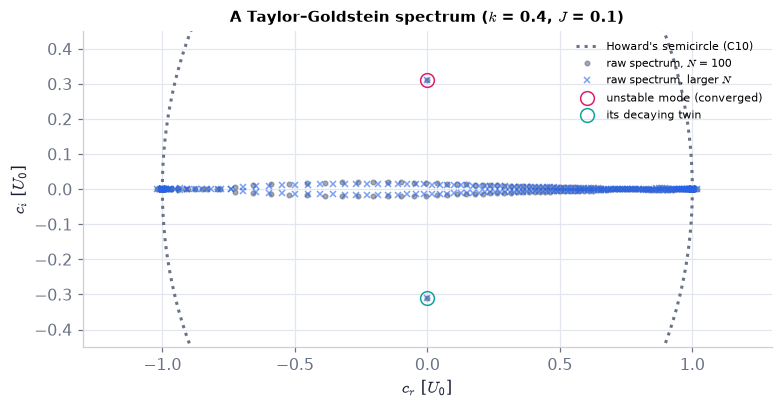

J = 0.3: converged unstable eigenvalues: []


In [86]:
raw2 = ch11.taylor_goldstein_eigs(0.4, prof["U"], prof["Upp"], prof["N2"], bc="decay", N=120 if FAST else 140, unstable_only=False, filter=False)   # the same raw spectrum with more points, to see what moves
arc_r, arc_i = ST.howard_semicircle(-1.0, 1.0)                     # Howard's semicircle for U between -1 and 1 (C10)
fig, ax = plt.subplots(figsize=(7.0, 3.6))   # the figure and its panels
ax.plot(arc_r, arc_i, ":", color=C_BASE, label="Howard's semicircle (C10)")   # the arc that must contain every unstable eigenvalue
ax.plot(arc_r, -arc_i, ":", color=C_BASE)   # its mirror image, for the decaying twins
ax.plot(raw.real, raw.imag, "o", ms=3, color=C_BASE, alpha=0.6, label="raw spectrum, $N$ = 100")   # every eigenvalue the matrices give at N = 100
ax.plot(raw2.real, raw2.imag, "x", ms=4, color=C_BUOY, alpha=0.6, label="raw spectrum, larger $N$")   # ... and at the larger N: what coincides is physics
ax.plot(c_tg[0].real, c_tg[0].imag, "o", ms=9, mfc="none", color=C_GROW, label="unstable mode (converged)")   # circle the growing mode
ax.plot(c_tg[0].real, -c_tg[0].imag, "o", ms=9, mfc="none", color=C_DECAY, label="its decaying twin")   # circle its complex conjugate (N73)
ax.set(xlabel="$c_r$ [$U_0$]", ylabel="$c_i$ [$U_0$]", xlim=(-1.3, 1.3), ylim=(-0.45, 0.45))   # axis labels (with units) and fixed ranges for this panel
ax.set_title("A Taylor–Goldstein spectrum ($k$ = 0.4, $J$ = 0.1)", fontsize=10)   # panel title — the message of this panel
ax.legend(fontsize=7, loc="upper right")   # legend: one entry per curve
plt.show()   # display the figure
p03 = ch11.richardson_profiles("tanh", J=0.3)                      # more stratification
print("J = 0.3: converged unstable eigenvalues:", ch11.taylor_goldstein_eigs(0.4, p03["U"], p03["Upp"], p03["N2"], bc="decay", N=100))   # stronger stratification: no growing mode is left

**What does the code above do?**

1. The raw spectra at two resolutions are overlaid; `ST.howard_semicircle(Umin, Umax)` returns the arc of C10 as a ghost.
2. Only what coincides at both resolutions is physics.

**What you see.** The complex $c$-plane. Two mirror dots off the real axis (circled rose and teal), a dense line of dots on the real axis between −1 and 1, and a cloud of dots just above and below that line. Grey circles and blue crosses are the same calculation at two resolutions. The dotted arcs at the left and right edges are parts of Howard's semicircle (C10), which must contain every unstable eigenvalue.

**How to read it.** The circled pair is the growing mode and its decaying twin: both resolutions give the same point. The line on the axis is the *continuous spectrum* — neutral disturbances that each travel with the fluid at one height, where $U(z)=c$ (P269); they are not instabilities. The cloud just off the axis moves when $N$ changes: numerical junk from that singular line, which the solver's convergence filter removes.

**What would change if…** …$J=0.3$: no converged unstable eigenvalue is left (the last line prints an empty array) — C09 proves that it must be so.

**What would change if…** …we wanted a *guarantee* of stability without computing any spectrum? Multiply the equation by the conjugate, integrate, and look
at the imaginary part — C09 turns the Taylor–Goldstein equation into the Richardson-number theorem.

> 🔁 **Recap — The gradient Richardson number** (Ch. 4 §4.11, Ch. 1 §1.10). $\mathrm{Ri}(z)\equiv N^2/(dU/dz)^2$ (11.66): stratification's restoring strength over the shear's — Ch. 4's gradient Richardson
number and Ch. 1's $N^2$ together. Large Ri: buoyancy wins; small Ri: shear wins.

### 🧩 The Miles–Howard criterion (11.67): $\mathrm{Ri}=\frac{N^2}{(dU/dz)^2}>\tfrac14$ everywhere ⇒ stable `C09`

*The question:* How much stratification guarantees that a shear layer cannot break into billows?

#### The problem in plain words

Every ocean and climate model has to decide, grid box by grid box, whether the shear is strong enough to mix the water or air. The
rule they use is a number: if the gradient Richardson number is above about ¼, no mixing from shear instability. Where does ¼ come
from — and is it a guarantee, a trigger, or both?

#### The idea

```
TG equation  ──substitute φ = ψ̂/(U − c)^{1/2}──►  self-adjoint form (11.64)
             ──× φ*, integrate, by parts──────►  (11.65): ∫ (N² − ¼U′²)/(U − c) |φ|² = ∫(U − c)(|φ′|² + k²|φ|²) + ∫ ½U″|φ|²
             ──imaginary part──────────────────►  c_i · ∫ (N² − ¼U′²)/|U − c|² |φ|²  =  − c_i · ∫ (|φ′|² + k²|φ|²)
if N² > ¼U′² everywhere: c_i × (positive) = c_i × (negative)  ⇒  c_i = 0   ⇒  Ri > ¼ everywhere guarantees stability
```

*Self-adjoint* means an equation of the shape $(p\phi')'-q\phi=0$: multiplied by $\phi^*$ and integrated, its derivative term turns by parts into $-\int p\lvert\phi'\rvert^2dz$ with no boundary term when $\phi$ vanishes at both ends — the only property D18 uses. The two numbered stations of the sketch, both derived in D18 below: the self-adjoint form $\frac d{dz}\Big[(U-c)\frac{d\phi}{dz}\Big]-\Big\{k^2(U-c)+\frac12\frac{d^2U}{dz^2}+\frac{\tfrac14(dU/dz)^2-N^2}{U-c}\Big\}\phi=0$ *(11.64)* and the integral identity $\int\frac{N^2-\tfrac14(dU/dz)^2}{U-c}\lvert\phi\rvert^2dz=\int(U-c)\Big\{\Big\lvert\frac{d\phi}{dz}\Big\rvert^2+k^2\lvert\phi\rvert^2\Big\}dz+\frac12\int\frac{d^2U}{dz^2}\lvert\phi\rvert^2dz$ *(11.65)*.

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **complex powers (U − c)^(1/2) and branches** — a complex number has two square roots; any fixed choice works as long as the number never passes through zero. *(Ch. 6, P155)*
- **product rule** — $(fg)'=f'g+fg'$. *(Ch. 1, P38)*
- **chain rule** — $\frac{d}{dz}f(g(z))=f'(g)\,g'(z)$. *(Ch. 1, P49)*
- **Simpson and trapezoid (contrast)** — `np.trapezoid(y, x)` integrates sampled data with straight pieces — fine on a dense uniform grid, poor on a few clustered points. *(Ch. 9, P203)*

> 📎 **Primer — integrating on a Chebyshev grid (Clenshaw–Curtis weights).** `P271` · On Chebyshev points, the integral of the polynomial through the samples is a weighted sum $\int f\,dx\approx\sum_jw_jf(x_j)$; the
weights are exact for polynomials up to degree $N$, so smooth integrands converge as fast as the collocation itself. We use them
to check the integral identities of this section and the energy budget of C14 on computed modes (Simpson's rule, Ch. 9 P203, would
be far less accurate on these clustered points).

In [87]:
import numpy as np                                    # arrays
from fluidpy.core import stability as ST              # the eigen-solver toolkit
D, x = ST.cheb(8)                                     # 9 Chebyshev points on [-1, 1]
w = ST.clenshaw_curtis_weights(8)                     # their integration weights
print(w @ x**2, w @ np.cos(x))                        # 0.666667 (= 2/3) and 1.682942 (= 2 sin 1): both exact to round-off

0.6666666666666667 1.68294196963511


> ⚠️ **Common confusion:** **$\phi$ is not a potential here.** In D18 the symbol $\phi\equiv\hat\psi/(U-c)^{1/2}$ (11.63) is just a rescaled stream-function
amplitude — a different object from C02's velocity potentials $\phi_1,\phi_2$ and from the $\phi(y)$ of C11–C13.

#### 🧮 Derivation — The Miles–Howard criterion: Ri > ¼ everywhere ⇒ stable `D18` ★★★ (Eq. 11.67: $\mathrm{Ri}>\tfrac14\ \text{everywhere}\ \Rightarrow\ \text{stable}$)

**What we want to show.** Prove that a stratified shear flow with gradient Richardson number above ¼ everywhere has no growing wave.

**Assumptions.** c_i ≠ 0, so U − c never vanishes (steps 2, 12); U, N² smooth; rigid lids (step 10).

**The plan.**

1. Assume a growing mode (c_i ≠ 0) and substitute φ = ψ̂/(U − c)^(1/2).
2. Rearrange into a self-adjoint form.
3. Multiply by φ*, integrate, integrate by parts.
4. Take the imaginary part and reach a contradiction when Ri > ¼.

**Tools we use** (each explained before this point): Complex powers (P155) · product and chain rules (P38, P49) · integration by parts (P218a) · real and imaginary parts (P260) · proof by contradiction (P255) · sympy (P40)

**We start from**

$$ \begin{array}{l}(U-c)\Big(\frac{d^2}{dz^2}-k^2\Big)\hat\psi-\frac{d^2U}{dz^2}\hat\psi+\frac{N^2}{U-c}\hat\psi=0\qquad\text{(11.61)} \\[4pt] \hat\psi(0)=\hat\psi(d)=0\qquad\text{(11.62)}\end{array} $$

*In words:* the Taylor–Goldstein problem.

---

**Step 1 of 14 — Suppose a growing mode exists.**

$$ c_i\neq0\ \Rightarrow\ U(z)-c\neq0\ \text{for all}\ z $$

- *Why we can do this:* proof by contradiction (P255): assume instability and look for something impossible; U is real, so U − c has imaginary part −c_i ≠ 0.
- *In words:* we may divide by U − c and take its square root.

---

**Step 2 of 14 — Substitute the new unknown.**

$$ \phi\equiv\frac{\hat\psi}{(U-c)^{1/2}},\ \ \hat\psi=(U-c)^{1/2}\phi\ \text{(11.63)} $$

- *Why we can do this:* a clever change of variable (Howard) that will make the equation self-adjoint; any fixed branch of the root works since U − c ≠ 0 (P155).
- *In words:* φ is not a potential — just a scaled ψ̂.

---

**Step 3 of 14 — Differentiate once.**

$$ \hat\psi'=(U-c)^{1/2}\phi'+\frac{\phi\,U'}{2(U-c)^{1/2}} $$

- *Why we can do this:* product rule and chain rule: $\frac d{dz}(U-c)^{1/2}=\frac{U'}{2(U-c)^{1/2}}$ (P38, P49).
- *In words:* the first derivative of ψ̂.

---

**Step 4 of 14 — Differentiate twice.**

$$ \hat\psi''=(U-c)^{1/2}\phi''+\frac{\phi'U'+\tfrac12\phi U''}{(U-c)^{1/2}}-\frac{\phi U'^2}{4(U-c)^{3/2}} $$

- *Why we can do this:* differentiate step 3 term by term; the last term comes from $\frac d{dz}(U-c)^{-1/2}=-\frac{U'}{2(U-c)^{3/2}}$.
- *In words:* the book's two derivative formulas (p. 504).

---

**Step 5 of 14 — Multiply (11.61) through.**

$$ (U-c)\hat\psi''=(U-c)^{3/2}\phi''+(U-c)^{1/2}\big(\phi'U'+\tfrac12\phi U''\big)-\frac{\phi U'^2}{4(U-c)^{1/2}} $$

- *Why we can do this:* (11.61), $(U-c)\Big(\frac{d^2}{dz^2}-k^2\Big)\hat\psi-\frac{d^2U}{dz^2}\hat\psi+\frac{N^2}{U-c}\hat\psi=0$ needs (U − c)ψ̂″; multiply step 4 by U − c.
- *In words:* the first term of (11.61), $(U-c)\Big(\frac{d^2}{dz^2}-k^2\Big)\hat\psi-\frac{d^2U}{dz^2}\hat\psi+\frac{N^2}{U-c}\hat\psi=0$ in the new unknown.

---

**Step 6 of 14 — Insert every term into (11.61).**

$$ (U-c)^{3/2}\phi''+(U-c)^{1/2}\phi'U'+\big(\tfrac12-1\big)(U-c)^{1/2}U''\phi-k^2(U-c)^{3/2}\phi-\frac{\big(\tfrac14U'^2-N^2\big)\phi}{(U-c)^{1/2}}=0 $$

- *Why we can do this:* $-U''\hat\psi=-U''(U-c)^{1/2}\phi$ and $\frac{N^2\hat\psi}{U-c}=\frac{N^2\phi}{(U-c)^{1/2}}$; collect the two U″ terms.
- *In words:* the book's "after some rearrangement", written out.

---

**Step 7 of 14 — Divide by (U − c)^(1/2).**

$$ (U-c)\phi''+U'\phi'-\Big\{k^2(U-c)+\tfrac12U''+\frac{\tfrac14U'^2-N^2}{U-c}\Big\}\phi=0 $$

- *Why we can do this:* nonzero by step 1; ½ − 1 = −½ gives the U″ coefficient.
- *In words:* every term is now simple.

---

**Step 8 of 14 — Recognise a derivative.**

$$ \frac d{dz}\Big[(U-c)\frac{d\phi}{dz}\Big]-\Big\{k^2(U-c)+\frac12\frac{d^2U}{dz^2}+\frac{\tfrac14(dU/dz)^2-N^2}{U-c}\Big\}\phi=0\ \text{(11.64)} $$

- *Why we can do this:* product rule backwards: $[(U-c)\phi']'=(U-c)\phi''+U'\phi'$. A total derivative is what integration by parts needs in the next step.
- *In words:* the self-adjoint form.

---

**Step 9 of 14 — Multiply by φ* and integrate.**

$$ \int_0^d\big[(U-c)\phi'\big]'\phi^*dz-\int_0^d\Big\{k^2(U-c)+\tfrac12U''+\frac{\tfrac14U'^2-N^2}{U-c}\Big\}\lvert\phi\rvert^2dz=0 $$

- *Why we can do this:* φ*φ = ∣φ∣² (P81); integrating turns the ODE into one number equation we can read.
- *In words:* an 'energy' identity.

---

**Step 10 of 14 — Integrate the first term by parts.**

$$ \int_0^d\big[(U-c)\phi'\big]'\phi^*dz=-\int_0^d(U-c)\lvert\phi'\rvert^2dz $$

- *Why we can do this:* P218a; the boundary term $[(U-c)\phi'\phi^*]_0^d$ vanishes because ψ̂ = 0 at the lids (11.62), $\hat\psi(0)=\hat\psi(d)=0$ makes φ = 0 there.
- *In words:* a curvature becomes a gradient squared.

---

**Step 11 of 14 — Rearrange.**

$$ \int_0^d\frac{N^2-\tfrac14U'^2}{U-c}\lvert\phi\rvert^2dz=\int_0^d(U-c)\big\{\lvert\phi'\rvert^2+k^2\lvert\phi\rvert^2\big\}dz+\int_0^d\tfrac12U''\lvert\phi\rvert^2dz\ \text{(11.65)} $$

- *Why we can do this:* steps 9–10; move the N² term to the left (sign flip) and the rest to the right.
- *In words:* the book's integral identity.

---

**Step 12 of 14 — Take the imaginary part.**

$$ c_i\int_0^d\frac{N^2-\tfrac14U'^2}{\lvert U-c\rvert^2}\lvert\phi\rvert^2dz=-c_i\int_0^d\big\{\lvert\phi'\rvert^2+k^2\lvert\phi\rvert^2\big\}dz $$

- *Why we can do this:* $\mathrm{Im}\frac1{U-c}=\frac{c_i}{\lvert U-c\rvert^2}$ (P260), Im(U − c) = −c_i, the U″ integral is real. The text extraction drops this minus; the page has it.
- *In words:* c_i times one integral equals −c_i times a positive one.

---

**Step 13 of 14 — Divide by c_i.**

$$ \int_0^d\frac{N^2-\tfrac14U'^2}{\lvert U-c\rvert^2}\lvert\phi\rvert^2dz=-\int_0^d\big\{\lvert\phi'\rvert^2+k^2\lvert\phi\rvert^2\big\}dz<0 $$

- *Why we can do this:* c_i ≠ 0 by step 1; the right side is minus a positive integral (φ ≢ 0).
- *In words:* the left integral must be negative.

---

**Step 14 of 14 — Reach the contradiction.**

$$ N^2>\tfrac14\Big(\frac{dU}{dz}\Big)^2\ \text{everywhere}\ \Leftrightarrow\ \mathrm{Ri}\equiv\frac{N^2}{(dU/dz)^2}>\frac14\ \text{(11.66), (11.67)} $$

- *Why we can do this:* then the left integrand is positive and the left side positive, contradicting step 13; so the assumption c_i ≠ 0 was false (P255).
- *In words:* Ri > ¼ everywhere ⇒ no growing mode.

---

**Result**

$$ \text{If}\ \mathrm{Ri}(z)=N^2/(dU/dz)^2>\tfrac14\ \text{everywhere, the flow is linearly stable (11.67)} $$

*In words:* enough stratification everywhere guarantees stability; Ri < ¼ somewhere is necessary (not sufficient) for instability.

**What it means.** Ri = ¼ is a *guarantee*, not a trigger — it is why mixing parameterisations switch shear mixing off above about ¼. Fails for non-Boussinesq or viscous/diffusive flows, and says nothing about finite-amplitude instabilities.

**Check it.** Units: N² and U′² both 1/s² ✓. Limit N² = 0: the left side is negative definite — no conclusion, consistent with inflectional instability (C12). tanh layer with J = 0.3 (Ri_min = 0.3): no growth computed ✓; identity (11.65), $\int\frac{N^2-\tfrac14(dU/dz)^2}{U-c}\lvert\phi\rvert^2dz=\int(U-c)\Big\{\Big\lvert\frac{d\phi}{dz}\Big\rvert^2+k^2\lvert\phi\rvert^2\Big\}dz+\frac12\int\frac{d^2U}{dz^2}\lvert\phi\rvert^2dz$ holds to 1e-8 for a computed mode ✓.

In [88]:
import sympy as sp                                            # symbolic algebra
z, k, c = sp.symbols("z k c")                                 # height, wavenumber, complex wave speed
U, N2, phi = sp.Function("U")(z), sp.Function("N2")(z), sp.Function("phi")(z)   # generic profiles and the new unknown
s = sp.sqrt(U - c)                                            # (U - c)^(1/2) of (11.63)
psi = s*phi                                                   # step 2: psi-hat in terms of phi
TG = (U - c)*(sp.diff(psi, z, 2) - k**2*psi) - sp.diff(U, z, 2)*psi + N2*psi/(U - c)     # (11.61)
SA = sp.diff((U - c)*sp.diff(phi, z), z) - (k**2*(U - c) + sp.diff(U, z, 2)/2   # the self-adjoint form (11.64): its derivative term ...
      + (sp.diff(U, z)**2/4 - N2)/(U - c))*phi                # (11.64)
print(sp.simplify(TG/s - SA))                                 # steps 3-8: (11.61) divided by (U-c)^(1/2) is (11.64) -> 0
cr, ci, Ur = sp.symbols("c_r c_i U_r", real=True)             # real parts for step 12
print(sp.simplify(sp.im(1/(Ur - cr - sp.I*ci)) - ci/((Ur - cr)**2 + ci**2)))   # Im{1/(U-c)} = c_i/|U-c|^2 -> 0

0
0


📝 **Notes taught inside `D18`:** **N75 [B]** Howard's change of variable and its two derivatives (steps 2–4) · **N76 [B]** the self-adjoint form — the book's 'after some rearrangement' written out (steps 5–8) · **N77 [B]** the integral identity and its imaginary part (steps 9–12).

> ⚠️ **Common confusion (traps in `D18`):** Dropping the ½U″ or the −¼U′²/(U − c) term in step 6; forgetting that φ = 0 at the lids follows from (11.62), $\hat\psi(0)=\hat\psi(d)=0$; the minus sign in step 12; claiming Ri < ¼ implies instability.

#### ✏️ Tiny example: Ri for a thermocline and for the tanh layer

**Thermocline:** a current changing by $\Delta U=0.1$ m/s over $h=2$ m, so $dU/dz\approx0.05$ s⁻¹, with $N^2=2\times10^{-4}$ s⁻².
$\mathrm{Ri}=2\times10^{-4}/0.05^2=2\times10^{-4}/0.0025=0.08<\tfrac14$: instability is *allowed* (not guaranteed).

**tanh layer:** $U=\tanh z$, $N^2=J\,\mathrm{sech}^2z$. $U'=\mathrm{sech}^2z$, so
$\mathrm{Ri}(z)=J\,\mathrm{sech}^2z/\mathrm{sech}^4z=J\cosh^2z$: smallest at the centre, $\mathrm{Ri}_{\min}=J$. $J=0.1$:
$\mathrm{Ri}_{\min}=0.1<\tfrac14$ (the computed growth is positive, C08); $J=0.3$: $\mathrm{Ri}>\tfrac14$ everywhere ⇒ stable by the
theorem, whatever $k$.

In [89]:
z = np.linspace(-4, 4, 801)                                         # heights across the layer [L]
for J in (0.1, 0.24, 0.3):                                          # three strengths of stratification
    p = ch11.richardson_profiles("tanh", J=J)                       # U = tanh z, N^2 = J sech^2 z
    mh = ch11.miles_howard_stable(z, U=p["U"], N2=p["N2"])          # (11.66)-(11.67) on this profile
    print(f"J = {J}: Ri_min = {mh['Ri_min']:.3f} at z = {mh['z_min']:.1f} -> guaranteed stable: {mh['guaranteed_stable']}")   # the smallest Richardson number of the profile and the theorem's verdict
print("growth rate k c_i at k = 0.4 for J = 0, 0.1, 0.3:", [round(ch11.tg_growth(0.4, J), 4) for J in (0.0, 0.1, 0.3)])   # computed growth: positive below 1/4, zero above
p = ch11.richardson_profiles("tanh", J=0.1)                         # back to J = 0.1 for the identity check
md = ch11.taylor_goldstein_eigs(0.4, p["U"], p["Upp"], p["N2"], bc="decay", N=100, map_scale=0.5, return_vectors=True)   # mode + its grid
idn = ch11.richardson_identity_check(0.4, md["c"][0], md["psi"][:, 0], md["y"], p["U"], p["Up"], p["Upp"], p["N2"], grid=md["grid"])   # both sides of D18's integral identity for this computed mode
print(f"(11.65): left {idn['lhs']:.6f}, right {idn['rhs']:.6f}, relative residual {idn['residual']:.1e}")   # the identity holds to round-off
print(f"imaginary parts: left {idn['imag_lhs']:.6e}, right {idn['imag_rhs']:.6e}")   # ... and so does its imaginary part, the one that gives the theorem

J = 0.1: Ri_min = 0.100 at z = 0.0 -> guaranteed stable: False
J = 0.24: Ri_min = 0.240 at z = 0.0 -> guaranteed stable: False
J = 0.3: Ri_min = 0.300 at z = 0.0 -> guaranteed stable: True


growth rate k c_i at k = 0.4 for J = 0, 0.1, 0.3: [0.1882, 0.1245, 0.0]


(11.65): left -0.000000-0.008306j, right -0.000000-0.008306j, relative residual 1.7e-11
imaginary parts: left -8.305805e-03, right -8.305805e-03


**What does the code above do?**

1. `ch11.miles_howard_stable(z, U, N2)` evaluates $\mathrm{Ri}(z)$ on the profile, finds its minimum and applies the theorem.
   $J=0.1$ and $0.24$: not guaranteed; $J=0.3$: guaranteed stable.
2. `ch11.tg_growth(k, J)` returns the leading growth rate $kc_i$ (0 if no converged unstable mode): about 0.188, 0.124 and 0 —
   the computation agrees with the theorem.
3. `return_vectors=True` returns the mode $\hat\psi$ on its mapped grid; `ch11.richardson_identity_check` evaluates both sides of
   D18's integral identity with Clenshaw–Curtis weights (P271): they agree to about 10⁻¹¹, imaginary parts included.

In [90]:
J = 0.1                                                             # the stratification strength
Ri_mine = (J/np.cosh(z)**2)/(1/np.cosh(z)**2)**2                    # (11.66) typed out: N^2/(U')^2 with N^2 = J sech^2 z, U' = sech^2 z
i = int(np.argmin(Ri_mine))                                         # where it is smallest
mh = ch11.miles_howard_stable(z, U=p["U"], N2=p["N2"])              # the library on the same profile
assert np.isclose(Ri_mine[i], mh["Ri_min"]) and np.isclose(z[i], 0.0)   # same minimum, at the centre of the layer
Ri_thermo = 2e-4/0.05**2                                            # the thermocline of the worked example
print(f"tanh layer: Ri_min = {Ri_mine[i]:.3f} at z = {z[i]:.1f};  thermocline: Ri = {Ri_thermo:.2f}")   # the minimum sits at the centre of the layer; the thermocline example is below 1/4

tanh layer: Ri_min = 0.100 at z = 0.0;  thermocline: Ri = 0.08


**What does the code above do?**

1. The Richardson number of the tanh layer typed out, $J\cosh^2z$; its minimum equals the library's.
2. The thermocline of the worked example: 0.08.

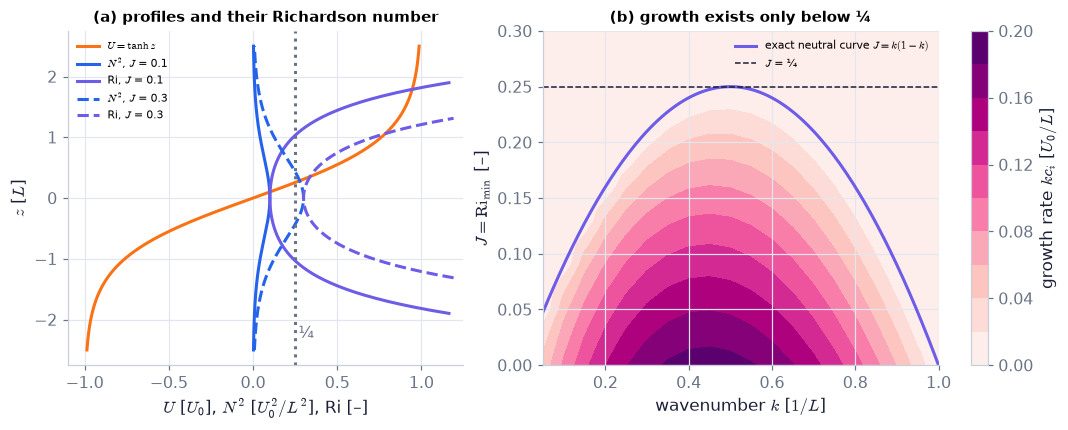

largest growth in the map: 0.1897 at J = 0;  map point (k = 0.4, J = 0.1) = 0.1245, recomputed 0.12448


In [91]:
gm = ch11.tg_growth_map()                                          # k c_i on a (k, J) grid, read from reference/ch11/tg_growth_map.csv (ours)
zz = np.linspace(-2.5, 2.5, 300)                                   # heights [L]
fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 3.8))   # the figure and its panels
a.plot(np.tanh(zz), zz, color=C_SHEAR, label="$U=\\tanh z$")   # the velocity profile of the shear layer
for J, ls in ((0.1, "-"), (0.3, "--")):   # repeat the indented lines for each item listed
    pj = ch11.richardson_profiles("tanh", J=J)                     # the profile for this J
    a.plot(pj["N2"](zz), zz, ls, color=C_BUOY, label=f"$N^2$, $J$ = {J}")   # the stratification, concentrated where the shear is
    Ri = pj["Ri"](zz)                                              # the Richardson number J cosh^2 z
    a.plot(np.where(Ri <= 1.2, Ri, np.nan), zz, ls, color=C_NEUT, label=f"Ri, $J$ = {J}")   # only the part inside the panel
a.axvline(0.25, color=C_BASE, ls=":")   # a reference line or band
a.text(0.27, -2.3, "¼", color=C_BASE)   # a label written on the plot
a.set(xlabel="$U$ [$U_0$], $N^2$ [$U_0^2/L^2$], Ri [–]", ylabel="$z$ [$L$]", xlim=(-1.1, 1.25))   # axis labels (with units) and fixed ranges for this panel
a.set_title("(a) profiles and their Richardson number", fontsize=10)   # panel title — the message of this panel
a.legend(fontsize=7, loc="upper left")   # legend: one entry per curve
cf = b.contourf(gm["k"], gm["J"], gm["kci"], levels=np.linspace(0.0, 0.2, 11), cmap="RdPu")   # filled colour contours of the field
fig.colorbar(cf, ax=b, label="growth rate $kc_i$ [$U_0/L$]")   # the colour scale and what it measures
kk = np.linspace(0.0, 1.0, 200)                                    # wavenumbers for the exact neutral curve
b.plot(kk, ch11.tg_tanh_neutral_J(kk), color=C_NEUT, label="exact neutral curve $J=k(1-k)$")   # exact neutral curve of this family: growth only below it
b.axhline(0.25, color=COLORS["ink"], ls="--", lw=1, label="$J$ = ¼")   # a reference line or band
b.set(xlabel="wavenumber $k$ [$1/L$]", ylabel="$J=\\mathrm{Ri}_{\\min}$ [–]", xlim=(0.05, 1.0), ylim=(0, 0.3))   # axis labels (with units) and fixed ranges for this panel
b.set_title("(b) growth exists only below ¼", fontsize=10)   # panel title — the message of this panel
b.legend(fontsize=7, loc="upper right")   # legend: one entry per curve
savefig(fig, "ch11", "c09_richardson")   # keep a copy in outputs/ch11 and display
plt.show()   # display the figure
live_pt = ch11.tg_growth(0.4, 0.1)                                 # one point of the map recomputed now
assert np.isclose(live_pt, gm["kci"][10, 7], rtol=6e-4)            # the stored table has 4 significant figures
print(f"largest growth in the map: {gm['kci'].max():.4f} at J = 0;  map point (k = 0.4, J = 0.1) = {gm['kci'][10, 7]}, recomputed {live_pt:.5f}")   # fastest growth is without stratification; one stored point recomputed

**What does the code above do?**

1. `ch11.tg_growth_map()` reads our stored table (20 wavenumbers × 31 values of $J$; recomputing it takes about two minutes);
   the last lines recompute one point live and compare.
2. `ch11.tg_tanh_neutral_J(k)` is the exact neutral curve of this family, $J=k(1-k)$.
3. `contourf` fills the growth rate; the largest value, 0.19 at $J=0$ near $k=0.45$, is the unstratified shear layer of C12.

**What you see.** (a) The shear layer $U=\tanh z$ (orange), the stratification $N^2$ (blue) and the Richardson number (purple) for a weak (solid) and a stronger (dashed) stratification; the dotted line is ¼. (b) The growth rate $kc_i$ of the leading mode over the plane of wavenumber and stratification: a tongue that closes on the purple curve, whose top just touches the dashed line $J=\tfrac14$ at $k=\tfrac12$.

**How to read it.** For $J=0.1$ the purple curve in (a) dips below ¼ in the middle of the layer — growth is allowed, and (b) shows it happens. For $J=0.3$ the curve stays right of ¼ everywhere — nothing can grow, the guarantee. For this family the neutral curve is known exactly, $J=k(1-k)$. One caution about the map: a zero within about 0.006 (in $J$) of that curve means '$kc_i<0.004$, too weak for the solver's convergence test', not 'stable'.

**What would change if…** …the density layer were thinner than the shear layer: the minimum of Ri would sit off-centre and the tongue would change shape (the explainer's profile options).

📝 **Note.** **N78 [B]** **Necessary, not sufficient.** $\mathrm{Ri}<\tfrac14$ somewhere is needed for instability but does not force it; there is no
universal critical Ri (walls and profile shapes lower it). For common shear layers (linear, tanh, erf) instability does start when
the minimum drops below ¼, and as it goes to zero the fastest wave has $kL\approx0.445$ for $U=U_0\tanh(z/L)$, i.e. a wavelength
of about $14L$ (Michalke 1964; our solver gives 0.4449 with growth rate 0.1897). Laboratory (Scotti & Corcos 1972) and ocean
(Eriksen 1978) data support "minimum Ri below ¼" as a useful guide.

**Slider figure F5 — the growth curve shrinks as the stratification rises.** One row of the stored map per slider position.

In [92]:
def f5(J):                                                         # traces for one stratification strength
    row = gm["kci"][int(np.argmin(np.abs(gm["J"] - J)))]           # the stored growth rates at this J
    disc = 1 - 4*J                                                 # J = k(1 - k) has real roots k only if J <= 1/4
    kn = 0.5 + 0.5*np.array([-1, 1])*np.sqrt(disc) if disc >= 0 else np.array([np.nan, np.nan])   # the two neutral wavenumbers
    return {"growth rate k c_i (this J)": (gm["k"], row), "no stratification (J = 0)": (gm["k"], gm["kci"][0]),   # this J, and J = 0 for reference
            "neutral wavenumbers, J = k(1 − k)": (kn, 0*kn)}                                             # two markers on the axis

figF5 = slider_figure(f5, "J = Ri_min", gm["J"][::2] if FAST else gm["J"][:27], xlabel="wavenumber k [1/L]", ylabel="growth rate k c_i [U0/L]",   # slider: J
                      title="Stratification closes the band of growing waves at J = 1/4", yrange=(-0.01, 0.2),   # title and a fixed vertical range
                      modes={"neutral wavenumbers, J = k(1 − k)": "markers"})   # the neutral points drawn as markers
figF5.show()   # display the interactive slider figure

**What does the code above do?**

1. `f5(J)` picks the map row for that $J$ and marks the two exact neutral wavenumbers.
2. Drag $J$ up: the hump sinks and narrows, the two markers move together and meet at $k=\tfrac12$ when $J=\tfrac14$ — beyond
   that nothing grows.

#### 🎮 Interactive: Why does Ri = ¼ decide whether a shear layer billows?

**Why interactive rather than a static figure:** Sliding the stratification shows the Richardson-number profile dip below the ¼ line at the same moment the growth tongue of the
(k, J) map is reached and the billow animation starts growing — the necessary-not-sufficient logic is visible.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Preset 'J = 0.24' vs 'J = 0.26': read the status before and after ¼.
- Drag k at J = 0.1: growth only in a band of wavenumbers — Ri < ¼ allows, the wavelength decides.
- Click the Ri(z) profile: the inspector computes N²/U′² at that height.

In [93]:
show_viz("ch11", "richardson_shear_instability")   # full-width explainer; ⤢ Full screen for more room

[explainer ch11/richardson_shear_instability]

**What would change if…** …we asked not *whether* a wave can grow but *how fast and how fast it travels*? A second substitution, $F=\hat\psi/(U-c)$, bounds
both at once — C10.

### 🧩 Howard's semicircle $\big[c_r-\tfrac12(U_{\max}+U_{\min})\big]^2+c_i^2\le\big[\tfrac12(U_{\max}-U_{\min})\big]^2$ and the growth bound $kc_i\le\tfrac k2(U_{\max}-U_{\min})$ `C10`

*The question:* Where in the complex plane can the wave speed of an unstable mode be?

#### The problem in plain words

Before computing a spectrum it helps to know where to look — and how fast anything could possibly grow. In a current whose speed
varies between 0.2 and 1 m/s, can an unstable wave travel at 3 m/s? Can it grow in a microsecond? Howard's answer: no — every
unstable wave speed lies in a half-disc spanned by the slowest and fastest fluid.

#### The idea

```
c_i ▲            ___
    │        .-'     '-.          every unstable c lies under this arc
    │      /             \        radius = ½(U_max − U_min),  centre = ½(U_max + U_min)
    │     |       ●       |       ⇒ U_min < c_r < U_max   and   k c_i ≤ (k/2)(U_max − U_min)
    └─────┴───────────────┴────► c_r
        U_min            U_max
```

(The semicircle itself carries no number in the book; it follows from the numbered inequality
$\int[U^2-c_r^2-c_i^2]Q\,dz>0$ (11.72), step 11 of D19.)

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **completing the square (tensors, recalled)** — $x^2-2ax=(x-a)^2-a^2$. *(Ch. 4, P129)*

> 📎 **Primer — completing the square into a circle (x − a)² + y² ≤ R².** `P272` · An inequality $x^2+y^2-2ax+b\le0$ is a disc: add and subtract $a^2$, $(x-a)^2+y^2\le a^2-b$ — centre $(a,0)$, radius
$\sqrt{a^2-b}$ (Ch. 4 completed squares for tensors, P129). Howard's last step is exactly this with $x=c_r$, $y=c_i$.

In [94]:
import numpy as np                                    # arrays
a, b = 1.0, 0.0                                       # x^2 + y^2 - 2x <= 0
print(np.sqrt(a**2 - b))                              # radius 1 around (1, 0): the half-disc on [0, 2] for y >= 0

1.0


#### 🧮 Derivation — Howard's semicircle and the growth bound $kc_i\le\frac k2(U_{\max}-U_{\min})$ `D19` ★★★ (Eq. 11.72: $\int\big[U^2-c_r^2-c_i^2\big]Q\,dz>0$)

**What we want to show.** Show that the wave speed of any unstable mode lies inside the half-disc spanned by the slowest and fastest fluid.

**Assumptions.** c_i ≠ 0 (steps 1, 9, 13); N² ≥ 0 (step 10 — the book uses it without saying); rigid lids.

**The plan.**

1. Substitute F = ψ̂/(U − c) and write a divergence form.
2. Multiply by F*, integrate: an identity with a positive weight Q.
3. Take real and imaginary parts.
4. Combine with the trivial inequality (U − U_min)(U − U_max) ≤ 0 and complete the square.

**Tools we use** (each explained before this point): Product rule (P38) · integration by parts (P218a) · real and imaginary parts (P260) · completing the square into a circle (P272)

**We start from**

$$ \begin{array}{l}(U-c)\Big(\frac{d^2}{dz^2}-k^2\Big)\hat\psi-\frac{d^2U}{dz^2}\hat\psi+\frac{N^2}{U-c}\hat\psi=0\qquad\text{(11.61)} \\[4pt] \hat\psi(0)=\hat\psi(d)=0\qquad\text{(11.62)} \\[4pt] \text{with a growing mode, }c_i\neq0,\ \text{and stable stratification, }N^2\ge0\end{array} $$

*In words:* the Taylor–Goldstein problem again.

---

**Step 1 of 14 — Substitute the new unknown.**

$$ F\equiv\frac{\hat\psi}{U-c},\ \ \hat\psi=(U-c)F\ \text{(11.68)} $$

- *Why we can do this:* allowed because U − c ≠ 0 (c_i ≠ 0); this choice will cancel the U″ term.
- *In words:* ψ̂ seen in the frame moving with the wave.

---

**Step 2 of 14 — Differentiate.**

$$ \hat\psi'=(U-c)F'+U'F,\ \ \hat\psi''=(U-c)F''+2U'F'+U''F $$

- *Why we can do this:* product rule twice (P38). We need these two derivatives to rewrite every term of the Taylor–Goldstein equation in the new unknown.
- *In words:* the book's derivative formulas.

---

**Step 3 of 14 — Insert into the Taylor–Goldstein equation.**

$$ (U-c)\big[(U-c)F''+2U'F'+U''F-k^2(U-c)F\big]-U''(U-c)F+N^2F=0 $$

- *Why we can do this:* The equation is the Taylor–Goldstein equation (11.61), $(U-c)\Big(\frac{d^2}{dz^2}-k^2\Big)\hat\psi-\frac{d^2U}{dz^2}\hat\psi+\frac{N^2}{U-c}\hat\psi=0$. Every ψ̂ replaced; the N²/(U − c) term becomes N²F.
- *In words:* (11.61), $(U-c)\Big(\frac{d^2}{dz^2}-k^2\Big)\hat\psi-\frac{d^2U}{dz^2}\hat\psi+\frac{N^2}{U-c}\hat\psi=0$ in F.

---

**Step 4 of 14 — Cancel the U″ terms.**

$$ (U-c)\big[(U-c)F''+2U'F'-k^2(U-c)F\big]+N^2F=0 $$

- *Why we can do this:* +U″(U − c)F and −U″(U − c)F cancel — the reason for the substitution.
- *In words:* the profile's curvature has gone.

---

**Step 5 of 14 — Write a divergence form.**

$$ \frac d{dz}\Big[(U-c)^2\frac{dF}{dz}\Big]-k^2(U-c)^2F+N^2F=0 $$

- *Why we can do this:* $[(U-c)^2F']'=(U-c)^2F''+2(U-c)U'F'$, exactly the first two terms. ⚠️ slip #11: the book prints −k²(U − c)F; expanding step 4 gives (U − c)².
- *In words:* a flux-like form ready for integration by parts.

---

**Step 6 of 14 — Multiply by F* and integrate by parts.**

$$ -\int(U-c)^2\lvert F'\rvert^2dz-k^2\int(U-c)^2\lvert F\rvert^2dz+\int N^2\lvert F\rvert^2dz=0 $$

- *Why we can do this:* P218a; the boundary term $[(U-c)^2F'F^*]$ vanishes because F = 0 at the lids (ψ̂ = 0).
- *In words:* one complex number equation.

---

**Step 7 of 14 — Name the weight.**

$$ \int(U-c)^2Q\,dz=\int N^2\lvert F\rvert^2dz,\ \ Q\equiv\lvert F'\rvert^2+k^2\lvert F\rvert^2\ge0 $$

- *Why we can do this:* collect step 6; Q is a sum of squares (P260).
- *In words:* a positive weight across the layer.

---

**Step 8 of 14 — Expand (U − c)².**

$$ (U-c)^2=(U-c_r)^2-c_i^2-2\mathrm ic_i(U-c_r) $$

- *Why we can do this:* c = c_r + ic_i, square the binomial.
- *In words:* real and imaginary parts of the factor.

---

**Step 9 of 14 — Take the imaginary part.**

$$ c_i\int(U-c_r)Q\,dz=0\ \Rightarrow\ \int UQ\,dz=c_r\int Q\,dz\ \text{(11.70)} $$

- *Why we can do this:* the right side of step 7 is real; c_i ≠ 0. Since Q ≥ 0 and U − c_r integrates to zero against it, U − c_r changes sign: $U_{\min}<c_r<U_{\max}$ (11.71).
- *In words:* an unstable wave travels at a speed found somewhere in the flow.

---

**Step 10 of 14 — Take the real part.**

$$ \int\big[(U-c_r)^2-c_i^2\big]Q\,dz=\int N^2\lvert F\rvert^2dz\ \ge0\ \text{(11.69)} $$

- *Why we can do this:* the real part of step 7 with step 8; the right side is ≥ 0 because N² ≥ 0 — the hidden assumption.
- *In words:* a second, real identity.

---

**Step 11 of 14 — Eliminate c_r's cross term.**

$$ \int\big[U^2-c_r^2-c_i^2\big]Q\,dz\ \ge0\ \text{(11.72)} $$

- *Why we can do this:* expand (U − c_r)² and replace $\int UQ$ by $c_r\int Q$ (step 9): $-2c_r\int UQ+c_r^2\int Q=-c_r^2\int Q$. (The book writes > 0.)
- *In words:* ∫U²Q is at least (c_r² + c_i²)∫Q.

---

**Step 12 of 14 — Use the velocity range, weighted.**

$$ \int(U-U_{\min})(U-U_{\max})\,Q\,dz\le0 $$

- *Why we can do this:* U − U_min ≥ 0 and U − U_max ≤ 0 everywhere, Q ≥ 0. ⚠️ slip #8: Q must be inside from the start and the inequality is ≤.
- *In words:* the flow cannot be faster than its fastest part.

---

**Step 13 of 14 — Combine with steps 9 and 11.**

$$ \big[c_r^2+c_i^2-c_r(U_{\max}+U_{\min})+U_{\max}U_{\min}\big]\int Q\,dz\le0 $$

- *Why we can do this:* expand step 12: $\int U^2Q\le(U_{\max}+U_{\min})\int UQ-U_{\max}U_{\min}\int Q$; replace ∫U²Q from below by step 11 and ∫UQ by step 9.
- *In words:* a condition on c alone.

---

**Step 14 of 14 — Complete the square.**

$$ \Big[c_r-\tfrac12(U_{\max}+U_{\min})\Big]^2+c_i^2\le\Big[\tfrac12(U_{\max}-U_{\min})\Big]^2 $$

- *Why we can do this:* ∫Q > 0, so the bracket is ≤ 0; add and subtract ¼(U_max + U_min)² (P272), using $\tfrac14(U_{\max}+U_{\min})^2-U_{\max}U_{\min}=\tfrac14(U_{\max}-U_{\min})^2$.
- *In words:* a half-disc on [U_min, U_max]; hence $kc_i\le\frac k2(U_{\max}-U_{\min})$.

---

**Result**

$$ \Big[c_r-\tfrac12(U_{\max}+U_{\min})\Big]^2+c_i^2\le\Big[\tfrac12(U_{\max}-U_{\min})\Big]^2\ \ \text{(p. 507)},\qquad kc_i\le\frac k2(U_{\max}-U_{\min}) $$

*In words:* every unstable wave speed sits under the arc whose diameter is the velocity range; growth is bounded by half the velocity jump times k.

**What it means.** A search window for every eigen-solver (C08–C13) and a hard growth bound; c_r inside the velocity range means a critical layer exists for neutral modes (N96). The same semicircle holds for the quasi-geostrophic problems of Ch. 13. Fails if N² < 0 somewhere (step 10).

**Check it.** Units ✓. tanh layer: c ≈ 0.426i at k = 0.445, inside the unit half-disc ✓; all computed unstable TG eigenvalues pass `ST.in_howard_semicircle` ✓; (11.69)–(11.70), $\int\big[(U-c_r)^2-c_i^2\big]Q\,dz=\int N^2\lvert F\rvert^2dz,\ c_i\int(U-c_r)Q\,dz=0$ hold to 1e-8 ✓.

In [95]:
import sympy as sp                                           # symbolic algebra
z, k, c = sp.symbols("z k c")                                # height, wavenumber, complex speed
U, N2, F = sp.Function("U")(z), sp.Function("N2")(z), sp.Function("F")(z)   # generic profiles and the unknown
psi = (U - c)*F                                              # step 1: (11.68)
TG = (U - c)*(sp.diff(psi, z, 2) - k**2*psi) - sp.diff(U, z, 2)*psi + N2*psi/(U - c)   # (11.61)
DIV = sp.diff((U - c)**2*sp.diff(F, z), z) - k**2*(U - c)**2*F + N2*F                   # step 5, corrected
DIV_printed = sp.diff((U - c)**2*sp.diff(F, z), z) - k**2*(U - c)*F + N2*F              # slip #11 as printed
print(sp.simplify(TG - DIV))                                 # -> 0: the corrected divergence form is (11.61)
print(sp.simplify(TG - DIV_printed) == 0)                    # False: the printed form is not
cr, ci, Umax, Umin = sp.symbols("c_r c_i U_max U_min", real=True)   # symbols for sympy
circle = (cr - (Umax + Umin)/2)**2 + ci**2 - ((Umax - Umin)/2)**2   # step 14's left minus right side
print(sp.expand(circle - (cr**2 + ci**2 - cr*(Umax + Umin) + Umax*Umin)))   # -> 0: completing the square

0


False
0


📝 **Notes taught inside `D19`:** **N79 [B]** the second change of variable and its derivatives (steps 1–2) · **N80 [B]** the divergence form, with slip #11 (step 5) · **N81 [B]** the real and imaginary parts of the integral identity (steps 9–10) · **N82 [B]** the wave speed lies inside the velocity range (step 9).

> ⚠️ **slip #11 — the book prints** the divergence form as $\frac d{dz}\big[(U-c)^2F'\big]-k^2(U-c)F+N^2F=0$ **; the correct form
> is** $\frac d{dz}\big[(U-c)^2F'\big]-k^2(U-c)^2F+N^2F=0$ — expanding the line above it gives $(U-c)^2$ (step 5), and the integral
> that follows (with $(U-c)^2\lvert F\rvert^2$) confirms it.

> ⚠️ **slip #8 — the book prints** the velocity-range inequality without a weight, $\int[U_{\min}-U][U_{\max}-U]\,dz\le0$, **; the
> correct form is** $\int(U-U_{\min})(U-U_{\max})\,Q\,dz\le0$ — the positive weight $Q=\lvert F'\rvert^2+k^2\lvert F\rvert^2$ must be
> inside the integral from the start, otherwise it cannot be combined with the two identities (step 12).

> ⚠️ **Common confusion (traps in `D19`):** Slip #11 (U − c instead of (U − c)²); slip #8 (the weight); forgetting the N² ≥ 0 assumption; using step 9 only once.

#### ✏️ Tiny example: a semicircle with easy numbers

$U$ between $U_{\min}=0$ and $U_{\max}=2$ m/s.

1. Centre $\tfrac12(0+2)=1$, radius $\tfrac12(2-0)=1$.
2. Is $c=1.2+0.5\,\mathrm i$ possible? $(1.2-1)^2+0.5^2=0.04+0.25=0.29\le1$ ✓.
3. $c=2.5+0.1\,\mathrm i$? $(1.5)^2+0.01=2.26>1$ ✗ — no unstable wave can outrun the fastest fluid.
4. Growth bound for $k=2$ m⁻¹: $kc_i\le(2/2)(2-0)=2$ s⁻¹, so the e-folding time is at least 0.5 s.
5. tanh layer ($U$ from −1 to 1): its fastest mode $c\approx0.426\,\mathrm i$ is well inside the unit half-disc.

In [96]:
modes = []                                                          # (k, J, c) of every unstable mode found
for J in (0.0, 0.1):                                                # no stratification, and J = 0.1
    pj = ch11.richardson_profiles("tanh", J=J)                      # the tanh layer
    for k in np.arange(0.1, 0.95, 0.2 if FAST else 0.1):            # a set of wavenumbers
        e = ch11.taylor_goldstein_eigs(k, pj["U"], pj["Upp"], pj["N2"], bc="decay", N=100, y_max=ST.decay_box(k), map_scale=ST.decay_map_scale(k))   # unstable eigenvalue(s) at this k, in a box and on nodes suited to its wavelength
        if len(e):                                                  # an unstable, converged eigenvalue exists
            modes.append((k, J, e[0]))   # store the value
cs = np.array([m[2] for m in modes])                                # the unstable wave speeds
print(len(cs), "unstable modes; all inside Howard's semicircle on [-1, 1]:", all(bool(ST.in_howard_semicircle(c, -1.0, 1.0)) for c in cs))   # every computed unstable wave speed obeys Howard's bound
hw = ch11.howard_identity_check(0.4, md["c"][0], md["psi"][:, 0], md["y"], p["U"], p["N2"], grid=md["grid"], Up=p["Up"])   # C09's mode
print({n: (f"{v:.1e}" if isinstance(v, float) else v) for n, v in hw.items()})   # residuals of D19's two integral identities for a computed mode

13 unstable modes; all inside Howard's semicircle on [-1, 1]: True
{'res_69': '3.4e-11', 'res_70': '2.4e-12', 'cr_mean': '-3.0e-11', 'int_11_72': '9.5e-03', 'in_semicircle': True}


**What does the code above do?**

1. For each $(k,J)$ the unstable Taylor–Goldstein eigenvalue (if any), computed with the box and node rule that long and
   near-neutral waves need (`ST.decay_box`, `ST.decay_map_scale`).
2. `ST.in_howard_semicircle(c, Umin, Umax)` tests the semicircle inequality; every computed mode passes.
3. `ch11.howard_identity_check` evaluates D19's two integral identities for the mode of C09: residuals `res_69`, `res_70` of
   order 10⁻¹¹; `cr_mean` $=\int UQ/\int Q$ equals $c_r$ (zero for this symmetric layer); `int_11_72` is positive.

In [97]:
inside = (cs.real - 0.0)**2 + cs.imag**2 <= 1.0 + 1e-9             # the semicircle typed out: centre 0, radius 1 for U from -1 to 1
assert np.all(inside) and np.all(inside == np.array([bool(ST.in_howard_semicircle(c, -1.0, 1.0)) for c in cs]))   # check: stops with an error if it fails
ks_m = np.array([m[0] for m in modes])                              # their wavenumbers
assert np.all(ks_m*cs.imag <= ks_m*(1.0 - (-1.0))/2)                # the growth bound k c_i <= (k/2)(U_max - U_min)
print("all", len(cs), "modes satisfy the inequality typed by hand; largest k c_i / bound =", round(np.max(cs.imag), 3))   # the inequality typed by hand agrees; the growth bound is safe but not tight

all 13 modes satisfy the inequality typed by hand; largest k c_i / bound = 0.836


**What does the code above do?**

1. The semicircle inequality written out for this layer and compared with the library function.
2. The growth bound: every $kc_i$ is below $k$; the ratio (printed) is at most about 0.84 — the bound is safe but not tight.

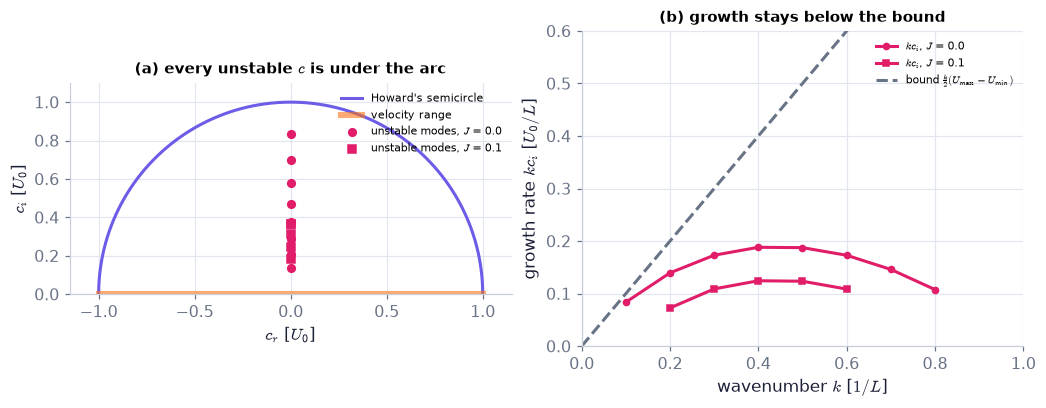

In [98]:
fig, (a, b) = plt.subplots(1, 2, figsize=(9.4, 3.6))   # the figure and its panels
a.plot(arc_r, arc_i, color=C_NEUT, label="Howard's semicircle")   # Howard's arc: no unstable wave speed can lie outside it
a.plot([-1, 1], [0, 0], color=C_SHEAR, lw=4, alpha=0.6, label="velocity range")   # the range of flow speeds, which is the arc's diameter
for J, mk in ((0.0, "o"), (0.1, "s")):   # repeat the indented lines for each item listed
    sel = np.array([m[1] == J for m in modes])                     # the modes with this J
    a.plot(cs[sel].real, cs[sel].imag, mk, color=C_GROW, ms=5, label=f"unstable modes, $J$ = {J}")   # computed unstable wave speeds: all on the imaginary axis, well inside
    b.plot(ks_m[sel], ks_m[sel]*cs[sel].imag, mk + "-", color=C_GROW, ms=4, label=f"$kc_i$, $J$ = {J}")   # their growth rates
a.set(xlabel="$c_r$ [$U_0$]", ylabel="$c_i$ [$U_0$]", xlim=(-1.15, 1.15), ylim=(0, 1.1))   # axis labels (with units) and fixed ranges for this panel
a.set_aspect("equal")   # equal scales in x and y, so shapes are not distorted
a.set_title("(a) every unstable $c$ is under the arc", fontsize=10)   # panel title — the message of this panel
a.legend(fontsize=7, loc="upper right")   # legend: one entry per curve
b.plot(kk, kk*(1.0 - (-1.0))/2, "--", color=C_BASE, label="bound $\\frac{k}{2}(U_{\\max}-U_{\\min})$")   # dashed: the largest growth rate Howard's theorem allows
b.set(xlabel="wavenumber $k$ [$1/L$]", ylabel="growth rate $kc_i$ [$U_0/L$]", xlim=(0, 1), ylim=(0, 0.6))   # axis labels (with units) and fixed ranges for this panel
b.set_title("(b) growth stays below the bound", fontsize=10)   # panel title — the message of this panel
b.legend(fontsize=7)   # legend: one entry per curve
plt.show()   # display the figure

**What you see.** (a) The half-disc on the velocity range [−1, 1] (purple arc, orange bar) with the computed unstable wave speeds as rose markers on the imaginary axis. (b) Their growth rates against k, far below the dashed bound.

**How to read it.** The symmetric layer's waves do not travel ($c_r=0$: no preferred direction, as in N19), and they sit well inside the arc. The arc is far from tight — a sanity window that tells a solver where to look and how fast anything can grow, not a prediction.

**What would change if…** …an asymmetric layer $U=1+\tanh z$: the arc and the markers shift right together by 1 (a change of frame).

**Slider figure F6 — a bounded shear flow: $U=\sin y$ between walls at $y=\pm b$.** For each half-width $b$: Rayleigh's equation
(C12) solved for four wavenumbers, with Howard's semicircle for that velocity range. The unstable eigenvalues appear only when
$2b>\pi$ (N95 in C12 explains why this profile matters).

In [99]:
def f6(b):                                                         # traces for one half-width b
    ps = ch11.inviscid_profile("sin", b=b)                         # U = sin y on |y| <= b, with walls
    Umax = 1.0 if b >= np.pi/2 else np.sin(b)                      # the fastest fluid (the slowest is -Umax)
    ar, ai = ST.howard_semicircle(-Umax, Umax, n=60)               # the semicircle for this velocity range
    cu = []                                                        # unstable eigenvalues found
    for k in (0.2, 0.4, 0.6, 0.8):   # repeat the indented lines for each item listed
        e = ch11.rayleigh_eigs(k, ps["U"], ps["Upp"], domain=ps["domain"], N=80, tol=1e-4, unstable_only=True)   # (11.81)-(11.82)
        cu += [e[0]] if len(e) else []   # keep the growing eigenvalue if there is one
    cu = np.array(cu) if cu else np.array([np.nan + 0j])           # nothing unstable: an empty marker
    return {"Howard's semicircle": (ar, ai), "unstable c (k = 0.2, 0.4, 0.6, 0.8)": (cu.real, cu.imag)}   # the values for this call

figF6 = slider_figure(f6, "b", np.round(np.linspace(1.5, 3.0, 6 if FAST else 11), 2), xlabel="c_r", ylabel="c_i",   # slider: the half-width of the channel
                      title="U = sin y between walls at ±b: unstable only when 2b > π", xrange=(-1.1, 1.1), yrange=(-0.02, 1.05),   # the message
                      modes={"unstable c (k = 0.2, 0.4, 0.6, 0.8)": "markers"})   # eigenvalues drawn as markers
figF6.show()   # display the interactive slider figure

**What does the code above do?**

1. `ch11.inviscid_profile("sin", b=b)` returns the profile functions and the domain; `ch11.rayleigh_eigs(..., unstable_only=True)`
   returns the converged unstable eigenvalues (none for $b=1.5$, where $2b<\pi$).
2. As $b$ grows past $\pi/2\approx1.57$, markers leave the real axis and climb — always under the arc.

**What would change if…** …viscosity came back? The equation gains a fourth derivative, the critical-layer singularity disappears, conjugate pairs break —
and, surprisingly, a profile with no inflection point can become unstable. That is the Orr–Sommerfeld story, C11–C14.

---

## 11.8 Squire's Theorem and the Orr-Sommerfeld Equation

**What is this section about?** Viscous parallel flows — water in a channel, air in a boundary layer. Two simplifications make
them tractable: Squire's theorem says two-dimensional disturbances go unstable first, and a stream function then turns the
linearised Navier–Stokes equations into one fourth-order equation, the Orr–Sommerfeld equation, whose eigenvalue $c(k,\mathrm{Re})$
decides stability.

> 🔁 **Recap — Dimensionless Navier–Stokes** (Ch. 4 §4.11). Lengths by $L$, velocities by $U_0$, time by $L/U_0$, pressure by $\rho U_0^2$, $\mathrm{Re}=U_0L/\nu$ (Ch. 4 §4.11): the
perturbed $x$-momentum equation is $\frac{\partial u}{\partial t}+(U+u)\frac{\partial}{\partial x}(U+u)+v\frac{\partial}{\partial y}(U+u)=
-\frac{\partial}{\partial x}(P+p)+\frac1{\mathrm{Re}}\nabla^2(U+u)$ (11.73) — the starting line of D20; $U(y)$ is the basic flow,
$(u,v,w)$ and $p$ the disturbance. ⚠️ This is the third of the chapter's four scalings (the table in the conventions cell).

> 🔁 **Recap — The stream function, §11.8 version** (Ch. 4 §4.3). Here $y$ is across the flow: $u=\partial\psi/\partial y$, $v=-\partial\psi/\partial x$ (Ch. 4 §4.3). With
$\psi=\phi(y)e^{\mathrm ik(x-ct)}$: $\hat u=\phi'$, $\hat v=-\mathrm ik\phi$ — and $\phi$ is now the stream-function amplitude,
**not** a potential (slip #9).

### 🧩 The Orr–Sommerfeld equation $(U-c)\big(\frac{d^2\phi}{dy^2}-k^2\phi\big)-\frac{d^2U}{dy^2}\phi=\frac1{\mathrm ik\mathrm{Re}}\big(\frac{d^4\phi}{dy^4}-2k^2\frac{d^2\phi}{dy^2}+k^4\phi\big)$ (11.79) `C11`

*The question:* What equation decides whether a viscous channel or boundary-layer flow is stable?

#### The problem in plain words

Reynolds showed in 1883 that water in a pipe stays smooth at low speed and turns turbulent at high speed. The wing of an airliner
keeps a laminar boundary layer only near its nose. To predict where smooth flow breaks down we need the viscous version of C08's
equation: small waves on $U(y)$, now with friction. Friction should only damp — but C13 will show that it can do the opposite.

#### The idea

```
3-D wave e^{i(kx + mz − kct)} at Re   ──Squire──►  2-D wave with k̄ = √(k² + m²) at the LOWER Re̅ = k Re / k̄
     ⇒ the first instability (lowest Re) is two-dimensional
2-D: u = ∂ψ/∂y, v = −∂ψ/∂x, ψ = φ(y)e^{ik(x−ct)}   ──eliminate p──►   one 4th-order ODE for φ:  Orr–Sommerfeld
     left side: Rayleigh's inviscid operator      right side: viscosity, ∝ 1/(ikRe)
```

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **six Reynolds numbers (which length?)** — a Reynolds number means nothing without its length and velocity scales — half-width or diameter, centreline or mean speed. *(Ch. 9, P200)*
- **reading reference data from a file** — published benchmark numbers are read from `reference/ch11/` with their sources, never typed into the text. *(Ch. 10, P251)*
- **verification versus validation** — verification = are we solving the equations right (benchmarks, convergence); validation = are they the right equations (experiments). *(Ch. 10, P253)*

📝 **Note.** **N83 [C]** **Viscosity can destabilise.** In Bénard and Taylor flows viscosity only raised thresholds; in channels and boundary layers it can
be the very cause of instability (C13), for a reason C14 explains.

#### 🧮 Derivation — The perturbation equations of a viscous parallel flow `D20` ★ (Eq. 11.77: $\mathrm ik(U-c)\hat u+\hat vU'=-\mathrm ik\hat p+\frac{\hat u''-(k^2+m^2)\hat u}{\mathrm{Re}},\ \dots$)

**What we want to show.** Write the linear equations for small 3-D disturbances on a parallel flow U(y).

**Assumptions.** Parallel basic flow — exact for Poiseuille and Couette, approximate for a growing boundary layer (N109).

**The plan.**

1. Subtract the base.
2. Drop products.
3. Repeat for y, z and continuity.
4. Insert 3-D normal modes.

**Tools we use** (each explained before this point): Dimensionless NS (R21) · linearisation (P68) · normal modes (C01)

**We start from**

$$ \begin{array}{l}\frac{\partial u}{\partial t}+(U+u)\frac{\partial}{\partial x}(U+u)+v\frac{\partial}{\partial y}(U+u)=-\frac{\partial}{\partial x}(P+p)+\frac1{\mathrm{Re}} \nabla^2(U+u)\ \text{(11.73) and the base} \\ \text{balance}\ 0=-\frac{\partial P}{\partial x}+\frac1{\mathrm{Re}}\nabla^2U\end{array} $$

*In words:* dimensionless Navier–Stokes for the total and for the basic flow.

---

**Step 1 of 7 — Use U = U(y).**

$$ (U+u)\frac{\partial(U+u)}{\partial x}=U\frac{\partial u}{\partial x}+u\frac{\partial u}{\partial x},\ \ v\frac{\partial(U+u)}{\partial y}=v\frac{dU}{dy}+v\frac{\partial u}{\partial y} $$

- *Why we can do this:* ∂U/∂x = 0 for a parallel flow.
- *In words:* the base flow only advects and is sheared.

---

**Step 2 of 7 — Subtract the base balance.**

$$ \frac{\partial u}{\partial t}+U\frac{\partial u}{\partial x}+v\frac{dU}{dy}+u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}=-\frac{\partial p}{\partial x}+\frac1{\mathrm{Re}}\nabla^2u $$

- *Why we can do this:* the P and U terms satisfy the base equation exactly (Poiseuille: −dP/dx = 2/Re).
- *In words:* only the disturbance is left.

---

**Step 3 of 7 — Drop products.**

$$ \frac{\partial u}{\partial t}+U\frac{\partial u}{\partial x}+v\frac{\partial U}{\partial y}=-\frac{\partial p}{\partial x}+\frac1{\mathrm{Re}}\nabla^2u\ \text{(11.74)} $$

- *Why we can do this:* u∂_xu and v∂_yu are quadratic (P68).
- *In words:* linear x-momentum.

---

**Step 4 of 7 — Do the same for y, z, continuity.**

$$ \begin{array}{l}\frac{\partial v}{\partial t}+U\frac{\partial v}{\partial x}=-\frac{\partial p}{\partial y}+\frac{\nabla^2v}{\mathrm{Re}},\ \frac{\partial w}{\partial t}+U\frac{\partial w}{\partial x}= -\frac{\partial p}{\partial z}+\frac{\nabla^2w}{\mathrm{Re}},\ \frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}+\frac{\partial w}{\partial z}=0 \\ \text{(11.75)}\end{array} $$

- *Why we can do this:* the base has no v, w and its pressure varies only in x, so nothing is subtracted but the advection U∂_x remains.
- *In words:* the other three equations.

---

**Step 5 of 7 — Insert 3-D normal modes.**

$$ [\mathbf u,p]=[\hat{\mathbf u}(y),\hat p(y)]\exp\{\mathrm i(kx+mz-kct)\}\ \text{(11.76)} $$

- *Why we can do this:* coefficients depend on y only; k, m ≥ 0 without loss of generality.
- *In words:* an oblique travelling wave.

---

**Step 6 of 7 — Replace the operators.**

$$ \partial_t\to-\mathrm ikc,\ \partial_x\to\mathrm ik,\ \partial_z\to\mathrm im,\ \nabla^2\to\frac{d^2}{dy^2}-(k^2+m^2) $$

- *Why we can do this:* derivatives of the exponential (C01). Each coefficient of the equations is independent of x, z and t, so the exponential passes through unchanged.
- *In words:* numbers for x, z, t derivatives.

---

**Step 7 of 7 — Collect.**

$$ \mathrm ik(U-c)\hat u+\hat vU'=-\mathrm ik\hat p+\frac{\hat u''-(k^2+m^2)\hat u}{\mathrm{Re}}\ \text{, … ,}\ \mathrm ik\hat u+\hat v'+\mathrm im\hat w=0\ \text{(11.77)} $$

- *Why we can do this:* −ikc + ikU = ik(U − c) in every advective term.
- *In words:* the 3-D normal-mode equations.

---

**Result**

$$ \begin{array}{l}\mathrm ik(U-c)\hat u+\hat vU'=-\mathrm ik\hat p+\frac{\hat u''-(k^2+m^2)\hat u}{\mathrm{Re}} \\[4pt] \mathrm ik(U-c)\hat v=-\hat p'+\frac{\hat v''-(k^2+m^2)\hat v}{\mathrm{Re}} \\[4pt] \mathrm ik(U-c)\hat w=-\mathrm im\hat p+\frac{\hat w''-(k^2+m^2)\hat w}{\mathrm{Re}} \\[4pt] \mathrm ik\hat u+\hat v'+\mathrm im\hat w=0\qquad\text{(11.77)}\end{array} $$

*In words:* four ODEs in y for û, v̂, ŵ, p̂ with eigenvalue c.

**What it means.** The input to Squire (N88) and Orr–Sommerfeld (D21). Fails for a growing boundary layer at O(1/Re) (N109).

**Check it.** Units: dimensionless ✓; Re → ∞ removes all second derivatives (C12's limit) ✓.

📝 **Notes taught inside `D20`:** **N84 [B]** the linear streamwise momentum equation (step 3) · **N85 [B]** the other two momentum equations and continuity (step 4) · **N86 [B]** the three-dimensional normal mode (step 5) · **N87 [B]** the normal-mode equations (step 7).

> ⚠️ **Common confusion (traps in `D20`):** Forgetting the vU′ term; thinking the base pressure gradient must be zero (it balances viscosity).

📝 **Note.** **N88 [B]** **Squire's theorem.** The transformation $\bar k=\sqrt{k^2+m^2}$, $\bar c=c$, $\bar k\bar u=k\hat u+m\hat w$, $\bar v=\hat v$,
$\bar p/\bar k=\hat p/k$, $\bar k\,\overline{\mathrm{Re}}=k\,\mathrm{Re}$ (11.78) turns the three-dimensional normal-mode equations
into the two-dimensional ones with $m=\hat w=0$ (multiply the $x$-equation by $k$, the $z$-equation by $m$, add, divide by
$\bar k$ — stated, not derived). Because $\bar k\ge k$, the equivalent 2-D problem has the lower Reynolds number
$\overline{\mathrm{Re}}=k\,\mathrm{Re}/\bar k\le\mathrm{Re}$: the critical Re is found with 2-D waves. ⚠️ Not valid with rotation or
stratification (Ch. 13); §11.7 assumed it.

In [100]:
U = lambda y: 1 - y**2                                              # plane Poiseuille flow in channel units (half-width, centreline speed)
Upp = lambda y: -2 + 0*y                                            # its second derivative U'' = -2 (as an array of the same shape)
sq = ST.squire_transform(1.0, np.tan(np.pi/6), 1e4)                 # an oblique wave: k = 1, m = tan 30 deg, Re = 10^4  ->  (11.78)
print({n: (round(v, 4) if isinstance(v, float) else v) for n, v in sq.items()})   # the equivalent two-dimensional wave: longer wavenumber, lower Reynolds number
c3 = ch11.os_3d_eigs(1.0, np.tan(np.pi/6), 1e4, U, N=60)[0]         # the 3-D normal-mode equations (11.77) solved directly
c2 = ch11.orr_sommerfeld_eigs(sq["kbar"], sq["Rebar"], U, Upp)[0]   # the equivalent 2-D problem at (kbar, Rebar)
print("leading c, 3-D problem:", np.round(c3, 8), "| equivalent 2-D problem:", np.round(c2, 8), "| difference", f"{abs(c3 - c2):.1e}")   # Squire's theorem in numbers: the oblique wave and its 2-D twin share one eigenvalue

{'kbar': 1.1547, 'Rebar': 8660.254, 'ubar': None, 'pbar': None, 'angle_deg': 30.0, 'growth_factor': 1.1547}


leading c, 3-D problem: (0.25792079-0.00332697j) | equivalent 2-D problem: (0.25792079-0.00332697j) | difference 4.8e-11


**What does the code above do?**

1. `ST.squire_transform(k, m, Re)` applies (11.78): $\bar k=1.1547$, $\overline{\mathrm{Re}}=8660$ (lower by $\cos30°$), angle 30°.
2. `ch11.os_3d_eigs` solves the three-dimensional equations in the primitive variables $\hat u,\hat v,\hat w,\hat p$;
   `ch11.orr_sommerfeld_eigs` the two-dimensional Orr–Sommerfeld problem derived below (D21).
3. The two leading eigenvalues agree to about 10⁻¹⁰ — Squire's theorem checked with numbers. Here $c_i<0$: this oblique wave decays,
   although the 2-D wave with $k=1$ at the same $\mathrm{Re}=10^4$ grows (the main code cell below).

📝 **Note.** **N89 [B]** **What Squire means physically.** An oblique wave sees only the component of the basic flow along the normal to its crests — a
slower flow, a lower effective Reynolds number — and the growth rate of the equivalent 2-D wave, $\bar k\bar c_i$, exceeds $kc_i$.
So two-dimensional disturbances are the most dangerous (for parallel, non-rotating, unstratified flows).

#### 🧮 Derivation — The Orr–Sommerfeld equation `D21` ★★ (Eq. 11.79: $(U-c)\Big(\frac{d^2\phi}{dy^2}-k^2\phi\Big)-\frac{d^2U}{dy^2}\phi=\frac1{\mathrm ik\mathrm{Re}}\Big(\frac{d^4\phi}{dy^4}-2k^2\frac{d^2\phi}{dy^2}+k^4\phi\Big)$)

**What we want to show.** Eliminate the pressure and reduce the 2-D disturbance equations to one equation for the stream-function amplitude φ(y) — the book writes only "this effort yields".

**Assumptions.** Parallel flow (D20); 2-D waves (Squire, N88).

**The plan.**

1. Use the stream function.
2. Differentiate the x-equation in y and multiply the y-equation by ik.
3. Subtract to remove p̂.
4. Divide by ik.

**Tools we use** (each explained before this point): Stream function (R22) · product rule (P38) · complex algebra (P153) · operator elimination (P177) · sympy

**We start from**

$$ \begin{array}{l}\text{(11.77) with m = ŵ = 0 (Squire):}\ \mathrm ik(U-c)\hat u+\hat vU'=-\mathrm ik\hat p+\frac1{\mathrm{Re}}(\hat u''-k^2\hat u)\ \text{,} \\ \mathrm ik(U-c)\hat v=-\hat p'+\frac1{\mathrm{Re}}(\hat v''-k^2\hat v)\ \text{,}\ \mathrm ik\hat u+\hat v'=0\end{array} $$

*In words:* 2-D x-, y-momentum and continuity of one wave.

---

**Step 1 of 10 — Use the stream function.**

$$ \hat u=\phi',\ \ \hat v=-\mathrm ik\phi $$

- *Why we can do this:* u = ∂ψ/∂y, v = −∂ψ/∂x with ψ = φ$e^{ik(x-ct)}$ (R22); continuity ikφ′ − ikφ′ = 0 holds automatically.
- *In words:* one unknown instead of two.

---

**Step 2 of 10 — Rewrite the x-equation.**

$$ \mathrm ik(U-c)\phi'-\mathrm ikU'\phi=-\mathrm ik\hat p+\frac1{\mathrm{Re}}(\phi'''-k^2\phi') $$

- *Why we can do this:* insert step 1; v̂U′ = −ikU′φ.
- *In words:* x-momentum in φ.

---

**Step 3 of 10 — Rewrite the y-equation.**

$$ k^2(U-c)\phi=-\hat p'-\frac{\mathrm ik}{\mathrm{Re}}(\phi''-k^2\phi) $$

- *Why we can do this:* ik(U − c)(−ikφ) = k²(U − c)φ.
- *In words:* y-momentum in φ.

---

**Step 4 of 10 — Differentiate step 2 in y.**

$$ \mathrm ik(U-c)\phi''-\mathrm ikU''\phi=-\mathrm ik\hat p'+\frac1{\mathrm{Re}}(\phi''''-k^2\phi'') $$

- *Why we can do this:* product rule: ik[U′φ′ + (U − c)φ″] − ik[U″φ + U′φ′]; the U′φ′ terms cancel. We need ik p̂′, which the y-equation can supply.
- *In words:* now both equations contain p̂′.

---

**Step 5 of 10 — Multiply step 3 by ik.**

$$ \mathrm ik^3(U-c)\phi=-\mathrm ik\hat p'+\frac{k^2}{\mathrm{Re}}(\phi''-k^2\phi) $$

- *Why we can do this:* (ik)(−ik) = k²; this makes the pressure terms identical.
- *In words:* the same −ik p̂′ in both.

---

**Step 6 of 10 — Subtract step 5 from step 4.**

$$ \mathrm ik(U-c)(\phi''-k^2\phi)-\mathrm ikU''\phi=\frac1{\mathrm{Re}}\big(\phi''''-k^2\phi''-k^2\phi''+k^4\phi\big) $$

- *Why we can do this:* the pressure cancels — the aim; group the (U − c) terms.
- *In words:* pressure eliminated.

---

**Step 7 of 10 — Collect the viscous terms.**

$$ \phi''''-2k^2\phi''+k^4\phi=\Big(\frac{d^2}{dy^2}-k^2\Big)^2\phi $$

- *Why we can do this:* add like terms; it is the biharmonic of the mode.
- *In words:* viscosity acts on the vorticity's curvature.

---

**Step 8 of 10 — Divide by ik.**

$$ (U-c)\Big(\frac{d^2\phi}{dy^2}-k^2\phi\Big)-\frac{d^2U}{dy^2}\phi=\frac1{\mathrm ik\mathrm{Re}}\Big(\frac{d^4\phi}{dy^4}-2k^2\frac{d^2\phi} {dy^2}+k^4\phi\Big)\ \text{(11.79)} $$

- *Why we can do this:* k > 0. Dividing a whole equation by the same nonzero number keeps it true, and it puts the equation in the book's form.
- *In words:* the Orr–Sommerfeld equation.

---

**Step 9 of 10 — Read it as a vorticity balance.**

$$ \hat\omega=-(\phi''-k^2\phi) $$

- *Why we can do this:* the disturbance vorticity of a stream function is −∇²ψ; (11.79), $(U-c)\Big(\frac{d^2\phi}{dy^2}-k^2\phi\Big)-\frac{d^2U}{dy^2}\phi=\frac1{\mathrm ik\mathrm{Re}}\Big(\frac{d^4\phi}{dy^4}-2k^2\frac{d^2\phi}{dy^2}+k^4\phi\Big)$ says: vorticity advected by U − c, plus the base vorticity gradient advected by v, equals its viscous diffusion.
- *In words:* a vorticity equation (the book's remark).

---

**Step 10 of 10 — State the conditions.**

$$ \phi=\frac{d\phi}{dy}=0\ \text{at}\ y=y_1,y_2\ \text{(11.80)} $$

- *Why we can do this:* no slip: v̂ = −ikφ = 0 and û = φ′ = 0 on each wall.
- *In words:* four conditions for a fourth-order equation; c is the eigenvalue.

---

**Result**

$$ \begin{array}{l}(U-c)\Big(\frac{d^2\phi}{dy^2}-k^2\phi\Big)-\frac{d^2U}{dy^2}\phi=\frac1{\mathrm ik\mathrm{Re}}\Big(\frac{d^4\phi}{dy^4}-2k^2\frac{d^2\phi}{dy^2}+k^4\phi\Big)\qquad\text{(11.79)} \\[4pt] \phi=\frac{d\phi}{dy}=0\ \text{at}\ y=y_1,\ y_2\qquad\text{(11.80)}\end{array} $$

*In words:* inviscid Rayleigh operator on the left, viscosity ∝ 1/(ikRe) on the right.

**What it means.** The viscous term carries an i: it breaks the c ↔ c* symmetry (N92) and lets viscosity both damp and destabilise.

**Check it.** Re → ∞ gives (11.81), $(U-c)\Big(\frac{d^2\phi}{dy^2}-k^2\phi\Big)-\frac{d^2U}{dy^2}\phi=0$ ✓; a deliberately wrong sign, v̂ = +ikφ, changes the sign of the viscous side and fails `ch11.os_derivation_sympy` ✓; Orszag's c at Re = 10⁴, k = 1 ✓. The check cell below: the sympy elimination of `os_derivation_sympy()`.

In [101]:
os_ok = ch11.os_derivation_sympy()                    # D21 with sympy: stream function in, pressure eliminated, compared with (11.79)
print("residual against the Orr-Sommerfeld equation:", os_ok["residual"])            # 0
os_bad = ch11.os_derivation_sympy(printed_v_sign=True)   # the same with the WRONG sign v-hat = +ik phi planted
print("with v-hat = +ik phi the residual is zero?", os_bad["residual"] == 0)         # False: the planted sign error is caught
for i, s in enumerate(os_ok["steps"], 1):             # the engine's own list of moves
    print(f"  {i}. {s}")   # one line per move of the symbolic derivation

residual against the Orr-Sommerfeld equation: 0
with v-hat = +ik phi the residual is zero? False
  1. û = dφ/dy, v̂ = −ikφ (u = ∂ψ/∂y, v = −∂ψ/∂x)
  2. x-equation of (11.77) solved for p̂
  3. d/dy of p̂ inserted into the y-equation
  4. collect: −[(U − c)(φ″ − k²φ) − U″φ − (φ⁗ − 2k²φ″ + k⁴φ)/(ikRe)]


> ⚠️ **Common confusion (traps in `D21`):** v̂ = +ikφ (wrong sign); forgetting to differentiate the x-equation (pressure would not cancel); dropping the factor 2 in 2k²φ″.

📝 **Note.** **N90 [B]** **No slip:** $\phi=\frac{d\phi}{dy}=0$ at $y=y_1$ and $y_2$ (11.80) — $\hat v=-\mathrm ik\phi=0$ and $\hat u=\phi'=0$ on each wall.
Four conditions for a fourth-order equation; the eigenvalue is $c$.

#### ✏️ Tiny example: a channel and an oblique wave

1. Water ($\nu=10^{-6}$ m²/s) in a channel of half-width $L=1$ cm with centreline speed $U_0=0.58$ m/s:
   $\mathrm{Re}=U_0L/\nu=0.58\times0.01/10^{-6}=5800$ — right at the edge of instability (C13: 5772).
2. An oblique wave at 30° to the flow, $k=1$, $m=\tan30°=0.577$ (in units of $1/L$): $\bar k=\sqrt{1+0.333}=1.1547$.
3. Its 2-D twin sees $\overline{\mathrm{Re}}=\mathrm{Re}\cdot k/\bar k=5800\times0.866=5023<5772$: the oblique wave is stable even
   though the 2-D wave at the same Re is (just) not.

In [102]:
c_os = ch11.orr_sommerfeld_eigs(1.0, 1e4, U, Upp, N=100)            # Orr-Sommerfeld eigenvalues for Poiseuille flow, k = 1, Re = 10^4
print("leading eigenvalue c =", f"{c_os[0]:.8f}", "-> growth rate k c_i =", f"{c_os[0].imag:.5f} (in units U0/L)")   # c_i > 0: this wave grows
for N in (60, 80, 100, 120):                                        # the same eigenvalue at four resolutions
    print(f"  N = {N}: c = {ch11.orr_sommerfeld_eigs(1.0, 1e4, U, Upp, N=N)[0]:.8f}")   # should not change with N
ref = BENCH["plane_poiseuille_Re1e4_k1"]                            # the published benchmark, read from reference/ch11 (Orszag 1971)
print(f"published: {ref['c_r']} + {ref['c_i']}i  -> difference {abs(c_os[0] - complex(ref['c_r'], ref['c_i'])):.1e}")   # our value minus Orszag's
print("at Re = 5000:", f"{ch11.orr_sommerfeld_eigs(1.0, 5000.0, U, Upp)[0]:.5f}")   # below the critical Re: c_i < 0, it decays

leading eigenvalue c = 0.23752649+0.00373967j -> growth rate k c_i = 0.00374 (in units U0/L)
  N = 60: c = 0.23752650+0.00373968j
  N = 80: c = 0.23752649+0.00373967j


  N = 100: c = 0.23752649+0.00373967j


  N = 120: c = 0.23752649+0.00373967j
published: 0.23752649 + 0.00373967i  -> difference 1.3e-09


at Re = 5000: 0.26813-0.00175j


**What does the code above do?**

1. The plane-Poiseuille base flow in channel units: $U=1-y^2$ on $-1\le y\le1$.
2. `ch11.orr_sommerfeld_eigs(k, Re, U, Upp)` solves the Orr–Sommerfeld problem by Chebyshev collocation with the four no-slip rows
   and returns the eigenvalues sorted by $c_i$, largest first. The leading one has $c_i>0$: this wave **grows**.
3. Four resolutions agree to eight digits.
4. The published benchmark (read from a file, Ch. 10 P251) is reproduced — this is *verification* (Ch. 10 P253: are we solving
   the equation right?). At $\mathrm{Re}=5000$ the same mode has $c_i<0$: it decays.

In [103]:
k_, Re_, N_ = 1.0, 1e4, 100                                         # wavenumber, Reynolds number, number of intervals
Dc, yc = ST.cheb(N_)                                                # Chebyshev matrix and points on [-1, 1] (P258)
I = np.eye(N_ + 1)                                                  # identity
D2 = Dc @ Dc                                                        # second derivative
D4 = D2 @ D2                                                        # fourth derivative
A = np.diag(U(yc)) @ (D2 - k_**2*I) - np.diag(Upp(yc)) - (D4 - 2*k_**2*D2 + k_**4*I)/(1j*k_*Re_)   # (11.79) sorted as A phi = c B phi
B = D2 - k_**2*I                                                    # the operator that multiplies c
A = A.astype(complex); B = B.astype(complex)                        # complex matrices (the viscous term carries an i)
for r, row in ((0, I[0]), (N_, I[N_]), (1, Dc[0]), (N_ - 1, Dc[N_])):   # (11.80): phi = 0 and phi' = 0 at both walls
    A[r, :] = row; B[r, :] = 0.0                                    # row replacement (P259)
lam = linalg.eig(A, B, right=False)                                 # generalised eigenvalues
lam = lam[np.isfinite(lam) & (np.abs(lam) < 2)]                     # drop the infinite ones and the huge spurious ones
c_mine = lam[np.argmax(lam.imag)]                                   # the least stable mode
assert np.isclose(c_mine, c_os[0], atol=1e-8) and np.isclose(c_mine, complex(ref["c_r"], ref["c_i"]), atol=1e-7)   # check: stops with an error if it fails
print(f"from scratch: c = {c_mine:.8f}")   # our own matrices reproduce the growing Tollmien-Schlichting eigenvalue

from scratch: c = 0.23752649+0.00373967j


**What does the code above do?**

1. The Orr–Sommerfeld equation rearranged as $A\phi=cB\phi$ with
   $A=U(D^2-k^2)-U''-\frac1{\mathrm ik\mathrm{Re}}(D^4-2k^2D^2+k^4)$ and $B=D^2-k^2$.
2. Four rows are replaced by the no-slip conditions; `scipy.linalg.eig(A, B)` does the rest.
3. The least stable eigenvalue equals the library's and the published value.

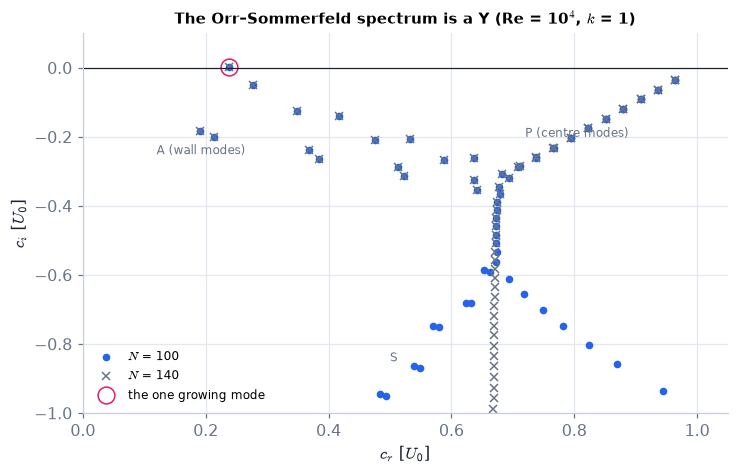

In [104]:
rawA = ch11.orr_sommerfeld_eigs(1.0, 1e4, U, Upp, N=100, filter=False)    # every finite eigenvalue, N = 100
rawB = ch11.orr_sommerfeld_eigs(1.0, 1e4, U, Upp, N=140, filter=False)    # ... and N = 140
fig, ax = plt.subplots(figsize=(6.6, 4.2))   # the figure and its panels
ax.plot(rawA.real, rawA.imag, "o", ms=4, color=C_BUOY, label="$N$ = 100")   # every eigenvalue at N = 100: the three branches of the Y
ax.plot(rawB.real, rawB.imag, "x", ms=5, color=C_BASE, label="$N$ = 140")   # ... and at N = 140: where the two differ the mode is not converged
ax.plot(c_os[0].real, c_os[0].imag, "o", ms=11, mfc="none", color=C_GROW, label="the one growing mode")   # circled: the single eigenvalue above the axis - the growing wave
ax.axhline(0, color=COLORS["ink"], lw=0.8)   # a reference line or band
for (xt, yt, txt) in ((0.12, -0.25, "A (wall modes)"), (0.72, -0.2, "P (centre modes)"), (0.5, -0.85, "S")):   # repeat the indented lines for each item listed
    ax.text(xt, yt, txt, fontsize=8, color=C_BASE)   # a label written on the plot
ax.set(xlabel="$c_r$ [$U_0$]", ylabel="$c_i$ [$U_0$]", xlim=(0, 1.05), ylim=(-1.0, 0.1))   # axis labels (with units) and fixed ranges for this panel
ax.set_title("The Orr–Sommerfeld spectrum is a Y (Re = 10$^4$, $k$ = 1)", fontsize=10)   # panel title — the message of this panel
ax.legend(fontsize=8, loc="lower left")   # legend: one entry per curve
savefig(fig, "ch11", "c11_os_spectrum")   # keep a copy in outputs/ch11 and display
plt.show()   # display the figure

**What does the code above do?**

1. `filter=False` returns the raw spectrum; two resolutions are overlaid, as for the Taylor–Goldstein spectrum of C08.
2. The labels A, P, S are the customary names of the three branches.

**What you see.** Eigenvalues in the complex $c$-plane arranged like the letter Y: two arms at the top (left: wave speeds around 0.2–0.4, right: around 0.9–1) and a stem going straight down near $c_r\approx0.67$. Circles and crosses are two resolutions. One circled eigenvalue at the top of the left arm sits just above the axis.

**How to read it.** That weak mode is the Tollmien–Schlichting wave: $c_i=0.0037$, the only growing one; everything else decays. The left arm holds modes that live near the walls (slow), the right arm modes near the centreline (fast), the stem modes that span the channel. Where circles and crosses disagree (the lower stem) the eigenvalues are not converged — the stem is notoriously sensitive.

**What would change if…** …$\mathrm{Re}=5000$: the circled mode drops below the axis ($c_i=-0.0018$) — C13 finds where it crosses.

**What would change if…** …$\mathrm{Re}\to\infty$? The right side of the Orr–Sommerfeld equation disappears, the order drops from four to two, two boundary
conditions must be abandoned, and the equation is Rayleigh's — whose theorems need no computer at all (C12).

---

## 11.9 Inviscid Stability of Parallel Flows

**What is this section about?** Drop viscosity from the disturbances (the basic profile may still be a viscous one): the
Orr–Sommerfeld equation becomes Rayleigh's equation. Two theorems then classify profiles by their shape alone — a growing wave
needs an inflection point (Rayleigh) at which the vorticity peaks (Fjørtoft) — and neutral waves come with a "critical layer" and
Kelvin's cat's-eye streamlines.

### 🧩 Rayleigh's inflection-point theorem $c_i\int\frac{1}{\lvert U-c\rvert^2}\frac{d^2U}{dy^2}\lvert\phi\rvert^2dy=0$ (11.84): an unstable inviscid parallel flow needs $U''$ to change sign `C12`

*The question:* Can we tell from the shape of a velocity profile whether it can be unstable without viscosity?

#### The problem in plain words

Jets, wakes and mixing layers break into eddies within a few widths downstream; channel and boundary-layer flows hold out much
longer. A forecaster sees jet streams meander into weather systems; an engineer sees a wake shed vortices. Is there something
about the *shape* of a profile that makes it fragile?

#### The idea

$U''$ is (minus) the slope of the vorticity $-U'$ across the flow. An inflection point ($U''=0$ with a sign change) is where the
vorticity has an extremum — the smooth version of C02's vortex sheet. Rayleigh's identity says: no such point, no inviscid growth.
Fjørtoft adds that the extremum must be a *maximum* of the vorticity magnitude.

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **inflection point** — where the curvature $U''$ changes sign. *(Ch. 9, P212)*
- **sech and (tanh)′ = sech²** — $\mathrm{sech}\,x=1/\cosh x$ and $\frac{d}{dx}\tanh x=\mathrm{sech}^2x$. *(Ch. 9, P215)*
- **np.sign and np.nonzero** — `np.nonzero(np.diff(np.sign(f)))` gives the places where a sampled curve crosses zero. *(Ch. 7, P180)*

📝 **Note.** **N91 [B] · N92 [B]** **Rayleigh's equation** ($\mathrm{Re}\to\infty$ in the Orr–Sommerfeld equation):
$(U-c)\big(\frac{d^2\phi}{dy^2}-k^2\phi\big)-\frac{d^2U}{dy^2}\phi=0$ (11.81) — C08's Taylor–Goldstein equation with $N^2=0$. The
limit is *singular*: the order drops from 4 to 2 and only two boundary conditions can be kept, $\phi=0$ at $y=y_1,y_2$ (11.82) (no
flow through the walls; slip is now allowed). No $\mathrm i$ appears, so eigenvalues come in conjugate pairs — a property the
viscous term (with its $\mathrm i$) destroys.

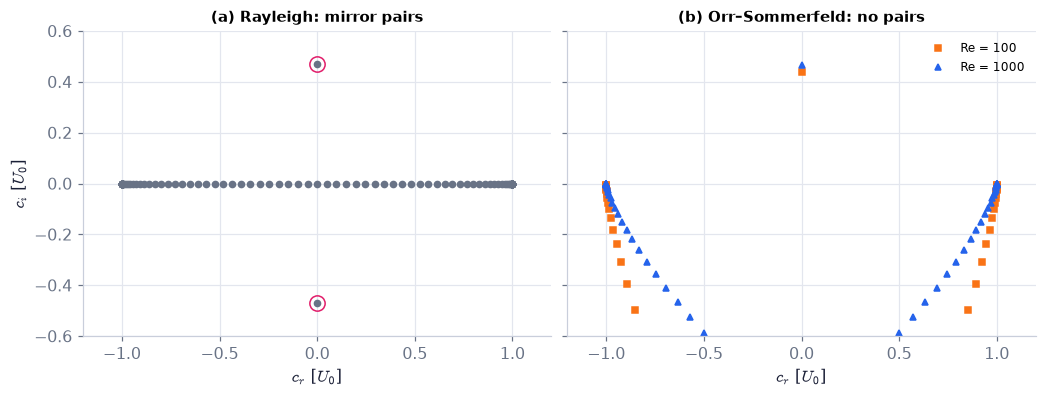

inviscid pair: c = 0.4705j and -0.4705j
viscous leading c: Re = 100: (-0+0.4366j) | Re = 1000: 0.4668j


In [105]:
d2tanh = lambda y: -2*np.tanh(y)/np.cosh(y)**2                     # U'' for the shear layer U = tanh y
sp_ray = ch11.rayleigh_eigs(0.4, np.tanh, d2tanh, bc="decay", N=100, filter=False)                 # inviscid raw spectrum, k = 0.4
sp_os = {Re: ch11.orr_sommerfeld_eigs(0.4, Re, np.tanh, d2tanh, bc="decay", N=100, filter=False) for Re in (100.0, 1000.0)}   # viscous
fig, (a, b) = plt.subplots(1, 2, figsize=(9.4, 3.5), sharey=True)   # the figure and its panels
a.plot(sp_ray.real, sp_ray.imag, "o", ms=4, color=C_BASE)   # inviscid eigenvalues: symmetric about the real axis
a.plot([0, 0], [sp_ray[0].imag, -sp_ray[0].imag], "o", ms=10, mfc="none", color=C_GROW)   # circled: the growing mode and its decaying mirror image
a.set(xlabel="$c_r$ [$U_0$]", ylabel="$c_i$ [$U_0$]", xlim=(-1.2, 1.2), ylim=(-0.6, 0.6))   # axis labels (with units) and fixed ranges for this panel
a.set_title("(a) Rayleigh: mirror pairs", fontsize=10)   # panel title — the message of this panel
for Re, mk, col in ((100.0, "s", C_SHEAR), (1000.0, "^", C_BUOY)):   # repeat the indented lines for each item listed
    b.plot(sp_os[Re].real, sp_os[Re].imag, mk, ms=4, color=col, label=f"Re = {Re:.0f}")   # viscous eigenvalues: one grows, nothing mirrors it
b.set(xlabel="$c_r$ [$U_0$]", xlim=(-1.2, 1.2))   # axis labels (with units) and fixed ranges for this panel
b.set_title("(b) Orr–Sommerfeld: no pairs", fontsize=10)   # panel title — the message of this panel
b.legend(fontsize=8)   # legend: one entry per curve
plt.show()   # display the figure
print("inviscid pair: c =", np.round(sp_ray[0], 4), "and", np.round(sp_ray[-1], 4))   # the growing mode and its conjugate twin
print("viscous leading c: Re = 100:", np.round(sp_os[100.0][0], 4), "| Re = 1000:", np.round(sp_os[1000.0][0], 4))   # with viscosity the growing mode approaches the inviscid one as Re rises

**What does the code above do?**

1. `ch11.rayleigh_eigs(k, U, Upp, bc="decay")` solves Rayleigh's equation on the mapped infinite domain (P270);
   `ch11.orr_sommerfeld_eigs(..., bc="decay")` the viscous one for the same layer.
2. Raw spectra (`filter=False`) are shown so that the real-axis line is visible.

**What you see.** (a) Inviscid eigenvalues of the tanh shear layer: a line on the real axis and one pair of mirror points above and below it (circled). (b) The viscous spectra at two Reynolds numbers: one point above the axis, and everything else in the lower half-plane — no mirror image.

**How to read it.** Without viscosity every growing mode has a decaying twin (the equation has real coefficients). Viscosity breaks the symmetry: the decaying twin is gone, and the continuous line of real eigenvalues is pushed into the damped half-plane.

**What would change if…** …$\mathrm{Re}\to\infty$: the viscous unstable eigenvalue approaches the inviscid one (0.437 at Re = 100, 0.467 at Re = 1000, 0.470 inviscid).

#### 🧮 Derivation — Rayleigh's inflection-point theorem `D22` ★★ (Eq. 11.84: $c_i\int\frac1{\lvert U-c\rvert^2}\frac{d^2U}{dy^2}\lvert\phi\rvert^2dy=0$)

**What we want to show.** Show that an inviscid parallel flow can have a growing wave only if its velocity profile has an inflection point.

**Assumptions.** c_i ≠ 0 (steps 1, 8).

**The plan.**

1. Assume a growing mode and divide by U − c.
2. Multiply by φ*, integrate, by parts.
3. Imaginary part.

**Tools we use** (each explained before this point): Integration by parts (P218a) · real and imaginary parts (P260) · proof by contradiction (P255)

**We start from**

$$ \begin{array}{l}(U-c)\Big(\frac{d^2\phi}{dy^2}-k^2\phi\Big)-\frac{d^2U}{dy^2}\phi=0\qquad\text{(11.81)} \\[4pt] \phi=0\ \text{at}\ y=y_1,\ y_2\qquad\text{(11.82)}\end{array} $$

*In words:* Rayleigh's equation.

---

**Step 1 of 9 — Suppose c_i ≠ 0.**

$$ U-c\neq0\ \text{for all}\ y $$

- *Why we can do this:* U is real, so Im(U − c) = −c_i ≠ 0 (P255).
- *In words:* we may divide.

---

**Step 2 of 9 — Divide by U − c.**

$$ \frac{d^2\phi}{dy^2}-k^2\phi-\frac1{U-c}\frac{d^2U}{dy^2}\phi=0 $$

- *Why we can do this:* step 1. Dividing isolates the highest derivative, so that multiplying by the conjugate gives a real, positive integral.
- *In words:* the book's rewritten form.

---

**Step 3 of 9 — Multiply by φ* and integrate.**

$$ \int\phi^*\phi''dy-k^2\int\lvert\phi\rvert^2dy-\int\frac{U''}{U-c}\lvert\phi\rvert^2dy=0 $$

- *Why we can do this:* conjugate times function gives a modulus (P81); integrate over [y₁, y₂].
- *In words:* an identity between numbers.

---

**Step 4 of 9 — Integrate by parts.**

$$ \int\phi^*\phi''dy=\big[\phi^*\phi'\big]_{y_1}^{y_2}-\int\lvert\phi'\rvert^2dy=-\int\lvert\phi'\rvert^2dy $$

- *Why we can do this:* P218a; φ = 0 at the walls (11.82), $\phi=0\ \text{at}\ y=y_1,\ y_2$.
- *In words:* curvature becomes gradient squared.

---

**Step 5 of 9 — Collect.**

$$ \int(\lvert\phi'\rvert^2+k^2\lvert\phi\rvert^2)dy+\int\frac1{U-c}\frac{d^2U}{dy^2}\lvert\phi\rvert^2dy=0\ \text{(11.83)} $$

- *Why we can do this:* multiply step 3 by −1 after step 4.
- *In words:* the book's identity.

---

**Step 6 of 9 — Use the conjugate trick.**

$$ \frac1{U-c}=\frac{U-c^*}{\lvert U-c\rvert^2}=\frac{U-c_r+\mathrm ic_i}{\lvert U-c\rvert^2} $$

- *Why we can do this:* multiply top and bottom by the conjugate (P260).
- *In words:* the imaginary part is now visible.

---

**Step 7 of 9 — Take the imaginary part.**

$$ c_i\int\frac1{\lvert U-c\rvert^2}\frac{d^2U}{dy^2}\lvert\phi\rvert^2dy=0\ \text{(11.84)} $$

- *Why we can do this:* the first integral of (11.83), $\int\big(\lvert\phi'\rvert^2+k^2\lvert\phi\rvert^2\big)dy+\int\frac1{U-c}\frac{d^2U}{dy^2}\lvert\phi\rvert^2dy=0$ is real; only the c_i part of step 6 is imaginary.
- *In words:* c_i times a weighted integral of U″ is zero.

---

**Step 8 of 9 — Divide by c_i.**

$$ \int\frac{\lvert\phi\rvert^2}{\lvert U-c\rvert^2}\frac{d^2U}{dy^2}dy=0 $$

- *Why we can do this:* c_i ≠ 0 (step 1). A product is zero only if one factor is; the first factor is not, so the integral must vanish.
- *In words:* the weighted average of U″ vanishes.

---

**Step 9 of 9 — Conclude.**

$$ U''\ \text{changes sign in}\ (y_1,y_2) $$

- *Why we can do this:* the weight ∣φ∣²/∣U − c∣² is positive inside; a function of one sign cannot integrate to zero against it.
- *In words:* an inflection point is necessary for inviscid instability.

---

**Result**

$$ c_i\neq0\ \Rightarrow\ \int\frac{\lvert\phi\rvert^2}{\lvert U-c\rvert^2}\frac{d^2U}{dy^2}dy=0\ \Rightarrow\ \frac{d^2U}{dy^2}\ \text{changes sign somewhere in}\ (y_1,y_2) $$

*In words:* inflection-free profiles (Couette, Poiseuille, favourable boundary layers) are inviscidly stable.

**What it means.** Classifies profiles without solving; Fjørtoft (N93) sharpens it. Ch. 13: with the β-effect U″ is replaced by U″ − β (Rayleigh–Kuo). Necessary, not sufficient (N95).

**Check it.** Poiseuille (U″ = −2): no unstable Rayleigh eigenvalue found ✓; tanh: inflection at 0 and growth ✓; identity (11.83), $\int\big(\lvert\phi'\rvert^2+k^2\lvert\phi\rvert^2\big)dy+\int\frac1{U-c}\frac{d^2U}{dy^2}\lvert\phi\rvert^2dy=0$ holds for a computed mode (`ch11.rayleigh_identity_check`, run in the cell below) ✓.

> ⚠️ **Common confusion (traps in `D22`):** Forgetting that the theorem needs c_i ≠ 0; reading "inflection point" as sufficient; dropping the boundary term without citing φ = 0.

In [106]:
mR = ch11.rayleigh_eigs(0.4, np.tanh, d2tanh, bc="decay", N=100, return_vectors=True)   # the growing mode of the tanh layer, with its shape phi(y)
idR = ch11.rayleigh_identity_check(0.4, mR["c"][0], mR["phi"][:, 0], mR["y"], np.tanh, d2tanh, grid=mR["grid"])   # both parts of D22's identity
print("c =", np.round(mR["c"][0], 4), "| residuals of the identity of step 5: real part", f"{idR['res_real']:.1e}", "imaginary part", f"{idR['res_imag']:.1e}")   # D22's identity holds for the computed growing mode
yP = np.linspace(-1, 1, 201)                                        # plane Poiseuille flow: U'' = -2 everywhere, no sign change
cP = ch11.rayleigh_eigs(1.0, lambda y: 1 - y**2, lambda y: -2 + 0*y, N=100, unstable_only=True)   # converged unstable inviscid modes
print("plane Poiseuille, inviscid: unstable eigenvalues found:", len(cP))   # no inflection point, no inviscid instability

c = 0.4705j | residuals of the identity of step 5: real part 1.6e-13 imaginary part 3.1e-13
plane Poiseuille, inviscid: unstable eigenvalues found: 0


**What does the code above do?**

1. `return_vectors=True` returns the mode shape; `ch11.rayleigh_identity_check` evaluates the integral identity of D22 step 5
   (real and imaginary parts) with Clenshaw–Curtis weights: both residuals vanish to round-off for the computed growing mode.
2. For plane Poiseuille flow, whose curvature never changes sign, the inviscid solver finds no unstable mode — as the theorem says.

📝 **Note.** **N93 [B]** **Fjørtoft's theorem.** The real part of Rayleigh's identity is
$\int\frac{U-c_r}{\lvert U-c\rvert^2}\frac{d^2U}{dy^2}\lvert\phi\rvert^2dy=-\int\big(\lvert\phi'\rvert^2+k^2\lvert\phi\rvert^2\big)dy<0$
(11.85); because the integral of D22's step 8 is zero for a growing mode, any constant times it can be added:
$(c_r-U_I)\int\frac1{\lvert U-c\rvert^2}\frac{d^2U}{dy^2}\lvert\phi\rvert^2dy=0$ (11.86); the sum gives
$\int\frac{U-U_I}{\lvert U-c\rvert^2}\frac{d^2U}{dy^2}\lvert\phi\rvert^2dy<0$, so $(U-U_I)U''<0$ somewhere — the vorticity magnitude
has a **maximum** at the inflection point. ⚠️ The book writes $U_1$ for $U$ at the inflection point; we write $U_I$ ($U_1$ was the
upper stream in C02).

#### ✏️ Tiny example: three profiles by hand

1. **Poiseuille** $U=1-y^2$: $U''=-2$ everywhere — no sign change, no inflection ⇒ inviscidly stable (Rayleigh).
2. **tanh** $U=\tanh y$: $U''=-2\tanh y\,\mathrm{sech}^2y$ — negative for $y>0$, positive for $y<0$ ⇒ inflection at $y=0$,
   $U_I=0$; $(U-U_I)U''=-2\tanh^2y\,\mathrm{sech}^2y\le0$ ⇒ Fjørtoft satisfied: instability possible (and real: $kc_i=0.19$).
3. **$\sin y$ on $\lvert y\rvert\le b$**: $U''=-\sin y$ changes sign at 0, and $(U-0)U''=-\sin^2y<0$: both criteria pass — yet for
   $2b<\pi$ the flow is stable (N95). The criteria are necessary, not sufficient.

In [107]:
print("panel | profile | inflection point (Rayleigh) | vorticity maximum (Fjortoft) | y_I")   # header of the verdict table
for v in ch11.fig_11_21_verdicts():                                 # our stand-ins for six classic profiles, with the two verdicts
    print(f"  ({v['panel']}) {v['label']:34s} {str(v['rayleigh']):6s} {str(v['fjortoft']):6s} {np.round(v['y_I'], 3)}")   # one profile per row: does it pass Rayleigh's and Fjortoft's tests?
yT = np.linspace(-3.0, 3.0, 601)                                    # sample points across the tanh layer
print(ch11.rayleigh_criterion(yT, np.tanh, d2tanh))                 # (11.84): is there an inflection point, and where?
print({n: v for n, v in ch11.fjortoft_criterion(yT, np.tanh, d2tanh).items()})   # (11.86): is (U - U_I) U'' < 0 somewhere?
tm = ch11.tanh_max_growth()                                         # the fastest-growing inviscid wave of the tanh layer
bm = BENCH["tanh_shear_layer_inviscid"]                             # published (Michalke 1964)
print(f"fastest tanh wave: k = {tm['k']:.4f}, k c_i = {tm['kci']:.4f}, c = {tm['c'].imag:.4f} i   (published {bm['k_max']}, {bm['kci_max']})")   # the most dangerous wavelength of a shear layer, against the published value

panel | profile | inflection point (Rayleigh) | vorticity maximum (Fjortoft) | y_I


  (a) Blasius boundary layer (δ* units)  False  False  []
  (b) plane Couette U = y                False  False  []
  (c) plane Poiseuille U = 1 − y²        False  False  []
  (d) U = sinh(2y)/sinh 2                True   False  [0.]
  (e) U = sin y, |y| ≤ 3.142             True   True   [0.]
  (f) U = tanh(y/0.3)/tanh(1/0.3)        True   True   [0.]
{'has_inflection': True, 'y_I': array([0.])}
{'satisfied': True, 'U_I': [0.0], 'y_I': array([0.]), 'min_product': -0.49999811142809275}


fastest tanh wave: k = 0.4449, k c_i = 0.1897, c = 0.4264 i   (published 0.4446, 0.1897)


**What does the code above do?**

1. `ch11.fig_11_21_verdicts()` lists six profiles — (a) Blasius, (b) plane Couette, (c) plane Poiseuille, (d) a profile whose
   vorticity is largest at the walls, (e) $\sin y$, (f) a shear layer between walls — with the two verdicts: (a)–(c) have no
   inflection point; (d) has one but fails Fjørtoft; (e) and (f) pass both.
2. `ch11.rayleigh_criterion(y, U, Upp)` and `ch11.fjortoft_criterion(y, U, Upp)` apply the two necessary conditions to one profile.
3. `ch11.tanh_max_growth()` maximises $kc_i$ over $k$ for the tanh layer: $k=0.445$, $kc_i=0.190$, matching the published value.

In [108]:
yS = np.linspace(-3.0, 3.0, 600)                                    # an even number of points, so that y = 0 is not a sample
s = np.sign(d2tanh(yS))                                             # the sign of U'' at each point
idx = np.nonzero(np.diff(s))[0]                                     # where the sign changes between neighbours (Ch. 7 P180)
y_I = 0.5*(yS[idx] + yS[idx + 1])                                   # the inflection point: midway between the two samples
assert np.allclose(y_I, ST.inflection_points(yS, Upp=d2tanh(yS)), atol=yS[1] - yS[0])   # same point as the library
fj = np.min((np.tanh(yS) - np.tanh(y_I[0]))*d2tanh(yS))             # Fjortoft's product (U - U_I) U'': is it negative somewhere?
print(f"inflection at y = {y_I[0]:.3f}; min of (U - U_I) U'' = {fj:.3f} < 0 -> Fjortoft satisfied")   # the vorticity is largest at the inflection point: both criteria met

inflection at y = 0.000; min of (U - U_I) U'' = -0.500 < 0 -> Fjortoft satisfied


**What does the code above do?**

1. `np.sign` and `np.diff` find where $U''$ changes sign — the inflection point.
2. Fjørtoft's product $(U-U_I)U''$ is negative: the vorticity magnitude peaks at the inflection point.

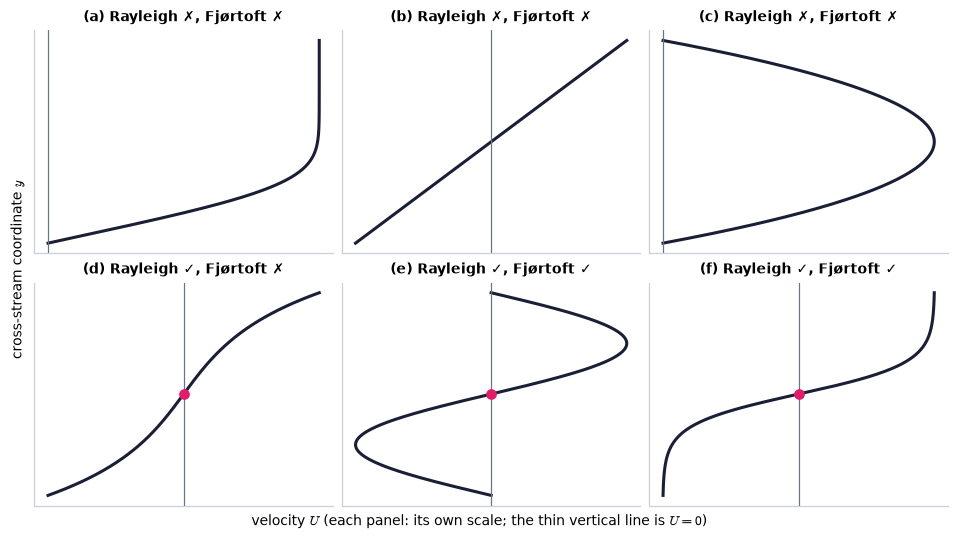

In [109]:
fig, axs = plt.subplots(2, 3, figsize=(8.6, 4.8))   # the figure and its panels
six_profiles(axs)                                                  # drawing helper: the six profiles with inflection points and verdicts
fig.supxlabel("velocity $U$ (each panel: its own scale; the thin vertical line is $U=0$)", fontsize=9)   # one label for all panels
fig.supylabel("cross-stream coordinate $y$", fontsize=9)   # one vertical label for all six panels
plt.show()   # display the figure

**What you see.** Six velocity profiles ($U$ horizontal, $y$ vertical): (a) Blasius boundary layer, (b) plane Couette, (c) plane Poiseuille, (d) a profile that is steepest at the walls, (e) a sine profile, (f) a shear layer between walls. Rose dots mark inflection points; each title gives the two verdicts.

**How to read it.** Only (e) and (f) pass both tests: they have an inflection point *and* the vorticity magnitude is largest there. (d) has an inflection point, but its vorticity is largest at the walls, not inside — Fjørtoft rules it out.

**What would change if…** …an adverse pressure gradient bends a boundary-layer profile toward the shape of (f) (Ch. 9: the curvature at the wall changes sign): it becomes inviscidly unstable (R24, C13).

📝 **Note.** **N94 [B]** **Which flows are suspect?** Jets, wakes, mixing layers and adverse-pressure boundary layers have an inflection point with a
vorticity maximum: potentially unstable at any Re. Couette, Poiseuille and favourable or zero-gradient boundary layers have none:
inviscidly stable — any instability they have must come from viscosity (C13).

📝 **Note.** **N95 [B]** **Not sufficient.** $U=\sin y$ between walls at $y=\pm b$ has an inflection point that satisfies both criteria, yet it is stable
for $2b<\pi$ (Tollmien).

In [110]:
for b in ((1.4, 2.0) if FAST else (1.4, 1.7, 2.0, 3.0)):            # half-widths: 2b < pi for 1.4, 2b > pi for the others
    print(f"b = {b}: 2b {'<' if 2*b < np.pi else '>'} pi, largest growth rate k c_i = {ch11.sin_profile_max_growth(b):.4f}")   # the inflected sine profile grows only when the channel is wider than pi

b = 1.4: 2b < pi, largest growth rate k c_i = 0.0000


b = 1.7: 2b > pi, largest growth rate k c_i = 0.0119


b = 2.0: 2b > pi, largest growth rate k c_i = 0.0596


b = 3.0: 2b > pi, largest growth rate k c_i = 0.1573


**What does the code above do?**

`ch11.sin_profile_max_growth(b)` scans $k$ and returns the largest inviscid growth rate: zero for $b=1.4$, positive beyond
$b=\pi/2\approx1.571$, and growing with $b$.

📝 **Note.** **N96 [B]** **Critical layers.** A neutral mode has a real $c$, and Howard's result $U_{\min}<c_r<U_{\max}$ (11.71) puts it inside the velocity
range, so $U(y_c)=c$ at some $y_c$: the *critical layer*, a singular point of Rayleigh's equation (P269) where $\phi$ may be
discontinuous. The full Orr–Sommerfeld equation has no such singularity; a thin viscous layer forms there instead, thinning as Re
grows.

In [111]:
print("critical layer of U = tanh y for c = 0.3: y_c =", np.round(ch11.critical_layer(np.linspace(-2, 2, 401), np.tanh, 0.3), 4),   # the height at which the flow moves exactly at the wave speed ...
      "| artanh(0.3) =", round(np.arctanh(0.3), 4))   # ... which for a tanh profile is artanh(c)

critical layer of U = tanh y for c = 0.3: y_c = [0.3095] | artanh(0.3) = 0.3095


📝 **Note.** **N97 [B]** **Kelvin's cat's eye.** Seen by an observer moving at $c$, the basic flow is $U-c$, with stream function $\int(U-c)\,dy$; adding
the neutral wave, $\hat\psi=\int(U-c)\,dy+A\phi(y)\exp\{\mathrm ikx\}$ (11.87). Near $y_c$ a Taylor expansion ($U(y_c)=c$ kills the
linear term) gives $\hat\psi\cong\frac{(y-y_c)^2}2\big[\frac{dU}{dy}\big]_{y=y_c}+A\phi(y_c)\cos(kx)$: closed "eyes" of half-height
$2\sqrt{A\phi_c/U'_c}$ (our formula) around the critical layer.

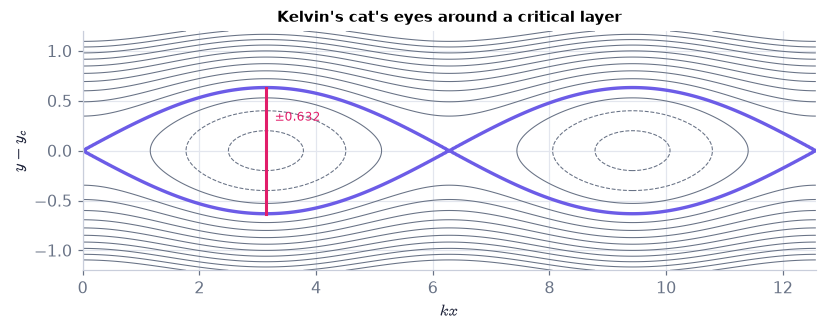

half-height of the eye: 0.6325 = 2 sqrt(A phi_c / U'_c) with A = 0.1


In [112]:
Xc, Yc = np.meshgrid(np.linspace(0, 4*np.pi, 241), np.linspace(-1.2, 1.2, 121))   # two wavelengths, around the critical layer
psi_c = ch11.cats_eye_streamfunction(Xc, Yc, y_c=0.0, A=0.1, phi_c=1.0, k=1.0, Uy_c=1.0)   # (11.87) expanded near y_c
half = ch11.cats_eye_width(0.1, 1.0, 1.0)                           # half-height of the eye
fig, ax = plt.subplots(figsize=(7.4, 2.9))   # the figure and its panels
ax.contour(Xc, Yc, psi_c, levels=np.linspace(-0.08, 0.7, 14), colors=C_BASE, linewidths=0.7)   # contour lines of the field
ax.contour(Xc, Yc, psi_c, levels=[0.1], colors=C_NEUT, linewidths=2.2)      # the separatrix: the streamline through the saddle points
ax.plot([np.pi, np.pi], [-half, half], color=C_GROW, lw=2)   # rose bar: the height of one eye
ax.text(np.pi + 0.15, 0.3, f"±{half:.3f}", color=C_GROW, fontsize=8)   # a label written on the plot
ax.set(xlabel="$kx$", ylabel="$y-y_c$")   # axis labels (with units) and fixed ranges for this panel
ax.set_title("Kelvin's cat's eyes around a critical layer", fontsize=10)   # panel title — the message of this panel
plt.show()   # display the figure
print("half-height of the eye:", round(half, 4), "= 2 sqrt(A phi_c / U'_c) with A = 0.1")   # the eye grows like the square root of the wave amplitude

**What does the code above do?**

1. `ch11.cats_eye_streamfunction(x, y, y_c, A, phi_c, k, Uy_c)` evaluates the expanded stream function near the critical layer;
   `ch11.cats_eye_width` its half-height $2\sqrt{A\phi_c/U'_c}=0.632$.
2. The level $\hat\psi=A\phi_c$ is the separatrix (it passes through the saddle points between the eyes).

**What you see.** Streamlines seen by an observer riding on the wave: wavy lines above and below, and between them a chain of closed loops — the eyes — bounded by the bold purple streamline. The rose bar marks the height of one eye.

**How to read it.** Fluid inside an eye circulates with the wave; fluid outside passes by, to the right above and to the left below. This is the billow of C02 in its linear infancy.

**What would change if…** …we double the wave amplitude A: the eyes grow taller by √2.

📝 **Note.** **N126 [B]** **A shear layer you can solve by hand (Exercise 11.11).** A piecewise-linear layer (speed $U_1$ above, $U_3$ below, linear in
between, thickness $h$) gives $c_o^2=\big(\frac{U_1-U_3}{2kh}\big)^2\{(kh-1)^2-e^{-2kh}\}$ for the wave speed $c_o$ relative to the
mean: unstable when the brace is negative, neutral at $kh=1.2785$ (our root of $(kh-1)^2=e^{-2kh}$).

In [113]:
kh_n = ch11.piecewise_neutral_kh()                                  # root of (kh - 1)^2 = exp(-2 kh)
c_pw = ch11.piecewise_shear_layer_c(0.797)                          # wave speed at kh = 0.797 for a unit velocity difference
print(f"neutral at kh = {kh_n:.4f} (reference {BENCH['piecewise_shear_layer_neutral_kh']['kh']}); at kh = 0.797: c = {c_pw:.4f}, growth k c_i h/dU = {0.797*c_pw.imag:.4f}")   # the piecewise-linear layer: where it turns neutral, and its growth at one wavelength

neutral at kh = 1.2785 (reference 1.278465); at kh = 0.797: c = 0.0000+0.2524j, growth k c_i h/dU = 0.2012


📝 **Note.** **N127 [B]** **Symmetric and antisymmetric profiles (Exercise 11.12).** Written for $\hat v=-\mathrm ik\phi$, Rayleigh's equation is
$(U-c)\big(\frac{d^2\hat v}{dy^2}-k^2\hat v\big)-\frac{d^2U}{dy^2}\hat v=0$ (11.95). If $U$ is odd (a shear layer) and $c$ is an
eigenvalue so is $-c^*$ (waves come in mirror pairs); if $U$ is even (a jet) the modes split into *sinuous* ($\hat v$ even: the
jet wiggles) and *varicose* ($\hat v$ odd: it pulses).

In [114]:
bk = ch11.inviscid_profile("bickley")                               # the plane jet U = sech^2 y (R23 in the next section)
c_sin = ch11.rayleigh_eigs(1.0, bk["U"], bk["Upp"], bc="decay", parity="even", N=100)[0]   # sinuous mode at k = 1
c_var = ch11.rayleigh_eigs(0.5, bk["U"], bk["Upp"], bc="decay", parity="odd", N=100)[0]    # varicose mode at k = 0.5
print("jet: sinuous c =", np.round(c_sin, 4), "(k = 1) | varicose c =", np.round(c_var, 4), "(k = 0.5): both grow, the sinuous one faster")   # a jet has two kinds of growing wave: flapping and pulsing

jet: sinuous c = (0.4751+0.159j) (k = 1) | varicose c = (0.7193+0.092j) (k = 0.5): both grow, the sinuous one faster


#### 🎮 Interactive: Which profiles can be unstable without viscosity?

**Why interactive rather than a static figure:** Switching profiles moves the inflection marker, flips the verdict badges and moves the eigenvalues on the $c$-plane — always
inside the semicircle — and clicking a neutral mode opens the cat's eye in the frame moving with $c$: each theorem is checked
against an example instead of being read.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Preset 'wall-vorticity-max': Rayleigh ✓ but Fjørtoft ✗ — find where (U − U_I)U″ is positive.
- Preset 'sin y' and drag b across π/2: the eigenvalue leaves the real axis only when 2b > π.
- Open the cat's eye and double A: the eye grows by √2.

In [115]:
show_viz("ch11", "inviscid_shear_criteria")   # full-width explainer; ⤢ Full screen for more room

[explainer ch11/inviscid_shear_criteria]

**What would change if…** …the profile has no inflection point at all, like plane Poiseuille flow? Rayleigh says no inviscid instability — but C11's
spectrum already showed a growing mode at $\mathrm{Re}=10^4$. Viscosity itself must be doing it: C13.

---

## 11.10 Results for Parallel and Nearly Parallel Viscous Flows

**What is this section about?** With the Orr–Sommerfeld solver of C11 we can trace, for any parallel flow, the curve in the
(Re, k) plane where waves neither grow nor decay. Inflectional flows (jets, mixing layers) go unstable at tiny Re; plane
Poiseuille flow, which Rayleigh calls stable, goes unstable at Re = 5772 because of viscosity; Couette and pipe flow never do,
linearly. C14 explains how viscosity can destabilise, through the energy budget of the disturbance.

> 🔁 **Recap — The Bickley jet** (Ch. 9, free jets). The plane laminar jet of Ch. 9, $u=u_0\,\mathrm{sech}^2\big(\frac\eta{\sqrt6}\big)$ (9.71), i.e. $U=U_0\,\mathrm{sech}^2(y/L)$
(`JET.free_jet_profile`). **New here:** it is inflectional and very unstable: its sinuous mode goes unstable at
$\mathrm{Re}=U_0L/\nu\approx4$ at $kL\approx0.2$ (Tatsumi & Kakutani 1958, approximate; our value 4.017 at 0.173); its inviscid neutral modes are at $k=2$
(sinuous) and $k=1$ (varicose) with $c=2/3$ (Drazin & Reid 1981).

> 🔁 **Recap — Boundary layers with a pressure gradient** (Ch. 9 §9.7). Ch. 9's rule: a favourable pressure gradient keeps the profile free of inflection points,
$\big(\frac{\partial^2u}{\partial y^2}\big)_{wall}<0$ for $dp/dx<0$ (9.51); an adverse one creates one,
$\big(\frac{\partial^2u}{\partial y^2}\big)_{wall}>0$ for $dp/dx>0$ (9.52). **New here:** the neutral curves of Falkner–Skan
profiles — favourable and zero gradient close into a loop as $\mathrm{Re}\to\infty$ (inviscidly stable), adverse ones keep a flat
upper branch (inflectional, inviscidly unstable) and go unstable at lower Re (`ch11.falkner_skan_neutral_curve`).

### 🧩 Plane Poiseuille flow: viscously unstable above $\mathrm{Re}_c=5772.22$ at $k_c=1.02056$ (Orszag 1971), and the family of Table 11.1 `C13`

*The question:* How can a flow that Rayleigh's theorem calls stable become unstable when viscosity is added?

#### The problem in plain words

Water flowing between two plates has the parabolic profile of Ch. 8 — no inflection point, so by C12 no inviscid instability. Yet
the Orr–Sommerfeld spectrum of C11 had a growing wave at $\mathrm{Re}=10^4$. Where exactly does it start, which wavelength comes
first, and how do other flows of the same family compare?

#### The idea

```
k ▲      ____                    neutral curve c_i(k, Re) = 0: a 'thumb'
  │   .-'    '----.___           inside: Tollmien–Schlichting (TS) waves grow
  │  (   unstable      '-----    outside: everything decays
  │   '-.___ ◆_______________    ◆ = the critical point (Re_c, k_c): first instability as Re rises
  └──────────────────────────► log Re
inviscid profiles (tanh, jets): the thumb reaches Re → 0;  Poiseuille: starts at 5772;  Couette, pipe: no thumb at all
```

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **caching expensive runs** — results that take minutes are computed once and stored in a small file; the notebook reads them and recomputes one value to show the method. *(Ch. 10, P252)*

📝 **Note.** **N98 [C]** **Viscosity cuts both ways** (named): at very large Re it damps the shortest waves; near the walls it shifts the phase of the
motion so that the wave can extract energy (C14). The asymptotic theory (Heisenberg, Lin, Shen, Yih — wall and critical layers as
singular perturbations) is notoriously hard; we compute.

#### ✏️ Tiny example: what the critical Reynolds number means for water

Channel half-width $L=1$ cm, water $\nu=10^{-6}$ m²/s.

1. $\mathrm{Re}=U_0L/\nu$ with $U_0$ the centreline speed: $\mathrm{Re}_c=5772$ ⇒ $U_0=5772\times10^{-6}/0.01=0.577$ m/s.
2. The mean speed of a parabola is $\tfrac23U_0=0.385$ m/s; a Reynolds number built on the mean speed and the full width $2L$
   would read $\tfrac23\times2\times5772=7696$ — always say which length and speed (Ch. 9, P200).
3. At $\mathrm{Re}=10^4$, $k=1$ (C11): $kc_i=0.00374$ in units $U_0/L$; with $L=1$ cm and $U_0=1$ m/s that is 0.374 s⁻¹, an
   e-folding time of 2.7 s, for a wave $2\pi L=6.3$ cm long travelling at $c_rU_0=0.24$ m/s.

In [116]:
crit_P = ch11.poiseuille_critical()                                 # the critical point (stored result of the two nested searches of P263)
ref_P = BENCH["plane_poiseuille_critical"]                          # published (Orszag 1971)
print(f"Re_c = {crit_P['Re_c']:.2f}, k_c = {crit_P['k_c']:.5f}, c_r = {crit_P['c_r']:.5f}   (published {ref_P['Re_c']}, {ref_P['k_c']}, {ref_P['c_r']})")   # the Reynolds number at which a channel flow first becomes unstable
nc = ch11.poiseuille_neutral_curve()                                # the neutral curve: lower and upper unstable wavenumber for each Re
lo = np.interp(np.log(1e4), np.log(nc["Re"]), nc["k_lower"])        # read the curve at Re = 10^4 (interpolating in log Re)
hi = np.interp(np.log(1e4), np.log(nc["Re"]), nc["k_upper"])   # ... and its upper edge
print(f"at Re = 10^4 the wavenumbers from k = {lo:.2f} to {hi:.2f} grow")   # the band of growing waves well above the critical point
print("plane Couette flow, leading c_i at k = 1: Re = 10^3:", round(ch11.couette_max_growth(1.0, 1e3), 4), "| Re = 10^4:", round(ch11.couette_max_growth(1.0, 1e4), 4))   # negative at both Reynolds numbers: Couette flow damps this wave

Re_c = 5772.22, k_c = 1.02055, c_r = 0.26400   (published 5772.22, 1.02056, 0.264)
at Re = 10^4 the wavenumbers from k = 0.80 to 1.09 grow
plane Couette flow, leading c_i at k = 1: Re = 10^3: -0.1192 | Re = 10^4: -0.0521


**What does the code above do?**

1. `ch11.poiseuille_critical()` returns the critical point — P263's two nested searches (zero of $c_i$ in Re, minimum over $k$)
   on the Orr–Sommerfeld eigenvalue; it is a stored result (Ch. 10 P252: expensive runs are cached), and the next cell recomputes
   it independently. It matches the published benchmark to all its digits.
2. `ch11.poiseuille_neutral_curve()` gives, for each Re, the lower and upper edge of the unstable band — the "thumb".
3. `ch11.couette_max_growth(k, Re)`: for plane Couette flow the leading $c_i$ is negative — it decays.

In [117]:
Re_mine = brentq(lambda Re: np.imag(ch11.orr_sommerfeld_eigs(1.02056, Re, U, Upp, N=80)[0]), 5000.0, 7000.0, xtol=1e-3)   # where c_i = 0 at k = k_c
assert np.isclose(Re_mine, crit_P["Re_c"], rtol=1e-4)               # one root search reproduces the stored critical point
print(f"c_i = 0 at k = 1.02056 for Re = {Re_mine:.2f}")   # the root search lands on the stored critical Reynolds number

c_i = 0 at k = 1.02056 for Re = 5772.22


**What does the code above do?**

The stored critical point is not a black box: one `brentq` on the sign of $c_i(\mathrm{Re})$ at $k=k_c$, with a fresh
Orr–Sommerfeld solve at every trial Re, lands on 5772.22.

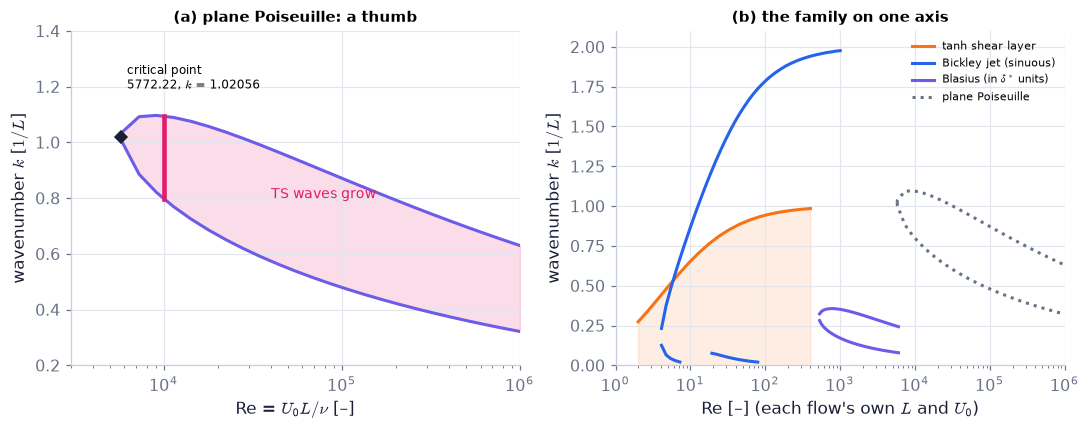

first Re in each table: Bickley 4.1, Blasius 530, tanh 2 (unstable at every Re computed)
Bickley jet: critical point Re_c = 4.017 at k = 0.173 (its bands are drawn in detail in the next figure)


In [118]:
def read_curve(name):                                              # one of our small public tables of neutral curves in reference/ch11
    return np.genfromtxt(ROOT / "reference" / "ch11" / f"os_neutral_{name}.csv", delimiter=",", skip_header=2, names=True)   # the values for this call

bj, bl = read_curve("bickley"), read_curve("blasius")              # Bickley jet and Blasius boundary layer (Orr-Sommerfeld, ours)
tl = ch11.tanh_shear_layer_neutral_curve()                         # tanh shear layer: the upper neutral wavenumber for each Re
fig, (a, b) = plt.subplots(1, 2, figsize=(9.8, 3.8))   # the figure and its panels
Re_th = np.concatenate([[crit_P["Re_c"]], nc["Re"]])                  # the thumb, closed at its tip by the critical point
k_lo, k_hi = np.concatenate([[crit_P["k_c"]], nc["k_lower"]]), np.concatenate([[crit_P["k_c"]], nc["k_upper"]])   # the lower and upper neutral wavenumbers, both starting at the tip
a.fill_between(Re_th, k_lo, k_hi, color=C_GROW, alpha=0.15)   # shade the area between two curves
a.semilogx(Re_th, k_lo, color=C_NEUT)   # lower side of the thumb: longer waves decay
a.semilogx(Re_th, k_hi, color=C_NEUT)   # upper side of the thumb: shorter waves decay
a.plot(crit_P["Re_c"], crit_P["k_c"], "D", color=COLORS["ink"])   # diamond: the tip - the first wave to grow as Re rises
a.plot([1e4, 1e4], [lo, hi], color=C_GROW, lw=3)   # rose bar: the growing wavenumbers at Re = 10^4
a.text(6200, 1.19, "critical point\n5772.22, $k$ = 1.02056", fontsize=8)   # a label written on the plot
a.text(4e4, 0.8, "TS waves grow", color=C_GROW, fontsize=9)   # a label written on the plot
a.set(xlabel="Re = $U_0L/\\nu$ [–]", ylabel="wavenumber $k$ [$1/L$]", xlim=(3e3, 1e6), ylim=(0.2, 1.4))   # axis labels (with units) and fixed ranges for this panel
a.set_title("(a) plane Poiseuille: a thumb", fontsize=10)   # panel title — the message of this panel
b.fill_between(tl["Re"], 0*tl["Re"], tl["k_upper"], color=C_SHEAR, alpha=0.12)   # shade the area between two curves
b.semilogx(tl["Re"], tl["k_upper"], color=C_SHEAR, label="tanh shear layer")   # shear layer: every wave longer than this grows, at any Re
b.semilogx(bj["Re"], bj["k_upper"], color=C_BUOY, label="Bickley jet (sinuous)")   # jet: upper neutral wavenumber, rising toward the inviscid value 2
b.semilogx(bj["Re"], bj["k_lower"], color=C_BUOY)                   # its lower edge where the table resolves it (gaps in the line: edge below k = 0.02)
b.semilogx(bl["Re"], bl["k_upper"], color=C_NEUT, label="Blasius (in $\\delta^*$ units)")   # boundary layer: upper side of its thumb
b.semilogx(bl["Re"], bl["k_lower"], color=C_NEUT)   # ... and lower side
b.semilogx(Re_th, k_hi, ":", color=C_BASE, label="plane Poiseuille")   # dotted: the channel-flow thumb of panel (a), far to the right
b.semilogx(Re_th, k_lo, ":", color=C_BASE)   # ... its lower side
b.set(xlabel="Re [–] (each flow's own $L$ and $U_0$)", ylabel="wavenumber $k$ [$1/L$]", xlim=(1, 1e6), ylim=(0, 2.1))   # axis labels (with units) and fixed ranges for this panel
b.set_title("(b) the family on one axis", fontsize=10)   # panel title — the message of this panel
b.legend(fontsize=7, loc="upper right")   # legend: one entry per curve
savefig(fig, "ch11", "c13_neutral_curves")   # keep a copy in outputs/ch11 and display
plt.show()   # display the figure
print(f"first Re in each table: Bickley {bj['Re'][0]:.1f}, Blasius {bl['Re'][0]:.0f}, tanh {tl['Re'][0]:.0f} (unstable at every Re computed)")   # how early each flow becomes unstable
bcj = ch11.bickley_critical()                                      # the jet's critical point (stored)
print(f"Bickley jet: critical point Re_c = {bcj['Re_c']:.3f} at k = {bcj['k_c']:.3f} (its bands are drawn in detail in the next figure)")   # the jet's first unstable wave

**What does the code above do?**

1. `read_curve` reads one of our small public tables (`reference/ch11/os_neutral_*.csv`, computed by
   `scripts/ch11_neutral_curves.py`) with `np.genfromtxt`; the first two lines of each file are comments.
2. `ch11.tanh_shear_layer_neutral_curve()` returns the stored upper neutral wavenumber of the tanh layer (it has no lower branch:
   every longer wave grows).
3. Each flow uses its own length and velocity scale (Table 11.1 below), so only the orders of magnitude should be compared.

**What you see.** (a) The neutral curve of plane Poiseuille flow on a logarithmic Re axis: a thumb pointing left, tip (◆) at 5772.22; the rose bar is the unstable band at Re = 10⁴. (b) The same curve (grey dotted, far right) next to the neutral curves of the tanh shear layer (orange), the Bickley jet (blue) and the Blasius boundary layer (purple). The jet has, besides its long upper curve, two short blue pieces near the bottom: its lower edge, drawn only where the table resolves it (elsewhere it lies below the smallest wavenumber computed, k = 0.02). The next figure shows the jet alone, with its bands shaded.

**How to read it.** Inside a curve waves grow. The inflectional flows — shear layer and jet — are unstable down to Re of order 1 and their curves stay open to the right: inviscid instability, which viscosity merely trims. The flows without an inflection point — Blasius and Poiseuille — have thumbs that start at hundreds or thousands and narrow as Re grows: instability only through viscosity.

**What would change if…** …plane Couette flow: no curve at all (N100).

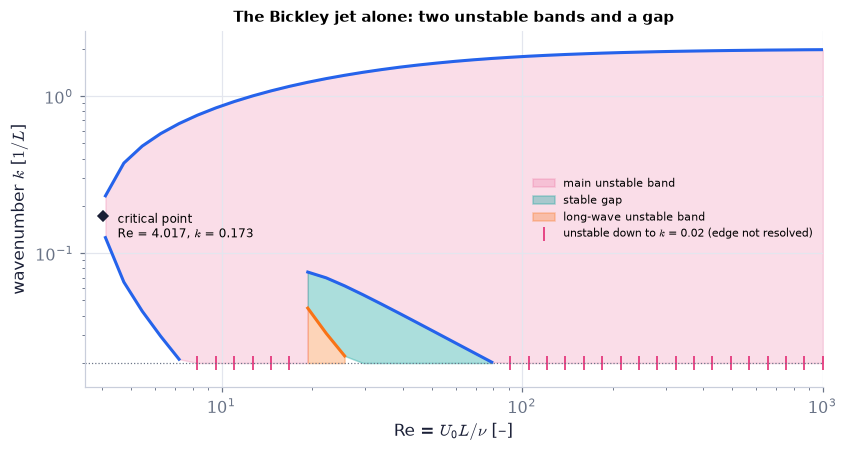

one band up to Re = 16.78; at Re = 19.32 the gap spans k = 0.0447 ... 0.0759
upper neutral wavenumber at Re = 1000: 1.976 (inviscid limit: 2)


In [119]:
bjl = read_curve("bickley_longwave")                               # the long-wave band of the jet (second public table, same Re values)
K0 = 0.02                                                          # the smallest wavenumber of the computation behind the tables [1/L]
Rej = bj["Re"]                                                     # Reynolds numbers of the table
unres = np.isnan(bj["k_lower"])                                    # NaN = the band reaches below K0: UNSTABLE there, lower edge not resolved
has_long = ~np.isnan(bjl["k_long_upper"])                          # where the upper edge of the long-wave band is resolved
gap = ~unres & (Rej > Rej[unres][0])                               # Re values with a stable gap under the main band (after the band has split)
fig, ax = plt.subplots(figsize=(7.6, 4.0))   # the figure and its panels
i_first = int(np.argmax(gap))                                      # first tabulated Re at which the gap exists
Re_f = np.insert(Rej, i_first, 0.999*Rej[i_first])                 # one extra point just left of it, so that the shading does not
lo_f = np.insert(np.where(unres, K0, bj["k_lower"]), i_first, K0)  # ... draw a slanted (invented) edge between two table rows:
up_f = np.insert(bj["k_upper"], i_first, bj["k_upper"][i_first])   # ... up to that row the band is shaded down to K0, as the table says
ax.fill_between(Re_f, lo_f, up_f, color=C_GROW, alpha=0.15, label="main unstable band")   # shade the area between two curves
ax.fill_between(Rej[gap], np.where(has_long, bjl["k_long_upper"], K0)[gap], bj["k_lower"][gap], color=C_DECAY, alpha=0.35, label="stable gap")   # shade the area between two curves
ax.fill_between(Rej[has_long], K0, bjl["k_long_upper"][has_long], color=C_SHEAR, alpha=0.30, label="long-wave unstable band")   # shade the area between two curves
ax.loglog(Rej, bj["k_upper"], color=C_BUOY)                        # upper neutral wavenumber of the main band
ax.loglog(Rej, bj["k_lower"], color=C_BUOY)                        # its lower edge where resolved (before the split, and as the top of the gap after it)
ax.loglog(Rej[has_long], bjl["k_long_upper"][has_long], color=C_SHEAR)   # upper edge of the long-wave band = bottom of the gap
ax.plot(Rej[unres], np.full(unres.sum(), K0), "|", color=C_GROW, ms=9, label="unstable down to $k$ = 0.02 (edge not resolved)")   # ticks: the instability reaches the smallest wavenumber computed
ax.plot(bcj["Re_c"], bcj["k_c"], "D", color=COLORS["ink"], ms=5)   # the critical point
ax.text(bcj["Re_c"]*1.12, bcj["k_c"]*0.72, f"critical point\nRe = {bcj['Re_c']:.3f}, $k$ = {bcj['k_c']:.3f}", fontsize=8)   # a label written on the plot
ax.axhline(K0, color=C_BASE, lw=0.8, ls=":")   # a reference line or band
ax.set(xlabel="Re = $U_0L/\\nu$ [–]", ylabel="wavenumber $k$ [$1/L$]", xlim=(3.5, 1000), ylim=(0.014, 2.6))   # axis labels (with units) and fixed ranges for this panel
ax.set_title("The Bickley jet alone: two unstable bands and a gap", fontsize=10)   # panel title — the message of this panel
ax.legend(fontsize=7, loc="center right")   # legend: one entry per curve
savefig(fig, "ch11", "c13_bickley_bands")   # keep a copy in outputs/ch11 and display
plt.show()   # display the figure
print(f"one band up to Re = {Rej[i_first - 1]:.2f}; at Re = {Rej[i_first]:.2f} the gap spans k = {bjl['k_long_upper'][i_first]:.4f} ... {bj['k_lower'][i_first]:.4f}")   # where the stable gap first appears in the table, and its two edges
print(f"upper neutral wavenumber at Re = {Rej[-1]:.0f}: {bj['k_upper'][-1]:.3f} (inviscid limit: 2)")   # viscosity matters less and less: the upper edge approaches the inviscid limit

**What does the code above do?**

1. Two public tables of ours: `os_neutral_bickley.csv` (the band that contains the fastest-growing wave: `k_lower`, `k_upper`)
   and `os_neutral_bickley_longwave.csv` (the long-wave band: `k_long_upper`). They were computed in a box that grows with the
   wavelength, max(40, 12/k) (`ch11.bickley_neutral_curve`), because a long wave decays slowly away from the jet.
2. `NaN` in `k_lower` means "the unstable band reaches below k = 0.02" — unstable, edge unknown; the cell fills such places
   down to the dotted line and marks them with ticks.
3. `fill_between` shades the three regions; the printed lines give where the gap first appears in the table and how close the
   upper branch has come to the inviscid neutral wavenumber 2 (R23).

**What you see.** The jet's stability map on logarithmic axes. Rose: the main unstable band, bounded above by the blue curve that rises toward k = 2. Orange: a second, long-wave unstable band at the bottom. Teal: a stable gap between the two. Small rose ticks along the dotted line k = 0.02: Reynolds numbers at which the instability reaches down to the smallest wavenumber computed — the true lower edge is somewhere below and is not resolved. The diamond is the critical point.

**How to read it.** Up to Re ≈ 17 there is one unstable band, and its lower edge drops out of the computed range almost at once: very long waves are unstable. Our reading of why (not a result of the book): a sinuous wave much longer than the jet is wide shifts the jet sideways almost as a whole, so it adds little strain, and the viscous damping of a wave, of order k²/Re, is small. A caution: for waves hundreds of jet widths long the parallel-flow model is itself questionable, because a real jet spreads over such a distance (note N109 makes the same point for the boundary layer). Then, between the two tabulated Reynolds numbers printed below, a stable gap opens *inside* the band and splits it in two: wavenumbers in the teal region decay, while longer and shorter waves both grow (from Re ≈ 19 the two bands are carried by two different modes). The gap slides to longer waves as Re rises and leaves the computed range near Re ≈ 80. The orange region ends near Re ≈ 27 only because its upper edge drops below k = 0.02 there: for Re ≳ 29.5 the long-wave band continues below the computed range — that is the edge of the computation, not the end of the band. Nowhere does a missing line mean 'stable': only the teal region and the white region outside the blue curve are.

**What would change if…** …we could compute to wavenumbers below 0.02 (it needs ever larger boxes, twelve wavelengths-over-2π wide): the rose ticks would be replaced by the true lower edge, and the gap could be followed beyond Re ≈ 80.

**Slider figure F7 — the one eigenvalue that crosses.** The Orr–Sommerfeld spectrum of plane Poiseuille flow at $k=1$ for a
range of Reynolds numbers.

In [120]:
def f7(Re):                                                        # the spectrum at k = 1 for one Reynolds number
    c = ch11.poiseuille_spectrum(1.0, Re, N=100)                   # all finite eigenvalues, sorted by c_i
    c = c[c.imag > -1.0]                                           # the part of the plane we show
    return {"spectrum": (c.real, c.imag), "least stable mode (TS wave)": (np.array([c[0].real]), np.array([c[0].imag])),   # all modes; the leading one
            "c_i = 0": (np.array([0.0, 1.0]), np.array([0.0, 0.0]))}                                     # the real axis: above it, growth

figF7 = slider_figure(f7, "Re", np.round(np.geomspace(1e3, 1e5, 8 if FAST else 16)), xlabel="c_r [U0]", ylabel="c_i [U0]",   # slider: Re (log-spaced)
                      title="Plane Poiseuille, k = 1: the TS eigenvalue crosses c_i = 0 between Re = 5000 and 6000",       # the message
                      xrange=(0, 1.05), yrange=(-1.0, 0.1), modes={"spectrum": "markers", "least stable mode (TS wave)": "markers"})   # fixed window
figF7.show()   # display the interactive slider figure

**What does the code above do?**

1. `ch11.poiseuille_spectrum(k, Re)` returns the whole (unfiltered) spectrum; the first entry is the least stable mode.
2. Drag Re up from 1000: the Y sharpens and the marked mode rises through the axis near Re ≈ 5800, then (far beyond 10⁴) sinks
   back — the two sides of the thumb at $k=1$.

📝 **Note.** **N99 [B]** **The two-stream shear layer** $U=U_0\tanh(y/L)$ (orange in panel (b)): unstable for $0<kL<k_u(\mathrm{Re})$, with $k_u\to1$ as
$\mathrm{Re}\to\infty$ and a critical Reynolds number of zero — viscosity is only a small correction to an inviscid instability.
The inviscid neutral mode at $kL=1$ has $c=0$ and $\phi=\mathrm{sech}(y/L)$.

In [121]:
ys = sp.symbols("y", real=True)                                     # cross-stream coordinate (in units of L)
Us, phis = sp.tanh(ys), sp.sech(ys)                                 # the tanh layer and the claimed neutral mode
print("Rayleigh residual for phi = sech y, k = 1, c = 0:", sp.simplify((Us - 0)*(sp.diff(phis, ys, 2) - phis) - sp.diff(Us, ys, 2)*phis))   # zero: sech y is an exact neutral mode of the tanh layer
for Re in (10.0, 100.0, 400.0):                                     # the stored upper neutral wavenumber at three Reynolds numbers
    print(f"  Re = {Re:5.0f}: unstable for k < {np.interp(np.log(Re), np.log(tl['Re']), tl['k_upper']):.3f}")   # viscosity trims the unstable band only slightly

Rayleigh residual for phi = sech y, k = 1, c = 0: 0
  Re =    10: unstable for k < 0.654
  Re =   100: unstable for k < 0.943
  Re =   400: unstable for k < 0.985


**What does the code above do?**

1. sympy confirms that $\phi=\mathrm{sech}\,y$ with $c=0$, $k=1$ satisfies Rayleigh's equation exactly (residual 0).
2. The stored viscous neutral curve: the upper neutral wavenumber rises toward 1 as Re grows.

📝 **Note.** **N100 [B]** **Plane Couette flow** is linearly stable at every Re (every Orr–Sommerfeld eigenvalue has $c_i<0$ on the grid below); in
experiments it still becomes turbulent at Reynolds numbers of a few hundred (based on half the wall-speed difference and half the
gap) through finite disturbances — named.

In [122]:
ks_c = (0.1, 0.5, 1.0, 2.0, 3.0)                                    # wavenumbers
Res_c = (1e2, 1e3, 1e4, 1e5, 1e6) if not FAST else (1e2, 1e4, 1e6)  # Reynolds numbers
ci = np.array([[ch11.couette_max_growth(k, Re) for Re in Res_c] for k in ks_c])   # leading c_i of plane Couette flow
print(np.round(ci, 4))   # leading growth indicator for each (k, Re): rows are k, columns Re
print("largest c_i on the grid:", round(ci.max(), 4), "-> every mode decays")   # negative everywhere: no growing wave in plane Couette flow

[[-0.9743 -0.2671 -0.1127 -0.0507 -0.0213]
 [-0.243  -0.147  -0.0649 -0.0294 -0.0043]
 [-0.2904 -0.1192 -0.0521 -0.0213 -0.0021]
 [-0.2528 -0.1002 -0.0425 -0.0107 -0.0011]
 [-0.2357 -0.0918 -0.0381 -0.0071 -0.0007]]
largest c_i on the grid: -0.0007 -> every mode decays


📝 **Note.** **N101 [C]** **Pipe flow** (named): linearly stable too; it becomes turbulent through finite disturbances whose threshold depends on how quiet
the inlet is; recent work describes the transition as a "chaotic saddle" (Eckhardt et al. 2007). Pointer: Ch. 12.

📝 **Note.** **N102 [B]** **Table 11.1, recomputed.** Our own critical Reynolds numbers next to published benchmarks, each with its length scale. The
book's rounded column is not reproduced.

In [123]:
import pandas as pd                                                 # tables: pd.DataFrame(list_of_dicts) shows rows and columns
pd.set_option("display.width", 200)                                 # let the table use the full width
tab11 = pd.DataFrame(ch11.table_11_1())                             # one row per flow (stored critical points, sources cited)
print(tab11[["flow", "U", "length_scale", "Re_c_ours", "k_c_ours", "benchmark", "source"]].to_string(index=False))   # our recomputed table of critical Reynolds numbers, with sources

            flow          U        length_scale   Re_c_ours  k_c_ours  benchmark                                                                   source
   jet (Bickley) sech²(y/L) L (jet width scale)    4.016997  0.172834       4.00                                                Tatsumi & Kakutani (1958)
     shear layer  tanh(y/L)                   L    0.000000  0.000000       0.00                                                Betchov & Szewczyk (1963)
         Blasius      f′(η)                  δ*  519.060118  0.303771     519.20 Thomas, via Gallagher, Griffiths & Stephen (2016); Jordinson (1970): 520
plane Poiseuille 1 − (y/L)²      L = half-width 5772.221796  1.020545    5772.22                                                            Orszag (1971)
            pipe 1 − (r/R)²                   R         inf       NaN        inf                                                        not computed here
   plane Couette        y/L        L = half-gap         inf       NaN       

**What does the code above do?**

`ch11.table_11_1()` returns one dictionary per flow — jet, shear layer, Blasius, plane Poiseuille, pipe, plane Couette — with our
critical Reynolds number and wavenumber, the published benchmark and its source; `pd.DataFrame` turns the list into a table.
Infinite means "linearly stable at every Re".

📝 **Note.** **N103 [C]** **A caveat on a zero critical Reynolds number** (named): the mixing layer's zero assumes a parallel flow; a spreading mixing layer
has a finite one (Bhattacharya et al. 2006).

**What would change if…** …we want to know *why* viscosity can feed the wave? Follow the wave's kinetic energy: what produces it and what dissipates it —
C14.

### 🧩 The disturbance kinetic-energy equation $\frac{d}{dt}\int\tfrac12u_i^2\,dV=-\int u_iu_j\frac{\partial U_i}{\partial x_j}dV-\Lambda$ (11.88) `C14`

*The question:* Where does a growing wave get its energy, and how can viscosity help it?

#### The problem in plain words

A growing wave gains kinetic energy; something must supply it. The only reservoir is the mean flow's shear. And something always
takes energy away: viscous dissipation. Bookkeeping the two tells us when a wave grows — and reveals the trick by which viscosity,
a pure damper, can make the supply larger than the loss.

#### The idea

```
d/dt ∫ ½(u² + v²) dV   =   −∫ uv dU/dy dV      −   Λ
     wave's energy          PRODUCTION            DISSIPATION ν∫(∂u_i/∂x_j)² ≥ 0
                            Reynolds stress −uv working on the shear U′
u and v exactly out of phase (u = sin, v = cos): mean of uv = 0 → NO production (inviscid, no inflection)
viscosity near the wall tilts the phase of v against u → mean uv < 0 where U′ > 0 → production > 0
```

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **fundamental theorem of calculus** — $\int_a^bF'(x)\,dx=F(b)-F(a)$. *(Ch. 2, P84)*
- **mean of a product of real parts** — for two waves with complex amplitudes $\hat a,\hat b$ the average of their product over a wavelength is $\tfrac12\mathrm{Re}(\hat a\hat b^*)$ — zero when they are 90° out of phase. *(Ch. 7, P178)*

> 📎 **Primer — the integral of an x-derivative of a periodic function over one period is zero.** `P273` · If $f(x)$ repeats every $\lambda$, then $\int_0^\lambda\frac{\partial f}{\partial x}dx=f(\lambda)-f(0)=0$ (the fundamental theorem
of calculus, Ch. 2 P84). Averaged over a whole number of wavelengths, every term of the form $\partial(\dots)/\partial x$
disappears — the two ends of the control volume cancel.

In [124]:
import numpy as np                                    # arrays
x = np.linspace(0, 2*np.pi, 2001)                     # one full period
f = np.sin(3*x)**2 + np.cos(x)                        # a function that repeats every 2 pi
print(np.trapezoid(np.gradient(f, x), x))             # ~0: the integral of df/dx over a period (to discretisation error)

1.7763568394002505e-15


📝 **Note.** **N128 [B]** **The starting line (Exercise 11.13):** the disturbed Navier–Stokes equation in index form (Ch. 2: a repeated index is summed),
$\frac{\partial}{\partial t}(U_i+u_i)+(U_j+u_j)\frac{\partial}{\partial x_j}(U_i+u_i)=-\frac1\rho\frac{\partial}{\partial
x_i}(P+p)+\nu\frac{\partial^2}{\partial x_j\partial x_j}(U_i+u_i)$ (11.96), with $U_i$, $P$ the basic flow and $u_i$, $p$ the
disturbance.

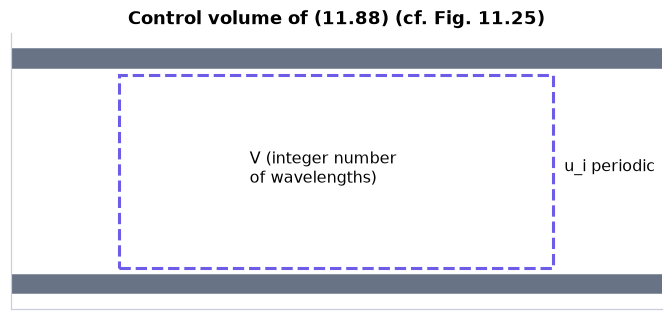

In [125]:
fig, ax = plt.subplots(figsize=(6.0, 2.8))   # the figure and its panels
cv_sketch(ax)                                                      # drawing only: the control volume between the walls
plt.show()   # display the figure

**What you see.** The control volume used in the derivation: a box between the two walls, a whole number of wavelengths long.

**How to read it.** Nothing crosses the walls (no slip), and whatever leaves through one end enters through the other (periodicity, P273): only what happens *inside* the box can change the wave's energy.

**What would change if…** …the box were not a whole number of wavelengths long: the two ends would no longer cancel and the budget would not close.

#### 🧮 Derivation — The disturbance kinetic-energy equation and its 2-D form `D23` ★★ (Eq. 11.88: $\frac d{dt}\int\tfrac12u_i^2\,dV=-\int u_iu_j\frac{\partial U_i}{\partial x_j}dV-\Lambda$)

**What we want to show.** Derive how a disturbance's kinetic energy changes (the book leaves it to Exercise 11.13): what produces it, what destroys it.

**Assumptions.** Incompressible (∂_jU_j = ∂_ju_j = 0); steady basic flow; constant ν; u = 0 on walls or far away; a box of an integer number of wavelengths (Fig. 11.25). Notation in the steps: ∂_j ≡ ∂/∂x_j, summation over repeated indices.

**The plan.**

1. Subtract the basic flow's equation.
2. Multiply by u_i.
3. Turn every term that can be into a divergence.
4. Integrate over a box of whole wavelengths: the divergences vanish.

**Tools we use** (each explained before this point): Index notation and the divergence theorem (Ch. 2) · product rule (P38) · the integral of a periodic x-derivative (P273)

**We start from**

$$ \frac{\partial}{\partial t}(U_i+u_i)+(U_j+u_j)\frac{\partial}{\partial x_j}(U_i+u_i)=-\frac1\rho\frac{\partial}{\partial x_i}(P+p)+\nu\frac{\partial^2} {\partial x_j\partial x_j}(U_i+u_i)\ \text{(11.96)} $$

*In words:* Navier–Stokes for basic flow plus disturbance, in index form.

---

**Step 1 of 12 — Subtract the basic-flow equation.**

$$ \partial_tu_i+U_j\partial_ju_i+u_j\partial_jU_i+u_j\partial_ju_i=-\frac1\rho\partial_ip+\nu\partial_j\partial_ju_i $$

- *Why we can do this:* U, P satisfy (11.96), $\frac{\partial}{\partial t}(U_i+u_i)+(U_j+u_j)\frac{\partial}{\partial x_j}(U_i+u_i)=-\frac1\rho\frac{\partial}{\partial x_i}(P+p)+\nu\frac{\partial^2}{\partial x_j\partial x_j}(U_i+u_i)$ without u, p (steady). We keep the u_j∂_ju_i term — it will vanish on its own.
- *In words:* the exact disturbance equation.

---

**Step 2 of 12 — Multiply by u_i.**

$$ \partial_t\big(\tfrac12u_iu_i\big)+u_iU_j\partial_ju_i+u_iu_j\partial_jU_i+u_iu_j\partial_ju_i=-\frac1\rho u_i\partial_ip+\nu u_i\partial_j\partial_ju_i $$

- *Why we can do this:* u_i∂_tu_i = ∂_t(½u_iu_i) (chain rule). Multiplying a momentum equation by the velocity turns it into an energy equation — the same move as for Bernoulli in Ch. 4.
- *In words:* an equation for the disturbance's kinetic energy per unit mass.

---

**Step 3 of 12 — Rewrite the advection by U.**

$$ u_iU_j\partial_ju_i=\partial_j\big(\tfrac12u_iu_iU_j\big) $$

- *Why we can do this:* product rule: ∂_j(½u_i²U_j) = U_j∂_j(½u_i²) + ½u_i²∂_jU_j, and ∂_jU_j = 0.
- *In words:* the base flow only carries energy around.

---

**Step 4 of 12 — Rewrite self-advection.**

$$ u_iu_j\partial_ju_i=\partial_j\big(\tfrac12u_iu_iu_j\big) $$

- *Why we can do this:* the same move with ∂_ju_j = 0.
- *In words:* the disturbance moves its own energy around.

---

**Step 5 of 12 — Rewrite the pressure work.**

$$ u_i\partial_ip=\partial_i(pu_i) $$

- *Why we can do this:* product rule and ∂_iu_i = 0.
- *In words:* pressure only moves energy.

---

**Step 6 of 12 — Split the viscous term.**

$$ \nu u_i\partial_j\partial_ju_i=\partial_j(\nu u_i\partial_ju_i)-\nu(\partial_ju_i)(\partial_ju_i) $$

- *Why we can do this:* product rule backwards. The first piece is a divergence (it will integrate to zero); the second is a sum of squares with a minus sign — a pure loss.
- *In words:* viscous transport plus a loss.

---

**Step 7 of 12 — Collect.**

$$ \partial_t\big(\tfrac12u_i^2\big)=-u_iu_j\partial_jU_i-\nu(\partial_ju_i)^2-\partial_j\Big[\tfrac12u_i^2U_j+\tfrac12u_i^2u_j+\frac{pu_j}\rho-\nu u_i\partial_ju_i\Big] $$

- *Why we can do this:* steps 2–6. Every term has now been sorted into three boxes: a source, a sink, and a divergence that only moves energy around.
- *In words:* production + loss + transport.

---

**Step 8 of 12 — Integrate over the fixed box.**

$$ \frac d{dt}\int\tfrac12u_i^2dV=-\int u_iu_j\partial_jU_i\,dV-\nu\int(\partial_ju_i)^2dV-\oint[\dots]_jn_j\,dA $$

- *Why we can do this:* the box does not move, so d/dt passes outside; Gauss's divergence theorem (Ch. 2) turns the bracket into a surface integral.
- *In words:* only the surface can carry transport terms.

---

**Step 9 of 12 — Remove the walls.**

$$ u_i=0\ \text{on the walls (or far away)} $$

- *Why we can do this:* no slip (or decay) makes every term of the bracket vanish there.
- *In words:* nothing crosses the walls.

---

**Step 10 of 12 — Remove the ends.**

$$ \oint_{\text{ends}}=0 $$

- *Why we can do this:* the box spans an integer number of wavelengths: the bracket repeats, and the outward normals are opposite, so the two ends cancel (P273).
- *In words:* what flows out at one end flows in at the other.

---

**Step 11 of 12 — Name the dissipation.**

$$ \frac d{dt}\int\tfrac12u_i^2dV=-\int u_iu_j\frac{\partial U_i}{\partial x_j}dV-\Lambda,\ \ \Lambda=\nu\int\Big(\frac{\partial u_i} {\partial x_j}\Big)^2dV\ge0\ \text{(11.88)} $$

- *Why we can do this:* steps 8–10. The surface integral has vanished, and the remaining viscous integral is a sum of squares, hence never negative.
- *In words:* production by the Reynolds stress against the shear, minus viscous dissipation.

---

**Step 12 of 12 — Specialise to 2-D shear.**

$$ \frac d{dt}\int\tfrac12(u^2+v^2)dV=-\int uv\frac{\partial U}{\partial y}dV-\Lambda $$

- *Why we can do this:* with U = (U(y), 0, 0) only ∂U_1/∂x_2 = U′ is nonzero, so only u_1u_2∂_2U_1 = uvU′ survives.
- *In words:* the 2-D form (p. 520).

---

**Result**

$$ \begin{array}{l}\frac d{dt}\int\tfrac12u_i^2\,dV=-\int u_iu_j\frac{\partial U_i}{\partial x_j}dV-\Lambda\qquad\text{(11.88)} \\[4pt] \text{2-D shear flow: }\frac d{dt}\int\tfrac12(u^2+v^2)\,dV=-\int uv\frac{\partial U}{\partial y}dV-\Lambda,\ \ \Lambda=\nu\int\Big(\frac{\partial u_i}{\partial x_j}\Big)^2dV\ge0\end{array} $$

*In words:* a disturbance grows only if its Reynolds stress −⟨uv⟩ works against the mean shear faster than viscosity dissipates it.

**What it means.** The production term −⟨uv⟩U′ is the turbulence production of Ch. 12; viscosity can change the u–v phase so that production becomes positive (C14). Fails if the box is not an integer number of wavelengths or the walls move.

**Check it.** Units: m⁵/s³ per unit density on every term ✓. Computed TS mode at Re = 10⁴, k = 1: dE/dt = P − Λ to 1e-12, P/Λ = 1.616 ✓. The check cell below: `ch11.energy_equation_sympy()["residual"] == 0`.

In [126]:
en = ch11.energy_equation_sympy()                     # D23 with sympy on generic 2-D fields: multiply by u_i, sort into the three boxes
print("residual of the energy identity:", en["residual"])   # 0: steps 2-7 are exact
for t in en["terms"]:                                 # the engine's own names for the terms
    print("  -", t)   # one term of the energy equation per line

residual of the energy identity: 0
  - ∂t(½u_iu_i)
  - divergence of energy flux (advection, pressure work, viscous diffusion)
  - u_iu_j ∂U_i/∂x_j (minus the production)
  - ν(∂_ju_i)² (dissipation Λ)


> ⚠️ **Common confusion (traps in `D23`):** Forgetting ∂_jU_j = 0 in step 3; the sign of the dissipation (it is a loss); claiming the self-advection term contributes (it is a pure divergence).

📝 **Note.** **N104 [B]** **The 2-D form and what it says:** $\frac d{dt}\int\tfrac12(u^2+v^2)\,dV=-\int uv\frac{\partial U}{\partial y}dV-\Lambda$. The
product $uv$ averaged over a wavelength (the *Reynolds shear stress* of Ch. 12, up to a factor $-\rho$) vanishes when $u$ and $v$
are 90° out of phase (Ch. 7 P178). For an inviscid, inflection-free profile the phases are such that the wave cannot take energy
from the shear; viscosity changes the phase relation near the walls and the critical layer so that $-\langle uv\rangle U'$
integrates to a positive number larger than the dissipation — the destabilising mechanism.

#### ✏️ Tiny example: why the phase matters

Average over one period (Ch. 7 P178: the mean of a product of two sines is half the cosine of their phase difference).

1. $u=\sin t$, $v=\cos t$ (90° apart): mean of $uv=\tfrac12\sin2t$ is 0 — no production.
2. $u=\sin t$, $v=-\sin(t-\pi/6)$ (tilted by 30° from anti-phase): mean $uv=-\tfrac12\cos(\pi/6)=-0.433$; with $U'=+1$ the
   production $-\langle uv\rangle U'=+0.433>0$.
3. For the TS wave at $\mathrm{Re}=10^4$, $k=1$ the code below finds production/dissipation ≈ 1.62: production beats dissipation
   by 62 %, so $dE/dt=2kc_iE>0$.
4. At $\mathrm{Re}=5000$ the same mode has a ratio of about 0.77: it decays.

In [127]:
budgets = {}                                                        # the budget at two Reynolds numbers
for Re in (1e4, 5e3):   # repeat the indented lines for each item listed
    m = ch11.os_mode(1.0, Re, U, Upp)                               # leading Orr-Sommerfeld mode at k = 1: c, nodes y, phi, u_hat, v_hat
    b = ch11.disturbance_energy_budget(1.0, m["c"], m["phi"], m["y"], -2*m["y"], Re)   # (11.88) averaged over a wavelength; U' = -2y
    budgets[Re] = (m, b)   # keep the mode and its budget for the figure and the animation
    print(f"Re = {Re:.0f}: c = {m['c']:.5f}")   # the wave speed: positive imaginary part at 10^4, negative at 5000
    print(f"   E = {b['E']:.5f}, dE/dt = 2 k c_i E = {b['dEdt']:+.6f}, production P = {b['production']:.6f}, dissipation = {b['dissipation']:.6f}")   # the wave's energy, its rate of change, what the shear supplies and what viscosity removes
    print(f"   P - dissipation - dE/dt = {b['residual']:.1e},  P/dissipation = {b['ratio']:.3f}")   # the budget closes; a ratio above 1 means the wave grows

Re = 10000: c = 0.23753+0.00374j
   E = 0.19417, dE/dt = 2 k c_i E = +0.001452, production P = 0.003808, dissipation = 0.002356
   P - dissipation - dE/dt = -4.5e-12,  P/dissipation = 1.616


Re = 5000: c = 0.26813-0.00175j
   E = 0.21364, dE/dt = 2 k c_i E = -0.000748, production P = 0.002440, dissipation = 0.003188
   P - dissipation - dE/dt = -2.4e-11,  P/dissipation = 0.765


**What does the code above do?**

1. `ch11.os_mode(k, Re, U, Upp)` returns the leading mode: `c`, the nodes `y`, `phi`, and the velocity amplitudes
   $\hat u=\phi'$ (`u_hat`) and $\hat v=-\mathrm ik\phi$ (`v_hat`) — §11.8's convention.
2. `ch11.disturbance_energy_budget(k, c, phi, y, Up, Re)` evaluates the wavelength-averaged budget with Clenshaw–Curtis weights
   (P271): $E=\tfrac14\int(\lvert\hat u\rvert^2+\lvert\hat v\rvert^2)dy$, production $P=-\tfrac12\int\mathrm{Re}(\hat u\hat v^*)U'dy$,
   dissipation $\Lambda$, and $dE/dt=2kc_iE$.
3. The closing check — $dE/dt=P-\Lambda$ to about 10⁻¹² — is independent of the eigen-solve: the budget really balances.
4. $P/\Lambda=1.62$ at $\mathrm{Re}=10^4$ (grows), 0.77 at 5000 (decays).

In [128]:
m, b = budgets[1e4]                                                 # the growing mode
Cheb = np.polynomial.chebyshev.Chebyshev                            # numpy's Chebyshev series (re-interpolation of the nodal values)
yf = np.linspace(-1, 1, 4001)                                       # a fine uniform grid across the channel
deg = len(m["y"]) - 1                                               # the polynomial degree that passes through all nodes
uh = Cheb.fit(m["y"], m["u_hat"].real, deg)(yf) + 1j*Cheb.fit(m["y"], m["u_hat"].imag, deg)(yf)   # u-hat on the fine grid
vh = Cheb.fit(m["y"], m["v_hat"].real, deg)(yf) + 1j*Cheb.fit(m["y"], m["v_hat"].imag, deg)(yf)   # v-hat on the fine grid
P_mine = -0.5*np.trapezoid(np.real(uh*np.conj(vh))*(-2*yf), yf)    # P = -(1/2) int Re(u-hat conj(v-hat)) U' dy with U' = -2y
duh, dvh = np.gradient(uh, yf), np.gradient(vh, yf)                 # their y-derivatives by finite differences
L_mine = np.trapezoid(abs(uh)**2 + abs(vh)**2 + abs(duh)**2 + abs(dvh)**2, yf)/(2*1e4)   # dissipation with k = 1
assert np.isclose(P_mine, b["production"], rtol=1e-4) and np.isclose(L_mine, b["dissipation"], rtol=1e-3)   # check: stops with an error if it fails
print(f"production by trapezoid: {P_mine:.6f} (library {b['production']:.6f}); dissipation: {L_mine:.6f} (library {b['dissipation']:.6f})")   # plain trapezoid integration gives the same budget

production by trapezoid: 0.003808 (library 0.003808); dissipation: 0.002356 (library 0.002356)


**What does the code above do?**

1. `np.polynomial.chebyshev.Chebyshev.fit(y, values, deg)` builds the polynomial through the nodal values, so the mode can be
   evaluated on a fine uniform grid (real and imaginary parts separately).
2. Production and dissipation with the plain trapezoid rule (Ch. 9 P203) and `np.gradient` agree with the library's
   Clenshaw–Curtis values.

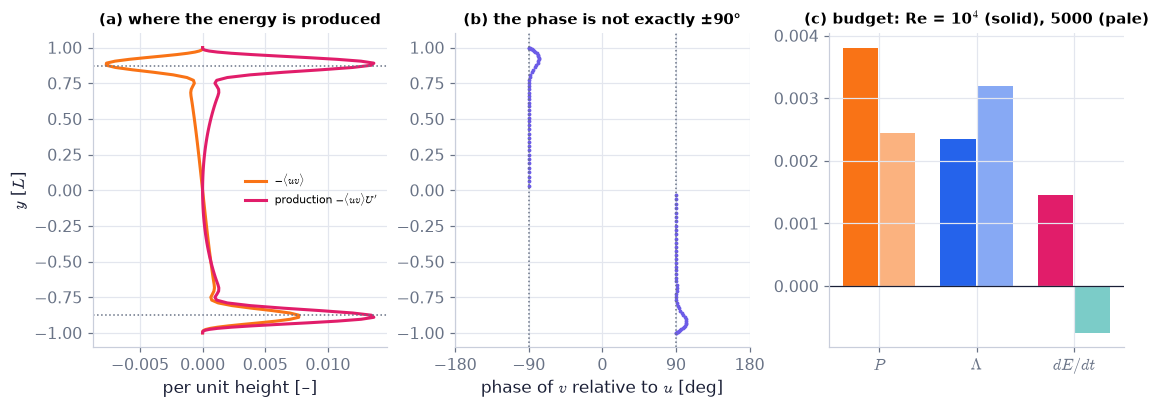

critical layers at y = +-0.873; largest departure of the phase from 90 degrees near the walls: 12 degrees


In [129]:
fig, axs = plt.subplots(1, 3, figsize=(10.2, 3.6))   # the figure and its panels
m, b = budgets[1e4]   # the growing wave and its budget
y_c = np.sqrt(1 - m["c"].real)                                     # critical layers: U(y) = 1 - y^2 = c_r
axs[0].plot(-b["uv"], b["y"], color=C_SHEAR, label=r"$-\langle uv\rangle$")   # the Reynolds stress: nonzero only near the walls
axs[0].plot(b["production_density"], b["y"], color=C_GROW, label=r"production $-\langle uv\rangle U'$")   # where the wave takes energy from the mean shear
for s in (-1, 1):   # repeat the indented lines for each item listed
    axs[0].axhline(s*y_c, color=C_BASE, ls=":", lw=1)                # the two critical layers, where the flow moves at the wave speed
axs[0].set(xlabel="per unit height [–]", ylabel="$y$ [$L$]")   # axis labels (with units) and fixed ranges for this panel
axs[0].set_title("(a) where the energy is produced", fontsize=10)   # panel title — the message of this panel
axs[0].legend(fontsize=7, loc="center right")   # legend: one entry per curve
ph = np.degrees(np.angle(np.exp(1j*b["phase_uv"])))                # phase of v relative to u, wrapped to (-180, 180] degrees
ok = np.abs(b["y"][1:-1]) > 0.03                                   # leave out the centreline, where the amplitudes vanish and the phase is undefined
axs[1].plot(ph[1:-1][ok], b["y"][1:-1][ok], ".", ms=3, color=C_NEUT)   # the phase between v and u at each height
for x0 in (-90, 90):   # repeat the indented lines for each item listed
    axs[1].axvline(x0, color=C_BASE, ls=":", lw=1)   # a reference line or band
axs[1].set(xlabel="phase of $v$ relative to $u$ [deg]", xlim=(-180, 180), xticks=[-180, -90, 0, 90, 180])   # axis labels (with units) and fixed ranges for this panel
axs[1].set_title("(b) the phase is not exactly ±90°", fontsize=10)   # panel title — the message of this panel
for j, Re in enumerate((1e4, 5e3)):   # repeat the indented lines for each item listed
    bb = budgets[Re][1]   # the budget at this Reynolds number
    vals = [bb["production"], bb["dissipation"], bb["dEdt"]]   # supply, loss and their difference
    axs[2].bar(np.arange(3) + 0.38*j - 0.19, vals, 0.36, color=[C_SHEAR, C_BUOY, C_GROW if bb["dEdt"] > 0 else C_DECAY], alpha=1.0 if j == 0 else 0.55)   # bars
axs[2].set_xticks(range(3), ["$P$", r"$\Lambda$", "$dE/dt$"])   # axis range / scale chosen so the feature discussed below is visible
axs[2].axhline(0, color=COLORS["ink"], lw=0.8)   # a reference line or band
axs[2].set_title("(c) budget: Re = 10$^4$ (solid), 5000 (pale)", fontsize=10)   # panel title — the message of this panel
savefig(fig, "ch11", "c14_budget")   # keep a copy in outputs/ch11 and display
plt.show()   # display the figure
near_wall = (np.abs(b["y"]) > 0.6) & (np.abs(b["y"]) < 0.999)        # the two bands between the walls and the middle of the channel
print(f"critical layers at y = +-{y_c:.3f}; largest departure of the phase from 90 degrees near the walls: {np.max(np.abs(np.abs(ph[near_wall]) - 90)):.0f} degrees")   # where the flow moves at the wave speed, and how far the phase is from a quarter cycle

**What does the code above do?**

1. The budget dictionary also holds profiles: `uv` ($\langle uv\rangle$ at each $y$), `production_density`, and `phase_uv` (the
   phase of $\hat v$ relative to $\hat u$ in radians).
2. `np.angle(np.exp(1j*phase))` wraps a phase into (−180°, 180°].

**What you see.** (a) Across the channel: the Reynolds stress (orange) and the local production (rose) of the growing wave; dotted lines mark the critical layers, where the flow speed equals the wave speed. (b) The phase between $v$ and $u$ at each height. (c) Bars of production, dissipation and their difference for two Reynolds numbers.

**How to read it.** Production is concentrated in two thin bands around the critical layers, near each wall. There the phase departs from ±90° (by the number of degrees printed) — and where it does, the stress is nonzero. In the middle of the channel the phase is ±90° and nothing is produced. At Re = 10⁴ production exceeds dissipation and $dE/dt>0$ (rose bar); at 5000 the pale bars show production below dissipation and $dE/dt<0$ (teal).

**What would change if…** …the phase were exactly ±90° everywhere (the inviscid, inflection-free case): the orange curve would vanish and the wave could only decay.

**Animation A4 — the Tollmien–Schlichting wave.** The growing mode at $\mathrm{Re}=10^4$, $k=1$: perturbation stream function
(colour) travelling at $c_r\approx0.24$ under the parabolic flow, with the Reynolds-stress profile beside it.

In [130]:
nf = 14 if FAST else 18                                            # number of frames
m, b = budgets[1e4]                                                # the growing mode and its budget
xa = np.linspace(0, 4*np.pi, 90)                                   # two wavelengths in x [L]
period = 2*np.pi/(1.0*m["c"].real)                                 # time for the wave to travel one wavelength [L/U0]
tA4 = np.linspace(0, period, nf)                                   # one period
f0 = ch11.ts_wave_fields(xa, m["y"], 0.0, 1.0, m["c"], m["phi"], m["u_hat"], amp=0.05)   # real fields at t = 0
vmax = 1.15*np.max(np.abs(f0["psi"]))                              # fixed colour range
fig, (a, a2) = plt.subplots(1, 2, figsize=(8.6, 3.0), gridspec_kw={"width_ratios": [3, 1]}, sharey=True)   # the figure and its panels
mesh = a.pcolormesh(xa, m["y"], f0["psi"], cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")   # a colour map of the field
a.set(xlabel="$x$ [$L$]", ylabel="$y$ [$L$]")   # axis labels (with units) and fixed ranges for this panel
ttl = a.set_title("", fontsize=9)   # the panel's title: what this panel shows
a2.plot(-b["uv"], b["y"], color=C_SHEAR)   # the Reynolds stress of this wave across the channel
a2.set(xlabel=r"$-\langle uv\rangle$")   # axis labels (with units) and fixed ranges for this panel
a2.set_title(f"P/Λ = {b['ratio']:.2f}", fontsize=9)   # panel title — the message of this panel

def update(i):                                                     # frame i: time tA4[i]
    f = ch11.ts_wave_fields(xa, m["y"], tA4[i], 1.0, m["c"], m["phi"], m["u_hat"], amp=0.05)   # the wave moved and grew a little
    mesh.set_array(f["psi"].ravel())   # move the drawn data to this frame's values
    ttl.set_text(f"TS wave, t = {tA4[i]:5.1f} L/U0: amplitude x {np.exp(m['c'].imag*tA4[i]):.3f}")   # update the title text for this frame
    return mesh, ttl   # the values for this call

show_animation(animate(update, frames=nf, fig=fig, interval=130), player="video", dpi=60)   # render the frames and show the animation
print(f"one period = {period:.1f} L/U0; growth over one period: factor {np.exp(1.0*m['c'].imag*period):.3f}")   # in one period the wave moves one wavelength and grows by ten per cent

one period = 26.5 L/U0; growth over one period: factor 1.104


**What does the code above do?**

1. `ch11.ts_wave_fields(x, y, t, k, c, phi, phi_y, amp)` returns the real disturbance fields of the mode at time $t$: `psi`, `u`,
   `v` on the $(y,x)$ grid.
2. Over one period the pattern slides one wavelength downstream and its amplitude grows by about 10 %.

**What you see.** Cells of the disturbance stream function sliding downstream; near each wall the cells are tilted — they lean against the shear. Beside them, the Reynolds-stress profile.

**How to read it.** The tilt is the visible sign of a nonzero Reynolds stress: fluid moving away from the wall carries a deficit of $x$-velocity. Where the cells lean against the mean shear, the wave takes energy from the mean flow.

**What would change if…** …$k=0.6$ (outside the thumb): the tilt weakens and the wave decays.

📝 **Note.** **N125 [C]** **With stratification (Exercise 11.10, named):** the budget gains the available potential energy,
$\tfrac12\frac d{dt}\int\big(u^2+w^2+\frac{g^2\rho^2}{\rho_0^2N^2}\big)dV=-\int uw\frac{\partial U}{\partial z}dV$ — the shear's
production now has to lift fluid too (C09's energy view; `ch11.stratified_energy_budget`). Pointer: available potential energy in
Ch. 13.

#### 🎮 Interactive: How can viscosity make a channel flow unstable?

**Why interactive rather than a static figure:** Clicking a point (Re, k) on the neutral-curve map shows that Tollmien–Schlichting mode travelling over the profile, its
production/dissipation bars and the phase between $u$ and $v$; crossing the curve flips the balance. Switching flows recomputes
the Table 11.1 family row by row, and the oblique slider applies Squire's map live.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Preset 'Orszag (Re = 10⁴, k = 1)': read c ≈ 0.2375 + 0.0037i and P/Λ ≈ 1.6.
- Drag Re down through 5772 at k = 1.02: the bars flip when the dot leaves the thumb.
- Set the oblique angle to 30°: the effective Re drops by cos 30° and the 3-D wave falls outside the curve (Squire).

In [131]:
show_viz("ch11", "orr_sommerfeld_neutral_curve")   # full-width explainer; ⤢ Full screen for more room

[explainer ch11/orr_sommerfeld_neutral_curve]

**What would change if…** …the wave keeps growing? Its own Reynolds stress starts to change the mean flow it feeds on — the linear theory's end,
§11.12–11.13.

---

## 11.11 Experimental Verification of Boundary-Layer Instability

**What is this section about?** The Blasius boundary layer on a flat plate (Ch. 9) is nearly parallel, so the Orr–Sommerfeld
machinery applies to it as an approximation. Its neutral curve was computed long before anyone saw a Tollmien–Schlichting wave; a
famous wind-tunnel experiment then confirmed it. (These notes continue `C13`.)

📝 **Note.** **N105 [B]** **C13 (continued). Tollmien's stand-in for Blasius**: a piecewise profile in $\eta=y/\delta$ — linear near the wall, $a\eta$; a
parabola reaching 1 with zero slope at $\eta=1$, $1-b(1-\eta)^2$; then 1 — with zero curvature at the wall like Blasius. We fix
the breakpoint $\eta_1=0.2$ ourselves and get the coefficients from continuity of value and slope: $a=2/(1+\eta_1)$,
$b=1/(1-\eta_1^2)$.

> ⚠️ **slip #6 — the book prints** the middle branch as $1-b[1-(y/\delta)^2]$ — the square inside the bracket; that branch jumps at the breakpoint **; the correct form is** $1-b(1-y/\delta)^2$ — with the square outside, value and slope match the linear branch.

{'a': 1.6667, 'b': 1.0417, 'eta1': 0.2} | jump of the printed form at the breakpoint: 0.333


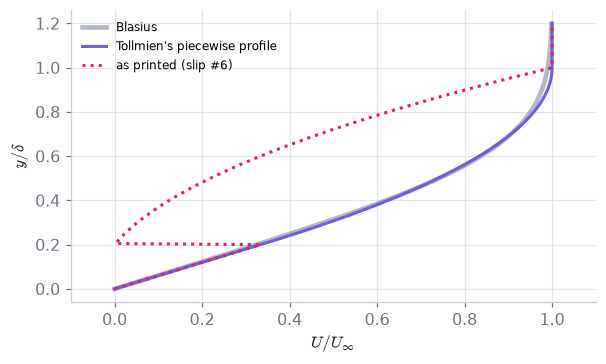

In [132]:
co = ch11.tollmien_coefficients()                                   # a and b from continuity at our breakpoint eta_1 = 0.2
eta = np.linspace(0, 1.2, 241)                                      # y/delta
eB = np.linspace(0, 1.2*4.91, 241)                                  # the same heights in Blasius' variable (delta = 99 % thickness = 4.91)
fB = BL.blasius_profile(eB)[1]                                      # Blasius u/U = f'(eta) (Ch. 9)
jump = ch11.tollmien_profile(np.array([0.2 - 1e-6, 0.2 + 1e-6]), printed=True)   # the printed middle branch on both sides of the breakpoint
print({n: round(v, 4) for n, v in co.items()}, "| jump of the printed form at the breakpoint:", round(abs(jump[1] - jump[0]), 3))   # the two coefficients from continuity, and the jump of the printed form
fig, ax = plt.subplots(figsize=(5.4, 3.2))   # the figure and its panels
ax.plot(fB, eta, color=C_BASE, lw=3, alpha=0.5, label="Blasius")   # grey: the exact Blasius profile
ax.plot(ch11.tollmien_profile(eta), eta, color=C_NEUT, label="Tollmien's piecewise profile")   # Tollmien's piecewise stand-in: straight, then a parabola, then uniform
ax.plot(ch11.tollmien_profile(eta, printed=True), eta, ":", color=C_GROW, label="as printed (slip #6)")
ax.set(xlabel="$U/U_\\infty$", ylabel="$y/\\delta$", xlim=(-0.1, 1.1))   # axis labels (with units) and fixed ranges for this panel
ax.legend(fontsize=8)   # legend: one entry per curve
plt.show()   # display the figure

**What does the code above do?**

1. `ch11.tollmien_coefficients()` gives $a=1.6667$, $b=1.0417$ for $\eta_1=0.2$; `ch11.tollmien_profile(eta)` the profile.
2. The purple curve follows Blasius (grey) closely; the dotted curve is the printed form, which jumps by about 0.33 at the
   breakpoint — it cannot be a velocity profile.

📝 **Note.** **N106 [C]** **C13 (continued). Seen at last** (named): TS waves stayed undetected until Schubauer & Skramstad (1947) excited them with a
vibrating ribbon in a very quiet wind tunnel and measured them with hot wires; their growth and decay matched the computed neutral
curve.

📝 **Note.** **N107 [B]** **C13 (continued). The Blasius neutral curve in frequency**: experiments fix the frequency $\omega$ of the ribbon, so the curve
is drawn as the dimensionless frequency $F=\omega\nu/U_\infty^2=kc_r/\mathrm{Re}_{\delta^*}$ against
$\mathrm{Re}_{\delta^*}=U_\infty\delta^*/\nu$ ($\delta^*$ the displacement thickness, Ch. 9); a wave of fixed $F$ travelling
downstream ($\mathrm{Re}_{\delta^*}$ rising like $\sqrt x$) enters the curve, grows, and leaves it.

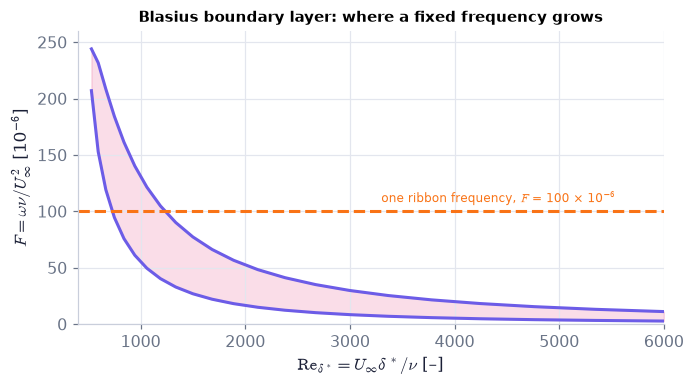

a wave with F = 100e-6 grows from Re = 732 to Re = 1238


In [133]:
bF = ch11.blasius_neutral_curve(in_frequency=True)                  # stored Blasius neutral curve: F_lower, F_upper for each Re
fig, ax = plt.subplots(figsize=(6.2, 3.4))   # the figure and its panels
ax.fill_between(bF["Re"], 1e6*bF["F_lower"], 1e6*bF["F_upper"], color=C_GROW, alpha=0.15)   # shade the area between two curves
ax.plot(bF["Re"], 1e6*bF["F_lower"], color=C_NEUT)   # lower edge of the tongue of growing frequencies
ax.plot(bF["Re"], 1e6*bF["F_upper"], color=C_NEUT)   # upper edge of the tongue
ax.axhline(100, color=C_SHEAR, ls="--")   # a reference line or band
ax.text(3300, 108, "one ribbon frequency, $F$ = 100 × 10$^{-6}$", fontsize=8, color=C_SHEAR)   # a label written on the plot
ax.set(xlabel="$\\mathrm{Re}_{\\delta^*}=U_\\infty\\delta^*/\\nu$ [–]", ylabel="$F=\\omega\\nu/U_\\infty^2$ [10$^{-6}$]", xlim=(400, 6000), ylim=(0, 260))   # axis labels (with units) and fixed ranges for this panel
ax.set_title("Blasius boundary layer: where a fixed frequency grows", fontsize=10)   # panel title — the message of this panel
plt.show()   # display the figure
enter = np.interp(100, (1e6*bF["F_lower"])[::-1], bF["Re"][::-1])   # where the F = 100e-6 line meets the lower branch
leave = np.interp(100, (1e6*bF["F_upper"])[::-1], bF["Re"][::-1])   # ... and the upper branch
print(f"a wave with F = 100e-6 grows from Re = {enter:.0f} to Re = {leave:.0f}")   # the stretch of plate over which this ribbon frequency is amplified

**What you see.** A tongue in the plane of Reynolds number (based on the displacement thickness) and dimensionless frequency; inside it (rose) waves grow. The dashed orange line is one fixed frequency.

**How to read it.** Follow the dashed line from left to right: that is one ribbon frequency carried downstream. It enters the tongue, the wave grows, and further downstream it leaves the tongue and decays again (the two Reynolds numbers are printed).

**What would change if…** …a higher frequency (say $F=250\times10^{-6}$): the line misses the tongue — those waves never grow.

📝 **Note.** **N108 [B]** **C13 (continued). The Blasius critical point** with the parallel-flow assumption: published
$\mathrm{Re}_{\delta^*,c}=519.2$ at $k\delta^*=0.303$ (Thomas; via Gallagher, Griffiths & Stephen 2016; Jordinson 1970: 520). Our value, 519.06 (converged in the size of the computational box; a fixed box 20 displacement thicknesses high gave 519.08), is 0.03 % below it. Our
base flow uses $U=f'$ and $U''\propto-\tfrac12ff''$ from the Blasius equation (Ch. 9), not a numerical second derivative.

In [134]:
bc_ = ch11.blasius_critical()                                       # stored critical point of the Blasius layer (delta* units)
rb = BENCH["blasius_critical"]                                      # published
print(f"ours: Re_c = {bc_['Re_c']:.2f}, k_c = {bc_['k_c']:.5f}, c_r = {bc_['c_r']:.5f}, omega_c = {bc_['omega_c']:.5f}   (published {rb['Re_delta_star']}, {rb['alpha_delta_star']}, {rb['omega']})")   # the boundary layer's critical point, next to the published one
assert abs(bc_["Re_c"]/rb["Re_delta_star"] - 1) < 0.01 and abs(bc_["k_c"]/rb["alpha_delta_star"] - 1) < 0.01   # within 1 %

ours: Re_c = 519.06, k_c = 0.30377, c_r = 0.39664, omega_c = 0.12049   (published 519.2, 0.303, 0.12)


📝 **Note.** **N109 [C]** **C13 (continued). What the parallel model misses** (named): the boundary layer grows downstream (non-parallel corrections,
Nayfeh & Saric 1975); disturbances can grow for a while even where every eigenmode decays (transient growth from the non-normal
Orr–Sommerfeld operator, Reshotko 2001); suction thins the layer and delays transition. Pointer: Ch. 12.

---

## 11.12 Comments on Nonlinear Effects

**What is this section about?** Linear theory says a disturbance grows like $e^{\sigma t}$ forever; real disturbances stop
growing. The reason is that a finite wave changes the flow it lives on. (This note continues `C14`.)

📝 **Note.** **N110 [B]** **C14 (continued). The wave changes its own supply.** The Reynolds stress $-\langle uv\rangle$ of C14 (and the heat flux
$\langle wT'\rangle$ in convection) is a *rectified* flux — its average is not zero: it transports momentum and heat across the
layer and so modifies $U(y)$ or $\bar T(z)$ — usually in the direction that weakens the instability, and the growth stops at a
finite amplitude (N52's equilibrium cells). Some flows go the other way: finite disturbances destabilise flows that are linearly
stable (pipe, N101). A rotating annulus heated at the rim shows the whole sequence — steady waves, then irregular ones — the
laboratory model of the atmosphere's baroclinic waves (pointer: Ch. 13 §13.17).

---

## 11.13 Transition

**What is this section about?** How a laminar flow becomes turbulent: a sequence of instabilities, each feeding on the state the
previous one left behind. (This note continues `C14`.)

📝 **Note.** **N111 [B]** **C14 (continued). A sequence of instabilities** (Landau's idea), drawn as two pipelines:

```
boundary layer / channel:  TS waves (2-D, C13) ──► saturated, then a secondary 3-D instability (Klebanoff's
                           peak–valley pattern) ──► Λ-shaped vortices ──► turbulent spots ──► turbulence
free shear layer:          KH roll-up (C02) ──► vortex pairing ──► 3-D 'braid' vortices ──► turbulence
                           (shear layers transition at Re of order 10; boundary layers need order 10³)
```

Pointer: Ch. 12 (turbulence) and the routes to chaos of C15.

---

## 11.14 Deterministic Chaos

**What is this section about?** Far above onset the steady cells and waves of this chapter give way to irregular motion.
Remarkably, irregularity does not need many degrees of freedom: three ordinary differential equations from a three-mode model of
convection (Lorenz 1963) never settle down and amplify any tiny difference in the start. This is why weather has a predictability
limit of about two weeks, and why forecasters run ensembles.

### 🧩 The Lorenz system $\dot X=\Pr(Y-X)$, $\dot Y=-XZ+rX-Y$, $\dot Z=XY-bZ$ (11.91), $r=\mathrm{Ra}/\mathrm{Ra}_{cr}$, $b=4\pi^2/(\pi^2+k^2)$ `C15`

*The question:* How can three exact equations be unpredictable?

#### The problem in plain words

In 1961 Edward Lorenz restarted a small weather model from numbers he had typed with three decimals instead of six. Within a
couple of simulated months the two runs had nothing in common. He then boiled the model down to convection in a layer — the Bénard
problem of C05 — keeping only three modes. The three equations still behaved the same way: completely determined, and yet
unpredictable beyond a horizon.

#### The idea

```
free–free convection (C05)  ──keep 1 roll + 2 temperature modes──►  3 ODEs for X (flow), Y, Z (temperature)
   r < 1            : conduction (origin attracts)
   1 < r < r_H      : steady rolls C± (two senses of rotation)
   r > r_H ≈ 24.74  : every fixed point unstable ⇒ the state wanders forever between the two rolls: a STRANGE ATTRACTOR
two starts 10⁻⁸ apart: separation ∝ e^{λt} (λ ≈ 0.9) ⇒ after ~20–30 time units they are unrelated
```

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **np.fft.rfft spectrum** — `np.fft.rfft(signal)` gives the amplitude at each frequency `np.fft.rfftfreq(n, dt)`. *(Ch. 7, P181)*
- **multivariable first-order Taylor expansion** — $\mathbf f(\mathbf s^*+\boldsymbol\delta)\approx\mathbf f(\mathbf s^*)+J\boldsymbol\delta$ with $J$ the matrix of partial derivatives. *(Ch. 3, P98)*
- **RK4 by hand** — four slope evaluations per step, combined with weights 1, 2, 2, 1 — fourth-order accurate. *(Ch. 3, P95)*
- **solve_ivp options (DOP853, rtol, t_eval)** — `method="DOP853"` is a high-order solver, `rtol` the relative tolerance, `t_eval` the output times. *(Ch. 3, P94)*
- **plotly 3-D (explainers, alternatives)** — interactive 3-D figures (used by the explainers); the static 3-D figure here uses matplotlib instead. *(Ch. 1, P41)*

📝 **Note.** **N112 [B]** **Deterministic chaos** = extreme sensitivity to the initial state + aperiodic motion + a broadband spectrum (not a few sharp
frequencies). In a *linear* dissipative system steady forcing gives a steady response; with nonlinearity it can give a periodic or
an aperiodic one (the heated rotating annulus; the cylinder wake that starts to oscillate near $\mathrm{Re}\approx40$, Ch. 9).

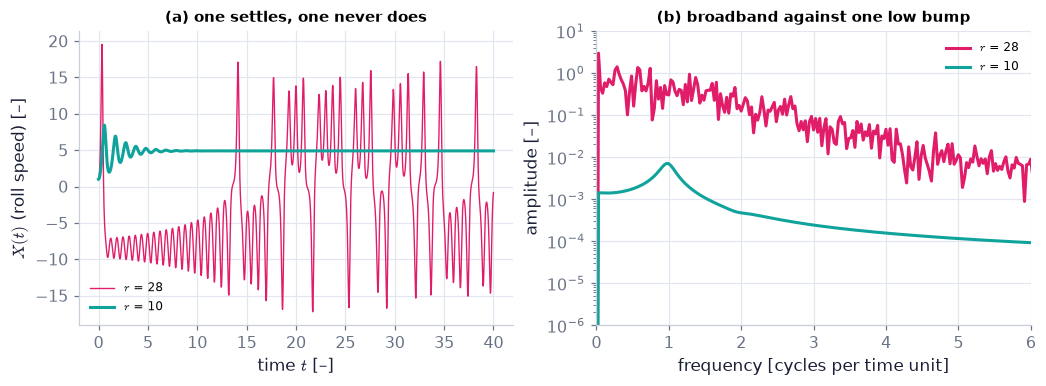

r = 10: X settles to 4.8990 after ringing at 0.989 cycles per time unit (eigenvalue of the steady roll: 0.983)


In [135]:
sol28 = ch11.lorenz_integrate((1.0, 1.0, 1.0), 40.0)               # Lorenz's own parameters: Pr = 10, b = 8/3, r = 28 (X, Y, Z on 4001 times)
sol10 = ch11.lorenz_integrate((1.0, 1.0, 1.0), 40.0, r=10.0)       # a gentler heating: r = 10
fig, (a, b) = plt.subplots(1, 2, figsize=(9.4, 3.4))   # the figure and its panels
a.plot(sol28["t"], sol28["X"], color=C_GROW, lw=0.9, label="$r$ = 28")   # strong heating: the roll keeps reversing irregularly
a.plot(sol10["t"], sol10["X"], color=C_DECAY, label="$r$ = 10")   # gentle heating: the roll settles to a steady speed
a.set(xlabel="time $t$ [–]", ylabel="$X(t)$ (roll speed) [–]")   # axis labels (with units) and fixed ranges for this panel
a.set_title("(a) one settles, one never does", fontsize=10)   # panel title — the message of this panel
a.legend(fontsize=8, loc="lower left")   # legend: one entry per curve
dt = sol28["t"][1] - sol28["t"][0]                                 # sampling interval
freq = np.fft.rfftfreq(len(sol28["t"]) - 500, dt)                  # frequencies of the discrete Fourier transform (Ch. 7 P181)
for s, col, lab in ((sol28, C_GROW, "$r$ = 28"), (sol10, C_DECAY, "$r$ = 10")):   # repeat the indented lines for each item listed
    sig = s["X"][500:] - np.mean(s["X"][500:])                     # drop the first 5 time units and the mean
    b.semilogy(freq, np.abs(np.fft.rfft(sig))/len(sig), color=col, label=lab)   # amplitude spectrum
b.set(xlabel="frequency [cycles per time unit]", ylabel="amplitude [–]", xlim=(0, 6), ylim=(1e-6, 10))   # axis labels (with units) and fixed ranges for this panel
b.set_title("(b) broadband against one low bump", fontsize=10)   # panel title — the message of this panel
b.legend(fontsize=8)   # legend: one entry per curve
plt.show()   # display the figure
f10 = ch10.dominant_frequency(sol10["t"][:1500], sol10["X"][:1500] - sol10["X"][-1])   # frequency of the decaying oscillation at r = 10
print(f"r = 10: X settles to {sol10['X'][-1]:.4f} after ringing at {f10:.3f} cycles per time unit "   # show the numbers computed above
      f"(eigenvalue of the steady roll: {abs(ch11.lorenz_eigs(10.0)[0].imag)/(2*np.pi):.3f})")   # the ringing frequency predicted by linearising about the steady roll

**What does the code above do?**

1. `ch11.lorenz_integrate(s0, t_end, r=…)` integrates the three equations with `solve_ivp` (method DOP853, relative tolerance
   10⁻¹⁰) and returns `t`, `X`, `Y`, `Z`.
2. `np.fft.rfft` gives the amplitude at each frequency; `ch10.dominant_frequency` (Ch. 10) the main frequency of the ringing.

**What you see.** (a) The roll speed $X(t)$: for $r=10$ (teal) a ringing that dies away to a constant; for $r=28$ (rose) irregular swings that switch sign at unpredictable moments. (b) Their spectra: for $r=10$ one low bump near 1 cycle per time unit; for $r=28$ a level a hundred times higher at every frequency.

**How to read it.** Chaos means energy at all frequencies — there is no period to find. The $r=10$ run has one frequency, the one of the linearised equations near the steady roll (printed); because that oscillation dies away, its line is a broad, low bump.

**What would change if…** …$r=24$ (just below the threshold derived in D25): long irregular transients, then a steady state.

📝 **Note.** **N113 [B]** **Phase space** with the pendulum: $\ddot X+(g/l)\sin X=0$ becomes the first-order system $\dot X=Y$, $\dot Y=-(g/l)\sin X$
(11.89); the plane $(X,Y)$ is its *phase space*, a solution is a *trajectory* there, and the number of independent initial values
(2) is its number of *degrees of freedom*. ($X$ is the angle, $Y$ the angular velocity, $g/l$ gravity over length.)

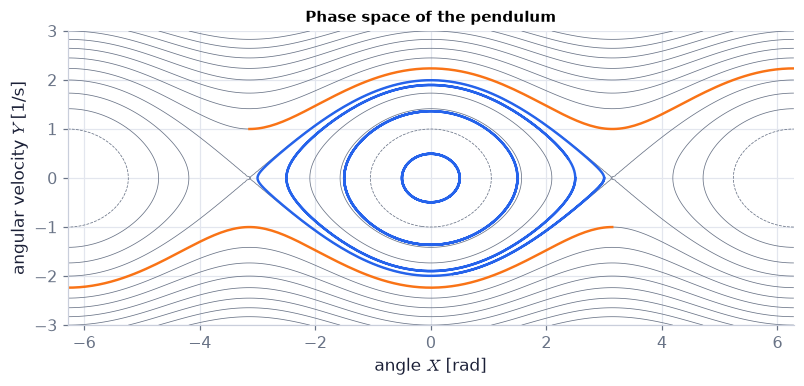

largest change of the energy along any trajectory: 6.9e-10


In [136]:
starts = [(0.5, 0.0), (1.5, 0.0), (2.5, 0.0), (3.0, 0.0), (-3.14, 1.0), (3.14, -1.0)]   # (angle, angular velocity) at t = 0
tr = ch11.phase_portrait(ch11.pendulum_rhs, starts, t_end=20.0)    # one trajectory per start (g/l = 1, no damping)
Xg, Yg = np.meshgrid(np.linspace(-2*np.pi, 2*np.pi, 200), np.linspace(-3, 3, 120))   # a grid in the phase plane
fig, ax = plt.subplots(figsize=(7.2, 3.4))   # the figure and its panels
ax.contour(Xg, Yg, 0.5*Yg**2 - np.cos(Xg), 12, colors=C_BASE, linewidths=0.5)   # lines of constant energy Y^2/2 - cos X
for p_ in tr:   # repeat the indented lines for each item listed
    ax.plot(p_["X"], p_["Y"], color=C_SHEAR if abs(p_["X"]).max() > np.pi else C_BUOY, lw=1.6)   # orange: over the top; blue: swinging
ax.set(xlabel="angle $X$ [rad]", ylabel="angular velocity $Y$ [1/s]", xlim=(-2*np.pi, 2*np.pi), ylim=(-3, 3))   # axis labels (with units) and fixed ranges for this panel
ax.set_title("Phase space of the pendulum", fontsize=10)   # panel title — the message of this panel
plt.show()   # display the figure
drift = max(np.max(np.abs(ch11.pendulum_energy(np.array([p_["X"], p_["Y"]])) - ch11.pendulum_energy(np.array([p_["X"][0], p_["Y"][0]])))) for p_ in tr)   # how much the energy changes along each trajectory (it should not)
print(f"largest change of the energy along any trajectory: {drift:.1e}")   # conserved to round-off: no friction, no attractor

**What does the code above do?**

1. `ch11.phase_portrait(rhs, starts, t_end)` integrates a two-variable system from several starting points and returns one
   dictionary `t`, `X`, `Y` per start; `ch11.pendulum_rhs` is the right side of the pendulum system.
2. `ch11.pendulum_energy` evaluates $\tfrac12Y^2-(g/l)\cos X$, which should not change along a trajectory.

**What you see.** The phase plane of a pendulum: closed loops around the origin (blue: swinging back and forth) and wavy lines above and below (orange: rotating over the top). Thin grey lines are curves of constant energy.

**How to read it.** Each trajectory stays on one energy curve — the printed drift is of order 10⁻⁹. Without friction nothing attracts: the motion remembers its starting energy forever.

**What would change if…** …we add damping (`damping=0.2`): every trajectory spirals into the point (0, 0) — an *attractor*.

> 📎 **Primer — Jacobian matrix of a nonlinear ODE system and the stability of its fixed points.** `P274` · For $\dot{\mathbf s}=\mathbf f(\mathbf s)$ a *fixed point* has $\mathbf f(\mathbf s^*)=0$. Near it write
$\mathbf s=\mathbf s^*+\boldsymbol\delta$: to first order $\dot{\boldsymbol\delta}=J\boldsymbol\delta$ with the Jacobian
$J_{ij}=\partial f_i/\partial s_j$ at $\mathbf s^*$ (a first-order Taylor expansion in several variables, Ch. 3 P98). The fixed
point is stable if every eigenvalue of $J$ has negative real part (Ch. 9 P214); a complex pair crossing the imaginary axis starts
an oscillation (a *Hopf bifurcation*).

In [137]:
import numpy as np                                    # arrays
Pr, r, b = 10.0, 28.0, 8/3                            # Lorenz's parameters
J0 = np.array([[-Pr, Pr, 0], [r, -1, 0], [0, 0, -b]]) # the Lorenz Jacobian at the origin X = Y = Z = 0
print(np.sort(np.linalg.eigvals(J0)))                 # -22.83, -2.67, 11.83: one positive -> the origin is unstable

[-22.8277  -2.6667  11.8277]


📝 **Note.** **N114 [B]** **Attractors and bifurcations**: in a dissipative system trajectories crowd onto *attractors* — a fixed point (a steady flow) or
a *limit cycle* (a steady oscillation); as a parameter $R$ passes a critical value a fixed point can turn into a repeller and a
limit cycle grow around it whose size increases with the distance from the critical value (a *bifurcation*). Our model of that
picture is the Hopf normal form $\dot z=(\mu+\mathrm i\omega)z-\lvert z\rvert^2z$ for a complex $z=X+\mathrm iY$ (ours): stable
fixed point for $\mu<0$, limit cycle of radius $\sqrt\mu$ for $\mu>0$.

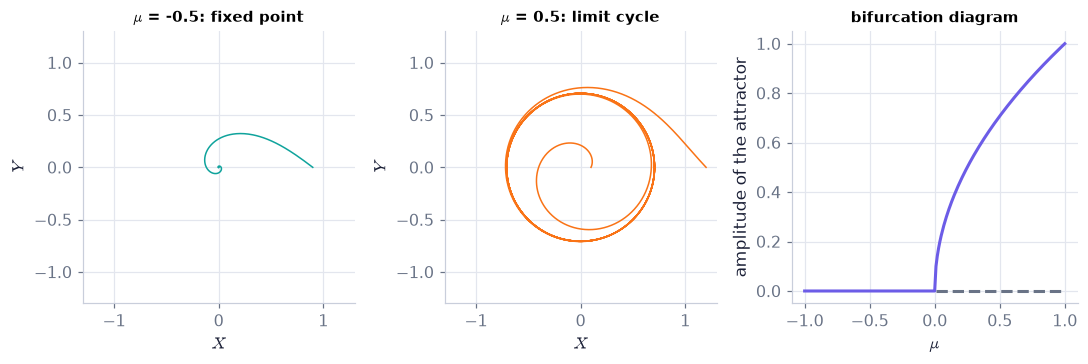

In [138]:
fig, axs = plt.subplots(1, 3, figsize=(9.8, 3.2))   # the figure and its panels
for ax, mu, st in ((axs[0], -0.5, [(0.9, 0.0)]), (axs[1], 0.5, [(0.1, 0.0), (1.2, 0.0)])):   # repeat the indented lines for each item listed
    for h in ch11.phase_portrait(ch11.hopf_normal_form, st, t_end=30.0, n=1500, mu=mu):   # trajectories of the normal form
        ax.plot(h["X"], h["Y"], color=C_DECAY if mu < 0 else C_SHEAR, lw=1)   # a trajectory: into the fixed point (teal) or onto the limit cycle (orange)
    ax.set(xlabel="$X$", ylabel="$Y$", xlim=(-1.3, 1.3), ylim=(-1.3, 1.3))   # axis labels (with units) and fixed ranges for this panel
    ax.set_aspect("equal")   # equal scales in x and y, so shapes are not distorted
    ax.set_title(f"$\\mu$ = {mu}: " + ("fixed point" if mu < 0 else "limit cycle"), fontsize=10)   # panel title — the message of this panel
mus = np.linspace(-1, 1, 201)                                      # the control parameter
axs[2].plot(mus, ch11.limit_cycle_amplitude(mus), color=C_NEUT)   # size of the attractor: zero, then growing like the square root
axs[2].plot(mus[mus > 0], 0*mus[mus > 0], "--", color=C_BASE)   # dashed: the fixed point is still there, but now repels
axs[2].set(xlabel="$\\mu$", ylabel="amplitude of the attractor")   # axis labels (with units) and fixed ranges for this panel
axs[2].set_title("bifurcation diagram", fontsize=10)   # panel title — the message of this panel
plt.show()   # display the figure

**What does the code above do?**

`ch11.hopf_normal_form` is the right side of the normal form in the two real variables $(X,Y)$; `ch11.limit_cycle_amplitude(mu)`
returns $\sqrt\mu$ for $\mu>0$ and 0 otherwise.

**What you see.** Left: for negative μ a trajectory spirals into the origin. Middle: for positive μ two trajectories — one starting inside, one outside — both wind onto the same circle. Right: the amplitude of the attractor against μ: zero up to μ = 0, then a square-root branch (the dashed line is the fixed point, now unstable).

**How to read it.** Linear theory gives the growth at μ > 0; the nonlinear term fixes the final amplitude √μ. This is the gentle (supercritical) way a steady state gives way to an oscillation.

**What would change if…** …the sign of the cubic term were reversed: no small stable cycle would exist near the threshold (a *subcritical* bifurcation) — that is Lorenz's case (D25).

📝 **Note.** **N115 [B]** **Lorenz's truncation**: stress-free walls, rolls along $y$, $u=-\partial\psi/\partial z$, $w=\partial\psi/\partial x$ (⚠️ slip #9:
the opposite sign to §11.7), and $\psi\propto X(t)\cos(\pi z)\sin(kx)$, $T'\propto Y(t)\cos(\pi z)\cos(kx)+Z(t)\sin(2\pi z)$
(11.90), $z\in[-\tfrac12,\tfrac12]$: $X$ measures the roll speed, $Y$ the temperature difference between rising and sinking
fluid, $Z$ the distortion of the mean temperature profile. $\cos\pi z$ is the free–free mode $\sin\pi(z+\tfrac12)$ of C05 (slip
#2's correct family).

> 📎 **Primer — Galerkin truncation: keep a few modes and project with orthogonality of sines.** `P275` · Write the unknown as a sum of a few fixed shapes with time-dependent amplitudes, insert it, and multiply the equation by each shape
and integrate: orthogonality ($\int\sin m\pi z\,\sin n\pi z\,dz=0$ for $m\neq n$, Ch. 6 P151) keeps one equation per amplitude, and
everything that does not fit the chosen shapes is thrown away. Ch. 10's finite elements used hats as shapes; here we use sines and
cosines.

In [139]:
import numpy as np                                    # arrays
z = np.linspace(-0.5, 0.5, 20001)                     # across the layer
print(np.trapezoid(np.cos(np.pi*z)*np.cos(3*np.pi*z), z), np.trapezoid(np.cos(np.pi*z)**2, z))   # ~0 and 0.5: orthogonal shapes

0.0 0.5


#### 🧮 Derivation — The Lorenz system from the truncation: $r=\mathrm{Ra}/\mathrm{Ra}_c(k)$, $b=4\pi^2/(\pi^2+k^2)$ `D24` ★★★ (Eq. 11.91: $\dot X=\Pr(Y-X),\ \ \dot Y=-XZ+rX-Y,\ \ \dot Z=XY-bZ$)

**What we want to show.** Derive Lorenz's three equations from free–free convection — the book writes only "Lorenz finally obtained".

**Assumptions.** Stress-free walls; only the three modes kept — valid slightly above onset (step 10); 2-D rolls.

**The plan.**

1. Write the vorticity and temperature equations with ψ.
2. Make them dimensionless.
3. Insert (11.90), $\psi\propto X(t)\cos(\pi z)\sin(kx),\ \ T'\propto Y(t)\cos(\pi z)\cos(kx)+Z(t)\sin(2\pi z)$ and project onto each shape (Galerkin).
4. Rescale time and amplitudes so the constants vanish.

**Tools we use** (each explained before this point): Vorticity form (Ch. 5) · Galerkin truncation (P275) · orthogonality of sines (P151) · (11.44), $\mathrm{Ra}=\frac{(n^2\pi^2+K^2)^3}{K^2}$ from C05 · sympy

**We start from**

$$ \begin{array}{l}u=-\frac{\partial\psi}{\partial z},\ \ w=\frac{\partial\psi}{\partial x}\quad\text{(2-D rolls between stress-free isothermal walls, }-\tfrac12\le z\le\tfrac12) \\[4pt] \psi\propto X(t)\cos(\pi z)\sin(kx),\ \ T'\propto Y(t)\cos(\pi z)\cos(kx)+Z(t)\sin(2\pi z)\qquad\text{(11.90)}\end{array} $$

*In words:* one roll and two temperature shapes.

---

**Step 1 of 15 — Take the curl of the momentum equation.**

$$ \frac{D}{Dt}\nabla^2\psi=g\alpha\frac{\partial T'}{\partial x}+\nu\nabla^4\psi $$

- *Why we can do this:* ∂_z of the x-equation minus ∂_x of the z-equation removes the pressure; with this sign convention (slip #9) the y-vorticity is −∇²ψ.
- *In words:* the vorticity of the roll is made by horizontal temperature differences.

---

**Step 2 of 15 — Write the temperature equation.**

$$ \frac{DT'}{Dt}-\Gamma\frac{\partial\psi}{\partial x}=\kappa\nabla^2T' $$

- *Why we can do this:* (11.27), $\frac{\partial T'}{\partial t}-w\Gamma=\kappa\nabla^2T'$ with its nonlinear advection kept and w = ∂ψ/∂x.
- *In words:* rising fluid warms the layer, diffusion smooths it.

---

**Step 3 of 15 — Write advection as a Jacobian.**

$$ \frac{D}{Dt}f=\frac{\partial f}{\partial t}+J(\psi,f),\ \ J(\psi,f)=\psi_xf_z-\psi_zf_x $$

- *Why we can do this:* u∂_x + w∂_z with u = −ψ_z, w = ψ_x.
- *In words:* the nonlinearity is a Jacobian.

---

**Step 4 of 15 — Note J(ψ, ∇²ψ) vanishes here.**

$$ \nabla^2\psi=-a^2\psi,\ a^2=\pi^2+k^2\ \Rightarrow\ J(\psi,\nabla^2\psi)=-a^2J(\psi,\psi)=0 $$

- *Why we can do this:* the single roll is an eigenfunction of ∇²; J(ψ, ψ) = 0.
- *In words:* the roll does not advect its own vorticity.

---

**Step 5 of 15 — Make it dimensionless.**

$$ \frac1\Pr\partial_t\nabla^2\psi=\mathrm{Ra}\,\theta_x+\nabla^4\psi,\ \ \partial_t\theta+J(\psi,\theta)-\psi_x=\nabla^2\theta $$

- *Why we can do this:* lengths d, time d²/κ, ψ by κ, T′ by ΔT (θ); Ra of (11.21), $\mathrm{Ra}=\frac{g\alpha\Gamma d^4}{\kappa\nu}$ appears as in D07.
- *In words:* two equations, two numbers (Ra, Pr).

---

**Step 6 of 15 — Insert the truncation.**

$$ \psi=A(t)\cos\pi z\,\sin kx,\ \ \theta=B(t)\cos\pi z\cos kx+C(t)\sin2\pi z $$

- *Why we can do this:* (11.90), $\psi\propto X(t)\cos(\pi z)\sin(kx),\ \ T'\propto Y(t)\cos(\pi z)\cos(kx)+Z(t)\sin(2\pi z)$ with amplitudes A, B, C; each shape meets the free–free, isothermal conditions at z = ±½ (C05).
- *In words:* three time-dependent amplitudes.

---

**Step 7 of 15 — Project the vorticity equation.**

$$ \dot A=\Pr\Big(\frac{\mathrm{Ra}\,k}{a^2}B-a^2A\Big) $$

- *Why we can do this:* ∇²ψ = −a²ψ, ∇⁴ψ = a⁴ψ, θ_x = −kB cos πz sin kx (the C term has no x); match the coefficients of cos πz sin kx.
- *In words:* buoyancy B spins up the roll, viscosity slows it.

---

**Step 8 of 15 — Compute the Jacobian J(ψ, θ).**

$$ J(\psi,\theta)=-\frac{\pi k}2AB\sin2\pi z+2\pi kAC\cos\pi z\cos2\pi z\cos kx $$

- *Why we can do this:* product rule on each factor; sin² + cos² = 1 collects the AB terms; 2 sin πz cos πz = sin 2πz.
- *In words:* the roll moves heat between the shapes.

---

**Step 9 of 15 — Project on cos πz cos kx.**

$$ \dot B=-a^2B+kA-\pi kAC $$

- *Why we can do this:* cos πz cos 2πz = ½(cos πz + cos 3πz) (P151); keep cos πz, drop the cos 3πz harmonic (the Galerkin truncation, P275); −ψ_x gives +kA.
- *In words:* the roll makes the temperature difference B, and its interaction with C limits it.

---

**Step 10 of 15 — Project on sin 2πz.**

$$ \dot C=\frac{\pi k}2AB-4\pi^2C $$

- *Why we can do this:* the x-averaged part of J feeds the mean-profile mode C; ∇²(sin 2πz) = −4π² sin 2πz. Every other harmonic is dropped.
- *In words:* the roll flattens the temperature profile.

---

**Step 11 of 15 — Rescale time.**

$$ \tau=a^2t:\ \ \frac{dA}{d\tau}=\Pr\Big(\frac{\mathrm{Ra}\,k}{a^4}B-A\Big),\ \frac{dB}{d\tau}=-B+\frac k{a^2}A-\frac{\pi k}{a^2}AC,\ \frac{dC}{d\tau}= \frac{\pi k}{2a^2}AB-\frac{4\pi^2}{a^2}C $$

- *Why we can do this:* divide each equation by a² so the decay of B has rate 1.
- *In words:* time in units of d²/((π² + k²)κ).

---

**Step 12 of 15 — Rescale the amplitudes.**

$$ X=\alpha_LA,\ Y=\beta_LB,\ Z=\gamma_LC $$

- *Why we can do this:* free scale factors chosen next so that every coefficient but r, b, Pr becomes 1.
- *In words:* measure each mode in its natural unit.

---

**Step 13 of 15 — Fix the factors.**

$$ \beta_L=\alpha_L\frac{\mathrm{Ra}\,k}{a^4},\ \ r\equiv\frac{\beta_Lk}{\alpha_La^2}=\frac{\mathrm{Ra}\,k^2}{a^6},\ \ \gamma_L=\pi r,\ \ \alpha_L=\frac{\pi k}{\sqrt2\,a^2} $$

- *Why we can do this:* demand dX/dτ = Pr(Y − X), the rX term in dY/dτ, the −XZ term (α_Lγ_L = β_Lπk/a²) and the +XY term in dZ/dτ (α_Lβ_L = γ_Lπk/(2a²)).
- *In words:* four conditions, four unknowns (r is the leftover number).

---

**Step 14 of 15 — Recognise r.**

$$ r=\frac{\mathrm{Ra}\,k^2}{(\pi^2+k^2)^3}=\frac{\mathrm{Ra}}{\mathrm{Ra}_c(k)} $$

- *Why we can do this:* (11.44), $\mathrm{Ra}=\frac{(n^2\pi^2+K^2)^3}{K^2}$ with n = 1: Ra_c(k) = (π² + k²)³/k².
- *In words:* r measures how far above its own onset the roll is heated.

---

**Step 15 of 15 — Write the system.**

$$ \dot X=\Pr(Y-X),\ \ \dot Y=-XZ+rX-Y,\ \ \dot Z=XY-bZ,\ \ b=\frac{4\pi^2}{\pi^2+k^2}\ \text{(11.91)} $$

- *Why we can do this:* steps 11–14; the last coefficient is 4π²/a². At the critical roll k² = π²/2, b = 8/3.
- *In words:* Lorenz's equations.

---

**Result**

$$ \begin{array}{l}\dot X=\Pr(Y-X) \\[4pt] \dot Y=-XZ+rX-Y \\[4pt] \dot Z=XY-bZ\qquad\text{(11.91)} \\[4pt] r=\frac{\mathrm{Ra}\,k^2}{(\pi^2+k^2)^3}=\frac{\mathrm{Ra}}{\mathrm{Ra}_{cr}},\qquad b=\frac{4\pi^2}{\pi^2+k^2}\end{array} $$

*In words:* three numbers describe the roll speed (X), the temperature contrast (Y) and the flattening of the mean profile (Z).

**What it means.** The simplest possible model of convection that keeps the nonlinear heat transport (Z) — enough to produce chaos (D25). Fails for strong convection (many modes matter); the real Bénard layer is not chaotic at r = 28.

**Check it.** r = 1 is the onset (C05) ✓; b(π/√2) = 8/3 ✓; conduction X = Y = Z = 0 is a solution ✓; the check cell below projects both equations and prints the residuals of the three rescaled equations: 0, 0, 0.

In [140]:
import sympy as sp                                              # symbolic algebra
x, z, t, k, Pr, Ra = sp.symbols("x z t k Pr Ra", positive=True)   # coordinates, wavenumber, parameters
A, B, C = [sp.Function(n)(t) for n in "ABC"]                    # the three amplitudes
psi = A*sp.cos(sp.pi*z)*sp.sin(k*x)                             # (11.90), roll
th = B*sp.cos(sp.pi*z)*sp.cos(k*x) + C*sp.sin(2*sp.pi*z)        # (11.90), temperature
J = lambda f, g: sp.diff(f, x)*sp.diff(g, z) - sp.diff(f, z)*sp.diff(g, x)   # step 3
lap = lambda f: sp.diff(f, x, 2) + sp.diff(f, z, 2)             # Laplacian
heat = sp.diff(th, t) + J(psi, th) - sp.diff(psi, x) - lap(th)  # step 5, temperature residual
proj = lambda e, s: sp.integrate(sp.integrate(sp.expand(e*s), (x, 0, 2*sp.pi/k)), (z, -sp.Rational(1, 2), sp.Rational(1, 2)))   # Galerkin projection
eqB = sp.solve(proj(heat, sp.cos(sp.pi*z)*sp.cos(k*x)), sp.diff(B, t))[0]    # step 9
eqC = sp.solve(proj(heat, sp.sin(2*sp.pi*z)), sp.diff(C, t))[0]               # step 10
a2 = sp.pi**2 + k**2   # the combination pi^2 + k^2 that every Laplacian of the roll produces
print(sp.simplify(eqB - (-a2*B + k*A - sp.pi*k*A*C)))           # -> 0
print(sp.simplify(eqC - (sp.pi*k/2*A*B - 4*sp.pi**2*C)))        # -> 0
print(sp.simplify(4*sp.pi**2/a2).subs(k, sp.pi/sp.sqrt(2)))     # b at k^2 = pi^2/2 -> 8/3
vort = sp.diff(lap(psi), t)/Pr - Ra*sp.diff(th, x) - lap(lap(psi))       # step 5, vorticity residual (J(psi, lap psi) = 0, step 4)
eqA = sp.solve(proj(vort, sp.cos(sp.pi*z)*sp.sin(k*x)), sp.diff(A, t))[0]   # step 7: project on the roll's own shape
print(sp.simplify(eqA - Pr*(Ra*k/a2*B - a2*A)))                   # -> 0: dA/dt = Pr (Ra k B/a^2 - a^2 A)
r_ = Ra*k**2/a2**3                                                # step 14: r = Ra/Ra_c(k)
aL = sp.pi*k/(sp.sqrt(2)*a2); bL = aL*Ra*k/a2**2; gL = sp.pi*r_   # step 13: the three scale factors alpha_L, beta_L, gamma_L
Xs, Ys, Zs = sp.symbols("X Y Z")                                  # the rescaled amplitudes X = alpha_L A, Y = beta_L B, Z = gamma_L C
back = {A: Xs/aL, B: Ys/bL, C: Zs/gL}                             # A, B, C written with X, Y, Z
dX = (aL*eqA/a2).subs(back)                                       # steps 11-12: dX/dtau = alpha_L (dA/dt)/a^2, with tau = a^2 t
dY = (bL*eqB/a2).subs(back)                                       # ... dY/dtau
dZ = (gL*eqC/a2).subs(back)                                       # ... dZ/dtau
bpar = 4*sp.pi**2/a2                                              # step 15: b = 4 pi^2/(pi^2 + k^2)
print(sp.simplify(dX - Pr*(Ys - Xs)), sp.simplify(dY - (-Xs*Zs + r_*Xs - Ys)), sp.simplify(dZ - (Xs*Ys - bpar*Zs)))   # -> 0 0 0: (11.91)
print(ch11.lorenz_sympy()["scaled_residuals"])                    # the library's own engine does the same projection and rescaling: [0, 0, 0]

0
0
8/3


0


0 0 0


[0, 0, 0]


> ⚠️ **Common confusion (traps in `D24`):** The sign convention u = −∂ψ/∂z (slip #9); keeping cos 3πz (not in the truncation); forgetting that X, Y, Z are rescaled.

> 📎 **Primer — purely imaginary roots of a cubic λ³ + a₂λ² + a₁λ + a₀: exactly when a₂a₁ = a₀.** `P276` · Put $\lambda=\mathrm i\omega$: the real part gives $-a_2\omega^2+a_0=0$ and the imaginary part $-\omega^3+a_1\omega=0$, so
$\omega^2=a_1$ and $a_2a_1=a_0$. For positive coefficients, all three roots have negative real part when $a_2a_1>a_0$ (the
Routh–Hurwitz condition); at $a_2a_1=a_0$ a pair sits on the imaginary axis — the Hopf point.

In [141]:
import numpy as np                                    # arrays
a2, a1, a0 = 13.6667, 101.3333, 1440.0                # the cubic of the Lorenz convection state at r = 28 (D25 step 9)
print(a2*a1, a0)                                      # 1384.9 < 1440: a pair has crossed the axis (unstable)
print(np.roots([1, a2, a1, a0]))                      # -13.85 and 0.094 + 10.19j, 0.094 - 10.19j

1384.89181111 1440.0
[-13.8546 +0.j       0.094 +10.1945j   0.094 -10.1945j]


#### 🧮 Derivation — The Lorenz fixed points, the pitchfork at r = 1 and the Hopf point $r_H=\Pr(\Pr+b+3)/(\Pr-b-1)$ `D25` ★★ (Eq. 11.91: $\dot X=\Pr(Y-X),\ \ \dot Y=-XZ+rX-Y,\ \ \dot Z=XY-bZ$)

**What we want to show.** Find the steady states of (11.91), $\dot X=\Pr(Y-X),\ \ \dot Y=-XZ+rX-Y,\ \ \dot Z=XY-bZ$ and the value of r at which the steady rolls lose stability — the book says only "if r is large".

**Assumptions.** Pr > b + 1 (step 11).

**The plan.**

1. Set the right sides to zero.
2. Linearise with the Jacobian.
3. Origin: a 2 × 2 block.
4. Rolls: a cubic, and the condition for a pair of imaginary roots.

**Tools we use** (each explained before this point): Jacobian and fixed-point stability (P274) · purely imaginary roots of a cubic (P276) · P214

**We start from**

$$ \dot X=\Pr(Y-X),\ \dot Y=-XZ+rX-Y,\ \dot Z=XY-bZ\ \text{(11.91)} $$

*In words:* Lorenz's system.

---

**Step 1 of 11 — Set Ẋ = 0.**

$$ Y=X $$

- *Why we can do this:* Pr ≠ 0. A product is zero only if a factor is zero, and the Prandtl number is a positive material constant.
- *In words:* in a steady roll the two amplitudes match.

---

**Step 2 of 11 — Set Ż = 0.**

$$ Z=\frac{XY}b=\frac{X^2}b $$

- *Why we can do this:* b > 0; use step 1.
- *In words:* the profile flattens with the roll's strength.

---

**Step 3 of 11 — Set Ẏ = 0.**

$$ X\Big(r-1-\frac{X^2}b\Big)=0 $$

- *Why we can do this:* −XZ + rX − Y with steps 1–2.
- *In words:* either no roll, or a roll of a definite size.

---

**Step 4 of 11 — List the fixed points.**

$$ (0,0,0);\ \ C_\pm=\big(\pm\sqrt{b(r-1)},\ \pm\sqrt{b(r-1)},\ r-1\big)\ (r>1) $$

- *Why we can do this:* step 3's two factors. Either the first factor vanishes (no motion) or the bracket does; the bracket has real roots only for r > 1.
- *In words:* conduction, and two rolls turning opposite ways.

---

**Step 5 of 11 — Write the Jacobian.**

$$ J=\begin{pmatrix}-\Pr&\Pr&0\\r-Z&-1&-X\\Y&X&-b\end{pmatrix} $$

- *Why we can do this:* partial derivatives of the three right sides (P274).
- *In words:* the linear response near any state.

---

**Step 6 of 11 — Linearise at the origin.**

$$ \lambda=-b,\ \ \lambda^2+(\Pr+1)\lambda+\Pr(1-r)=0 $$

- *Why we can do this:* at X = Y = Z = 0 the Z-row decouples; the 2 × 2 block gives the quadratic.
- *In words:* the conduction state's growth rates.

---

**Step 7 of 11 — Read the pitchfork.**

$$ r>1\ \Rightarrow\ \lambda_1\lambda_2=\Pr(1-r)<0 $$

- *Why we can do this:* a negative product means one positive root; the origin becomes unstable at r = 1, exactly where C± appear (Ra = Ra_c). This is called a *pitchfork* bifurcation: one fixed point (the origin) loses its stability and two symmetric new ones (C₊ and C₋) appear — on a plot of the steady X against r, one line splits into three prongs.
- *In words:* convection starts at r = 1.

---

**Step 8 of 11 — Linearise at C±.**

$$ J_C=\begin{pmatrix}-\Pr&\Pr&0\\1&-1&-\bar X\\\bar X&\bar X&-b\end{pmatrix} $$

- *Why we can do this:* r − Z̄ = 1 and X̄ = Ȳ.
- *In words:* the rolls' response matrix.

---

**Step 9 of 11 — Compute the characteristic cubic.**

$$ \lambda^3+(\Pr+b+1)\lambda^2+b(r+\Pr)\lambda+2b\Pr(r-1)=0 $$

- *Why we can do this:* expand det(λI − J_C) along the first row; X̄² = b(r − 1).
- *In words:* three growth rates of the rolls.

---

**Step 10 of 11 — Impose a pair of imaginary roots.**

$$ (\Pr+b+1)\,b(r+\Pr)=2b\Pr(r-1) $$

- *Why we can do this:* λ = iω is a root iff a₂a₁ = a₀ (P276).
- *In words:* the rolls' spirals neither shrink nor grow.

---

**Step 11 of 11 — Solve for r.**

$$ r_H=\frac{\Pr(\Pr+b+3)}{\Pr-b-1}=24.74\ (\Pr=10,\ b=8/3) $$

- *Why we can do this:* collect r: r(b + 1 − Pr) = −Pr(Pr + b + 3); positive only if Pr > b + 1. Above r_H, a₂a₁ < a₀ and a pair has positive real part (P276).
- *In words:* beyond 24.74 no steady state is stable.

---

**Result**

$$ \begin{array}{l}(0,0,0)\ \text{unstable for}\ r>1;\qquad C_\pm=\big(\pm\sqrt{b(r-1)},\ \pm\sqrt{b(r-1)},\ r-1\big) \\[4pt] C_\pm\ \text{unstable for}\ r>r_H=\frac{\Pr(\Pr+b+3)}{\Pr-b-1}=24.74\quad(\Pr=10,\ b=8/3)\end{array} $$

*In words:* above r_H the motion has nowhere to settle.

**What it means.** Together with volume contraction −(Pr + 1 + b), the motion is confined to a zero-volume set yet cannot settle: a strange attractor. The Hopf bifurcation is subcritical (no small stable cycle is born — the chaos is not a gentle oscillation).

**Check it.** r = 28: eig(C±) = −13.85, 0.094 ± 10.19i (positive real part) ✓; r = 20: −13.36, −0.155 ± 8.71i (stable) ✓; at r_H the real part crosses zero ✓ (`ch11.lorenz_eigs`, `ch11.lorenz_hopf_r` — all three printed by the code cell below).

📝 **Notes taught inside `D25`:** **N116 [B]** the fixed points, the pitchfork at r = 1 and the Hopf point (steps 4, 7, 11).

> ⚠️ **Common confusion (traps in `D25`):** Expanding the 3 × 3 determinant with a sign error in the cofactors; forgetting r − Z̄ = 1; applying a₂a₁ = a₀ with the inequality reversed.

#### ✏️ Tiny example: the Lorenz numbers at r = 28

$\Pr=10$, $b=8/3$, $r=28$ (Lorenz 1963).

1. Convection states: $\bar X=\bar Y=\pm\sqrt{b(r-1)}=\pm\sqrt{\tfrac83\times27}=\pm\sqrt{72}=\pm8.485$, $\bar Z=r-1=27$.
2. Hopf point: $r_H=\Pr(\Pr+b+3)/(\Pr-b-1)=10\times15.667/6.333=24.74<28$ ⇒ the convection states are unstable (eigenvalues
   $0.094\pm10.19\,\mathrm i$).
3. Origin: eigenvalues $-8/3$ and the roots of $\lambda^2+11\lambda-270=0$: $11.83$ and $-22.83$ ⇒ unstable.
4. Volume: the divergence of the right-hand sides, $\frac{\partial\dot X}{\partial X}+\frac{\partial\dot Y}{\partial Y}+\frac{\partial\dot Z}{\partial Z}=-\Pr-1-b$
   (the trace of the Jacobian, P274), is the rate at which a small volume of states changes: every blob shrinks at
   $-(\Pr+1+b)=-13.67$ per unit time, so the attractor has zero volume — yet it
   is not a point or a loop: it is *strange*.
5. $b=8/3$ comes from $k^2=\pi^2/2$, the free–free critical wavenumber of C05: $4\pi^2/(\pi^2+\pi^2/2)=8/3$.

In [142]:
print("fixed points at r = 28:", [tuple(round(v, 4) for v in p_) for p_ in ch11.lorenz_fixed_points(28.0)])     # origin and C+, C-
print("eigenvalues at C+:", np.round(ch11.lorenz_eigs(28.0, which="C"), 4))            # a complex pair with positive real part
print("eigenvalues at the origin:", np.round(ch11.lorenz_eigs(28.0, which="origin"), 4))   # one positive eigenvalue: the state of rest is unstable
print("eigenvalues at C+ for r = 20 (below r_H):", np.round(ch11.lorenz_eigs(20.0, which="C"), 3))   # every real part negative: steady rolls are stable
print("largest real part at C+ exactly at r_H:", f"{np.max(ch11.lorenz_eigs(ch11.lorenz_hopf_r(), which='C').real):.1e}")   # ~0: the pair sits on the axis
print("Hopf point r_H =", round(ch11.lorenz_hopf_r(), 4), "| b at k = pi/sqrt(2):", round(ch11.lorenz_b(np.pi/np.sqrt(2)), 4),   # the heating beyond which the steady rolls are unstable, and b for the critical roll
      "| volume contraction rate:", round(ch11.lorenz_divergence(), 3))   # volumes of states shrink at this rate
sep = ch11.lorenz_separation(delta0=1e-8)                           # two runs that start 1e-8 apart in X
print(f"separation grows like e^(lambda t) with fitted slope lambda = {sep['slope']:.2f} over t in {sep['window']}")   # the fitted exponent of the error growth
print("time at which the two runs differ by 1:", ch11.lorenz_predictability_time(1e-8, 1.0))   # the forecast horizon for a starting error of 1e-8

fixed points at r = 28: [(0.0, 0.0, 0.0), (8.4853, 8.4853, 27.0), (-8.4853, -8.4853, 27.0)]
eigenvalues at C+: [  0.094 +10.1945j   0.094 -10.1945j -13.8546 +0.j    ]
eigenvalues at the origin: [ 11.8277  -2.6667 -22.8277]
eigenvalues at C+ for r = 20 (below r_H): [ -0.155+8.709j  -0.155-8.709j -13.357+0.j   ]
largest real part at C+ exactly at r_H: -4.4e-16
Hopf point r_H = 24.7368 | b at k = pi/sqrt(2): 2.6667 | volume contraction rate: -13.667


separation grows like e^(lambda t) with fitted slope lambda = 0.90 over t in (14.02, 27.53)


time at which the two runs differ by 1: 29.14


**What does the code above do?**

1. `ch11.lorenz_fixed_points(r)` returns the steady states of D25; `ch11.lorenz_eigs(r, which=…)` the eigenvalues of the Jacobian
   (P274) there: at $r=28$ both the origin and $C_\pm$ are unstable; at $r=20$ the rolls are stable ($-13.36$, $-0.155\pm8.71\,\mathrm i$);
   exactly at $r_H$ the real part of the pair is zero — the three numbers D25's *Check it* quotes.
2. `ch11.lorenz_hopf_r()` is D25's threshold 24.74; `ch11.lorenz_divergence()` the rate at which volumes of states shrink.
3. `ch11.lorenz_separation(delta0)` integrates two runs started `delta0` apart and fits the slope of $\ln$(separation) — about
   0.9 here (the literature value of the largest Lyapunov exponent is about 0.9; our single-run fit depends on the window and is
   qualitative). The two runs differ by 1 after about 29 time units.

In [143]:
def lorenz_f(s, Pr=10.0, r=28.0, b=8/3):                            # the right side of (11.91)
    X, Y, Z = s   # roll speed, temperature contrast, profile distortion
    return np.array([Pr*(Y - X), -X*Z + r*X - Y, X*Y - b*Z])   # the values for this call

s, dt_ = np.array([1.0, 1.0, 1.0]), 0.01                            # start and time step
traj = [s]                                                          # the trajectory, step by step
for n in range(4000):                                               # classical fourth-order Runge-Kutta (Ch. 3 P95)
    k1 = lorenz_f(s); k2 = lorenz_f(s + 0.5*dt_*k1); k3 = lorenz_f(s + 0.5*dt_*k2); k4 = lorenz_f(s + dt_*k3)   # four slopes
    s = s + dt_*(k1 + 2*k2 + 2*k3 + k4)/6                           # weighted average of the slopes
    traj.append(s)   # store the value
traj = np.array(traj)                                               # shape (4001, 3): the same times as sol28["t"]
diff = np.abs(traj[:, 0] - sol28["X"])                              # difference in X between our RK4 and the library's adaptive solver
assert np.allclose(traj[:501, 0], sol28["X"][:501], atol=1e-3)      # they agree up to t = 5
assert np.allclose(ch11.lorenz_rk4((1, 1, 1), 0.01, 1)[1], traj[1])  # the library's fixed-step RK4 takes the same first step
print(f"largest difference up to t = 5: {diff[:501].max():.1e}; first time the two differ by more than 1: t = {sol28['t'][np.argmax(diff > 1)]:.1f}")   # two correct solvers agree at first and disagree completely later

largest difference up to t = 5: 4.2e-04; first time the two differ by more than 1: t = 18.5


**What does the code above do?**

1. A hand-written RK4 loop for the three equations.
2. It agrees with the library's high-accuracy solver to 4 × 10⁻⁴ up to $t=5$ — and then drifts away: by $t\approx18$ the two
   differ by more than 1. Both are correct numerical solutions; their tiny truncation differences grow like any other
   perturbation. **The disagreement is the lesson.**

> 📎 **Primer — Lyapunov exponent: the slope of log(separation) against time.** `P277` · If two nearby trajectories separate like $\lvert\delta(t)\rvert\approx\lvert\delta_0\rvert e^{\lambda t}$, then
$\ln\lvert\delta\rvert$ grows linearly with slope $\lambda$, the (largest) *Lyapunov exponent*; $\lambda>0$ means chaos. The time to
grow from $\delta_0$ to an error of size $\Delta$ is about $\ln(\Delta/\delta_0)/\lambda$ — halving the initial error only adds
$\ln2/\lambda$ to the forecast horizon. Fit the slope only while the separation is small (it saturates at the attractor's size).
`np.polyfit(t, y, 1)` fits a straight line by least squares and returns (slope, intercept).

In [144]:
import numpy as np                                    # arrays
t = np.linspace(0, 10, 11)                            # times
sep_ideal = 1e-8*np.exp(0.9*t)                        # an ideal exponential separation with lambda = 0.9
print(np.polyfit(t, np.log(sep_ideal), 1)[0])         # 0.9: the slope of ln(separation) is lambda

0.9000000000000006


> 📎 **Primer — matplotlib 3-D line plots.** `P278` · `ax = fig.add_subplot(projection="3d")` makes 3-D axes; `ax.plot(X, Y, Z)` draws a curve through space, `ax.view_init(elev, azim)`
sets the viewpoint. (Ch. 1–2's 3-D figures were plotly, P41/P64; for a static page figure matplotlib is lighter.)

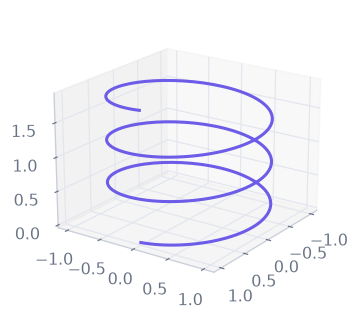

In [145]:
import numpy as np, matplotlib.pyplot as plt           # arrays and figures
fig = plt.figure(figsize=(3.6, 2.8))                   # an empty figure
ax = fig.add_subplot(projection="3d")                  # 3-D axes
t = np.linspace(0, 6*np.pi, 300)                       # a parameter along the curve
ax.plot(np.cos(t), np.sin(t), t/10)                    # a helix
ax.view_init(20, 35)                                   # elevation 20 degrees, azimuth 35 degrees
plt.show()   # display the figure

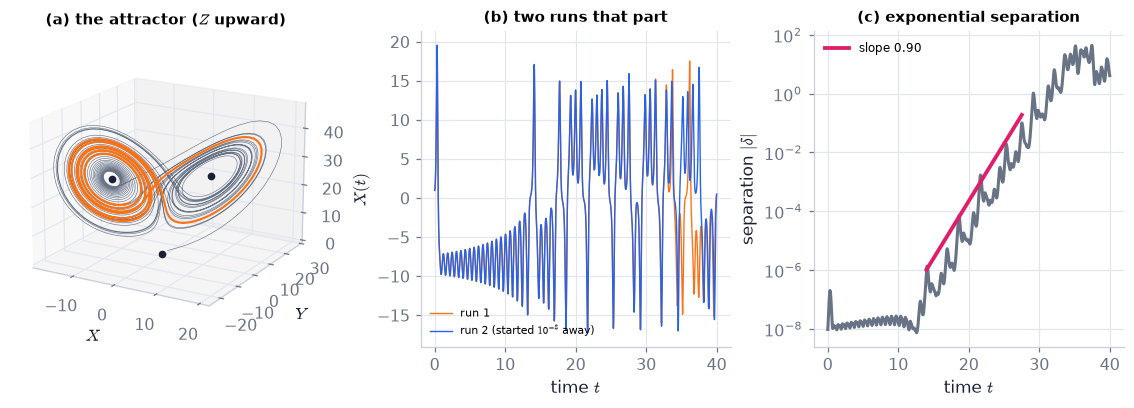

In [146]:
fig = plt.figure(figsize=(10.2, 3.6))   # an empty figure for three panels (the first one three-dimensional)
ax3 = fig.add_subplot(1, 3, 1, projection="3d")                    # panel (a): the orbit in (X, Y, Z)
ax3.plot(sol28["X"], sol28["Y"], sol28["Z"], color=C_BASE, lw=0.4)   # the whole orbit: two lobes, never closing
ax3.plot(sol28["X"][-500:], sol28["Y"][-500:], sol28["Z"][-500:], color=C_SHEAR, lw=1.4)   # the last 5 time units
for p_ in ch11.lorenz_fixed_points(28.0):   # repeat the indented lines for each item listed
    ax3.plot([p_[0]], [p_[1]], [p_[2]], "o", color=COLORS["ink"], ms=4)   # the three steady states, all unstable at r = 28
ax3.view_init(18, -60)   # a viewpoint from which both lobes are visible
ax3.set(xlabel="$X$", ylabel="$Y$")                                 # the vertical axis is Z (named in the title: its label would collide with panel b)
ax3.set_title("(a) the attractor ($Z$ upward)", fontsize=10)   # panel title — the message of this panel
a = fig.add_subplot(1, 3, 2)   # panel (b)
a.plot(sep["t"], sep["a"][0], color=C_SHEAR, lw=0.9, label="run 1")   # the roll speed of the first run
a.plot(sep["t"], sep["b"][0], color=C_BUOY, lw=0.9, label="run 2 (started $10^{-8}$ away)")   # the second run, started a hundred-millionth away
a.set(xlabel="time $t$", ylabel="$X(t)$")   # axis labels (with units) and fixed ranges for this panel
a.set_title("(b) two runs that part", fontsize=10)   # panel title — the message of this panel
a.legend(fontsize=7, loc="lower left")   # legend: one entry per curve
b = fig.add_subplot(1, 3, 3)   # panel (c)
b.semilogy(sep["t"][1:], sep["sep"][1:], color=C_BASE)   # distance between the two runs: a straight line here means exponential growth
w0, w1 = sep["window"]                                             # the window used for the fit
tw = np.array([w0, w1])   # the two ends of the fitted window
i0 = int(np.argmin(np.abs(sep["t"] - w0)))                         # index of the window's start
b.semilogy(tw, sep["sep"][i0]*np.exp(sep["slope"]*(tw - w0)), color=C_GROW, lw=2.5, label=f"slope {sep['slope']:.2f}")   # the fitted exponential: its slope is the Lyapunov exponent
b.set(xlabel="time $t$", ylabel="separation $|\\delta|$")   # axis labels (with units) and fixed ranges for this panel
b.set_title("(c) exponential separation", fontsize=10)   # panel title — the message of this panel
b.legend(fontsize=8)   # legend: one entry per curve
savefig(fig, "ch11", "c15_lorenz")   # keep a copy in outputs/ch11 and display
plt.show()   # display the figure

**What does the code above do?**

1. `sep["a"]` and `sep["b"]` are the two runs (rows $X$, $Y$, $Z$); `sep["sep"]` their distance; `sep["window"]` the time window
   of the fit and `sep["slope"]` the fitted exponent.
2. `fig.add_subplot(1, 3, 1, projection="3d")` (P278) puts a 3-D panel next to two ordinary ones.

**What you see.** (a) The orbit in the three-dimensional phase space: two lobes, each around one convection state (dots); the last five time units are drawn bold. (b) $X(t)$ for two runs that start 10⁻⁸ apart: on top of each other until about $t=28$, then unrelated (they differ by 1 at $t=29.1$, printed above). (c) Their separation on a logarithmic axis: flat for the first twelve time units, then a straight rising line that flattens once it is as large as the attractor.

**How to read it.** $X$ changes sign irregularly — the roll reverses its sense of rotation — each time the orbit jumps to the other lobe. The slope in (c) is the Lyapunov exponent (P277), about 0.9 here. The flat start is not a contradiction: for the first twelve time units both runs are still spiralling regularly around one convection state, where neighbouring states do not separate on average; the exponential growth begins once the orbit starts switching lobes.

**What would change if…** …the first difference were 10⁻¹⁶ (the round-off of double precision): the two runs would agree only about 20 time units longer — $\ln(10^8)/\lambda$. A hundred million times more precision buys two thirds more time.

**Animation A5 — two runs, one roll.** The two runs of panel (b) on the $X$–$Z$ plane (with a short trail), the temperature field
of the convection roll driven by run 1 ($T'$ of Lorenz's truncation), and the separation.

In [147]:
nf = 14 if FAST else 18                                            # number of frames
idx = np.linspace(2200, 3700, nf).astype(int)                      # sample times t = 22 ... 37, where the runs part
xr, zr = np.meshgrid(np.linspace(0, 2*np.sqrt(2), 40), np.linspace(-0.5, 0.5, 20))   # one wavelength 2 pi/k = 2 sqrt(2) of the roll
fld = lambda j: ch11.lorenz_fields(xr, zr, sep["a"][0, j], sep["a"][1, j], sep["a"][2, j])   # roll fields for the state of run 1 at index j
fig, axs = plt.subplots(1, 3, figsize=(8.4, 2.6))   # the figure and its panels
axs[0].plot(sol28["X"][::3], sol28["Z"][::3], color=C_BASE, lw=0.3)  # the attractor as a faint background (every third point)
(tr1,) = axs[0].plot([], [], color=C_SHEAR, lw=1.5)                # trail of run 1
(tr2,) = axs[0].plot([], [], color=C_BUOY, lw=1.5)                 # trail of run 2
(d1,) = axs[0].plot([], [], "o", color=C_SHEAR)   # the current state of run 1
(d2,) = axs[0].plot([], [], "o", color=C_BUOY)   # the current state of run 2
axs[0].set(xlabel="$X$", ylabel="$Z$")   # axis labels (with units) and fixed ranges for this panel
mesh = axs[1].pcolormesh(xr, zr, fld(idx[0])["T"], cmap="RdBu_r", vmin=-45, vmax=45, shading="auto")   # temperature disturbance of the roll
axs[1].set(xlabel="$x$ [$d$]", ylabel="$z$ [$d$]")   # axis labels (with units) and fixed ranges for this panel
ttl = axs[1].set_title("", fontsize=9)   # the panel's title: what this panel shows
axs[2].semilogy(sep["t"][1::4], sep["sep"][1::4], color=C_BASE)   # how far apart the two runs are
(mark,) = axs[2].semilogy([sep["t"][idx[0]]], [sep["sep"][idx[0]]], "o", color=C_GROW)   # a dot that follows the present time along that curve
axs[2].set(xlabel="time $t$", ylabel="separation")   # axis labels (with units) and fixed ranges for this panel

def update(i):                                                     # frame i: time index idx[i]
    j = idx[i]   # the time index shown in this frame
    tr1.set_data(sep["a"][0, j - 150:j + 1], sep["a"][2, j - 150:j + 1])   # the last 1.5 time units of run 1
    tr2.set_data(sep["b"][0, j - 150:j + 1], sep["b"][2, j - 150:j + 1])   # ... and of run 2
    d1.set_data([sep["a"][0, j]], [sep["a"][2, j]])   # move the drawn data to this frame's values
    d2.set_data([sep["b"][0, j]], [sep["b"][2, j]])   # move the drawn data to this frame's values
    mesh.set_array(fld(j)["T"].ravel())   # move the drawn data to this frame's values
    ttl.set_text(f"t = {sep['t'][j]:.1f}: roll turns {'one way' if sep['a'][0, j] > 0 else 'the other way'}")   # update the title text for this frame
    mark.set_data([sep["t"][j]], [sep["sep"][j]])   # move the drawn data to this frame's values
    return tr1, tr2, d1, d2, mesh, ttl, mark   # the values for this call

show_animation(animate(update, frames=nf, fig=fig, interval=170), player="video", dpi=60)   # render the frames and show the animation

**What does the code above do?**

1. `ch11.lorenz_fields(x, z, X, Y, Z)` turns a state $(X,Y,Z)$ back into the fields of the truncation: stream function, temperature
   disturbance and velocities of the roll.
2. Each frame moves the two dots (and their trails), repaints the roll's temperature for run 1 and moves the marker on the
   separation curve.

**What you see.** Two dots glued together on the attractor, then flying apart onto different lobes; in the middle the roll's temperature pattern, which flips left–right whenever the orange dot changes lobe; on the right the separation climbing to order 10.

**How to read it.** A lobe switch *is* a reversal of the roll. Once the separation has saturated the two runs are two different weathers — both perfectly valid solutions of the same three equations.

**What would change if…** …$r=20$: both dots spiral into the same convection state — no chaos, only a transient.

**Slider figure F8 — from conduction to chaos.** The $X$–$Z$ trajectory after a transient for a range of $r$: it collapses onto the
origin for $r<1$, onto a convection state $C_\pm$ for $1<r<r_H\approx24.74$ (after long irregular transients just below $r_H$), and
never settles beyond.

In [148]:
sw = ch11.lorenz_r_sweep() if FAST else ch11.lorenz_r_sweep(np.array([0.5, 2.0, 5.0, 10.0, 15.0, 20.0, 22.0, 24.0, 25.0, 26.0, 28.0, 30.0]))   # X(t), Z(t) for each r
late = sw["t"] > 12.0                                              # the part of each run after the first 12 time units

def f8(r):                                                         # traces for one value of r
    i = int(np.argmin(np.abs(sw["r"] - r)))                        # the stored run for this r
    cpm = np.sqrt(8/3*(r - 1)) if r > 1 else np.nan                # the convection states C+ and C- (D25 step 4)
    return {"trajectory after t = 12": (sw["X"][i][late], sw["Z"][i][late]),                             # where the run ends up
            "start of the run": (sw["X"][i][:150], sw["Z"][i][:150]),                                    # its first 3 time units
            "steady states C+ and C−": (np.array([-cpm, cpm]), np.array([r - 1, r - 1]))}                # the two convection states

figF8 = slider_figure(f8, "r", sw["r"], xlabel="X (roll speed)", ylabel="Z (profile distortion)",       # slider: the heating r
                      title="Lorenz system: conduction (r < 1), steady rolls (1 < r < 24.74), chaos beyond",   # the message
                      xrange=(-22, 22), yrange=(-2, 50), modes={"steady states C+ and C−": "markers"})   # fixed window; fixed points as markers
figF8.show()   # display the interactive slider figure

**What does the code above do?**

1. `ch11.lorenz_r_sweep(r_values)` integrates the system from (1, 1, 1) for each $r$ and returns `X`, `Z` as arrays (one row per
   $r$).
2. Drag $r$: for $r\le24$ the late trajectory is a dot on one of the markers; from 25 on it is a butterfly that never closes.

> ▶️ **Live cell.** The widget below needs a running Python kernel. On the web page it is frozen — open this notebook in Colab (button at the top) or run it locally to drag the sliders.

In [149]:
def lorenz_live(r=28.0, Pr=10.0, b=2.667, log10_delta0=-8.0):      # free parameters and the size of the first difference
    sp_ = ch11.lorenz_separation(delta0=10.0**log10_delta0, t_end=40.0, Pr=Pr, r=r, b=b)   # two runs, delta0 apart
    fig, (a, c) = plt.subplots(1, 2, figsize=(8.4, 3.0))   # the figure and its panels
    a.plot(sp_["a"][0], sp_["a"][2], color=C_SHEAR, lw=0.5)        # run 1 on the X-Z plane
    a.plot(sp_["b"][0], sp_["b"][2], color=C_BUOY, lw=0.5, alpha=0.6)   # run 2
    a.set(xlabel="$X$", ylabel="$Z$")   # axis labels (with units) and fixed ranges for this panel
    c.semilogy(sp_["t"][1:], sp_["sep"][1:] + 1e-300, color=C_BASE)   # their separation
    c.set(xlabel="time $t$", ylabel="separation")   # axis labels (with units) and fixed ranges for this panel
    c.set_title(f"r_H = {ch11.lorenz_hopf_r(Pr, b):.2f}" if Pr > b + 1 else "no Hopf point (Pr < b + 1)", fontsize=9)   # panel title — the message of this panel
    plt.show()   # display the figure

live(lorenz_live, r=(0.5, 40.0, 0.5), Pr=(1.0, 20.0, 0.5), b=(0.5, 4.0, 0.1), log10_delta0=(-14.0, -2.0, 1.0))   # sliders for the heating, the Prandtl number, b and the size of the first error

interactive(children=(FloatSlider(value=20.25, continuous_update=False, description='r', layout=Layout(width='…

<function __main__.lorenz_live(r=28.0, Pr=10.0, b=2.667, log10_delta0=-8.0)>

**What does the code above do?**

`lorenz_live` reruns the pair of trajectories for your $r$, $\Pr$, $b$ and first difference, and prints the Hopf threshold for
that $\Pr$ and $b$. Slider figure F8 above carries the $r$-dependence on the web page.

> 📎 **Primer — iterated maps: fixed point, stability ∣f′(x*)∣ < 1, cobweb diagram.** `P279` · A map $x_{n+1}=f(x_n)$ is a rule applied again and again. A fixed point has $x^*=f(x^*)$; a small error $\delta$ becomes
$f'(x^*)\delta$ at the next step, so $x^*$ attracts if $\lvert f'(x^*)\rvert<1$ (compare Ch. 10's amplification factor
$\lvert G\rvert\le1$). A *cobweb* draws the iteration: up to the curve $y=f(x)$, across to the diagonal $y=x$, repeat.

In [150]:
A, x = 2.8, 0.2                                       # the logistic map x -> A x (1 - x), started at 0.2
for n in range(30):                                   # iterate 30 times
    x = A*x*(1 - x)   # one application of the logistic map
print(round(x, 4), round(1 - 1/A, 4), abs(2 - A))     # x has almost reached the fixed point 1 - 1/A = 0.6429; |f'| = 0.8 < 1: stable

0.643 0.6429 0.7999999999999998


📝 **Note.** **N117 [B] · N129 [B]** **One route to chaos: period doubling.** The logistic map $x_{n+1}=Ax_n(1-x_n)$ (Exercise 11.14, a toy model of transition; its
steady state is $x^*=1-1/A$) has a stable fixed point for $1<A<3$ ($\lvert f'(x^*)\rvert=\lvert2-A\rvert<1$), a stable 2-cycle from
$A_1=3$, a 4-cycle from $A_2=1+\sqrt6=3.4495$, and so on; the gaps between doublings shrink by a universal ratio,
$\frac{R_n-R_{n-1}}{R_{n+1}-R_n}\to4.6692$ (Feigenbaum 1978; the book writes $R_n$ for the bifurcation values, here $A_n$), the
same in any one-hump map and in convection experiments.

In [151]:
pd_ = ch11.period_doubling_points(6)                                # where the 2-, 4-, 8-, ... cycles are born (A_n), and superstable values (S_n)
print("period doublings at A =", np.round(pd_["A_n"], 6))   # the parameter values at which the cycle doubles its period
print("estimates of Feigenbaum's ratio:", np.round(ch11.feigenbaum_estimate(6), 4), "(published", BENCH["feigenbaum"]["delta"], ")")   # the ratios of successive gaps approach a universal number

period doublings at A = [3.     3.4495 3.5441 3.5644 3.5688 3.5697]
estimates of Feigenbaum's ratio: [4.7089 4.6808 4.663  4.6684 4.669 ] (published 4.669201609 )


**What does the code above do?**

`ch11.period_doubling_points` returns the bifurcation values $A_n$ = 3, 3.449490, 3.544090, 3.564407, … and the *superstable*
parameters (where $x=\tfrac12$ is on the cycle), from which `ch11.feigenbaum_estimate` forms successive ratios: 4.709, 4.681,
4.663, 4.668, 4.669 → 4.6692.

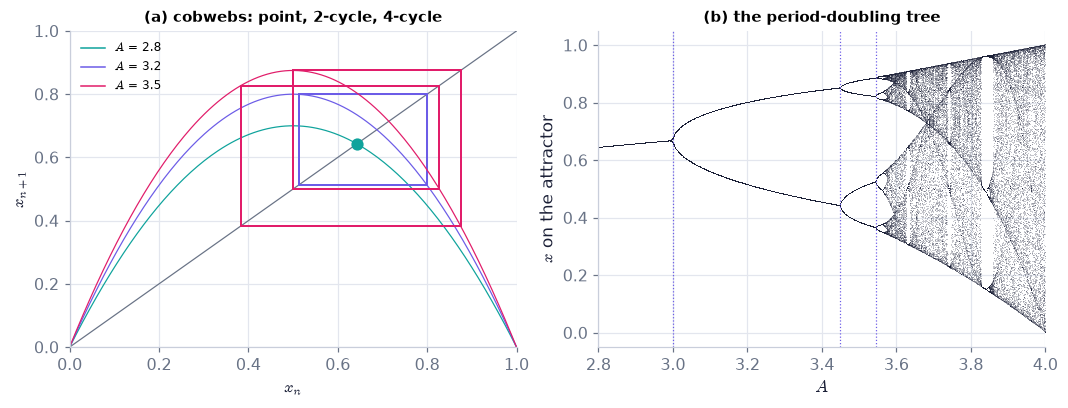

In [152]:
fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 3.6))   # the figure and its panels
xl = np.linspace(0, 1, 200)                                        # x from 0 to 1
a.plot(xl, xl, color=C_BASE, lw=0.8)                               # the diagonal y = x
for A, col in ((2.8, C_DECAY), (3.2, C_NEUT), (3.5, C_GROW)):   # repeat the indented lines for each item listed
    a.plot(xl, A*xl*(1 - xl), color=col, lw=0.8)                   # the map y = A x (1 - x)
    cw = ch11.cobweb(A, 0.2, 60)                                   # the cobweb path of 60 iterations from x = 0.2
    if A < 3:                                                      # a stable fixed point: the late cobweb has shrunk to a single point
        a.plot(1 - 1/A, 1 - 1/A, "o", color=col, ms=7)             # mark it: x* = 1 - 1/A on the diagonal
    a.plot(cw["xs"][60:], cw["ys"][60:], color=col, lw=1.0, label=f"$A$ = {A}")   # only the late part: the attractor
a.set(xlabel="$x_n$", ylabel="$x_{n+1}$", xlim=(0, 1), ylim=(0, 1))   # axis labels (with units) and fixed ranges for this panel
a.set_title("(a) cobwebs: point, 2-cycle, 4-cycle", fontsize=10)   # panel title — the message of this panel
a.legend(fontsize=8)   # legend: one entry per curve
bd = ch11.bifurcation_diagram(np.linspace(2.8, 4.0, 500 if FAST else 1000))   # the values visited after a transient, for each A
b.plot(bd["A"], bd["x"], ",", color=COLORS["ink"], alpha=0.25)   # every value the map keeps visiting at this A: one branch, two, four, ... chaos
for An in pd_["A_n"][:3]:   # repeat the indented lines for each item listed
    b.axvline(An, color=C_NEUT, lw=0.8, ls=":")   # a reference line or band
b.set(xlabel="$A$", ylabel="$x$ on the attractor", xlim=(2.8, 4.0))   # axis labels (with units) and fixed ranges for this panel
b.set_title("(b) the period-doubling tree", fontsize=10)   # panel title — the message of this panel
plt.show()   # display the figure

**What does the code above do?**

1. `ch11.cobweb(A, x0, n)` returns the corner points of the cobweb path; only its late part is drawn, so the transient is hidden.
2. `ch11.bifurcation_diagram(A_values)` iterates the map for each $A$, discards a transient and returns the values visited.

**What you see.** (a) The logistic map for three values of $A$ with the late part of the cobweb: a single point (teal), a square that visits two values (purple), a figure that visits four (rose). (b) All values visited after a transient, against $A$: one line splitting into 2, 4, 8 … and then a cloud; dotted lines mark the first three doublings.

**How to read it.** Each split comes sooner than the last by the factor 4.669: the intervals between doublings shrink geometrically, so infinitely many fit before $A\approx3.57$, where chaos starts.

**What would change if…** …a different one-hump map (for example $x\to A\sin\pi x$): different numbers $A_n$, the same ratio.

📝 **Note.** **N118 [C]** **Other routes** (named): quasi-periodicity — after two incommensurate frequencies the motion becomes chaotic (Ruelle & Takens
1971), unlike Landau's picture of an endless sequence of new frequencies; the Lorenz system follows neither — its chaos appears
after a subcritical Hopf point (D25). Pointer: the turbulence-onset debate in Ch. 12.

📝 **Note.** **N119 [C]** **What chaos means for prediction** (named): a deterministic system can still be unpredictable in practice — not because of
quantum uncertainty but because no measurement is exact (Poincaré saw this in 1908). Climate hook: weather forecasts lose skill
after about two weeks; centres therefore run *ensembles* of forecasts from slightly different starts and forecast probabilities;
climate projections ask about statistics of the attractor, not one trajectory (Ch. 13). Whether turbulence itself is "chaos in a
few modes" remains open.

#### 🎮 Interactive: How can three exact equations be unpredictable?

**Why interactive rather than a static figure:** The 3-D orbit, the $X(t)$ traces and the log-separation panel run on one clock from two starts 10⁻⁸ apart; the $r$ slider moves
the fixed points and changes the verdict while you watch; a static attractor picture hides both the divergence and the
$r$-dependence.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Preset 'r = 10': both runs spiral into a convection state; raise r past 24.74 and watch the status turn rose.
- At r = 28 read the time at which the runs differ by 50 % (end card); make δ₀ 100 times smaller and see how few time units you gain.
- Click the orbit: the inspector shows the Jacobian's eigenvalues there.

In [153]:
show_viz("ch11", "lorenz_attractor")   # full-width explainer; ⤢ Full screen for more room

[explainer ch11/lorenz_attractor]

*↪ **S02** — Literature: the benchmarks used here are cited where they appear (Chandrasekhar 1961; Orszag 1971; Thomas,
via Gallagher, Griffiths & Stephen 2016; Jordinson 1970; Tatsumi & Kakutani 1958; Michalke 1964; Drazin & Reid 1981; Lorenz 1963;
Feigenbaum 1978); the book's bibliography is not reproduced.*

---

## ✅ What should have clicked

- **C01** A small disturbance is a sum of waves $e^{\mathrm ikx+\sigma t}$; a flow is stable only if $\sigma_r\le0$ for every $k$, and onset happens where $\sigma_r(k)$ first touches zero.
- **C02** Across a velocity jump, gravity's restoring term fights shear's kinetic term under a square root; when shear wins the two wave speeds become a complex pair and one grows — short waves first, unless surface tension holds them (6.7 m/s for wind over water).
- **C03** Heating from below gives two ODEs in $z$ with one parameter Ra; $\sigma$ is a real eigenvalue, computed by Chebyshev collocation.
- **C04** Each cell width has its own marginal Ra; the valley's bottom, $\mathrm{Ra}_c=1707.76$ at $K_c=3.117$, is the onset, with cells about as wide as the layer is deep.
- **C05** With stress-free walls sine modes make everything algebra: $\mathrm{Ra}=(\pi^2+K^2)^3/K^2$, minimum $27\pi^4/4$ at $K^2=\pi^2/2$.
- **C06** Because heat diffuses about 100× faster than salt, a column lighter on top can still overturn into salt fingers when $\mathrm{Rs}-\mathrm{Ra}>27\pi^4/4$.
- **C07** Swapping rings releases energy when the squared circulation falls outward; the centrifugal force plays gravity and viscosity adds the 1708-type threshold $\mathrm{Ta}_c\approx1708/(\tfrac12(1+\Omega_2/\Omega_1))$.
- **C08** Stratified shear flow obeys one ODE, Taylor–Goldstein, with $c$ as the eigenvalue; its unstable modes come in conjugate pairs.
- **C09** $\mathrm{Ri}>\tfrac14$ everywhere guarantees stability (Miles–Howard); $\mathrm{Ri}<\tfrac14$ only allows instability.
- **C10** Every unstable wave speed lies in the half-disc on $[U_{\min},U_{\max}]$; growth is at most $k(U_{\max}-U_{\min})/2$.
- **C11** Squire makes 2-D waves the first to go unstable; eliminating pressure leaves the fourth-order Orr–Sommerfeld equation.
- **C12** Inviscid instability needs an inflection point with a vorticity maximum; neutral waves have a critical layer and cat's eyes.
- **C13** Plane Poiseuille flow, inviscidly stable, is viscously unstable above $\mathrm{Re}_c=5772.22$ ($k_c=1.02056$) — Tollmien–Schlichting waves.
- **C14** A disturbance grows when its Reynolds-stress production $-\int uvU'$ beats viscous dissipation; viscosity can supply the phase shift that makes production positive.
- **C15** Three modes of convection give the Lorenz system; past $r_H\approx24.74$ it is chaotic — deterministic yet unpredictable beyond about 20–30 time units.

**What later chapters build on**

- **Ch. 12:** Reynolds stresses $-\langle uv\rangle$ and the production term of the turbulent kinetic energy (C14), transition routes (N111), Richardson-number mixing (C09).
- **Ch. 13:** baroclinic instability (C01's recipe with rotation; the semicircle and inflection theorems reappear with $U''-\beta$, Rayleigh–Kuo), inertial instability (C07), stratified shear (C08–C09), predictability (C15).
- **Ch. 14:** boundary-layer transition on airfoils (C13).

**Not taught here (and where to find it)**
- Exercises 11.3–11.5 (S01).
- The stability analysis of pipe flow (named, N101).
- Spatial instability and absolute/convective instability (named, N03).
- Weakly nonlinear theory (named, N110).